# Spectral_Analysis — part 6 of 7

This notebook was automatically split from a larger notebook.

Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Original segment shape: (106944, 32)
Downsampled wavelet segment shape: (21389, 32)
Wavelet sampling rate: 200.0 Hz
Saved coefficient time points: 5348
Processing Fp1 (1/32)
Processing Fpz (2/32)
Processing Fp2 (3/32)
Processing F7 (4/32)
Processing F3 (5/32)
Processing Fz (6/32)
Processing F4 (7/32)
Processing F8 (8/32)
Processing FC5 (9/32)
Processing FC1 (10/32)
Processing FC2 (11/32)
Processing FC6 (12/32)
Processing M1 (13/32)
Processing T7 (14/32)
Processing C3 (15/32)
Processing Cz (16/32)
Processing C4 (17/32)
Processing T8 (18/32)
Processing M2 (19/32)
Processing CP5 (20/32)
Processing CP1 (21/32)
Processing CP2 (22/32)
Processing CP6 (23/32)
Processing P7 (24/32)
Processing P3 (25/32)
Processing Pz (26/32)
Processing P4 (27/32)
Processing P8 (28/32)
Processing POz (29/32)
Processing O1 (30/32)
Processing Oz (31/32)
Processing O2 (32/32)


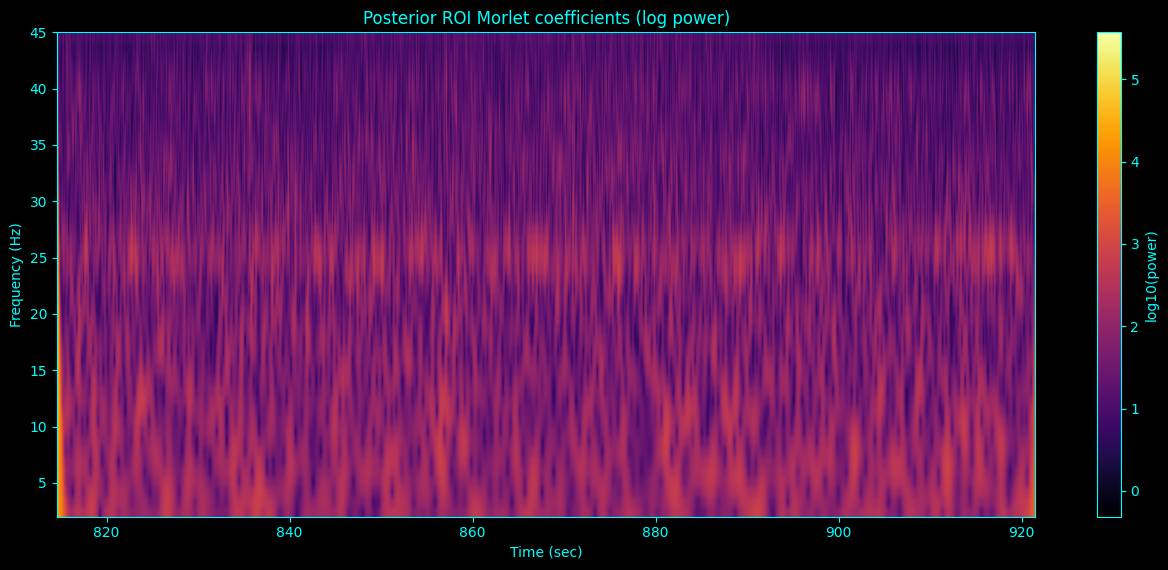

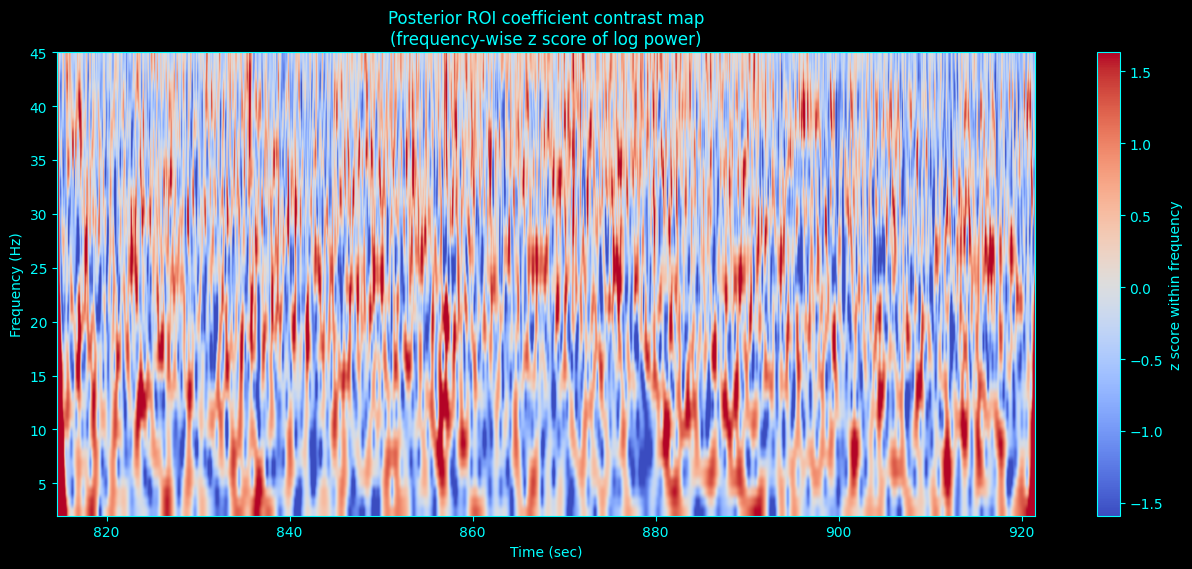

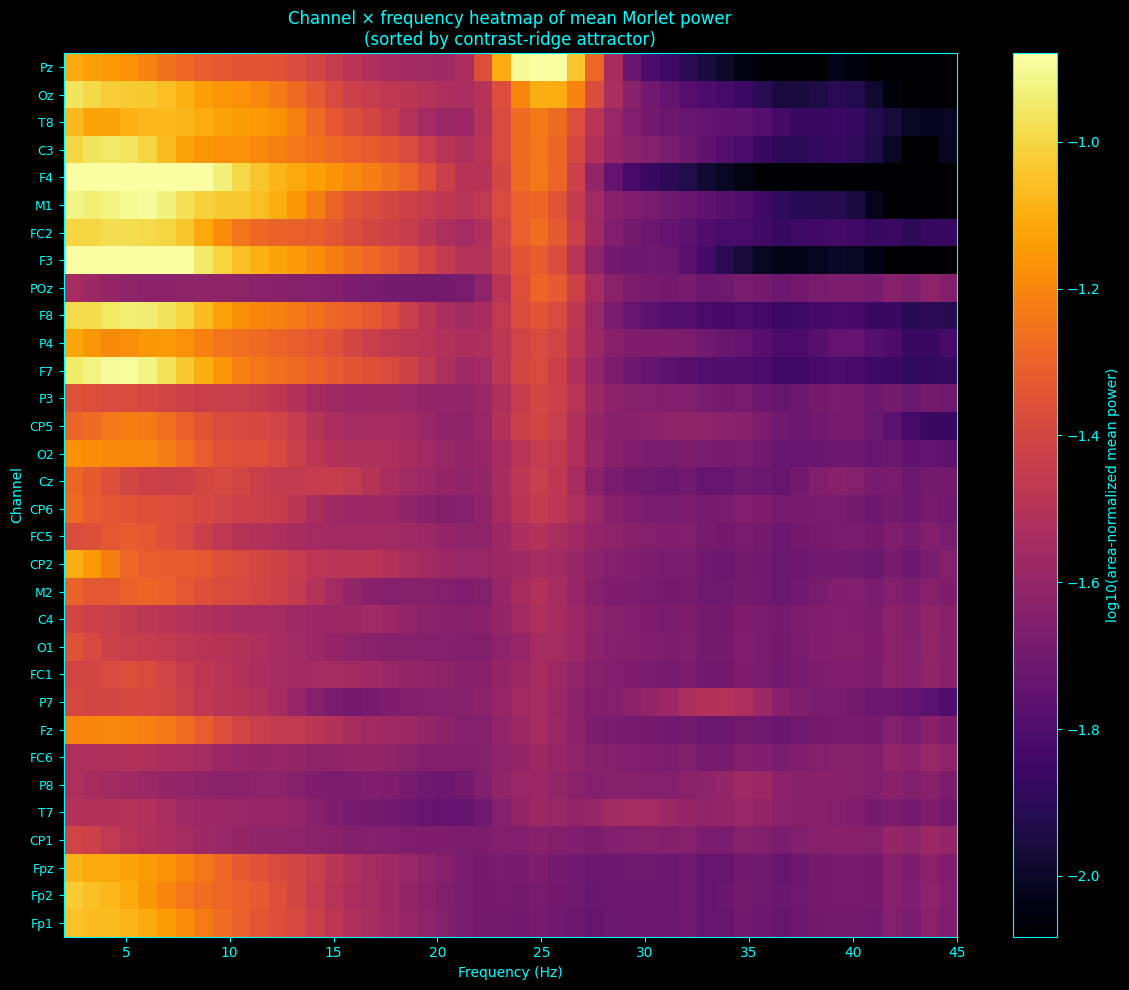

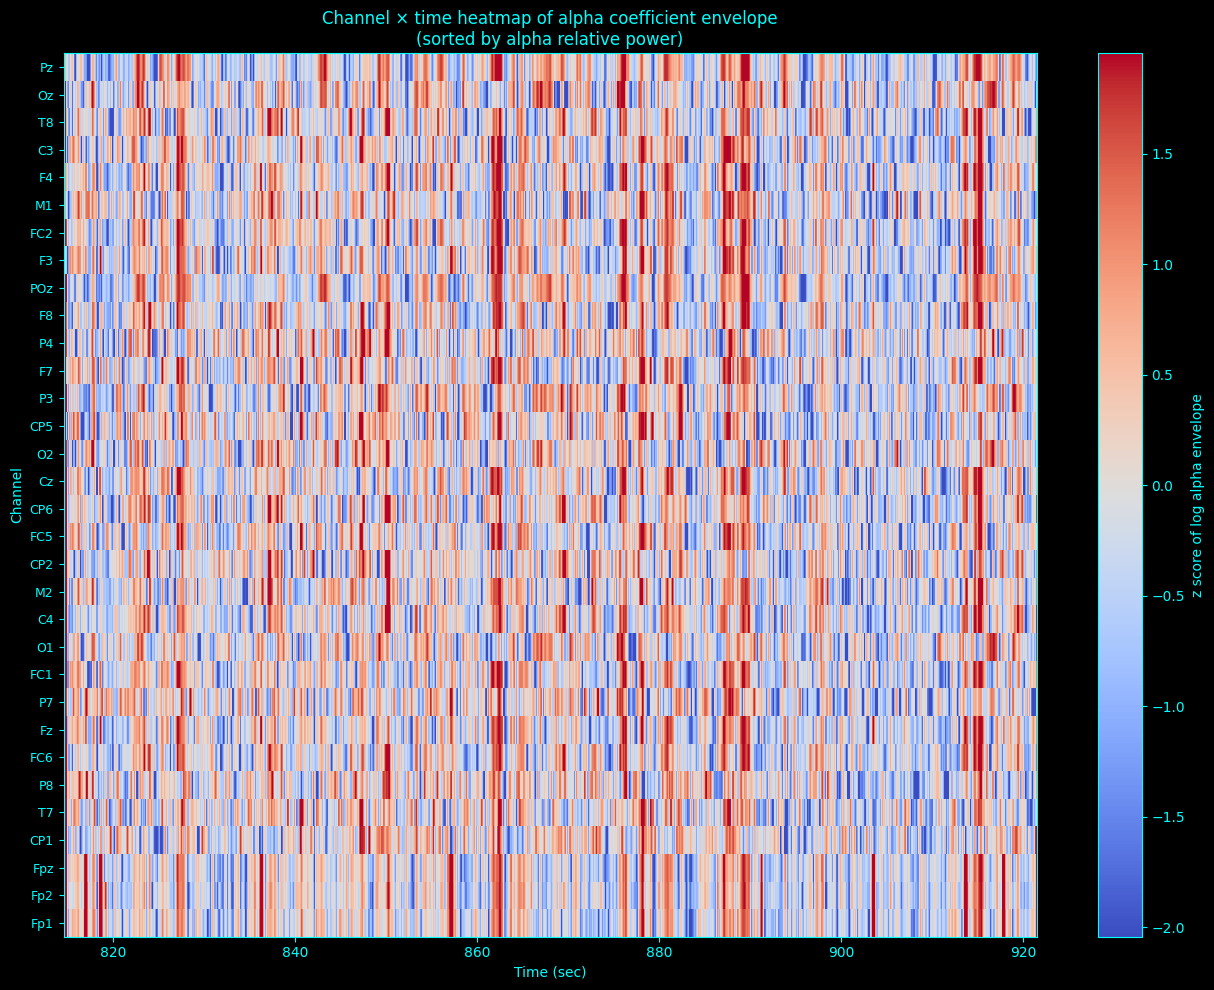

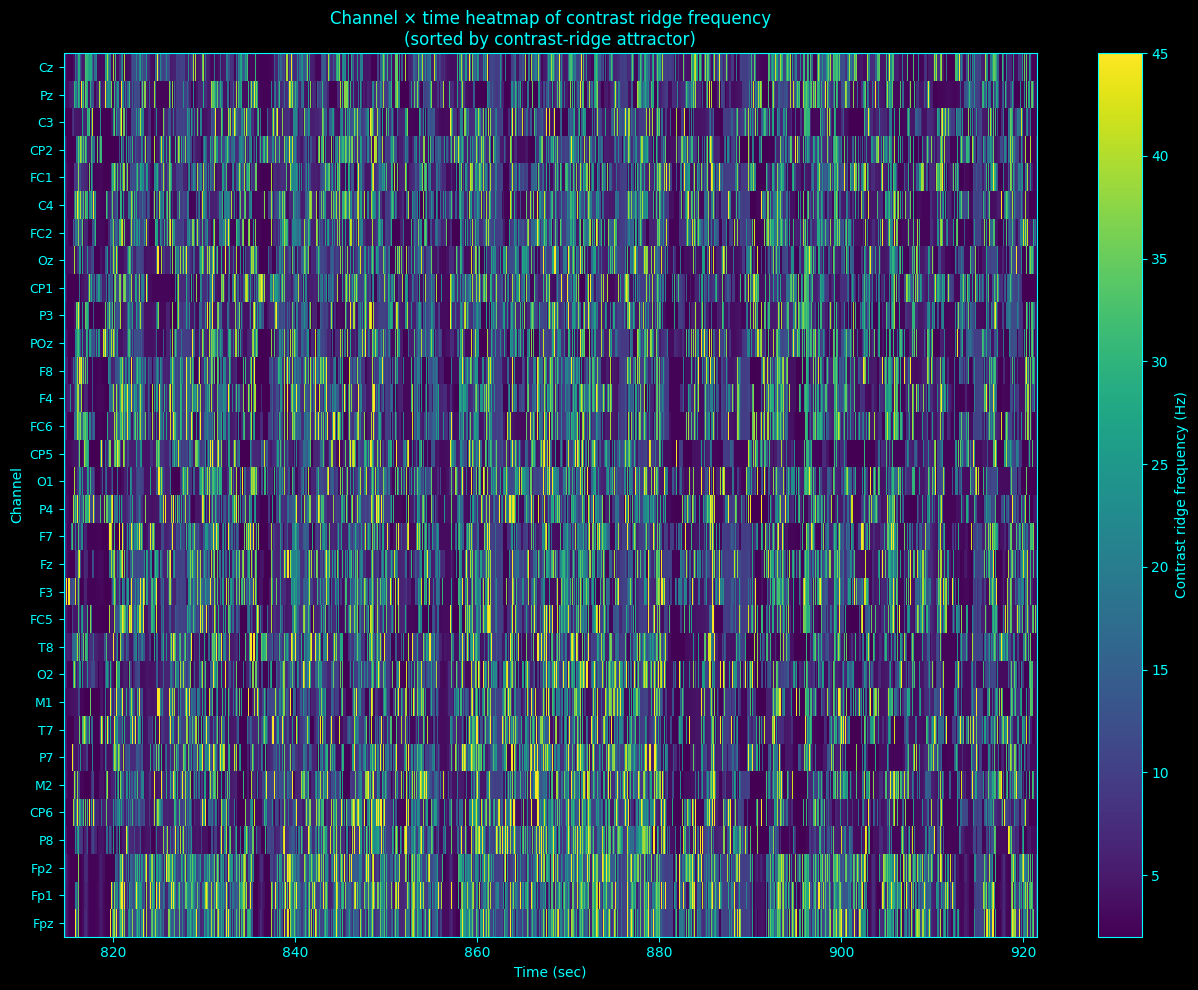

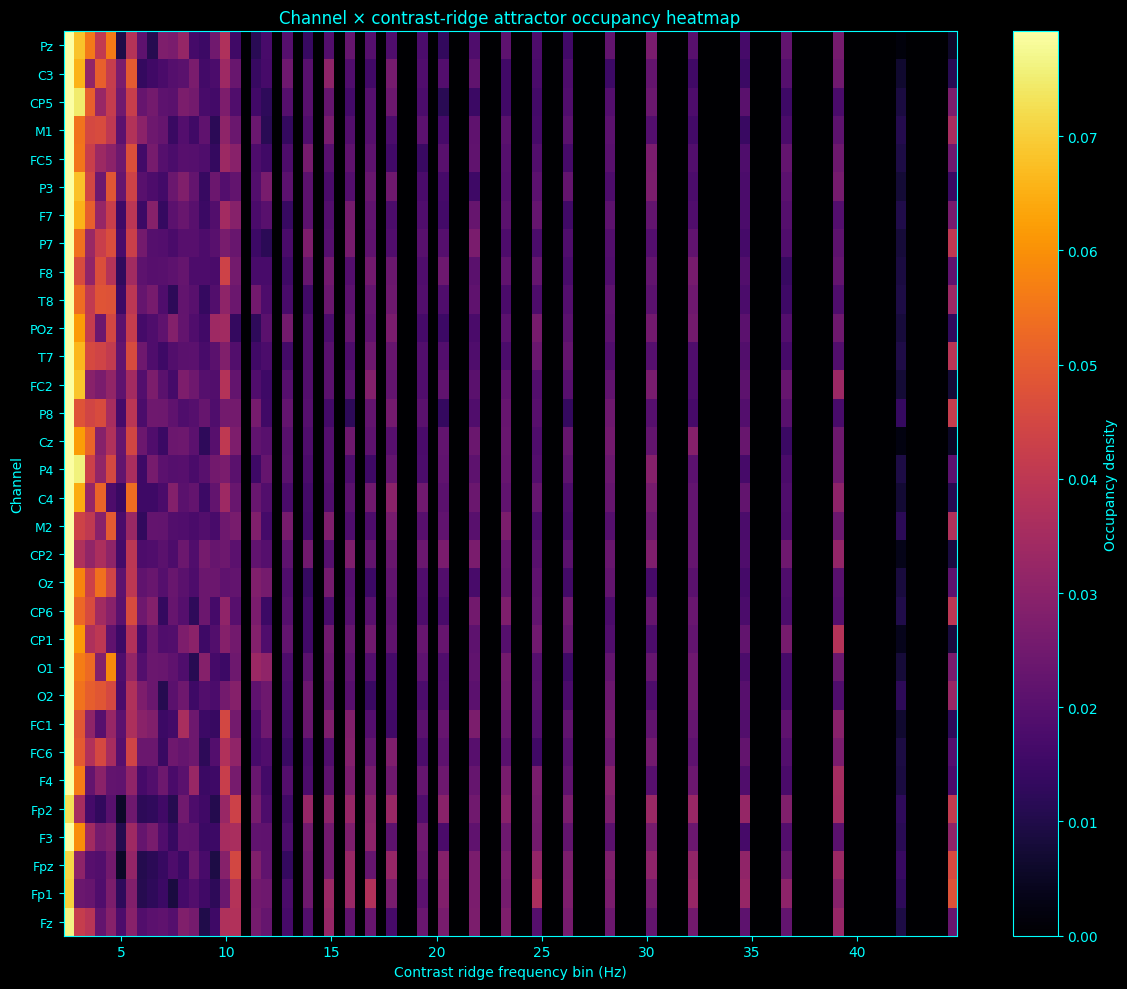

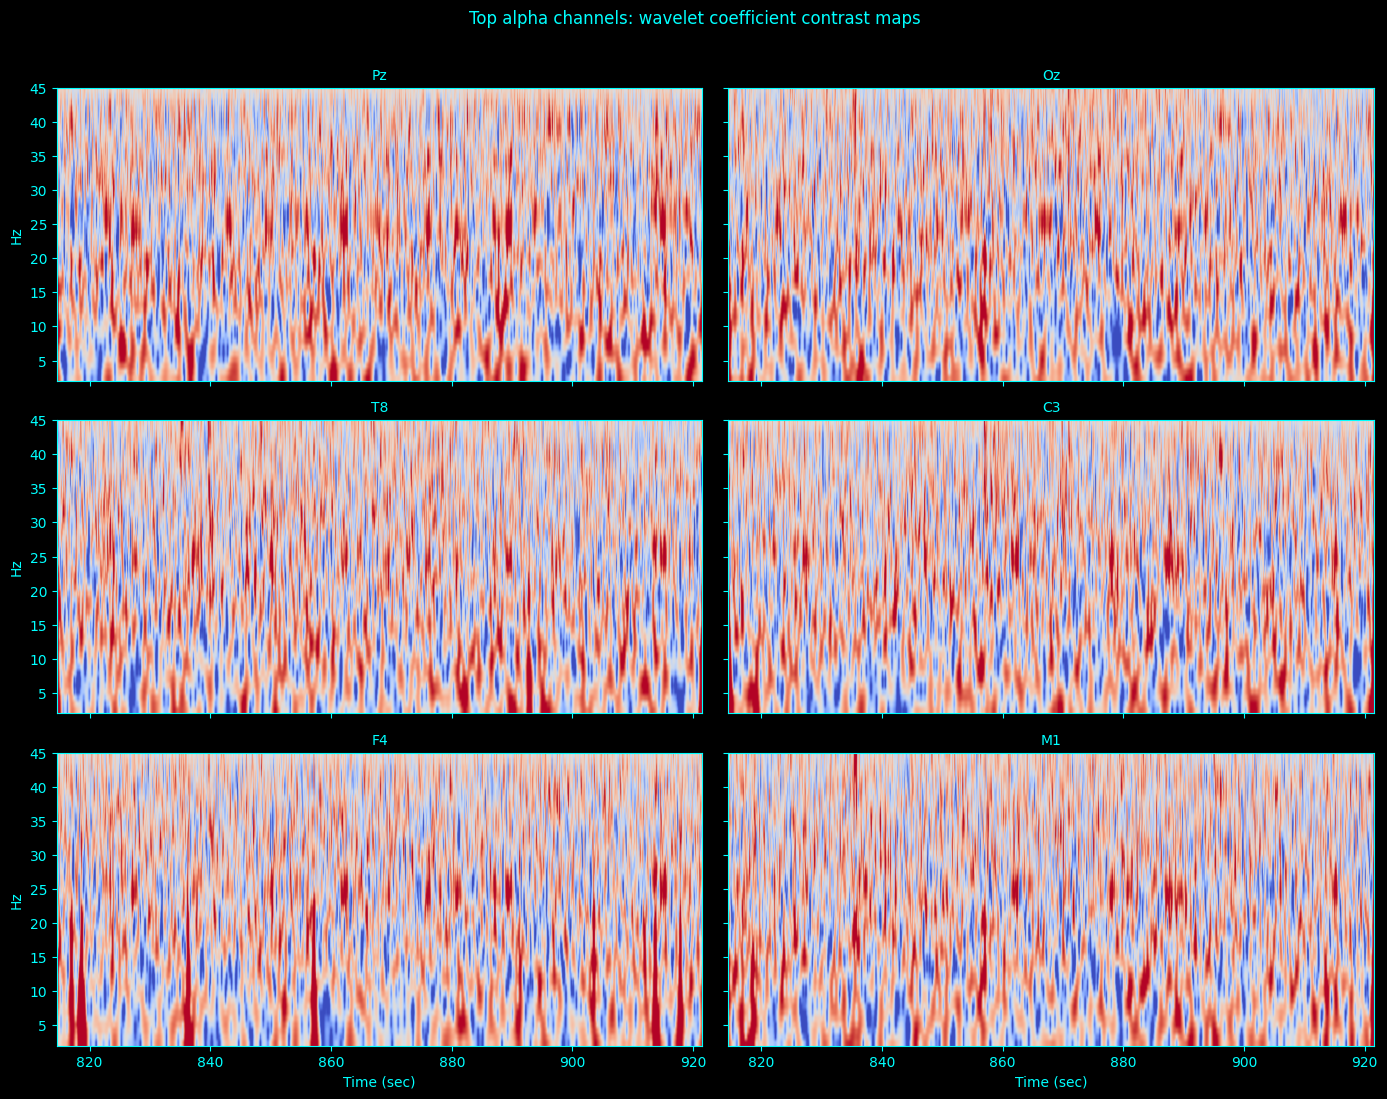


Saved dict NPY: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_wavelet_coefficients_atlas/WaveletCoefficients_x.npy
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_wavelet_coefficients_atlas/exploratory_wavelet_coefficients_atlas_outputs.npz
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_wavelet_coefficients_atlas/wavelet_coefficients_channel_summary.csv
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_wavelet_coefficients_atlas/exploratory_wavelet_coefficients_atlas_notes.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_wavelet_coefficients_atlas/plots
Done.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, ndimage

# -------------------------------------------------------
# NUMPY 1.x / 2.x COMPATIBILITY
# -------------------------------------------------------
if hasattr(np, "trapezoid"):
    integrate_trapezoid = np.trapezoid
else:
    integrate_trapezoid = np.trapz

# -------------------------------------------------------
# CONFIG — aligned to the upgraded scripts
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_wavelet_coefficients_atlas")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# -------------------------------------------------------
# THEORY / DESIGN
# -------------------------------------------------------
# The original block computes pywt.cwt using "frequencies" directly, which is not
# the right way to think about scales/frequencies for exploratory EEG work. It also
# saves raw coefficients without asking:
# - where coefficient energy lives,
# - how stable coefficient ridges are over time,
# - whether alpha is persistent or intermittent,
# - whether low-frequency slope dominates the map,
# - whether transient relative ridges differ from absolute power ridges.
#
# This version turns the coefficient field into an exploratory "wavelet coefficient atlas":
# 1. Compute complex Morlet coefficients without PyWavelets dependency.
# 2. Save time-decimated complex coefficients for all channels.
# 3. Derive coefficient-power geometry from the coefficients.
# 4. Track two ridge families:
#    - absolute ridge: frequency of maximum absolute power at each time
#    - contrast ridge: frequency of maximum frequency-wise z-scored log-power
#      at each time (novel exploratory emphasis: transient relative structure)
# 5. Build attractor histograms of the contrast ridge.
# 6. Quantify alpha occupancy, ridge stability, attractor entropy, and
#    stationary-vs-dynamic mismatch.
#
# This is for exploratory expert research, not publishing, not scoring.

# Wavelet analysis band
fmin, fmax = 2.0, 45.0
n_wavelet_freqs = 48
target_freqs_hz = np.geomspace(fmin, fmax, n_wavelet_freqs)

# Morlet design
morlet_n_cycles = 7.0
morlet_support_sigma = 4.0  # support = +/- support_sigma * sigma_t

# Downsampling / storage
wavelet_downsample_factor = 5
fs_wavelet = sampling_rate / wavelet_downsample_factor  # 200 Hz
save_time_decim = 4                                    # save coefficients at 50 Hz equivalent

# Preprocessing
apply_common_average_reference = False
detrend_mode = "constant"
zscore_each_channel = False

# Frequency bands / summaries
analysis_band = (2.0, 45.0)
display_band = (2.0, 45.0)
alpha_band = (8.0, 13.0)
theta_band = (4.0, 8.0)
beta_band = (13.0, 30.0)
delta_band = (2.0, 4.0)
low_gamma_band = (30.0, 45.0)

band_defs = {
    "delta": delta_band,
    "theta": theta_band,
    "alpha": alpha_band,
    "beta": beta_band,
    "low_gamma": low_gamma_band,
}

# Ridge histogram
ridge_hist_bin_width_hz = 0.5

# Contrast-ridge smoothing
ridge_time_smooth_bins = 9
ridge_freq_smooth_bins = 3

# Channels
eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

roi_definitions = {
    "frontal":   ['Fp1', 'Fpz', 'Fp2', 'F3', 'Fz', 'F4'],
    "central":   ['C3', 'Cz', 'C4'],
    "posterior": ['P3', 'Pz', 'P4', 'O1', 'Oz', 'O2'],
}

eps = 1e-12
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def preprocess_channel(y, detrend_mode="constant", zscore=False):
    y = np.asarray(y, dtype=float)
    if detrend_mode is not None:
        y = signal.detrend(y, type=detrend_mode)
    if zscore:
        sd = np.std(y)
        y = (y - np.mean(y)) / (sd + eps)
    return y.astype(np.float32)

def band_mask(freqs_hz, band):
    lo, hi = band
    return (freqs_hz >= lo) & (freqs_hz <= hi)

def smooth_1d(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def zscore_1d(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    return (x - mu) / (sd + eps)

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def area_normalize_1d(freqs_hz, x, band):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)

    mask = band_mask(freqs_hz, band) & np.isfinite(x) & (x >= 0)
    if np.sum(mask) < 2:
        return out

    area = integrate_trapezoid(x[mask], freqs_hz[mask])
    if not np.isfinite(area) or area <= 0:
        return out

    out[mask] = x[mask] / area
    return out

def integrate_band_1d(freqs_hz, x, band):
    mask = band_mask(freqs_hz, band) & np.isfinite(x)
    if np.sum(mask) < 2:
        return np.nan
    return float(integrate_trapezoid(x[mask], freqs_hz[mask]))

def integrate_band_2d(freqs_hz, x2d, band):
    mask = band_mask(freqs_hz, band)
    if np.sum(mask) < 2:
        return np.full(x2d.shape[1], np.nan, dtype=float)
    return integrate_trapezoid(x2d[mask], freqs_hz[mask], axis=0)

def spectral_entropy_from_spectrum(freqs_hz, spectrum_1d, band=(2.0, 45.0), normalize=True):
    mask = band_mask(freqs_hz, band) & np.isfinite(spectrum_1d) & (spectrum_1d >= 0)
    if np.sum(mask) < 2:
        return np.nan, np.nan

    f = freqs_hz[mask]
    p = np.asarray(spectrum_1d[mask], dtype=float)

    area = integrate_trapezoid(p, f)
    if not np.isfinite(area) or area <= 0:
        return np.nan, np.nan

    p = p / area
    p = p / (np.sum(p) + eps)

    H = -np.sum(p * np.log(p + eps))
    Hmax = np.log(len(p) + eps)
    Hn = H / (Hmax + eps) if normalize else H
    return float(H), float(Hn)

def spectral_centroid_from_spectrum(freqs_hz, spectrum_1d, band=(2.0, 45.0)):
    mask = band_mask(freqs_hz, band) & np.isfinite(spectrum_1d) & (spectrum_1d >= 0)
    if np.sum(mask) < 2:
        return np.nan
    f = freqs_hz[mask]
    p = np.asarray(spectrum_1d[mask], dtype=float)
    s = np.sum(p)
    if s <= 0:
        return np.nan
    return float(np.sum(f * p) / (s + eps))

def robust_peak_in_band(freqs_hz, spectrum_1d, band=(8.0, 13.0), smooth_win=7):
    mask = band_mask(freqs_hz, band) & np.isfinite(spectrum_1d)
    if np.sum(mask) < 5:
        return np.nan, np.nan, np.nan, np.nan

    f = freqs_hz[mask]
    y = smooth_1d(spectrum_1d[mask], win=smooth_win)

    peaks, _ = signal.find_peaks(y)
    if len(peaks) == 0:
        return np.nan, np.nan, np.nan, np.nan

    prominences = signal.peak_prominences(y, peaks)[0]
    valid = (peaks > 0) & (peaks < len(y) - 1)
    if not np.any(valid):
        return np.nan, np.nan, np.nan, np.nan

    peaks = peaks[valid]
    prominences = prominences[valid]

    min_prominence = max(0.05 * np.nanmax(y), 1.5 * np.nanmedian(np.abs(np.diff(y))))
    strong = prominences >= min_prominence
    if not np.any(strong):
        return np.nan, np.nan, np.nan, np.nan

    peaks = peaks[strong]
    prominences = prominences[strong]
    winner = int(np.argmax(prominences))
    peak_idx = peaks[winner]

    peak_freq = float(f[peak_idx])
    peak_height = float(y[peak_idx])
    peak_prominence = float(prominences[winner])
    peak_contrast = float(peak_height / (np.nanmedian(y) + eps))
    return peak_freq, peak_height, peak_prominence, peak_contrast

def ridge_histogram(freq_series_hz, band=(2.0, 45.0), bin_width_hz=0.5):
    valid = np.asarray(freq_series_hz, dtype=float)
    valid = valid[np.isfinite(valid)]
    valid = valid[(valid >= band[0]) & (valid <= band[1])]

    bins = np.arange(band[0], band[1] + bin_width_hz, bin_width_hz)
    if len(valid) == 0:
        hist = np.zeros(len(bins) - 1, dtype=float)
    else:
        hist, _ = np.histogram(valid, bins=bins)
        hist = hist.astype(float)
        hist = hist / (np.sum(hist) + eps)

    centers = 0.5 * (bins[:-1] + bins[1:])
    return centers, hist

def normalized_hist_entropy(hist):
    hist = np.asarray(hist, dtype=float)
    hist = hist[hist > 0]
    if len(hist) == 0:
        return np.nan
    H = -np.sum(hist * np.log(hist + eps))
    Hmax = np.log(len(hist) + eps)
    return float(H / (Hmax + eps))

def morlet_wavelet(f_hz, fs, n_cycles=7.0, support_sigma=4.0):
    sigma_t = n_cycles / (2.0 * np.pi * f_hz)
    half_width_sec = support_sigma * sigma_t
    t = np.arange(-half_width_sec, half_width_sec + 1.0 / fs, 1.0 / fs)

    wavelet = np.exp(2j * np.pi * f_hz * t) * np.exp(-(t ** 2) / (2.0 * sigma_t ** 2))
    wavelet = wavelet / np.sqrt(np.sum(np.abs(wavelet) ** 2) + eps)
    return wavelet.astype(np.complex64)

def compute_morlet_coeffs(y, fs, target_freqs_hz, n_cycles=7.0, support_sigma=4.0):
    y = np.asarray(y, dtype=np.float32)
    coeff_rows = []

    for f_hz in target_freqs_hz:
        w = morlet_wavelet(f_hz, fs, n_cycles=n_cycles, support_sigma=support_sigma)
        coeff = signal.fftconvolve(y, np.conjugate(w[::-1]), mode="same")
        coeff_rows.append(coeff.astype(np.complex64))

    return np.vstack(coeff_rows)

def frequencywise_zlog_power(power_2d):
    logp = np.log10(np.maximum(power_2d, eps))
    z = (logp - np.nanmean(logp, axis=1, keepdims=True)) / (np.nanstd(logp, axis=1, keepdims=True) + eps)
    return z

def smooth_map_2d(x, freq_bins=3, time_bins=9):
    y = ndimage.uniform_filter1d(np.asarray(x, dtype=np.float32), size=max(int(time_bins), 1), axis=1, mode="nearest")
    y = ndimage.uniform_filter1d(y, size=max(int(freq_bins), 1), axis=0, mode="nearest")
    return y.astype(np.float32)

def roi_average_matrix(matrix, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]
    if len(idx) == 0:
        return np.full(matrix.shape[0], np.nan)
    return np.nanmean(matrix[:, idx], axis=1)

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

segment_ds = signal.resample_poly(segment, up=1, down=wavelet_downsample_factor, axis=0)
segment_ds = np.asarray(segment_ds, dtype=np.float32)

time_sec_rel_full = np.arange(segment_ds.shape[0], dtype=float) / fs_wavelet
time_save_idx = np.arange(0, segment_ds.shape[0], save_time_decim, dtype=int)
time_sec_rel_save = time_sec_rel_full[time_save_idx]
time_sec_abs_save = start_time + time_sec_rel_save

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Original segment shape: {segment.shape}")
print(f"Downsampled wavelet segment shape: {segment_ds.shape}")
print(f"Wavelet sampling rate: {fs_wavelet:.1f} Hz")
print(f"Saved coefficient time points: {len(time_sec_abs_save)}")

# -------------------------------------------------------
# CORE ANALYSIS
# -------------------------------------------------------
wavelet_coefficients_dict = {}

summary_rows = []
mean_power_matrix = []
alpha_env_matrix = []
theta_env_matrix = []
beta_env_matrix = []
absolute_ridge_matrix = []
contrast_ridge_matrix = []
contrast_hist_matrix = []

coeff_cube_save = None
ridge_hist_centers_ref = None

for ch_i, ch_name in enumerate(eeg_channel_names):
    print(f"Processing {ch_name} ({ch_i + 1}/{len(eeg_channel_names)})")

    y = preprocess_channel(
        segment_ds[:, ch_i],
        detrend_mode=detrend_mode,
        zscore=zscore_each_channel,
    )

    coeffs = compute_morlet_coeffs(
        y,
        fs_wavelet,
        target_freqs_hz,
        n_cycles=morlet_n_cycles,
        support_sigma=morlet_support_sigma,
    )
    coeffs_save = coeffs[:, time_save_idx]

    if coeff_cube_save is None:
        coeff_cube_save = np.full(
            (len(target_freqs_hz), len(time_sec_rel_save), len(eeg_channel_names)),
            np.nan + 1j * np.nan,
            dtype=np.complex64,
        )

    coeff_cube_save[:, :, ch_i] = coeffs_save

    power = np.abs(coeffs) ** 2
    power_save = np.abs(coeffs_save) ** 2

    mean_power_spectrum = np.nanmean(power, axis=1)
    mean_power_norm = area_normalize_1d(target_freqs_hz, mean_power_spectrum, analysis_band)

    alpha_env = integrate_band_2d(target_freqs_hz, power, alpha_band)
    theta_env = integrate_band_2d(target_freqs_hz, power, theta_band)
    beta_env = integrate_band_2d(target_freqs_hz, power, beta_band)

    alpha_env_logz = zscore_1d(np.log10(alpha_env + eps))

    # Absolute ridge: argmax of raw power across frequency at each time
    abs_ridge_idx = np.nanargmax(power, axis=0)
    absolute_ridge_hz = target_freqs_hz[abs_ridge_idx]

    # Contrast ridge: argmax of smoothed frequency-wise z-scored log-power
    zfreq = frequencywise_zlog_power(power)
    zfreq_smooth = smooth_map_2d(
        zfreq,
        freq_bins=ridge_freq_smooth_bins,
        time_bins=ridge_time_smooth_bins,
    )
    ctr_ridge_idx = np.nanargmax(zfreq_smooth, axis=0)
    contrast_ridge_hz = target_freqs_hz[ctr_ridge_idx]

    alpha_peak_hz, alpha_peak_height, alpha_peak_prominence, alpha_peak_contrast = robust_peak_in_band(
        target_freqs_hz,
        mean_power_norm,
        band=alpha_band,
        smooth_win=7,
    )

    centroid_hz = spectral_centroid_from_spectrum(target_freqs_hz, mean_power_spectrum, band=analysis_band)
    _, entropy_norm = spectral_entropy_from_spectrum(target_freqs_hz, mean_power_spectrum, band=analysis_band, normalize=True)

    alpha_rel = integrate_band_1d(target_freqs_hz, mean_power_norm, alpha_band)
    theta_rel = integrate_band_1d(target_freqs_hz, mean_power_norm, theta_band)
    beta_rel = integrate_band_1d(target_freqs_hz, mean_power_norm, beta_band)

    abs_hist_centers, abs_hist = ridge_histogram(
        absolute_ridge_hz,
        band=analysis_band,
        bin_width_hz=ridge_hist_bin_width_hz,
    )
    ctr_hist_centers, ctr_hist = ridge_histogram(
        contrast_ridge_hz,
        band=analysis_band,
        bin_width_hz=ridge_hist_bin_width_hz,
    )

    if ridge_hist_centers_ref is None:
        ridge_hist_centers_ref = ctr_hist_centers

    absolute_attractor_hz = float(abs_hist_centers[np.argmax(abs_hist)]) if np.any(np.isfinite(abs_hist)) else np.nan
    contrast_attractor_hz = float(ctr_hist_centers[np.argmax(ctr_hist)]) if np.any(np.isfinite(ctr_hist)) else np.nan

    abs_ridge_std = float(np.nanstd(absolute_ridge_hz))
    ctr_ridge_std = float(np.nanstd(contrast_ridge_hz))
    ctr_ridge_range = float(np.nanmax(contrast_ridge_hz) - np.nanmin(contrast_ridge_hz))
    ctr_ridge_jump = float(np.nanmean(np.abs(np.diff(contrast_ridge_hz)))) if len(contrast_ridge_hz) > 1 else np.nan

    alpha_occupancy_abs = float(np.nanmean((absolute_ridge_hz >= alpha_band[0]) & (absolute_ridge_hz <= alpha_band[1])))
    alpha_occupancy_ctr = float(np.nanmean((contrast_ridge_hz >= alpha_band[0]) & (contrast_ridge_hz <= alpha_band[1])))

    if np.nanstd(absolute_ridge_hz) > 0 and np.nanstd(contrast_ridge_hz) > 0:
        ridge_family_correlation = float(np.corrcoef(absolute_ridge_hz, contrast_ridge_hz)[0, 1])
    else:
        ridge_family_correlation = np.nan

    attractor_entropy_abs = normalized_hist_entropy(abs_hist)
    attractor_entropy_ctr = normalized_hist_entropy(ctr_hist)

    stationary_vs_contrast_gap = (
        alpha_peak_hz - contrast_attractor_hz
        if np.isfinite(alpha_peak_hz) and np.isfinite(contrast_attractor_hz)
        else np.nan
    )

    wavelet_coefficients_dict[ch_name] = {
        "coefficients_complex_decimated": coeffs_save,
        "frequencies_hz": target_freqs_hz,
        "time_sec_rel": time_sec_rel_save,
        "time_sec_abs": time_sec_abs_save,
        "mean_power_area_norm_2_45Hz": mean_power_norm,
        "alpha_envelope_power": alpha_env[time_save_idx],
        "theta_envelope_power": theta_env[time_save_idx],
        "beta_envelope_power": beta_env[time_save_idx],
        "absolute_ridge_frequency_Hz": absolute_ridge_hz[time_save_idx],
        "contrast_ridge_frequency_Hz": contrast_ridge_hz[time_save_idx],
        "absolute_ridge_hist_density": abs_hist,
        "contrast_ridge_hist_density": ctr_hist,
        "absolute_ridge_hist_centers_Hz": abs_hist_centers,
        "contrast_ridge_hist_centers_Hz": ctr_hist_centers,
        "alpha_peak_frequency_Hz": alpha_peak_hz,
        "contrast_attractor_frequency_Hz": contrast_attractor_hz,
    }

    summary_rows.append({
        "channel": ch_name,
        "alpha_peak_frequency_Hz": alpha_peak_hz,
        "alpha_peak_height_area_norm": alpha_peak_height,
        "alpha_peak_prominence": alpha_peak_prominence,
        "alpha_peak_contrast": alpha_peak_contrast,
        "alpha_relative_power_2_45Hz": alpha_rel,
        "theta_relative_power_2_45Hz": theta_rel,
        "beta_relative_power_2_45Hz": beta_rel,
        "spectral_centroid_Hz_2_45Hz": centroid_hz,
        "spectral_entropy_normalized_2_45Hz": entropy_norm,
        "absolute_ridge_attractor_Hz": absolute_attractor_hz,
        "contrast_ridge_attractor_Hz": contrast_attractor_hz,
        "absolute_ridge_std_Hz": abs_ridge_std,
        "contrast_ridge_std_Hz": ctr_ridge_std,
        "contrast_ridge_range_Hz": ctr_ridge_range,
        "contrast_ridge_jump_mean_Hz": ctr_ridge_jump,
        "absolute_alpha_occupancy_fraction": alpha_occupancy_abs,
        "contrast_alpha_occupancy_fraction": alpha_occupancy_ctr,
        "ridge_family_correlation": ridge_family_correlation,
        "absolute_ridge_attractor_entropy": attractor_entropy_abs,
        "contrast_ridge_attractor_entropy": attractor_entropy_ctr,
        "stationary_vs_contrast_attractor_gap_Hz": stationary_vs_contrast_gap,
        "alpha_burst_fraction_z_gt_1": float(np.nanmean(alpha_env_logz > 1.0)),
    })

    mean_power_matrix.append(mean_power_norm)
    alpha_env_matrix.append(alpha_env[time_save_idx])
    theta_env_matrix.append(theta_env[time_save_idx])
    beta_env_matrix.append(beta_env[time_save_idx])
    absolute_ridge_matrix.append(absolute_ridge_hz[time_save_idx])
    contrast_ridge_matrix.append(contrast_ridge_hz[time_save_idx])
    contrast_hist_matrix.append(ctr_hist)

summary_df = pd.DataFrame(summary_rows)
for col in summary_df.columns:
    if col != "channel":
        summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

mean_power_matrix = np.column_stack(mean_power_matrix)
alpha_env_matrix = np.column_stack(alpha_env_matrix)
theta_env_matrix = np.column_stack(theta_env_matrix)
beta_env_matrix = np.column_stack(beta_env_matrix)
absolute_ridge_matrix = np.column_stack(absolute_ridge_matrix)
contrast_ridge_matrix = np.column_stack(contrast_ridge_matrix)
contrast_hist_matrix = np.column_stack(contrast_hist_matrix)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
dict_npy_path = os.path.join(out_dir, "WaveletCoefficients_x.npy")
npz_path = os.path.join(out_dir, "exploratory_wavelet_coefficients_atlas_outputs.npz")
summary_csv_path = os.path.join(out_dir, "wavelet_coefficients_channel_summary.csv")
notes_txt_path = os.path.join(out_dir, "exploratory_wavelet_coefficients_atlas_notes.txt")

np.save(dict_npy_path, wavelet_coefficients_dict, allow_pickle=True)

np.savez_compressed(
    npz_path,
    frequencies_hz=target_freqs_hz,
    time_sec_abs=time_sec_abs_save,
    time_sec_rel=time_sec_rel_save,
    coefficients_complex_decimated=coeff_cube_save,
    mean_power_area_norm_2_45Hz=mean_power_matrix,
    alpha_envelope_power=alpha_env_matrix,
    theta_envelope_power=theta_env_matrix,
    beta_envelope_power=beta_env_matrix,
    absolute_ridge_frequency_Hz=absolute_ridge_matrix,
    contrast_ridge_frequency_Hz=contrast_ridge_matrix,
    contrast_ridge_hist_density=contrast_hist_matrix,
    contrast_ridge_hist_centers_Hz=ridge_hist_centers_ref,
    channel_names=np.array(eeg_channel_names, dtype=object),
    start_time=start_time,
    end_time=end_time,
    original_sampling_rate=sampling_rate,
    wavelet_sampling_rate=fs_wavelet,
    wavelet_downsample_factor=wavelet_downsample_factor,
    save_time_decim=save_time_decim,
    morlet_n_cycles=morlet_n_cycles,
    morlet_support_sigma=morlet_support_sigma,
)

summary_df.to_csv(summary_csv_path, index=False)

top_alpha = summary_df.sort_values("alpha_relative_power_2_45Hz", ascending=False).head(8)
top_contrast_alpha = summary_df.sort_values("contrast_alpha_occupancy_fraction", ascending=False).head(8)
top_stable = summary_df.sort_values("contrast_ridge_std_Hz", ascending=True).head(8)
top_unstable = summary_df.sort_values("contrast_ridge_std_Hz", ascending=False).head(8)

with open(notes_txt_path, "w") as f:
    f.write("Exploratory wavelet coefficient atlas notes\n")
    f.write("===========================================\n\n")
    f.write("Intent:\n")
    f.write("This pass treats the complex wavelet coefficient field as a dynamic spectral landscape.\n")
    f.write("It is for exploratory expert research, not publishing, not scoring, and not a benchmark.\n\n")
    f.write("What changed relative to the original block:\n")
    f.write("1. No PyWavelets dependency; this version uses FFT-convolved complex Morlet kernels.\n")
    f.write("2. The analysis is restricted to the selected recording interval.\n")
    f.write("3. The coefficients are analyzed, not just displayed.\n")
    f.write("4. Two ridge families are tracked: absolute power ridge and contrast ridge.\n")
    f.write("5. Contrast ridge emphasizes transient relative structure rather than always following the strongest low-frequency slope.\n")
    f.write("6. Ridge attractor histograms, alpha occupancy, and stationary-vs-dynamic mismatch are added as exploratory descriptors.\n\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Original fs: {sampling_rate} Hz\n")
    f.write(f"Wavelet fs: {fs_wavelet:.1f} Hz\n")
    f.write(f"Downsample factor: {wavelet_downsample_factor}\n")
    f.write(f"Saved coefficient time decimation: {save_time_decim}\n")
    f.write(f"Frequency range analyzed: [{fmin:.1f}, {fmax:.1f}] Hz\n")
    f.write(f"Morlet n_cycles: {morlet_n_cycles}\n")
    f.write(f"Morlet support sigma: {morlet_support_sigma}\n\n")

    f.write("Top alpha-relative-power channels:\n")
    for _, row in top_alpha.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"alpha_rel={row['alpha_relative_power_2_45Hz']:.4f}, "
            f"alpha_peak={row['alpha_peak_frequency_Hz']}, "
            f"contrast_alpha_occupancy={row['contrast_alpha_occupancy_fraction']:.3f}\n"
        )

    f.write("\nTop contrast-alpha-occupancy channels:\n")
    for _, row in top_contrast_alpha.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"contrast_alpha_occupancy={row['contrast_alpha_occupancy_fraction']:.3f}, "
            f"contrast_attractor={row['contrast_ridge_attractor_Hz']:.3f} Hz, "
            f"alpha_burst_fraction={row['alpha_burst_fraction_z_gt_1']:.3f}\n"
        )

    f.write("\nMost stable contrast-ridge channels:\n")
    for _, row in top_stable.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"contrast_ridge_std={row['contrast_ridge_std_Hz']:.3f} Hz, "
            f"contrast_attractor_entropy={row['contrast_ridge_attractor_entropy']:.3f}, "
            f"ridge_family_correlation={row['ridge_family_correlation']}\n"
        )

    f.write("\nMost unstable contrast-ridge channels:\n")
    for _, row in top_unstable.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"contrast_ridge_std={row['contrast_ridge_std_Hz']:.3f} Hz, "
            f"contrast_ridge_jump_mean={row['contrast_ridge_jump_mean_Hz']:.3f} Hz, "
            f"stationary-vs-contrast-gap={row['stationary_vs_contrast_attractor_gap_Hz']}\n"
        )

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# Precompute decimated power summaries from saved coefficient cube
power_cube_save = np.abs(coeff_cube_save) ** 2

# 1) Posterior ROI coefficient magnitude map (log power)
posterior_idx = [eeg_channel_names.index(ch) for ch in roi_definitions["posterior"]]
posterior_power = np.nanmean(power_cube_save[:, :, posterior_idx], axis=2)
posterior_log_power = np.log10(posterior_power + eps)

fig, ax = plt.subplots(figsize=(13, 5.8), facecolor=BG)
style_ax(ax, heatmap=True)
mesh = ax.imshow(
    posterior_log_power,
    extent=[time_sec_abs_save[0], time_sec_abs_save[-1], target_freqs_hz[0], target_freqs_hz[-1]],
    aspect="auto",
    origin="lower",
    cmap="inferno",
)
ax.set_title("Posterior ROI Morlet coefficients (log power)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Frequency (Hz)")
ax.set_ylim(display_band[0], display_band[1])

cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label("log10(power)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "01_posterior_roi_coefficients_logpower.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Posterior ROI coefficient contrast map (frequency-wise z score)
posterior_zfreq = frequencywise_zlog_power(posterior_power)
posterior_zfreq = smooth_map_2d(posterior_zfreq, freq_bins=3, time_bins=7)
vmin, vmax = percentile_limits(posterior_zfreq, lo=2, hi=98)

fig, ax = plt.subplots(figsize=(13, 5.8), facecolor=BG)
style_ax(ax, heatmap=True)
mesh = ax.imshow(
    posterior_zfreq,
    extent=[time_sec_abs_save[0], time_sec_abs_save[-1], target_freqs_hz[0], target_freqs_hz[-1]],
    aspect="auto",
    origin="lower",
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("Posterior ROI coefficient contrast map\n(frequency-wise z score of log power)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Frequency (Hz)")
ax.set_ylim(display_band[0], display_band[1])

cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label("z score within frequency", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "02_posterior_roi_coefficients_zfreq.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Channel × frequency heatmap of mean coefficient power
sort_df = summary_df.sort_values(
    by=["contrast_ridge_attractor_Hz", "alpha_relative_power_2_45Hz"],
    ascending=[True, False],
).reset_index(drop=True)
sorted_channels = list(sort_df["channel"].values)
sorted_idx = [eeg_channel_names.index(ch) for ch in sorted_channels]

display_mask = band_mask(target_freqs_hz, display_band)
freqs_display = target_freqs_hz[display_mask]

heat = np.log10(mean_power_matrix[display_mask][:, sorted_idx].T + 1e-6)
vmin, vmax = percentile_limits(heat, lo=2, hi=99)

fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    heat,
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
    extent=[freqs_display[0], freqs_display[-1], len(sorted_channels), 0],
)
ax.set_title("Channel × frequency heatmap of mean Morlet power\n(sorted by contrast-ridge attractor)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(sorted_channels)) + 0.5)
ax.set_yticklabels(sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("log10(area-normalized mean power)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "03_channel_frequency_heatmap_coefficients.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Channel × time heatmap of alpha envelope
alpha_sort_df = summary_df.sort_values(
    by=["alpha_relative_power_2_45Hz", "contrast_alpha_occupancy_fraction"],
    ascending=[False, False],
).reset_index(drop=True)
alpha_sorted_channels = list(alpha_sort_df["channel"].values)
alpha_sorted_idx = [eeg_channel_names.index(ch) for ch in alpha_sorted_channels]

alpha_heat = np.full((len(alpha_sorted_channels), len(time_sec_abs_save)), np.nan, dtype=float)
for i, ch_name in enumerate(alpha_sorted_channels):
    ch_idx = eeg_channel_names.index(ch_name)
    alpha_heat[i, :] = zscore_1d(np.log10(alpha_env_matrix[:, ch_idx] + eps))

vmin, vmax = percentile_limits(alpha_heat, lo=2, hi=98)

fig, ax = plt.subplots(figsize=(13, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    alpha_heat,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    extent=[time_sec_abs_save[0], time_sec_abs_save[-1], len(alpha_sorted_channels), 0],
)
ax.set_title("Channel × time heatmap of alpha coefficient envelope\n(sorted by alpha relative power)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(alpha_sorted_channels)) + 0.5)
ax.set_yticklabels(alpha_sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("z score of log alpha envelope", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "04_alpha_envelope_heatmap.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Channel × time heatmap of contrast ridge frequency
ridge_sort_df = summary_df.sort_values(
    by=["contrast_ridge_attractor_Hz", "contrast_ridge_std_Hz"],
    ascending=[True, True],
).reset_index(drop=True)
ridge_sorted_channels = list(ridge_sort_df["channel"].values)
ridge_sorted_idx = [eeg_channel_names.index(ch) for ch in ridge_sorted_channels]

ridge_heat = contrast_ridge_matrix[:, ridge_sorted_idx].T
vmin, vmax = percentile_limits(ridge_heat, lo=2, hi=98)

fig, ax = plt.subplots(figsize=(13, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    ridge_heat,
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    extent=[time_sec_abs_save[0], time_sec_abs_save[-1], len(ridge_sorted_channels), 0],
)
ax.set_title("Channel × time heatmap of contrast ridge frequency\n(sorted by contrast-ridge attractor)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(ridge_sorted_channels)) + 0.5)
ax.set_yticklabels(ridge_sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Contrast ridge frequency (Hz)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "05_contrast_ridge_heatmap.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 6) Channel × ridge-attractor occupancy heatmap
hist_sort_df = summary_df.sort_values(
    by=["contrast_ridge_attractor_Hz", "contrast_ridge_attractor_entropy"],
    ascending=[True, True],
).reset_index(drop=True)
hist_sorted_channels = list(hist_sort_df["channel"].values)
hist_sorted_idx = [eeg_channel_names.index(ch) for ch in hist_sorted_channels]

heat = contrast_hist_matrix[:, hist_sorted_idx].T
vmin, vmax = percentile_limits(heat, lo=2, hi=99)

fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    heat,
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
    extent=[ridge_hist_centers_ref[0], ridge_hist_centers_ref[-1], len(hist_sorted_channels), 0],
)
ax.set_title("Channel × contrast-ridge attractor occupancy heatmap")
ax.set_xlabel("Contrast ridge frequency bin (Hz)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(hist_sorted_channels)) + 0.5)
ax.set_yticklabels(hist_sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Occupancy density", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "06_contrast_ridge_attractor_heatmap.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 7) Top alpha channels: coefficient maps
top_alpha_channels = list(summary_df.sort_values("alpha_relative_power_2_45Hz", ascending=False).head(6)["channel"].values)

fig, axes = plt.subplots(3, 2, figsize=(14, 11), facecolor=BG, sharex=True, sharey=True)
axes = np.asarray(axes).ravel()

# Global display scale across chosen channels
top_idx = [eeg_channel_names.index(ch) for ch in top_alpha_channels]
top_maps = []
for ch_idx in top_idx:
    p = power_cube_save[:, :, ch_idx]
    z = frequencywise_zlog_power(p)
    z = smooth_map_2d(z, freq_bins=3, time_bins=7)
    top_maps.append(z)
top_maps_stack = np.stack(top_maps, axis=2)
vmin, vmax = percentile_limits(top_maps_stack, lo=2, hi=98)

for ax, ch_name, ch_idx in zip(axes, top_alpha_channels, top_idx):
    style_ax(ax, heatmap=True)
    p = power_cube_save[:, :, ch_idx]
    z = frequencywise_zlog_power(p)
    z = smooth_map_2d(z, freq_bins=3, time_bins=7)
    ax.imshow(
        z,
        extent=[time_sec_abs_save[0], time_sec_abs_save[-1], target_freqs_hz[0], target_freqs_hz[-1]],
        aspect="auto",
        origin="lower",
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(ch_name, fontsize=10)
    ax.set_ylim(display_band[0], display_band[1])

for ax in axes[len(top_alpha_channels):]:
    ax.axis("off")

for i, ax in enumerate(axes[:len(top_alpha_channels)]):
    if i % 2 == 0:
        ax.set_ylabel("Hz")
    if i >= 4:
        ax.set_xlabel("Time (sec)")

fig.suptitle("Top alpha channels: wavelet coefficient contrast maps", color=ACCENT, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.savefig(os.path.join(plots_dir, "07_top_alpha_channel_coefficient_maps.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved dict NPY: {dict_npy_path}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved summary CSV: {summary_csv_path}")
print(f"Saved notes TXT: {notes_txt_path}")
print(f"Saved plots to: {plots_dir}")
print("Done.")

### Harmonics Detection

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Left Column -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This script employs Welch's method to calculate the Power Spectral Density (PSD) of EEG data and identifies harmonic frequencies within the PSD. This methodological approach is rooted in signal processing and offers insights into the oscillatory nature of EEG signals, crucial for understanding neural dynamics and brain function.</p>
        <h2>Power Spectral Density and Welch's Method</h2>
        <p>PSD analysis decomposes a signal into its constituent frequencies, providing a spectrum that represents power distribution across frequencies. Welch's method, an approach for estimating PSD, averages the periodograms of overlapped signal segments, reducing variance in the estimate. This is mathematically represented by:</p>
        \[ PSD(f) = \frac{1}{N} \left| \sum_{n=0}^{N-1} x(n) e^{-j2\pi fn} \right|^2 \]
        <p>where \(N\) is the number of points, \(x(n)\) is the signal, and \(f\) is the frequency.</p>
        <h2>Harmonic Frequencies in PSD</h2>
        <p>Harmonics are integral multiples of a fundamental frequency and are significant in many physical and biological systems, including EEG signals. Identifying these frequencies helps in characterizing the signal's behavior and its response to external stimuli.</p>
        <h2>Theoretical Foundations and Implications</h2>
        <p>Information Theory: From an information theory perspective, identifying harmonics in EEG data can reveal redundant or synergistic information patterns across the brain's neural networks, potentially associated with specific cognitive states or functions.
            <p>Systems Theory and Physics: Systems theory and physics provide a framework for understanding how harmonic oscillations emerge from the complex interactions within the brain's neural systems. Harmonics in the EEG signal can be seen as manifestations of the underlying dynamical system's eigenmodes, offering a window into the brain's operational principles.<p>
            <p>Chaos Theory and Dynamical Systems: The presence or absence of harmonic frequencies in EEG data can also hint at the chaotic versus deterministic nature of neural dynamics. Harmonic patterns suggest a level of predictability and order within the neural system, whereas a lack of clear harmonics might indicate chaotic, non-linear dynamics.<p>
<p>Neuroscience and Signal Processing: In neuroscience, the analysis of harmonic frequencies within EEG data is instrumental in studying brain rhythms and their correlation with cognitive states, mental health conditions, and neurological disorders. Signal processing techniques, such as PSD analysis and harmonics identification, are key tools in this exploratory endeavor.<p>
    </div>
    <!-- Right Column -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Computational Approach</h2>
        <p>By analyzing EEG data segments post-stimulation, the script calculates the PSD for each EEG channel. Harmonic frequencies are then identified by locating frequencies in the PSD that match the expected harmonic multiples of a fundamental frequency, within a specified tolerance.</p>
        <h2>Visualization of PSD and Harmonics</h2>
        <p>Visualization plays a crucial role in this analysis, with PSD plots for each EEG channel highlighting the identified harmonic frequencies. This graphical representation aids in understanding the distribution and significance of harmonic frequencies in the EEG signal.</p>
        <h2>Mathematical and Theoretical Relevance</h2>
        <p>The identification of harmonics within EEG PSD data is a critical step in analyzing neural oscillations, offering a window into the brain's electrical activity. This process leverages advanced concepts from systems theory, signal processing, and neuroscience, contributing to the broader field of dynamical systems analysis in understanding complex brain functions.</p>
        <h2>Conclusion</h2>
        <p>The application of Welch's method for PSD analysis and the subsequent identification of harmonic frequencies in EEG data exemplify the intersection of theoretical mathematics, signal processing, and neuroscience. This comprehensive approach enhances our ability to interpret EEG signals, offering deeper insights into neural dynamics and brain function.</p>
    </div>
</div>


Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Segment shape: (106944, 32)


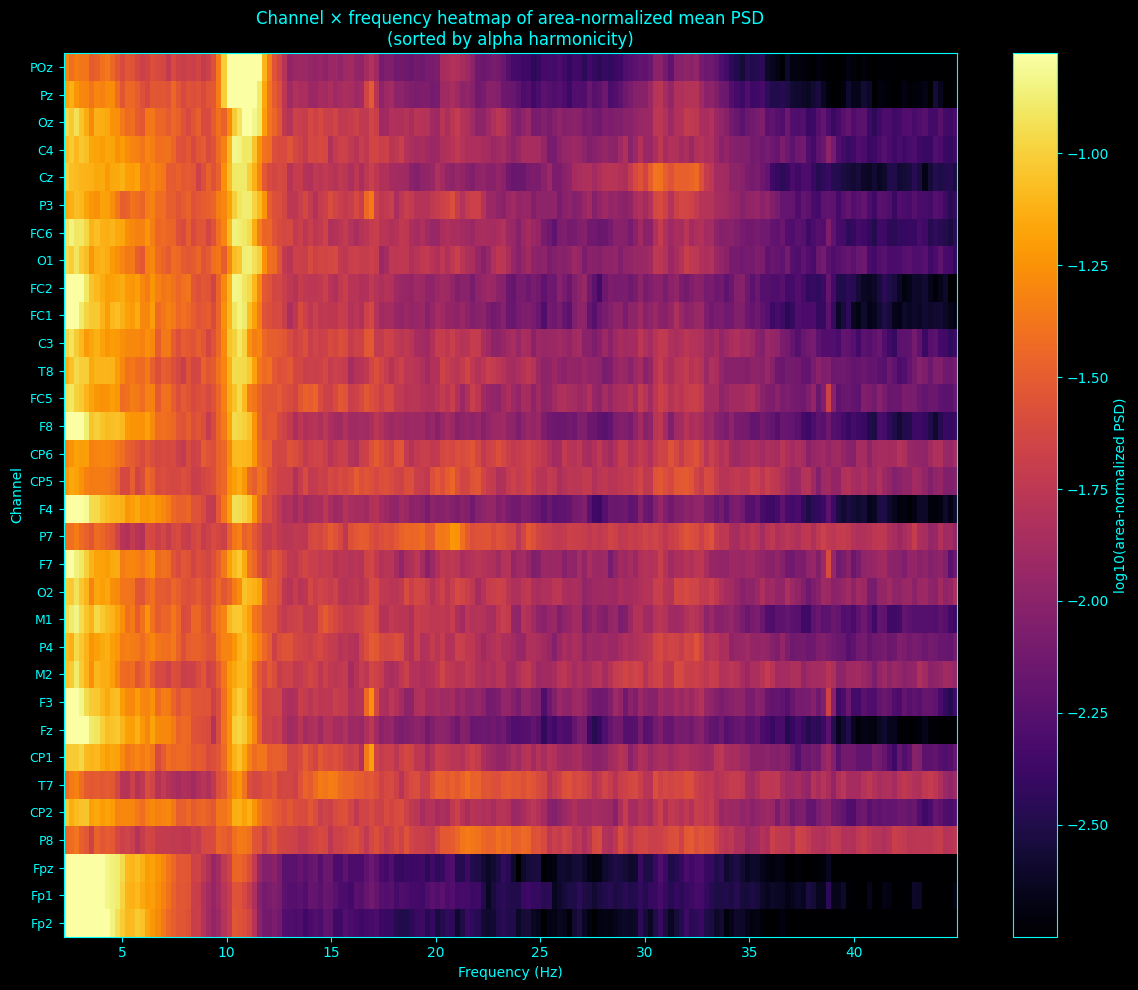

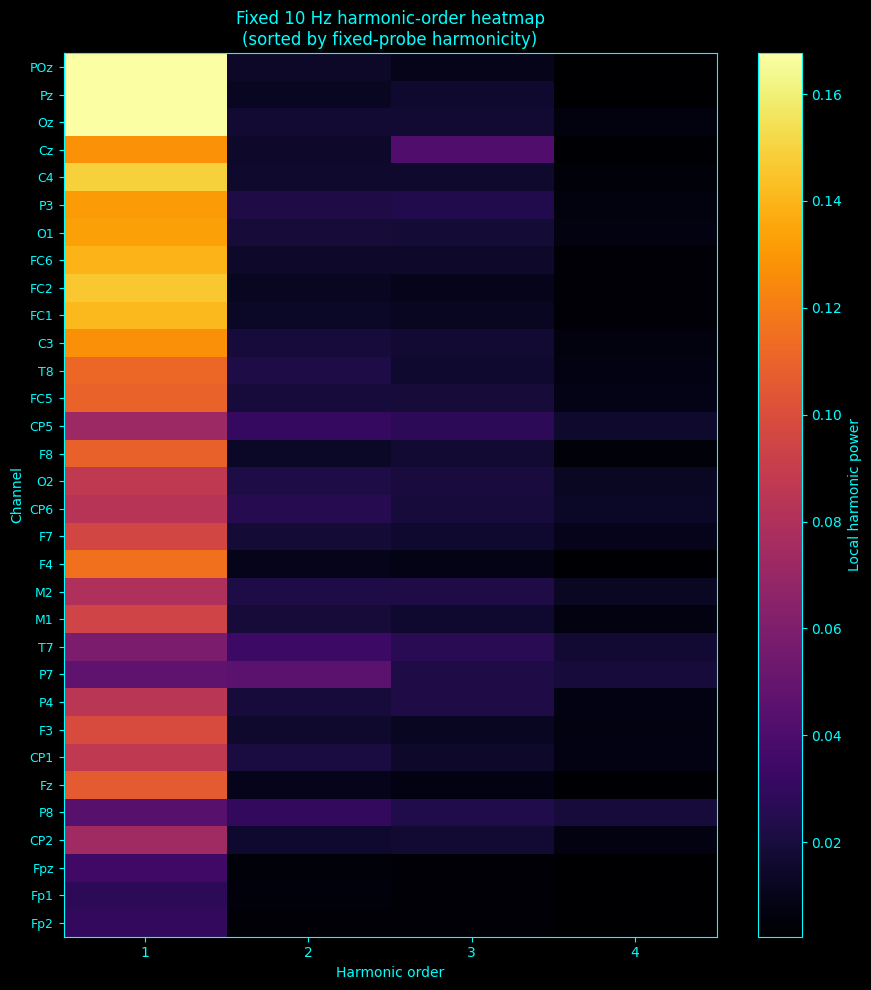

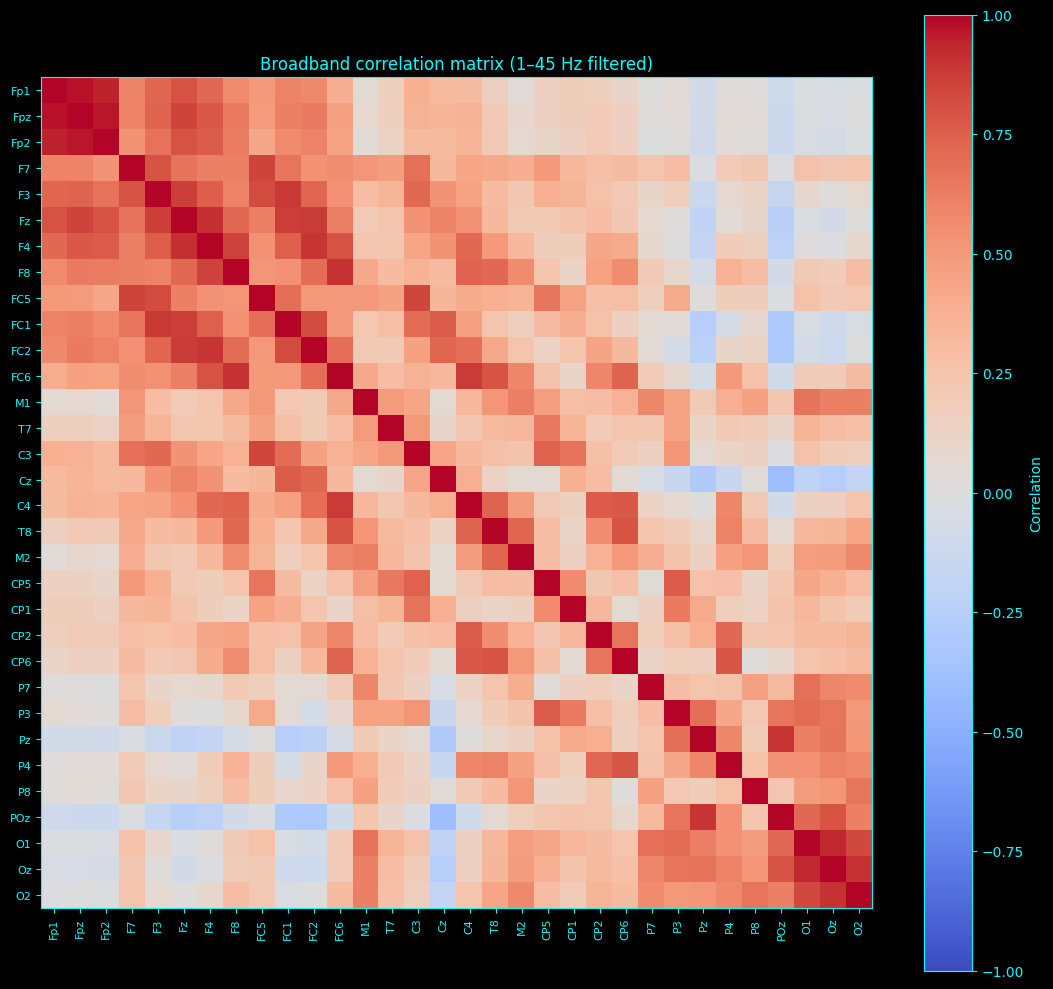

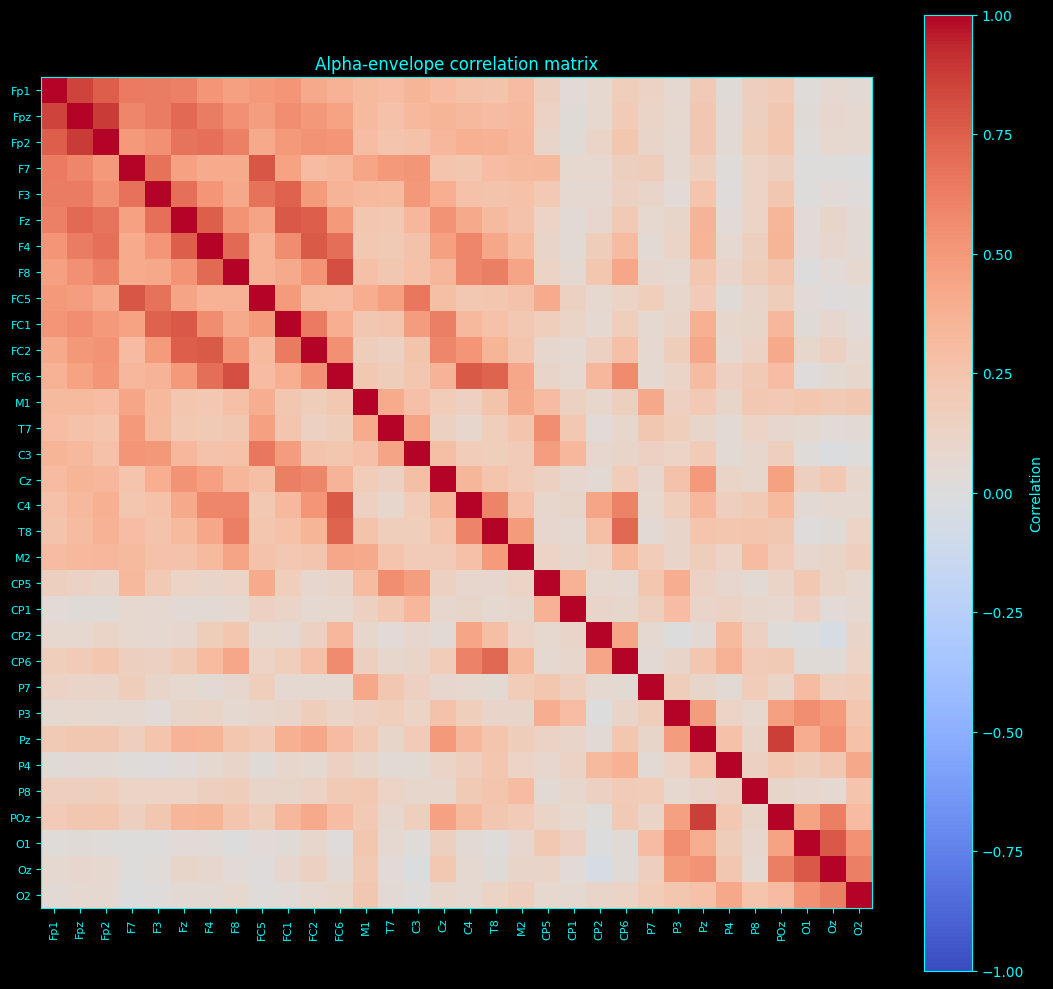

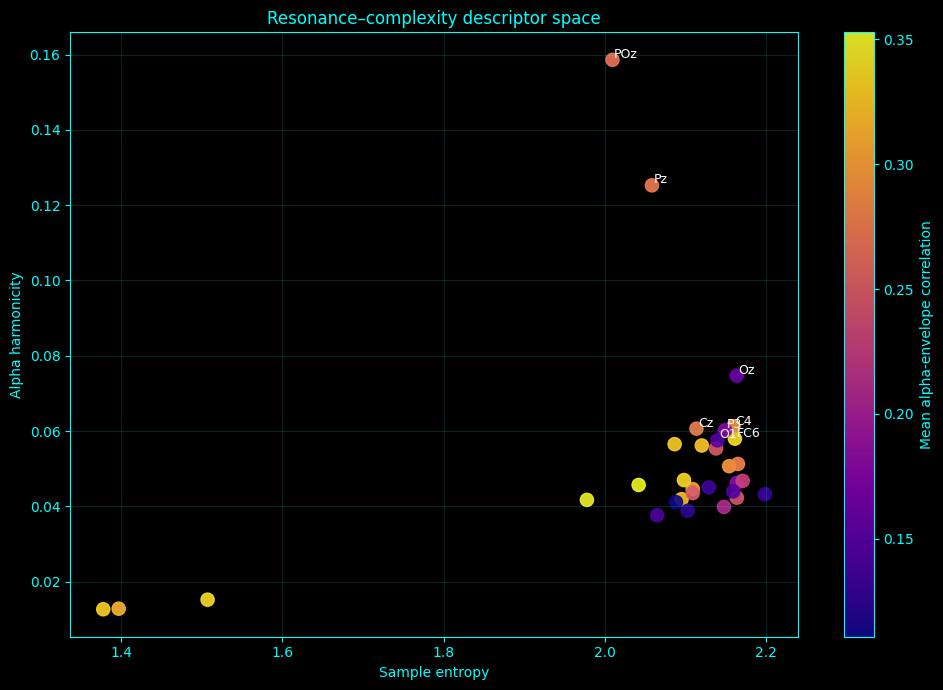

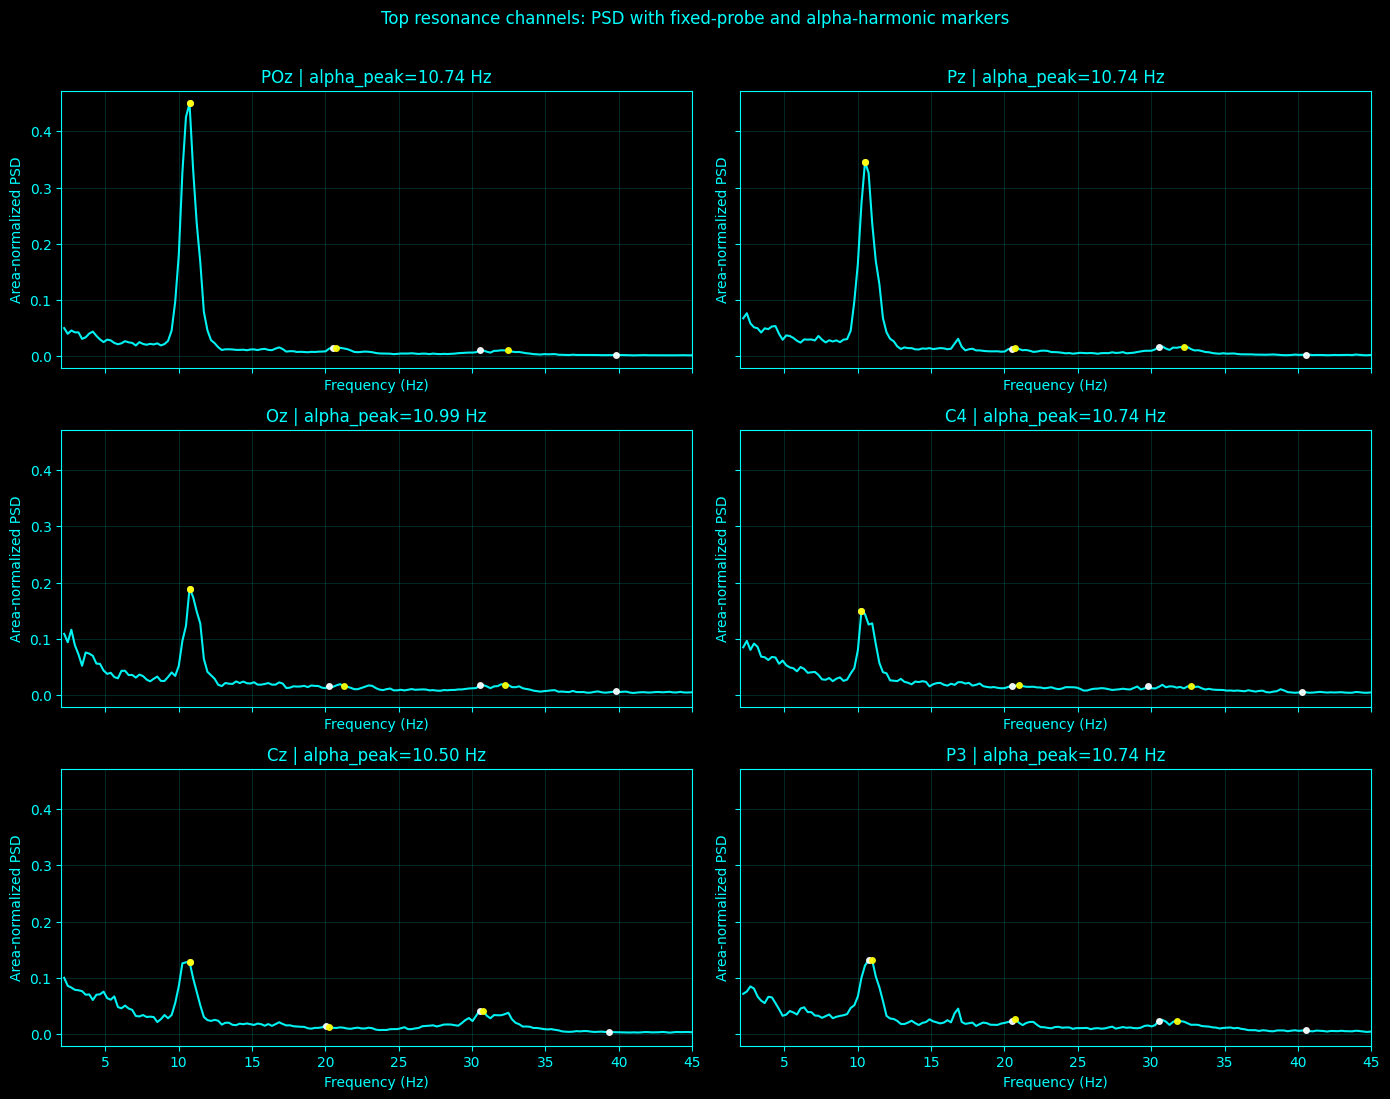

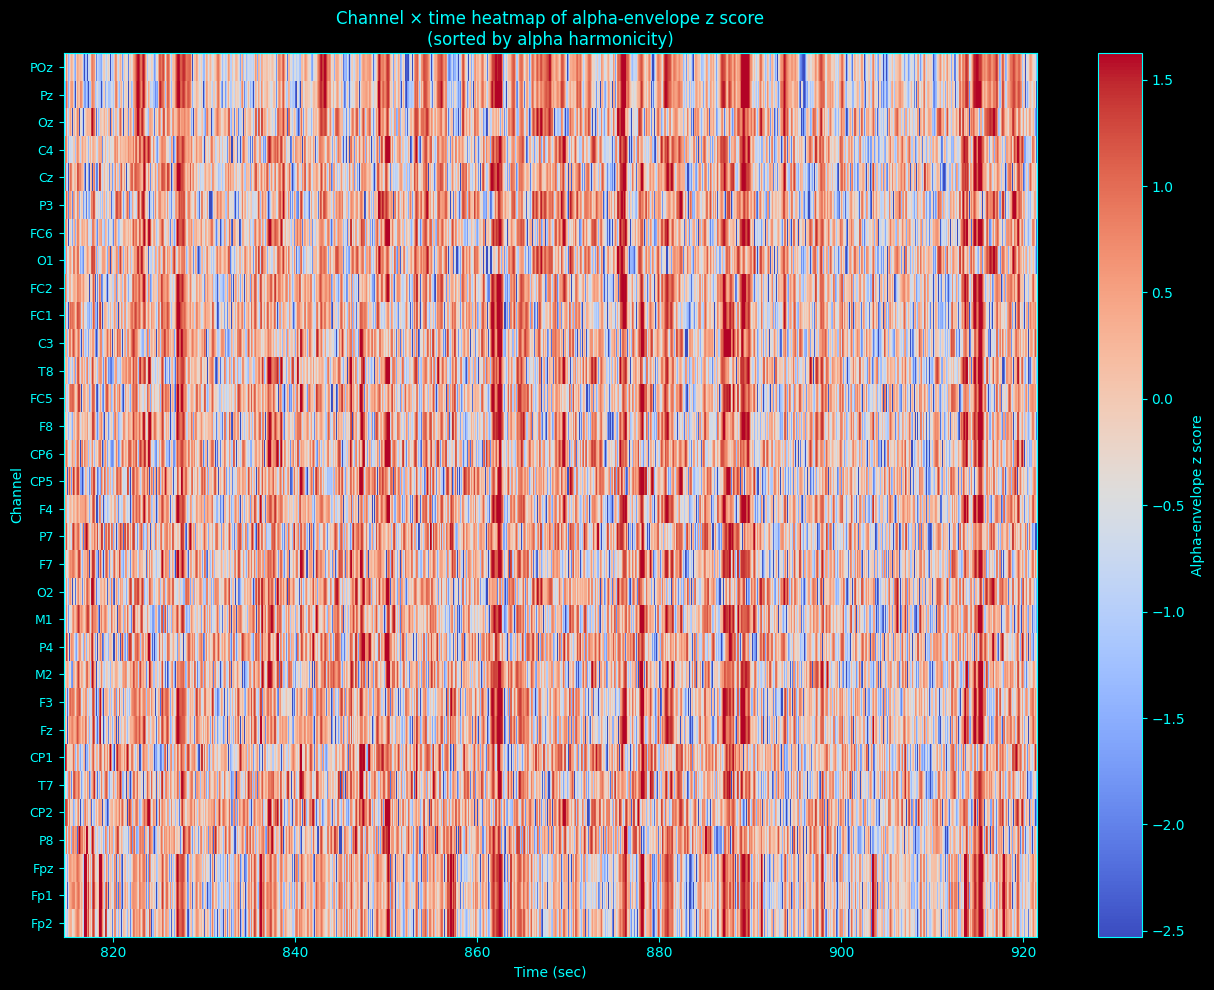


Saved dict NPY: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_resonance_coupling_complexity/ResonanceCouplingComplexity_x.npy
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_resonance_coupling_complexity/exploratory_resonance_coupling_complexity_outputs.npz
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_resonance_coupling_complexity/resonance_coupling_complexity_summary.csv
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_resonance_coupling_complexity/exploratory_resonance_coupling_complexity_notes.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_resonance_coupling_complexity/plots
Done.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import butter, sosfiltfilt, hilbert
import math

# -------------------------------------------------------
# NUMPY 1.x / 2.x COMPATIBILITY
# -------------------------------------------------------
if hasattr(np, "trapezoid"):
    integrate_trapezoid = np.trapezoid
else:
    integrate_trapezoid = np.trapz

# -------------------------------------------------------
# CONFIG — aligned to the upgraded scripts
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_resonance_coupling_complexity")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# -------------------------------------------------------
# THEORY / ANALYSIS DESIGN
# -------------------------------------------------------
# 1. Resonance scaffold
#    - Welch PSD on the selected segment
#    - fixed probe harmonics around a candidate 10 Hz scaffold
#    - channel-specific alpha-harmonic scaffold
#    - harmonicity scores, not just red dots
#
# 2. Coupling scaffold
#    - broadband correlation after mild physiological filtering
#    - alpha-envelope correlation from Hilbert envelopes
#    - coupling dissociation = alpha-envelope correlation minus broadband correlation
#
# 3. Complexity scaffold
#    - Hjorth activity / mobility / complexity
#    - line length
#    - permutation entropy
#    - sample entropy on a capped downsampled excerpt for exploratory tractability
#
# 4. Novel exploratory descriptor idea
#    - "resonance–complexity dissociation":
#      channels can be harmonically structured yet dynamically irregular,
#      or weakly harmonic but highly organized in envelopes.

analysis_band = (2.0, 45.0)
display_band = (2.0, 45.0)
alpha_band = (8.0, 13.0)
theta_band = (4.0, 8.0)
beta_band = (13.0, 30.0)
delta_band = (2.0, 4.0)
low_gamma_band = (30.0, 45.0)

band_defs = {
    "delta": delta_band,
    "theta": theta_band,
    "alpha": alpha_band,
    "beta": beta_band,
    "low_gamma": low_gamma_band,
}

# PSD / harmonic analysis
welch_window_sec = 4.0
welch_overlap = 0.50
welch_nfft = 4096
detrend_mode = "constant"

probe_fundamental_hz = 10.0
harmonic_tolerance_hz = 0.75
max_harmonic_hz = 40.0
harmonic_orders = np.arange(1, int(np.floor(max_harmonic_hz / probe_fundamental_hz)) + 1)
probe_harmonic_targets_hz = probe_fundamental_hz * harmonic_orders

# Preprocessing
apply_common_average_reference = False

# Correlation analysis
broadband_highpass_hz = 1.0
broadband_lowpass_hz = 45.0
corr_downsample_factor = 5
fs_corr = sampling_rate / corr_downsample_factor  # 200 Hz

alpha_env_downsample_factor = 5
fs_alpha_env = sampling_rate / alpha_env_downsample_factor  # 200 Hz

# Complexity analysis
complexity_highpass_hz = 1.0
complexity_downsample_factor = 10
fs_complexity = sampling_rate / complexity_downsample_factor  # 100 Hz

# Sample entropy is expensive; cap length intentionally for exploratory work.
sample_entropy_m = 2
sample_entropy_r_fraction = 0.20
sample_entropy_max_points = 2500

# Permutation entropy
perm_entropy_order = 5
perm_entropy_delay = 1

# Channels
eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

roi_definitions = {
    "frontal":   ['Fp1', 'Fpz', 'Fp2', 'F3', 'Fz', 'F4'],
    "central":   ['C3', 'Cz', 'C4'],
    "posterior": ['P3', 'Pz', 'P4', 'O1', 'Oz', 'O2'],
}

eps = 1e-12
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def band_mask(freqs_hz, band):
    lo, hi = band
    return (freqs_hz >= lo) & (freqs_hz <= hi)

def smooth_1d(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def zscore_1d(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    return (x - mu) / (sd + eps)

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def welch_psd(y, fs, window_sec=4.0, overlap=0.5, detrend="constant", nfft=None):
    nperseg = min(int(round(window_sec * fs)), len(y))
    nperseg = max(nperseg, min(256, len(y)))
    noverlap = min(int(round(overlap * nperseg)), nperseg - 1)

    freqs_hz, pxx = signal.welch(
        y,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        scaling="density",
        nfft=nfft,
    )
    return freqs_hz, pxx

def area_normalize_1d(freqs_hz, x, band):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    mask = band_mask(freqs_hz, band) & np.isfinite(x) & (x >= 0)
    if np.sum(mask) < 2:
        return out

    area = integrate_trapezoid(x[mask], freqs_hz[mask])
    if not np.isfinite(area) or area <= 0:
        return out

    out[mask] = x[mask] / area
    return out

def integrate_band_1d(freqs_hz, x, band):
    mask = band_mask(freqs_hz, band) & np.isfinite(x)
    if np.sum(mask) < 2:
        return np.nan
    return float(integrate_trapezoid(x[mask], freqs_hz[mask]))

def spectral_entropy_from_psd(freqs_hz, pxx, band=(2.0, 45.0), normalize=True):
    mask = band_mask(freqs_hz, band) & np.isfinite(pxx) & (pxx >= 0)
    if np.sum(mask) < 2:
        return np.nan, np.nan

    f = freqs_hz[mask]
    p = np.asarray(pxx[mask], dtype=float)

    area = integrate_trapezoid(p, f)
    if not np.isfinite(area) or area <= 0:
        return np.nan, np.nan

    p = p / area
    p = p / (np.sum(p) + eps)

    H = -np.sum(p * np.log(p + eps))
    Hmax = np.log(len(p) + eps)
    Hn = H / (Hmax + eps) if normalize else H
    return float(H), float(Hn)

def spectral_centroid_from_psd(freqs_hz, pxx, band=(2.0, 45.0)):
    mask = band_mask(freqs_hz, band) & np.isfinite(pxx) & (pxx >= 0)
    if np.sum(mask) < 2:
        return np.nan
    f = freqs_hz[mask]
    p = np.asarray(pxx[mask], dtype=float)
    s = np.sum(p)
    if s <= 0:
        return np.nan
    return float(np.sum(f * p) / (s + eps))

def robust_peak_in_band(freqs_hz, spectrum_1d, band=(8.0, 13.0), smooth_win=7):
    mask = band_mask(freqs_hz, band) & np.isfinite(spectrum_1d)
    if np.sum(mask) < 5:
        return np.nan, np.nan, np.nan, np.nan, False

    f = freqs_hz[mask]
    y = smooth_1d(spectrum_1d[mask], win=smooth_win)

    peaks, _ = signal.find_peaks(y)
    if len(peaks) > 0:
        prominences = signal.peak_prominences(y, peaks)[0]
        valid = (peaks > 0) & (peaks < len(y) - 1)
        if np.any(valid):
            peaks = peaks[valid]
            prominences = prominences[valid]

            min_prominence = max(0.05 * np.nanmax(y), 1.5 * np.nanmedian(np.abs(np.diff(y))))
            strong = prominences >= min_prominence
            if np.any(strong):
                peaks = peaks[strong]
                prominences = prominences[strong]
                winner = int(np.argmax(prominences))
                peak_idx = peaks[winner]

                peak_freq = float(f[peak_idx])
                peak_height = float(y[peak_idx])
                peak_prominence = float(prominences[winner])
                peak_contrast = float(peak_height / (np.nanmedian(y) + eps))
                return peak_freq, peak_height, peak_prominence, peak_contrast, True

    idx = int(np.nanargmax(y))
    peak_freq = float(f[idx])
    peak_height = float(y[idx])
    peak_prominence = np.nan
    peak_contrast = float(peak_height / (np.nanmedian(y) + eps))
    return peak_freq, peak_height, peak_prominence, peak_contrast, False

def local_peak_band_power(freqs_hz, spectrum_1d, center_hz, tolerance_hz=0.75):
    lo = center_hz - tolerance_hz
    hi = center_hz + tolerance_hz
    mask = (freqs_hz >= lo) & (freqs_hz <= hi) & np.isfinite(spectrum_1d)
    if np.sum(mask) < 1:
        return np.nan, np.nan
    local_freqs = freqs_hz[mask]
    local_vals = spectrum_1d[mask]
    idx = int(np.nanargmax(local_vals))
    return float(local_freqs[idx]), float(local_vals[idx])

def harmonic_ladder_summary(freqs_hz, spectrum_1d, fundamental_hz, tolerance_hz=0.75, max_hz=40.0):
    targets = []
    powers = []
    observed_freqs = []

    if not np.isfinite(fundamental_hz) or fundamental_hz <= 0:
        return np.array([]), np.array([]), np.array([]), np.nan

    max_order = int(np.floor(max_hz / fundamental_hz))
    for order in range(1, max_order + 1):
        target = order * fundamental_hz
        obs_f, p = local_peak_band_power(freqs_hz, spectrum_1d, target, tolerance_hz=tolerance_hz)
        targets.append(target)
        observed_freqs.append(obs_f)
        powers.append(p)

    targets = np.asarray(targets, dtype=float)
    observed_freqs = np.asarray(observed_freqs, dtype=float)
    powers = np.asarray(powers, dtype=float)

    harmonicity = float(np.nanmean(powers)) if len(powers) else np.nan
    return targets, observed_freqs, powers, harmonicity

def butter_bandpass_sos(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = max(lowcut / nyq, 1e-6)
    high = min(highcut / nyq, 0.999)
    return butter(order, [low, high], btype="bandpass", output="sos")

def butter_highpass_sos(cutoff, fs, order=4):
    nyq = 0.5 * fs
    cut = max(cutoff / nyq, 1e-6)
    return butter(order, cut, btype="highpass", output="sos")

def butter_lowpass_sos(cutoff, fs, order=4):
    nyq = 0.5 * fs
    cut = min(cutoff / nyq, 0.999)
    return butter(order, cut, btype="lowpass", output="sos")

def filter_broadband(y, fs, highpass_hz=1.0, lowpass_hz=45.0, order=4):
    sos_hp = butter_highpass_sos(highpass_hz, fs, order=order)
    y = sosfiltfilt(sos_hp, y)
    sos_lp = butter_lowpass_sos(lowpass_hz, fs, order=order)
    y = sosfiltfilt(sos_lp, y)
    return y

def alpha_envelope(y, fs, alpha_band=(8.0, 13.0), order=4):
    sos = butter_bandpass_sos(alpha_band[0], alpha_band[1], fs, order=order)
    y_alpha = sosfiltfilt(sos, y)
    env = np.abs(hilbert(y_alpha))
    return y_alpha, env

def hjorth_parameters(x):
    x = np.asarray(x, dtype=float)
    dx = np.diff(x)
    ddx = np.diff(dx)

    activity = np.var(x)
    mobility = np.sqrt(np.var(dx) / (activity + eps))
    complexity = np.sqrt(np.var(ddx) / (np.var(dx) + eps)) / (mobility + eps)

    return float(activity), float(mobility), float(complexity)

def line_length(x):
    x = np.asarray(x, dtype=float)
    return float(np.mean(np.abs(np.diff(x))))

def zero_crossing_rate(x):
    x = np.asarray(x, dtype=float)
    s = np.sign(x)
    return float(np.mean(np.abs(np.diff(s)) > 0))



def permutation_entropy(x, order=5, delay=1, normalize=True):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < (order - 1) * delay + 1:
        return np.nan

    patterns = {}
    for i in range(n - (order - 1) * delay):
        window = x[i:i + order * delay:delay]
        key = tuple(np.argsort(window))
        patterns[key] = patterns.get(key, 0) + 1

    counts = np.asarray(list(patterns.values()), dtype=float)
    probs = counts / np.sum(counts)
    H = -np.sum(probs * np.log(probs + eps))

    if normalize:
        H /= np.log(math.factorial(order) + eps)

    return float(H)

def sample_entropy_limited(x, m=2, r_fraction=0.2, max_points=2500):
    """
    Exploratory sample entropy with a hard cap on points.
    This is intentionally coarse and local, not a long-record exact estimator.
    """
    x = np.asarray(x, dtype=float)
    if len(x) > max_points:
        idx = np.linspace(0, len(x) - 1, max_points).astype(int)
        x = x[idx]

    if len(x) < m + 2:
        return np.nan

    r = r_fraction * np.std(x)
    if r <= 0:
        return np.nan

    def _embed(sig, emb_dim):
        return np.asarray([sig[i:i + emb_dim] for i in range(len(sig) - emb_dim + 1)], dtype=float)

    xm = _embed(x, m)
    xm1 = _embed(x, m + 1)

    def _count_matches(mat):
        n = len(mat)
        if n < 2:
            return 0.0
        count = 0
        for i in range(n - 1):
            dist = np.max(np.abs(mat[i + 1:] - mat[i]), axis=1)
            count += np.sum(dist <= r)
        return float(count)

    B = _count_matches(xm)
    A = _count_matches(xm1)

    if B <= 0 or A <= 0:
        return np.nan

    return float(-np.log((A + eps) / (B + eps)))

def roi_average_vector(values, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]
    if len(idx) == 0:
        return np.nan
    return float(np.nanmean(values[idx]))

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Segment shape: {segment.shape}")

# -------------------------------------------------------
# RESONANCE SCAFFOLD
# -------------------------------------------------------
channel_dict = {}
summary_rows = []
mean_psd_matrix = []
fixed_harmonic_power_matrix = []
alpha_harmonic_power_matrix = []

freqs_ref = None
alpha_env_matrix_for_corr = []
broadband_matrix_for_corr = []
alpha_env_time_ref = None

for ch_i, ch_name in enumerate(eeg_channel_names):
    y = segment[:, ch_i]

    freqs_hz, pxx = welch_psd(
        y,
        fs=sampling_rate,
        window_sec=welch_window_sec,
        overlap=welch_overlap,
        detrend=detrend_mode,
        nfft=welch_nfft,
    )

    if freqs_ref is None:
        freqs_ref = freqs_hz

    mean_psd_norm = area_normalize_1d(freqs_hz, pxx, analysis_band)

    alpha_peak_hz, alpha_peak_height, alpha_peak_prominence, alpha_peak_contrast, alpha_peak_is_local = robust_peak_in_band(
        freqs_hz,
        mean_psd_norm,
        band=alpha_band,
        smooth_win=7,
    )

    fixed_targets, fixed_obs, fixed_powers, fixed_harmonicity = harmonic_ladder_summary(
        freqs_hz,
        mean_psd_norm,
        fundamental_hz=probe_fundamental_hz,
        tolerance_hz=harmonic_tolerance_hz,
        max_hz=max_harmonic_hz,
    )

    alpha_targets, alpha_obs, alpha_powers, alpha_harmonicity = harmonic_ladder_summary(
        freqs_hz,
        mean_psd_norm,
        fundamental_hz=alpha_peak_hz,
        tolerance_hz=harmonic_tolerance_hz,
        max_hz=max_harmonic_hz,
    )

    alpha_rel = integrate_band_1d(freqs_hz, mean_psd_norm, alpha_band)
    theta_rel = integrate_band_1d(freqs_hz, mean_psd_norm, theta_band)
    beta_rel = integrate_band_1d(freqs_hz, mean_psd_norm, beta_band)
    delta_rel = integrate_band_1d(freqs_hz, mean_psd_norm, delta_band)
    gamma_rel = integrate_band_1d(freqs_hz, mean_psd_norm, low_gamma_band)

    centroid_hz = spectral_centroid_from_psd(freqs_hz, pxx, band=analysis_band)
    _, entropy_norm = spectral_entropy_from_psd(freqs_hz, pxx, band=analysis_band, normalize=True)

    # Resonance vs alpha anchoring
    alpha_vs_probe_gap = (
        alpha_peak_hz - probe_fundamental_hz
        if np.isfinite(alpha_peak_hz)
        else np.nan
    )

    channel_dict[ch_name] = {
        "frequencies_hz": freqs_hz,
        "mean_psd_area_norm_2_45Hz": mean_psd_norm,
        "alpha_peak_frequency_Hz": alpha_peak_hz,
        "fixed_probe_harmonic_targets_Hz": fixed_targets,
        "fixed_probe_harmonic_observed_Hz": fixed_obs,
        "fixed_probe_harmonic_powers": fixed_powers,
        "alpha_harmonic_targets_Hz": alpha_targets,
        "alpha_harmonic_observed_Hz": alpha_obs,
        "alpha_harmonic_powers": alpha_powers,
    }

    summary_rows.append({
        "channel": ch_name,
        "alpha_peak_frequency_Hz": alpha_peak_hz,
        "alpha_peak_height_area_norm": alpha_peak_height,
        "alpha_peak_prominence": alpha_peak_prominence,
        "alpha_peak_contrast": alpha_peak_contrast,
        "alpha_peak_is_local": bool(alpha_peak_is_local),
        "fixed_probe_harmonicity_10Hz": fixed_harmonicity,
        "alpha_harmonicity": alpha_harmonicity,
        "alpha_relative_power_2_45Hz": alpha_rel,
        "theta_relative_power_2_45Hz": theta_rel,
        "beta_relative_power_2_45Hz": beta_rel,
        "delta_relative_power_2_45Hz": delta_rel,
        "low_gamma_relative_power_2_45Hz": gamma_rel,
        "spectral_centroid_Hz_2_45Hz": centroid_hz,
        "spectral_entropy_normalized_2_45Hz": entropy_norm,
        "alpha_vs_probe_gap_Hz": alpha_vs_probe_gap,
    })

    mean_psd_matrix.append(mean_psd_norm)

    fixed_pad = np.full(len(harmonic_orders), np.nan, dtype=float)
    fixed_pad[:len(fixed_powers)] = fixed_powers
    fixed_harmonic_power_matrix.append(fixed_pad)

    alpha_pad = np.full(len(harmonic_orders), np.nan, dtype=float)
    alpha_pad[:len(alpha_powers)] = alpha_powers
    alpha_harmonic_power_matrix.append(alpha_pad)

    # ---------------------------------------------------
    # COUPLING SCAFFOLD PREP
    # ---------------------------------------------------
    y_broad = filter_broadband(y, sampling_rate, broadband_highpass_hz, broadband_lowpass_hz, order=4)
    y_broad_ds = signal.resample_poly(y_broad, up=1, down=corr_downsample_factor)
    broadband_matrix_for_corr.append(y_broad_ds)

    _, env = alpha_envelope(y, sampling_rate, alpha_band=alpha_band, order=4)
    env_ds = signal.resample_poly(env, up=1, down=alpha_env_downsample_factor)
    env_logz = zscore_1d(np.log10(env_ds + eps))
    alpha_env_matrix_for_corr.append(env_logz)

summary_df = pd.DataFrame(summary_rows)
for col in summary_df.columns:
    if col != "channel":
        summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

mean_psd_matrix = np.column_stack(mean_psd_matrix)
fixed_harmonic_power_matrix = np.vstack(fixed_harmonic_power_matrix)
alpha_harmonic_power_matrix = np.vstack(alpha_harmonic_power_matrix)

broadband_matrix_for_corr = np.vstack(broadband_matrix_for_corr)
alpha_env_matrix_for_corr = np.vstack(alpha_env_matrix_for_corr)

# -------------------------------------------------------
# COUPLING SCAFFOLD
# -------------------------------------------------------
broadband_corr = np.corrcoef(broadband_matrix_for_corr)
alpha_env_corr = np.corrcoef(alpha_env_matrix_for_corr)
coupling_dissociation = alpha_env_corr - broadband_corr

mean_broadband_corr = np.nanmean(np.where(np.eye(len(eeg_channel_names), dtype=bool), np.nan, broadband_corr), axis=1)
mean_alpha_env_corr = np.nanmean(np.where(np.eye(len(eeg_channel_names), dtype=bool), np.nan, alpha_env_corr), axis=1)
mean_coupling_dissociation = np.nanmean(np.where(np.eye(len(eeg_channel_names), dtype=bool), np.nan, coupling_dissociation), axis=1)

summary_df["mean_broadband_correlation"] = mean_broadband_corr
summary_df["mean_alpha_envelope_correlation"] = mean_alpha_env_corr
summary_df["mean_coupling_dissociation"] = mean_coupling_dissociation

# -------------------------------------------------------
# COMPLEXITY SCAFFOLD
# -------------------------------------------------------
for ch_i, ch_name in enumerate(eeg_channel_names):
    y = segment[:, ch_i]
    y_hp = sosfiltfilt(butter_highpass_sos(complexity_highpass_hz, sampling_rate, order=4), y)
    y_cmp = signal.resample_poly(y_hp, up=1, down=complexity_downsample_factor)

    activity, mobility, complexity = hjorth_parameters(y_cmp)
    ll = line_length(y_cmp)
    zcr = zero_crossing_rate(y_cmp)
    pe = permutation_entropy(y_cmp, order=perm_entropy_order, delay=perm_entropy_delay, normalize=True)
    se = sample_entropy_limited(
        y_cmp,
        m=sample_entropy_m,
        r_fraction=sample_entropy_r_fraction,
        max_points=sample_entropy_max_points,
    )

    # Novel exploratory dissociation:
    # channels can be harmonically structured but still locally irregular.
    alpha_harmonicity = summary_df.loc[summary_df["channel"] == ch_name, "alpha_harmonicity"].iloc[0]
    fixed_harmonicity = summary_df.loc[summary_df["channel"] == ch_name, "fixed_probe_harmonicity_10Hz"].iloc[0]
    resonance_complexity_dissociation = (
        alpha_harmonicity / (se + eps)
        if np.isfinite(alpha_harmonicity) and np.isfinite(se)
        else np.nan
    )

    summary_df.loc[summary_df["channel"] == ch_name, "hjorth_activity"] = activity
    summary_df.loc[summary_df["channel"] == ch_name, "hjorth_mobility"] = mobility
    summary_df.loc[summary_df["channel"] == ch_name, "hjorth_complexity"] = complexity
    summary_df.loc[summary_df["channel"] == ch_name, "line_length"] = ll
    summary_df.loc[summary_df["channel"] == ch_name, "zero_crossing_rate"] = zcr
    summary_df.loc[summary_df["channel"] == ch_name, "permutation_entropy"] = pe
    summary_df.loc[summary_df["channel"] == ch_name, "sample_entropy"] = se
    summary_df.loc[summary_df["channel"] == ch_name, "resonance_complexity_dissociation"] = resonance_complexity_dissociation

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
dict_npy_path = os.path.join(out_dir, "ResonanceCouplingComplexity_x.npy")
npz_path = os.path.join(out_dir, "exploratory_resonance_coupling_complexity_outputs.npz")
summary_csv_path = os.path.join(out_dir, "resonance_coupling_complexity_summary.csv")
notes_txt_path = os.path.join(out_dir, "exploratory_resonance_coupling_complexity_notes.txt")

np.save(dict_npy_path, channel_dict, allow_pickle=True)

np.savez_compressed(
    npz_path,
    frequencies_hz=freqs_ref,
    mean_psd_area_norm_2_45Hz=mean_psd_matrix,
    fixed_probe_harmonic_power_matrix=fixed_harmonic_power_matrix,
    alpha_harmonic_power_matrix=alpha_harmonic_power_matrix,
    probe_harmonic_targets_hz=probe_harmonic_targets_hz,
    harmonic_orders=harmonic_orders,
    broadband_corr=broadband_corr,
    alpha_env_corr=alpha_env_corr,
    coupling_dissociation=coupling_dissociation,
    channel_names=np.array(eeg_channel_names, dtype=object),
    start_time=start_time,
    end_time=end_time,
    sampling_rate=sampling_rate,
    fs_corr=fs_corr,
    fs_alpha_env=fs_alpha_env,
    fs_complexity=fs_complexity,
)

summary_df.to_csv(summary_csv_path, index=False)

top_alpha = summary_df.sort_values("alpha_relative_power_2_45Hz", ascending=False).head(8)
top_fixed_harm = summary_df.sort_values("fixed_probe_harmonicity_10Hz", ascending=False).head(8)
top_alpha_harm = summary_df.sort_values("alpha_harmonicity", ascending=False).head(8)
top_sample_entropy = summary_df.sort_values("sample_entropy", ascending=False).head(8)

with open(notes_txt_path, "w") as f:
    f.write("Exploratory resonance–coupling–complexity atlas notes\n")
    f.write("=====================================================\n\n")
    f.write("Intent:\n")
    f.write("This pass reorganizes harmonic inspection, channel coupling, and dynamical irregularity into a single exploratory framework.\n")
    f.write("It is for expert hypothesis generation, not publishing, not benchmarking, and not scoring.\n\n")
    f.write("Major upgrades relative to the pasted script:\n")
    f.write("1. Uses the selected segment of interest directly instead of ambiguous stimulation slicing.\n")
    f.write("2. Replaces ad hoc harmonic dots with harmonicity summaries.\n")
    f.write("3. Separates broadband coupling from alpha-envelope coupling.\n")
    f.write("4. Replaces seaborn dependency with direct matplotlib heatmaps.\n")
    f.write("5. Expands complexity beyond Hjorth + approximate entropy with line length and permutation entropy.\n")
    f.write("6. Adds resonance–complexity dissociation as a novelty-focused exploratory descriptor.\n\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Analysis band: [{analysis_band[0]:.1f}, {analysis_band[1]:.1f}] Hz\n")
    f.write(f"Probe fundamental: {probe_fundamental_hz:.2f} Hz\n")
    f.write(f"Harmonic tolerance: ±{harmonic_tolerance_hz:.2f} Hz\n")
    f.write(f"Common average reference applied: {apply_common_average_reference}\n\n")

    f.write("Top alpha-relative-power channels:\n")
    for _, row in top_alpha.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"alpha_rel={row['alpha_relative_power_2_45Hz']:.4f}, "
            f"alpha_peak={row['alpha_peak_frequency_Hz']}, "
            f"alpha_harmonicity={row['alpha_harmonicity']:.5f}\n"
        )

    f.write("\nTop fixed-probe harmonicity channels:\n")
    for _, row in top_fixed_harm.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"fixed10_harmonicity={row['fixed_probe_harmonicity_10Hz']:.5f}, "
            f"mean_alpha_env_corr={row['mean_alpha_envelope_correlation']:.4f}, "
            f"sample_entropy={row['sample_entropy']}\n"
        )

    f.write("\nTop alpha-harmonicity channels:\n")
    for _, row in top_alpha_harm.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"alpha_harmonicity={row['alpha_harmonicity']:.5f}, "
            f"alpha_peak={row['alpha_peak_frequency_Hz']}, "
            f"res_complex_dissociation={row['resonance_complexity_dissociation']}\n"
        )

    f.write("\nHighest sample-entropy channels:\n")
    for _, row in top_sample_entropy.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"sample_entropy={row['sample_entropy']}, "
            f"permutation_entropy={row['permutation_entropy']:.4f}, "
            f"fixed10_harmonicity={row['fixed_probe_harmonicity_10Hz']:.5f}\n"
        )

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------

# 1) Channel × frequency heatmap of mean PSD, sorted by alpha harmonicity
sort_df = summary_df.sort_values(
    by=["alpha_harmonicity", "alpha_relative_power_2_45Hz"],
    ascending=[False, False],
).reset_index(drop=True)
sorted_channels = list(sort_df["channel"].values)
sorted_idx = [eeg_channel_names.index(ch) for ch in sorted_channels]
display_mask = band_mask(freqs_ref, display_band)
freqs_display = freqs_ref[display_mask]

heat = np.log10(mean_psd_matrix[display_mask][:, sorted_idx].T + 1e-6)
vmin, vmax = percentile_limits(heat, lo=2, hi=99)

fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    heat,
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
    extent=[freqs_display[0], freqs_display[-1], len(sorted_channels), 0],
)
ax.set_title("Channel × frequency heatmap of area-normalized mean PSD\n(sorted by alpha harmonicity)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(sorted_channels)) + 0.5)
ax.set_yticklabels(sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("log10(area-normalized PSD)", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "01_channel_frequency_heatmap_resonance_sorted.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Fixed 10 Hz harmonic order heatmap
sort_df = summary_df.sort_values("fixed_probe_harmonicity_10Hz", ascending=False).reset_index(drop=True)
sorted_channels = list(sort_df["channel"].values)
sorted_idx = [eeg_channel_names.index(ch) for ch in sorted_channels]

heat = fixed_harmonic_power_matrix[sorted_idx, :]
vmin, vmax = percentile_limits(heat, lo=2, hi=98)

fig, ax = plt.subplots(figsize=(9, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    heat,
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
)
ax.set_title("Fixed 10 Hz harmonic-order heatmap\n(sorted by fixed-probe harmonicity)")
ax.set_xlabel("Harmonic order")
ax.set_ylabel("Channel")
ax.set_xticks(np.arange(len(harmonic_orders)))
ax.set_xticklabels([str(o) for o in harmonic_orders])
ax.set_yticks(np.arange(len(sorted_channels)))
ax.set_yticklabels(sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Local harmonic power", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "02_fixed_probe_harmonic_order_heatmap.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Broadband correlation matrix
fig, ax = plt.subplots(figsize=(11, 10), facecolor=BG)
style_ax(ax, heatmap=True)
vmin, vmax = -1.0, 1.0
im = ax.imshow(broadband_corr, cmap="coolwarm", vmin=vmin, vmax=vmax)
ax.set_title("Broadband correlation matrix (1–45 Hz filtered)")
ax.set_xticks(np.arange(len(eeg_channel_names)))
ax.set_xticklabels(eeg_channel_names, rotation=90, fontsize=8)
ax.set_yticks(np.arange(len(eeg_channel_names)))
ax.set_yticklabels(eeg_channel_names, fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Correlation", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "03_broadband_correlation_matrix.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Alpha-envelope correlation matrix
fig, ax = plt.subplots(figsize=(11, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(alpha_env_corr, cmap="coolwarm", vmin=-1.0, vmax=1.0)
ax.set_title("Alpha-envelope correlation matrix")
ax.set_xticks(np.arange(len(eeg_channel_names)))
ax.set_xticklabels(eeg_channel_names, rotation=90, fontsize=8)
ax.set_yticks(np.arange(len(eeg_channel_names)))
ax.set_yticklabels(eeg_channel_names, fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Correlation", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "04_alpha_envelope_correlation_matrix.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Complexity / resonance descriptor space
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)
scatter = ax.scatter(
    summary_df["sample_entropy"].values,
    summary_df["alpha_harmonicity"].values,
    c=summary_df["mean_alpha_envelope_correlation"].values,
    s=90,
    alpha=0.9,
    cmap="plasma",
)

annotate_df = summary_df.sort_values("alpha_harmonicity", ascending=False).head(8)
for _, row in annotate_df.iterrows():
    if np.isfinite(row["sample_entropy"]) and np.isfinite(row["alpha_harmonicity"]):
        ax.text(
            row["sample_entropy"] + 0.002,
            row["alpha_harmonicity"] + 0.0005,
            row["channel"],
            color="white",
            fontsize=9,
        )

ax.set_title("Resonance–complexity descriptor space")
ax.set_xlabel("Sample entropy")
ax.set_ylabel("Alpha harmonicity")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Mean alpha-envelope correlation", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "05_resonance_complexity_descriptor_space.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 6) Top resonance channels: PSD with harmonic markers
top_channels = list(summary_df.sort_values("alpha_harmonicity", ascending=False).head(6)["channel"].values)

fig, axes = plt.subplots(3, 2, figsize=(14, 11), facecolor=BG, sharex=True, sharey=True)
axes = np.asarray(axes).ravel()

for ax, ch_name in zip(axes, top_channels):
    style_ax(ax)
    ch_idx = eeg_channel_names.index(ch_name)
    row = summary_df.loc[summary_df["channel"] == ch_name].iloc[0]
    channel_payload = channel_dict[ch_name]

    f = channel_payload["frequencies_hz"]
    p = channel_payload["mean_psd_area_norm_2_45Hz"]

    mask = band_mask(f, display_band)
    ax.plot(f[mask], p[mask], color=ACCENT, linewidth=1.5, alpha=0.95)

    # Fixed 10 Hz probe markers
    fixed_targets = channel_payload["fixed_probe_harmonic_targets_Hz"]
    fixed_obs = channel_payload["fixed_probe_harmonic_observed_Hz"]
    fixed_powers = channel_payload["fixed_probe_harmonic_powers"]
    for freq_obs, power_obs in zip(fixed_obs, fixed_powers):
        if np.isfinite(freq_obs) and np.isfinite(power_obs):
            ax.plot(freq_obs, power_obs, "o", color="white", markersize=4, alpha=0.9)

    # Alpha harmonic markers
    alpha_obs = channel_payload["alpha_harmonic_observed_Hz"]
    alpha_powers = channel_payload["alpha_harmonic_powers"]
    for freq_obs, power_obs in zip(alpha_obs, alpha_powers):
        if np.isfinite(freq_obs) and np.isfinite(power_obs):
            ax.plot(freq_obs, power_obs, "o", color="yellow", markersize=4, alpha=0.9)

    ax.set_title(f"{ch_name} | alpha_peak={row['alpha_peak_frequency_Hz']:.2f} Hz")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Area-normalized PSD")
    ax.set_xlim(display_band[0], display_band[1])

for ax in axes[len(top_channels):]:
    ax.axis("off")

fig.suptitle("Top resonance channels: PSD with fixed-probe and alpha-harmonic markers", color=ACCENT, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.savefig(os.path.join(plots_dir, "06_top_resonance_channels_psd_panels.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 7) Alpha-envelope heatmap, sorted by alpha harmonicity
sort_df = summary_df.sort_values(
    by=["alpha_harmonicity", "alpha_relative_power_2_45Hz"],
    ascending=[False, False],
).reset_index(drop=True)
sorted_channels = list(sort_df["channel"].values)
sorted_idx = [eeg_channel_names.index(ch) for ch in sorted_channels]

alpha_heat = alpha_env_matrix_for_corr[sorted_idx, :]
vmin, vmax = percentile_limits(alpha_heat, lo=2, hi=98)

time_alpha_env_sec = np.arange(alpha_heat.shape[1]) / fs_alpha_env + start_time

fig, ax = plt.subplots(figsize=(13, 10), facecolor=BG)
style_ax(ax, heatmap=True)
im = ax.imshow(
    alpha_heat,
    aspect="auto",
    interpolation="nearest",
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    extent=[time_alpha_env_sec[0], time_alpha_env_sec[-1], len(sorted_channels), 0],
)
ax.set_title("Channel × time heatmap of alpha-envelope z score\n(sorted by alpha harmonicity)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(len(sorted_channels)) + 0.5)
ax.set_yticklabels(sorted_channels, fontsize=9)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Alpha-envelope z score", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "07_alpha_envelope_heatmap_harmonicity_sorted.png"), dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved dict NPY: {dict_npy_path}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved summary CSV: {summary_csv_path}")
print(f"Saved notes TXT: {notes_txt_path}")
print(f"Saved plots to: {plots_dir}")
print("Done.")

Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Segment shape: (106944, 32)


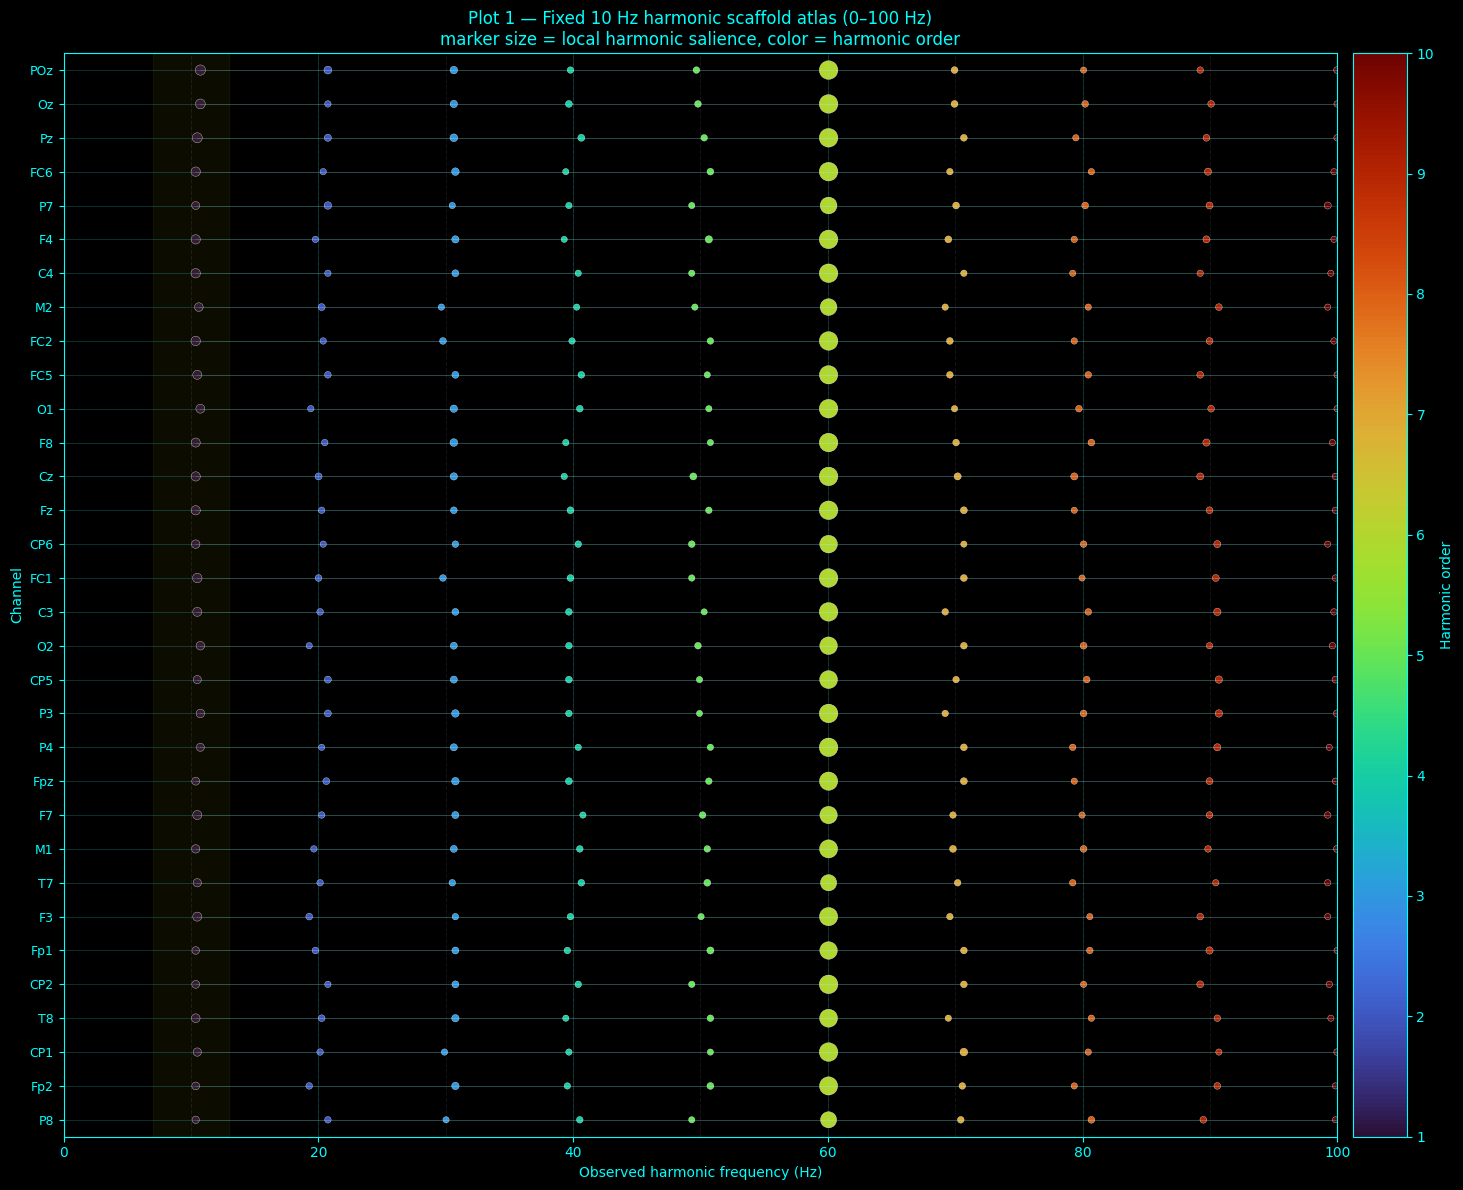

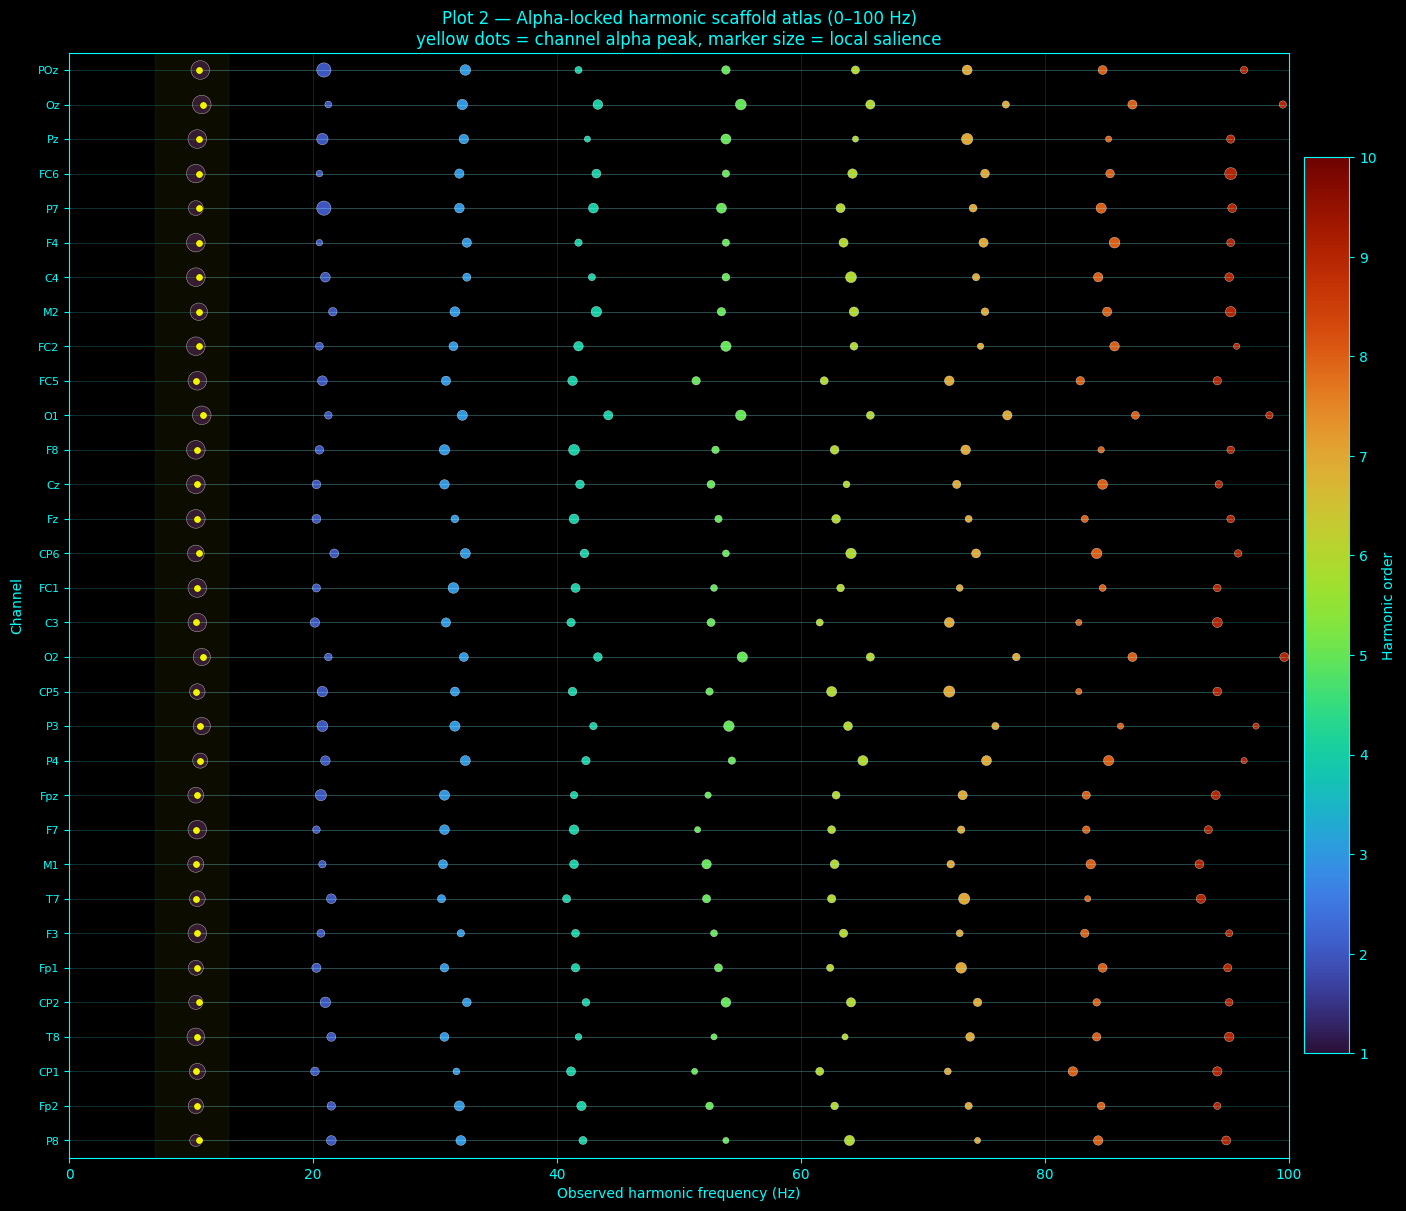

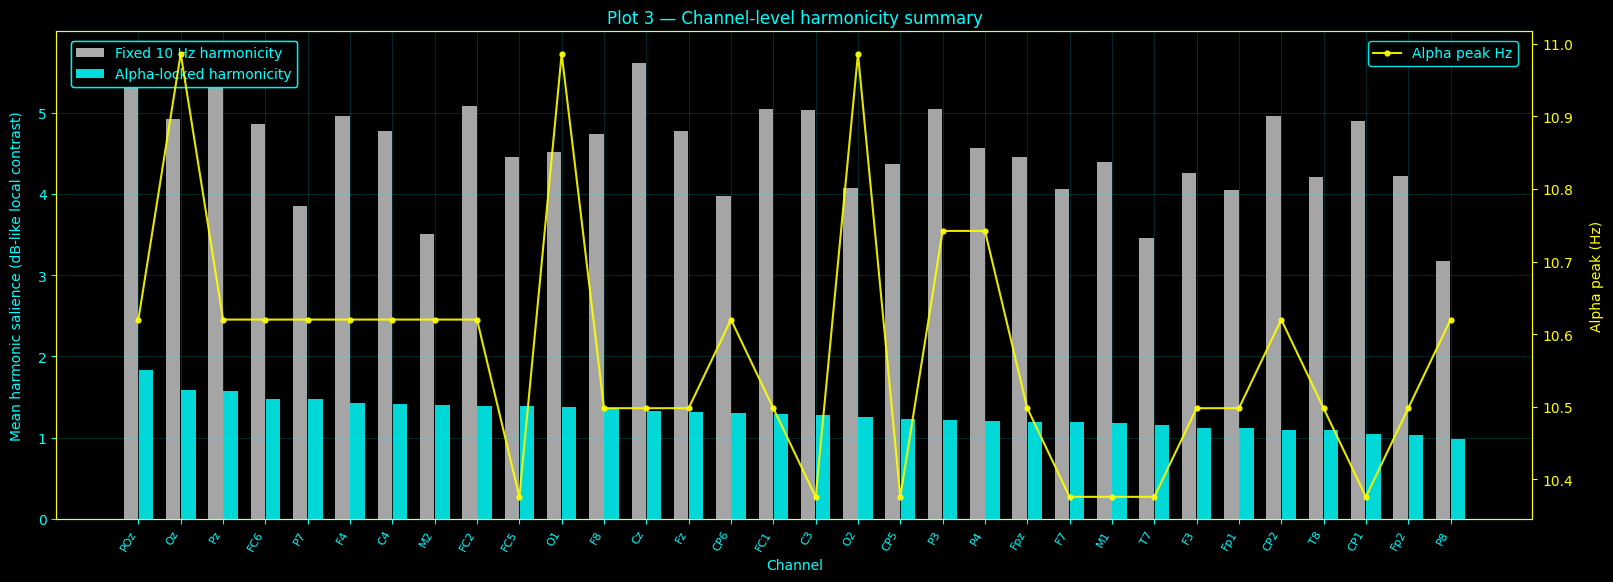


Saved harmonics dict: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_harmonic_composite_atlas/all_channel_harmonics_0_100Hz.npy
Saved long CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_harmonic_composite_atlas/harmonic_atlas_long_0_100Hz.csv
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_harmonic_composite_atlas/harmonic_atlas_channel_summary_0_100Hz.csv
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_harmonic_composite_atlas/harmonic_atlas_outputs_0_100Hz.npz
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_harmonic_composite_atlas/harmonic_atlas_notes_0_100Hz.txt
Saved plot 1: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_harmonic_composite_atlas/plots/plot1_fixed_10hz_harmonic_scaffold_0_100Hz.png
Saved plot 2: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_harmonic_composite_atla

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# -------------------------------------------------------
# NUMPY 1.x / 2.x COMPATIBILITY
# -------------------------------------------------------
if hasattr(np, "trapezoid"):
    integrate_trapezoid = np.trapezoid
else:
    integrate_trapezoid = np.trapz

# -------------------------------------------------------
# CONFIG — FILE PATHS ONLY, NO NOTEBOOK MEMORY
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_harmonic_composite_atlas")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# -------------------------------------------------------
# THEORY / DESIGN
# -------------------------------------------------------
display_band = (0.0, 100.0)
analysis_band = (2.0, 100.0)
alpha_band = (7.0, 13.0)

probe_fundamental_hz = 10.0
max_harmonic_hz = 100.0
harmonic_tolerance_hz = 0.80
local_baseline_halfwidth_hz = 2.0

harmonic_orders = np.arange(
    1,
    int(np.floor(max_harmonic_hz / probe_fundamental_hz)) + 1
)
probe_harmonic_targets_hz = probe_fundamental_hz * harmonic_orders

welch_window_sec = 4.0
welch_overlap = 0.50
welch_nfft = 8192
detrend_mode = "constant"
apply_common_average_reference = False

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

eps = 1e-12
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def band_mask(freqs_hz, band):
    lo, hi = band
    return (freqs_hz >= lo) & (freqs_hz <= hi)

def smooth_1d(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def welch_psd(y, fs, window_sec=4.0, overlap=0.5, detrend="constant", nfft=None):
    nperseg = min(int(round(window_sec * fs)), len(y))
    nperseg = max(nperseg, min(256, len(y)))
    noverlap = min(int(round(overlap * nperseg)), nperseg - 1)

    freqs_hz, pxx = signal.welch(
        y,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        scaling="density",
        nfft=nfft,
    )
    return freqs_hz, pxx

def area_normalize_1d(freqs_hz, x, band):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    mask = band_mask(freqs_hz, band) & np.isfinite(x) & (x >= 0)

    if np.sum(mask) < 2:
        return out

    area = integrate_trapezoid(x[mask], freqs_hz[mask])
    if not np.isfinite(area) or area <= 0:
        return out

    out[mask] = x[mask] / area
    return out

def integrate_band_1d(freqs_hz, x, band):
    mask = band_mask(freqs_hz, band) & np.isfinite(x)
    if np.sum(mask) < 2:
        return np.nan
    return float(integrate_trapezoid(x[mask], freqs_hz[mask]))

def spectral_entropy_from_spectrum(freqs_hz, spectrum_1d, band=(2.0, 100.0), normalize=True):
    mask = band_mask(freqs_hz, band) & np.isfinite(spectrum_1d) & (spectrum_1d >= 0)
    if np.sum(mask) < 2:
        return np.nan, np.nan

    f = freqs_hz[mask]
    p = np.asarray(spectrum_1d[mask], dtype=float)

    area = integrate_trapezoid(p, f)
    if not np.isfinite(area) or area <= 0:
        return np.nan, np.nan

    p = p / area
    p = p / (np.sum(p) + eps)

    H = -np.sum(p * np.log(p + eps))
    Hmax = np.log(len(p) + eps)
    Hn = H / (Hmax + eps) if normalize else H
    return float(H), float(Hn)

def spectral_centroid_from_spectrum(freqs_hz, spectrum_1d, band=(2.0, 100.0)):
    mask = band_mask(freqs_hz, band) & np.isfinite(spectrum_1d) & (spectrum_1d >= 0)
    if np.sum(mask) < 2:
        return np.nan
    f = freqs_hz[mask]
    p = np.asarray(spectrum_1d[mask], dtype=float)
    s = np.sum(p)
    if s <= 0:
        return np.nan
    return float(np.sum(f * p) / (s + eps))

def robust_peak_in_band(freqs_hz, spectrum_1d, band=(7.0, 13.0), smooth_win=7):
    mask = band_mask(freqs_hz, band) & np.isfinite(spectrum_1d)
    if np.sum(mask) < 5:
        return np.nan, np.nan, np.nan, np.nan, False

    f = freqs_hz[mask]
    y = smooth_1d(spectrum_1d[mask], win=smooth_win)

    peaks, _ = signal.find_peaks(y)
    if len(peaks) > 0:
        prominences = signal.peak_prominences(y, peaks)[0]
        valid = (peaks > 0) & (peaks < len(y) - 1)
        if np.any(valid):
            peaks = peaks[valid]
            prominences = prominences[valid]

            min_prominence = max(0.05 * np.nanmax(y), 1.5 * np.nanmedian(np.abs(np.diff(y))))
            strong = prominences >= min_prominence
            if np.any(strong):
                peaks = peaks[strong]
                prominences = prominences[strong]
                winner = int(np.argmax(prominences))
                peak_idx = peaks[winner]

                peak_freq = float(f[peak_idx])
                peak_height = float(y[peak_idx])
                peak_prominence = float(prominences[winner])
                peak_contrast = float(peak_height / (np.nanmedian(y) + eps))
                return peak_freq, peak_height, peak_prominence, peak_contrast, True

    idx = int(np.nanargmax(y))
    peak_freq = float(f[idx])
    peak_height = float(y[idx])
    peak_prominence = np.nan
    peak_contrast = float(peak_height / (np.nanmedian(y) + eps))
    return peak_freq, peak_height, peak_prominence, peak_contrast, False

def local_peak_stats(freqs_hz, spectrum_1d, target_hz, tolerance_hz=0.80, baseline_halfwidth_hz=2.0):
    target_mask = (freqs_hz >= target_hz - tolerance_hz) & (freqs_hz <= target_hz + tolerance_hz) & np.isfinite(spectrum_1d)
    if np.sum(target_mask) < 1:
        return np.nan, np.nan, np.nan, np.nan

    local_freqs = freqs_hz[target_mask]
    local_vals = spectrum_1d[target_mask]
    idx = int(np.nanargmax(local_vals))
    observed_hz = float(local_freqs[idx])
    peak_power = float(local_vals[idx])

    baseline_mask = (
        (freqs_hz >= target_hz - baseline_halfwidth_hz) &
        (freqs_hz <= target_hz + baseline_halfwidth_hz) &
        np.isfinite(spectrum_1d)
    )
    baseline_vals = spectrum_1d[baseline_mask]
    if len(baseline_vals) < 3:
        contrast_ratio = np.nan
        contrast_db = np.nan
    else:
        baseline_median = float(np.nanmedian(baseline_vals))
        contrast_ratio = peak_power / (baseline_median + eps)
        contrast_db = 10.0 * np.log10(contrast_ratio + eps)

    detuning_hz = observed_hz - target_hz
    return observed_hz, peak_power, contrast_db, detuning_hz

def harmonic_ladder_summary(freqs_hz, spectrum_1d, fundamental_hz, tolerance_hz=0.80, baseline_halfwidth_hz=2.0, max_hz=100.0):
    if not np.isfinite(fundamental_hz) or fundamental_hz <= 0:
        return []

    max_order = int(np.floor(max_hz / fundamental_hz))
    rows = []
    for order in range(1, max_order + 1):
        target_hz = order * fundamental_hz
        observed_hz, peak_power, contrast_db, detuning_hz = local_peak_stats(
            freqs_hz,
            spectrum_1d,
            target_hz,
            tolerance_hz=tolerance_hz,
            baseline_halfwidth_hz=baseline_halfwidth_hz,
        )
        rows.append({
            "order": order,
            "target_hz": target_hz,
            "observed_hz": observed_hz,
            "peak_power": peak_power,
            "contrast_db": contrast_db,
            "detuning_hz": detuning_hz,
        })
    return rows

def summarize_harmonic_family(rows):
    if len(rows) == 0:
        return np.nan, np.nan, np.nan

    df = pd.DataFrame(rows)
    if len(df) == 0:
        return np.nan, np.nan, np.nan

    harmonicity = float(np.nanmean(df["contrast_db"]))
    detuning = float(np.nanmean(np.abs(df["detuning_hz"])))
    mean_power = float(np.nanmean(df["peak_power"]))
    return harmonicity, detuning, mean_power

def marker_sizes_from_contrast(x_db, min_size=20, max_size=180):
    x = np.asarray(x_db, dtype=float)
    x = np.where(np.isfinite(x), x, np.nan)
    if np.all(~np.isfinite(x)):
        return np.full_like(x, min_size, dtype=float)
    lo = np.nanpercentile(x, 5)
    hi = np.nanpercentile(x, 95)
    if hi <= lo:
        return np.full_like(x, 0.5 * (min_size + max_size), dtype=float)
    z = (np.clip(x, lo, hi) - lo) / (hi - lo + eps)
    return min_size + z * (max_size - min_size)

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Segment shape: {segment.shape}")

# -------------------------------------------------------
# CORE HARMONIC ATLAS ANALYSIS
# -------------------------------------------------------
all_channel_harmonics = {}
long_rows = []
summary_rows = []
mean_psd_matrix = []
freqs_ref = None

for ch_i, ch_name in enumerate(eeg_channel_names):
    y = segment[:, ch_i]

    freqs_hz, pxx = welch_psd(
        y,
        fs=sampling_rate,
        window_sec=welch_window_sec,
        overlap=welch_overlap,
        detrend=detrend_mode,
        nfft=welch_nfft,
    )

    if freqs_ref is None:
        freqs_ref = freqs_hz.copy()

    psd_norm = area_normalize_1d(freqs_hz, pxx, analysis_band)
    mean_psd_matrix.append(psd_norm)

    alpha_peak_hz, alpha_peak_height, alpha_peak_prominence, alpha_peak_contrast, alpha_is_local = robust_peak_in_band(
        freqs_hz, psd_norm, band=alpha_band, smooth_win=7
    )

    fixed_rows = harmonic_ladder_summary(
        freqs_hz,
        psd_norm,
        fundamental_hz=probe_fundamental_hz,
        tolerance_hz=harmonic_tolerance_hz,
        baseline_halfwidth_hz=local_baseline_halfwidth_hz,
        max_hz=max_harmonic_hz,
    )

    alpha_rows = harmonic_ladder_summary(
        freqs_hz,
        psd_norm,
        fundamental_hz=alpha_peak_hz,
        tolerance_hz=harmonic_tolerance_hz,
        baseline_halfwidth_hz=local_baseline_halfwidth_hz,
        max_hz=max_harmonic_hz,
    )

    fixed_harmonicity, fixed_detuning, fixed_mean_power = summarize_harmonic_family(fixed_rows)
    alpha_harmonicity, alpha_detuning, alpha_mean_power = summarize_harmonic_family(alpha_rows)

    alpha_rel = integrate_band_1d(freqs_hz, psd_norm, alpha_band)
    theta_rel = integrate_band_1d(freqs_hz, psd_norm, (4.0, 8.0))
    beta_rel = integrate_band_1d(freqs_hz, psd_norm, (13.0, 30.0))
    gamma_rel = integrate_band_1d(freqs_hz, psd_norm, (30.0, 45.0))

    centroid_hz = spectral_centroid_from_spectrum(freqs_hz, pxx, band=analysis_band)
    _, entropy_norm = spectral_entropy_from_spectrum(freqs_hz, pxx, band=analysis_band, normalize=True)

    all_channel_harmonics[ch_name] = {
        "alpha_peak_hz": alpha_peak_hz,
        "fixed_10hz_harmonics": fixed_rows,
        "alpha_locked_harmonics": alpha_rows,
        "frequencies_hz": freqs_hz,
        "psd_area_norm_2_100Hz": psd_norm,
    }

    for row in fixed_rows:
        row_out = row.copy()
        row_out["channel"] = ch_name
        row_out["family"] = "fixed_10hz"
        row_out["alpha_peak_hz"] = alpha_peak_hz
        long_rows.append(row_out)

    for row in alpha_rows:
        row_out = row.copy()
        row_out["channel"] = ch_name
        row_out["family"] = "alpha_locked"
        row_out["alpha_peak_hz"] = alpha_peak_hz
        long_rows.append(row_out)

    summary_rows.append({
        "channel": ch_name,
        "alpha_peak_hz": alpha_peak_hz,
        "alpha_peak_prominence": alpha_peak_prominence,
        "alpha_peak_contrast": alpha_peak_contrast,
        "alpha_peak_is_local": bool(alpha_is_local),
        "fixed_10hz_harmonicity_db": fixed_harmonicity,
        "fixed_10hz_mean_abs_detuning_hz": fixed_detuning,
        "fixed_10hz_mean_power": fixed_mean_power,
        "alpha_locked_harmonicity_db": alpha_harmonicity,
        "alpha_locked_mean_abs_detuning_hz": alpha_detuning,
        "alpha_locked_mean_power": alpha_mean_power,
        "alpha_relative_power_2_100Hz": alpha_rel,
        "theta_relative_power_2_100Hz": theta_rel,
        "beta_relative_power_2_100Hz": beta_rel,
        "low_gamma_relative_power_2_100Hz": gamma_rel,
        "spectral_centroid_Hz_2_100Hz": centroid_hz,
        "spectral_entropy_normalized_2_100Hz": entropy_norm,
        "alpha_vs_probe_gap_hz": alpha_peak_hz - probe_fundamental_hz if np.isfinite(alpha_peak_hz) else np.nan,
        "resonance_selectivity": alpha_harmonicity - fixed_harmonicity if np.isfinite(alpha_harmonicity) and np.isfinite(fixed_harmonicity) else np.nan,
    })

harmonics_long_df = pd.DataFrame(long_rows)
summary_df = pd.DataFrame(summary_rows)

for col in summary_df.columns:
    if col != "channel":
        summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

mean_psd_matrix = np.column_stack(mean_psd_matrix)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
dict_npy_path = os.path.join(out_dir, "all_channel_harmonics_0_100Hz.npy")
long_csv_path = os.path.join(out_dir, "harmonic_atlas_long_0_100Hz.csv")
summary_csv_path = os.path.join(out_dir, "harmonic_atlas_channel_summary_0_100Hz.csv")
npz_path = os.path.join(out_dir, "harmonic_atlas_outputs_0_100Hz.npz")
notes_txt_path = os.path.join(out_dir, "harmonic_atlas_notes_0_100Hz.txt")

plot1_path = os.path.join(plots_dir, "plot1_fixed_10hz_harmonic_scaffold_0_100Hz.png")
plot2_path = os.path.join(plots_dir, "plot2_alpha_locked_harmonic_scaffold_0_100Hz.png")
plot3_path = os.path.join(plots_dir, "plot3_channel_harmonicity_summary_0_100Hz.png")

np.save(dict_npy_path, all_channel_harmonics, allow_pickle=True)
harmonics_long_df.to_csv(long_csv_path, index=False)
summary_df.to_csv(summary_csv_path, index=False)

np.savez_compressed(
    npz_path,
    channel_names=np.array(eeg_channel_names, dtype=object),
    frequencies_hz=freqs_ref,
    mean_psd_area_norm_2_100Hz=mean_psd_matrix,
    harmonic_orders=harmonic_orders,
    probe_harmonic_targets_hz=probe_harmonic_targets_hz,
    start_time=start_time,
    end_time=end_time,
    sampling_rate=sampling_rate,
)

top_alpha_locked = summary_df.sort_values("alpha_locked_harmonicity_db", ascending=False, na_position="last").head(8)
top_fixed = summary_df.sort_values("fixed_10hz_harmonicity_db", ascending=False, na_position="last").head(8)

with open(notes_txt_path, "w") as f:
    f.write("Exploratory harmonic composite atlas notes\n")
    f.write("=========================================\n\n")
    f.write("Intent:\n")
    f.write("This pass reframes the simple composite harmonics plot as a channel-by-channel harmonic atlas on the selected EEG segment.\n")
    f.write("It is for exploratory expert research, not publishing, not benchmarking, and not scoring.\n\n")
    f.write("Key upgrades relative to the original snippet:\n")
    f.write("1. Uses file paths only, not notebook-memory variables.\n")
    f.write("2. Uses the selected recording interval, not the full array by default.\n")
    f.write("3. Uses Welch PSD instead of arbitrary scatter power from unknown provenance.\n")
    f.write("4. Separates fixed 10 Hz scaffold from channel-specific alpha-locked scaffold.\n")
    f.write("5. Uses local harmonic salience and detuning, not distorted vertical power offsets.\n")
    f.write("6. Adds harmonicity, detuning, alpha anchoring, and resonance selectivity summaries.\n")
    f.write("7. Plot 2 and Plot 3 were separated into their own figures to eliminate text overlap.\n\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Display band: [{display_band[0]:.1f}, {display_band[1]:.1f}] Hz\n")
    f.write(f"Probe fundamental: {probe_fundamental_hz:.2f} Hz\n")
    f.write(f"Harmonic tolerance: ±{harmonic_tolerance_hz:.2f} Hz\n")
    f.write(f"Welch window: {welch_window_sec:.2f} sec\n\n")

    f.write("Top alpha-locked harmonicity channels:\n")
    for _, row in top_alpha_locked.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"alpha_peak={row['alpha_peak_hz']}, "
            f"alpha_locked_harmonicity_db={row['alpha_locked_harmonicity_db']:.3f}, "
            f"alpha_locked_mean_abs_detuning_hz={row['alpha_locked_mean_abs_detuning_hz']:.3f}\n"
        )

    f.write("\nTop fixed 10 Hz harmonicity channels:\n")
    for _, row in top_fixed.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"fixed_10hz_harmonicity_db={row['fixed_10hz_harmonicity_db']:.3f}, "
            f"fixed_10hz_mean_abs_detuning_hz={row['fixed_10hz_mean_abs_detuning_hz']:.3f}, "
            f"resonance_selectivity={row['resonance_selectivity']}\n"
        )

# -------------------------------------------------------
# PLOTTING — PREP
# -------------------------------------------------------
channel_order_df = summary_df.sort_values(
    by=["alpha_locked_harmonicity_db", "alpha_peak_hz"],
    ascending=[False, True],
    na_position="last"
).reset_index(drop=True)

ordered_channels = list(channel_order_df["channel"].values)
channel_to_y = {ch: i for i, ch in enumerate(ordered_channels)}

fixed_plot_df = harmonics_long_df[harmonics_long_df["family"] == "fixed_10hz"].copy()
alpha_plot_df = harmonics_long_df[harmonics_long_df["family"] == "alpha_locked"].copy()

fixed_plot_df["y"] = fixed_plot_df["channel"].map(channel_to_y)
alpha_plot_df["y"] = alpha_plot_df["channel"].map(channel_to_y)

fixed_plot_df["size"] = marker_sizes_from_contrast(fixed_plot_df["contrast_db"].values)
alpha_plot_df["size"] = marker_sizes_from_contrast(alpha_plot_df["contrast_db"].values)

cmap = plt.cm.turbo
order_norm_max = int(max(
    fixed_plot_df["order"].max() if len(fixed_plot_df) else 1,
    alpha_plot_df["order"].max() if len(alpha_plot_df) else 1,
))

# -------------------------------------------------------
# PLOT 1 — fixed 10 Hz scaffold
# -------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(16, 12), facecolor=BG)
style_ax(ax1)

for ch_name in ordered_channels:
    y = channel_to_y[ch_name]
    ax1.axhline(y, color="white", alpha=0.05, linewidth=0.6)

scatter1 = ax1.scatter(
    fixed_plot_df["observed_hz"].values,
    fixed_plot_df["y"].values,
    s=fixed_plot_df["size"].values,
    c=fixed_plot_df["order"].values,
    cmap=cmap,
    vmin=1,
    vmax=order_norm_max,
    alpha=0.9,
    edgecolors="white",
    linewidths=0.25,
)

for ch_name in ordered_channels:
    sub = fixed_plot_df[fixed_plot_df["channel"] == ch_name].sort_values("order")
    if len(sub) >= 2:
        ax1.plot(
            sub["observed_hz"].values,
            sub["y"].values,
            color="white",
            alpha=0.12,
            linewidth=0.8,
        )

for h in probe_harmonic_targets_hz:
    ax1.axvline(h, color="white", alpha=0.08, linestyle="--", linewidth=0.8)

ax1.axvspan(alpha_band[0], alpha_band[1], color="yellow", alpha=0.05)
ax1.set_xlim(display_band)
ax1.set_ylim(len(ordered_channels) - 0.5, -0.5)
ax1.set_yticks(np.arange(len(ordered_channels)))
ax1.set_yticklabels(ordered_channels, fontsize=9)
ax1.set_title("Plot 1 — Fixed 10 Hz harmonic scaffold atlas (0–100 Hz)\nmarker size = local harmonic salience, color = harmonic order")
ax1.set_xlabel("Observed harmonic frequency (Hz)")
ax1.set_ylabel("Channel")

cbar1 = plt.colorbar(scatter1, ax=ax1, pad=0.01)
cbar1.set_label("Harmonic order", color=ACCENT)
cbar1.outline.set_edgecolor(ACCENT)
cbar1.ax.tick_params(color=ACCENT)
for label in cbar1.ax.get_yticklabels():
    label.set_color(ACCENT)

fig1.tight_layout()
fig1.savefig(plot1_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig1)

# -------------------------------------------------------
# PLOT 2 — alpha-locked scaffold
# FIXED: larger figure, separate save, extra padding, smaller y text
# -------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(16, 13), facecolor=BG)
style_ax(ax2)

for ch_name in ordered_channels:
    y = channel_to_y[ch_name]
    ax2.axhline(y, color="white", alpha=0.05, linewidth=0.6)

scatter2 = ax2.scatter(
    alpha_plot_df["observed_hz"].values,
    alpha_plot_df["y"].values,
    s=alpha_plot_df["size"].values,
    c=alpha_plot_df["order"].values,
    cmap=cmap,
    vmin=1,
    vmax=order_norm_max,
    alpha=0.9,
    edgecolors="white",
    linewidths=0.25,
)

for ch_name in ordered_channels:
    sub = alpha_plot_df[alpha_plot_df["channel"] == ch_name].sort_values("order")
    if len(sub) >= 2:
        ax2.plot(
            sub["observed_hz"].values,
            sub["y"].values,
            color="white",
            alpha=0.12,
            linewidth=0.8,
        )

for _, row in channel_order_df.iterrows():
    if np.isfinite(row["alpha_peak_hz"]):
        ax2.scatter(
            [row["alpha_peak_hz"]],
            [channel_to_y[row["channel"]]],
            s=28,
            color="yellow",
            edgecolors="black",
            linewidths=0.3,
            alpha=0.95,
            zorder=5,
        )

ax2.axvspan(alpha_band[0], alpha_band[1], color="yellow", alpha=0.05)
ax2.set_xlim(display_band)
ax2.set_ylim(len(ordered_channels) - 0.5, -0.5)
ax2.set_yticks(np.arange(len(ordered_channels)))
ax2.set_yticklabels(ordered_channels, fontsize=8)
ax2.set_title("Plot 2 — Alpha-locked harmonic scaffold atlas (0–100 Hz)\nyellow dots = channel alpha peak, marker size = local salience")
ax2.set_xlabel("Observed harmonic frequency (Hz)")
ax2.set_ylabel("Channel", labelpad=10)

cbar2 = plt.colorbar(scatter2, ax=ax2, pad=0.012, fraction=0.035)
cbar2.set_label("Harmonic order", color=ACCENT)
cbar2.outline.set_edgecolor(ACCENT)
cbar2.ax.tick_params(color=ACCENT)
for label in cbar2.ax.get_yticklabels():
    label.set_color(ACCENT)

fig2.subplots_adjust(left=0.12, right=0.92, top=0.93, bottom=0.08)
fig2.savefig(plot2_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig2)

# -------------------------------------------------------
# PLOT 3 — channel summaries
# FIXED: separate figure, wider layout, smaller x labels, moved legends
# -------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(18, 7.5), facecolor=BG)
style_ax(ax3)

plot_df = channel_order_df.copy()
x = np.arange(len(plot_df))

bars1 = ax3.bar(
    x - 0.18,
    plot_df["fixed_10hz_harmonicity_db"].values,
    width=0.34,
    color="white",
    alpha=0.65,
    label="Fixed 10 Hz harmonicity",
)
bars2 = ax3.bar(
    x + 0.18,
    plot_df["alpha_locked_harmonicity_db"].values,
    width=0.34,
    color=ACCENT,
    alpha=0.85,
    label="Alpha-locked harmonicity",
)

ax3_twin = ax3.twinx()
line_alpha, = ax3_twin.plot(
    x,
    plot_df["alpha_peak_hz"].values,
    color="yellow",
    linewidth=1.5,
    marker="o",
    markersize=3.5,
    alpha=0.9,
    label="Alpha peak Hz",
)
ax3_twin.tick_params(colors="yellow")
for spine in ax3_twin.spines.values():
    spine.set_color("yellow")
ax3_twin.set_ylabel("Alpha peak (Hz)", color="yellow", labelpad=12)

ax3.set_xticks(x)
ax3.set_xticklabels(plot_df["channel"].values, rotation=60, ha="right", fontsize=8)
ax3.set_title("Plot 3 — Channel-level harmonicity summary")
ax3.set_xlabel("Channel")
ax3.set_ylabel("Mean harmonic salience (dB-like local contrast)", labelpad=10)

# Separate legends to prevent overlap
leg1 = ax3.legend(
    handles=[bars1, bars2],
    labels=["Fixed 10 Hz harmonicity", "Alpha-locked harmonicity"],
    loc="upper left",
    bbox_to_anchor=(0.005, 0.995),
    framealpha=0.9,
)
ax3.add_artist(leg1)

ax3_twin.legend(
    handles=[line_alpha],
    labels=["Alpha peak Hz"],
    loc="upper right",
    bbox_to_anchor=(0.995, 0.995),
    framealpha=0.9,
)

fig3.subplots_adjust(left=0.08, right=0.90, top=0.90, bottom=0.25)
fig3.savefig(plot3_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig3)

print(f"\nSaved harmonics dict: {dict_npy_path}")
print(f"Saved long CSV: {long_csv_path}")
print(f"Saved summary CSV: {summary_csv_path}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved notes TXT: {notes_txt_path}")
print(f"Saved plot 1: {plot1_path}")
print(f"Saved plot 2: {plot2_path}")
print(f"Saved plot 3: {plot3_path}")
print("Done.")

Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Segment shape: (106944, 32)


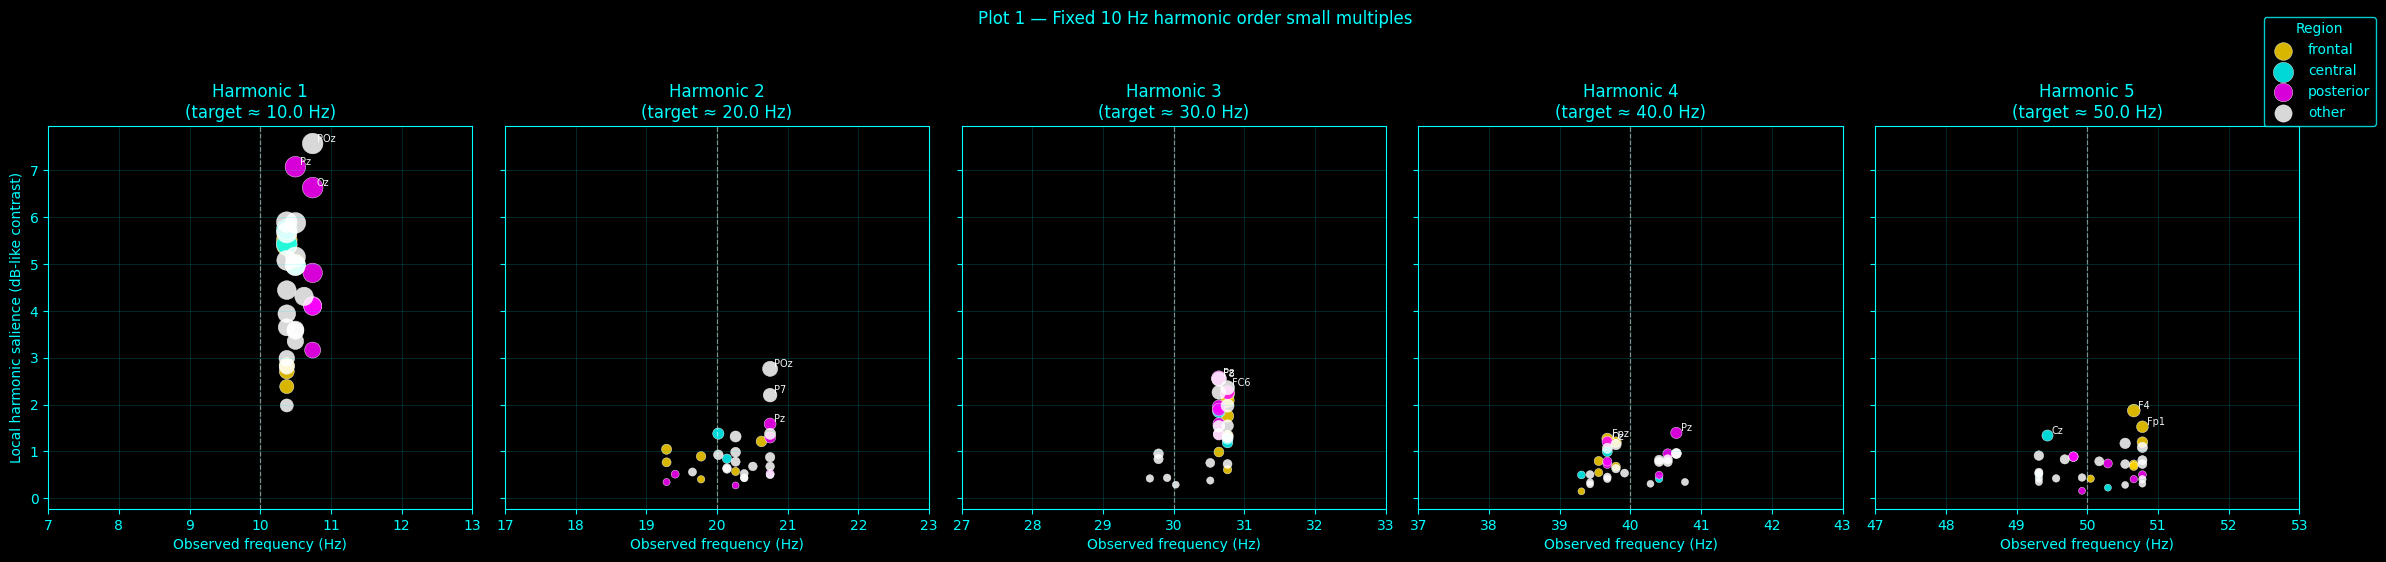

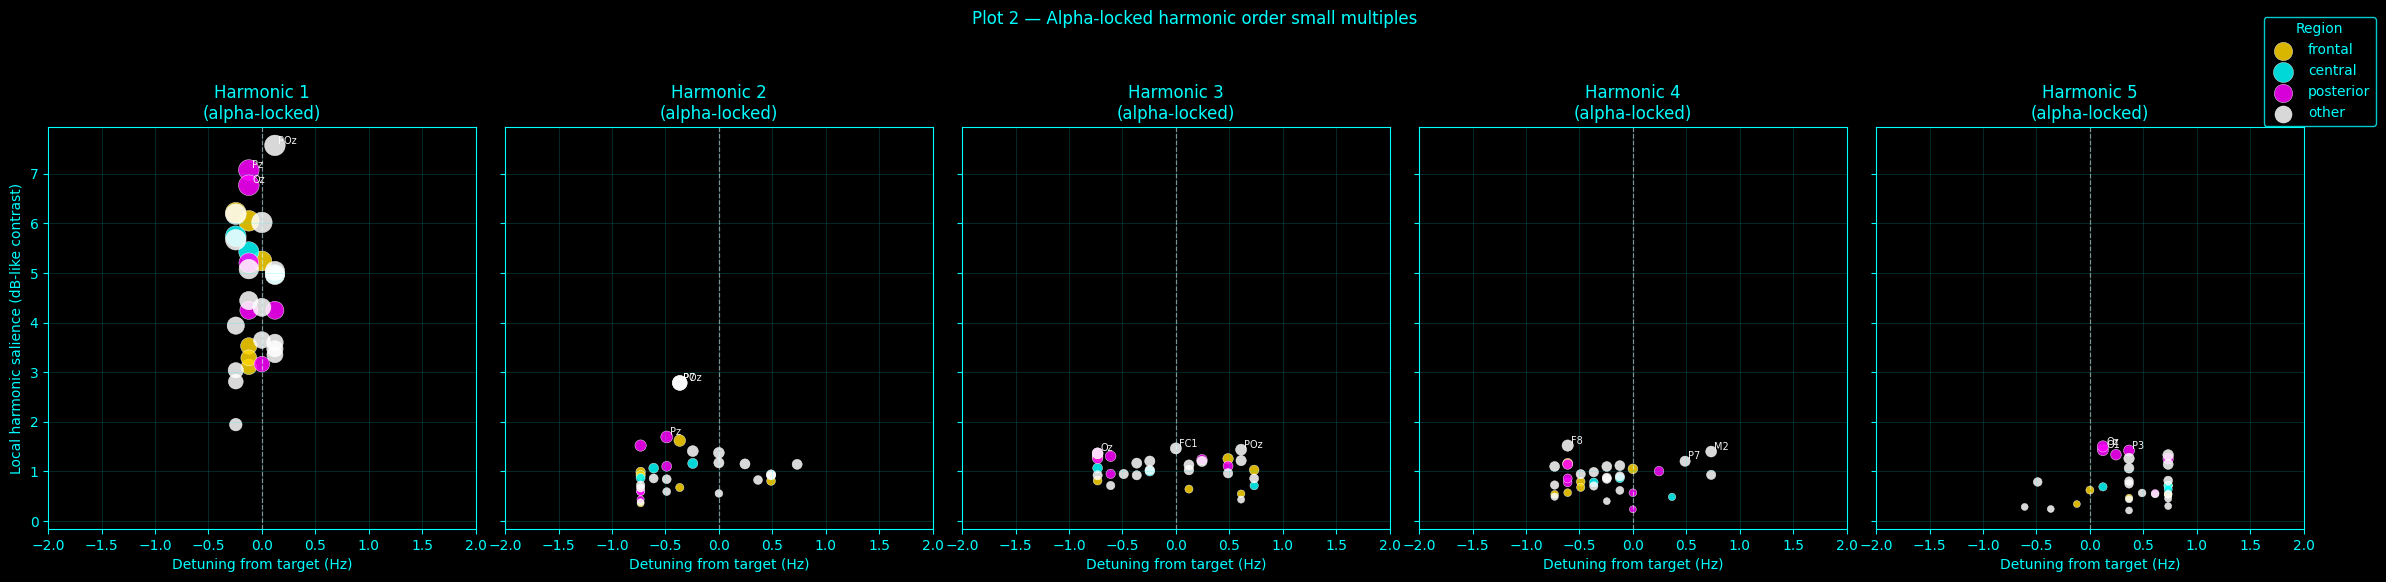

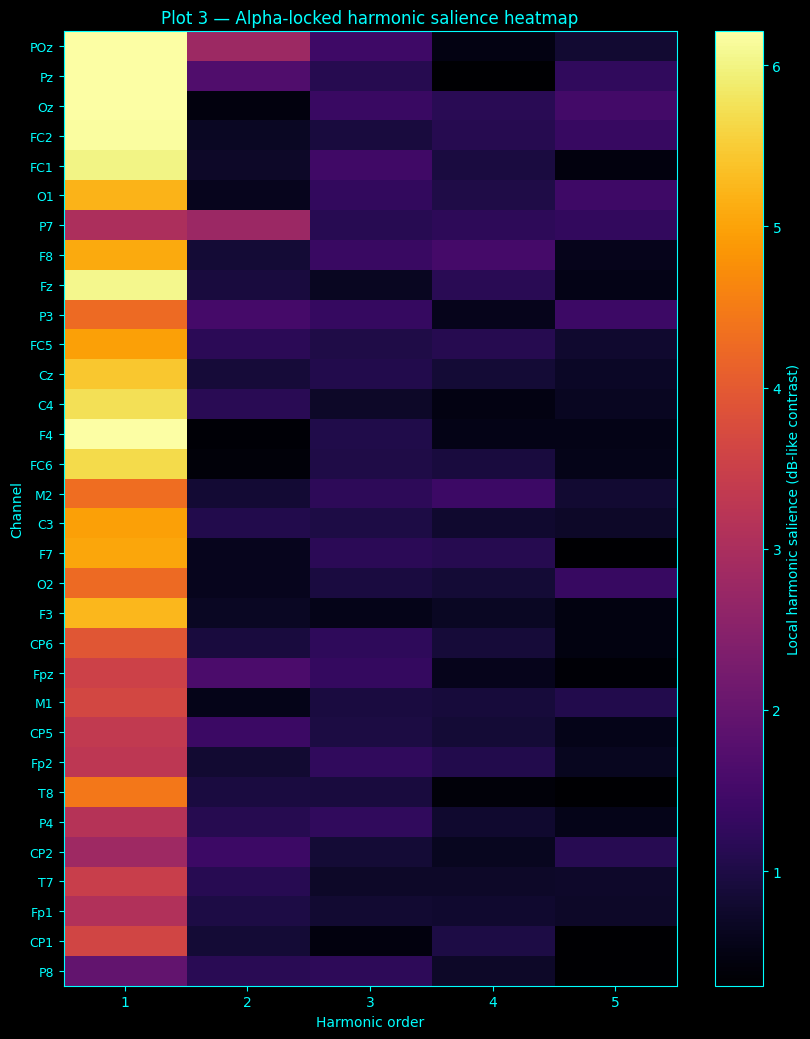


Saved harmonics dict: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_harmonic_order_small_multiples/all_channel_harmonics_by_order_atlas.npy
Saved long CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_harmonic_order_small_multiples/harmonics_by_order_long.csv
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_harmonic_order_small_multiples/harmonics_by_order_summary.csv
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_harmonic_order_small_multiples/harmonics_by_order_outputs.npz
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_harmonic_order_small_multiples/harmonics_by_order_notes.txt
Saved plot 1: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_harmonic_order_small_multiples/plots/plot1_fixed_10hz_by_order_small_multiples.png
Saved plot 2: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_harmo

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# -------------------------------------------------------
# NUMPY 1.x / 2.x COMPATIBILITY
# -------------------------------------------------------
if hasattr(np, "trapezoid"):
    integrate_trapezoid = np.trapezoid
else:
    integrate_trapezoid = np.trapz

# -------------------------------------------------------
# CONFIG — FILE PATHS ONLY, NO NOTEBOOK MEMORY
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_harmonic_order_small_multiples")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# -------------------------------------------------------
# THEORY / DESIGN
# -------------------------------------------------------
display_band = (0.0, 100.0)
analysis_band = (2.0, 100.0)
alpha_band = (7.0, 13.0)

probe_fundamental_hz = 10.0
max_harmonic_hz = 100.0
num_harmonics = 5
harmonic_tolerance_hz = 0.80
local_baseline_halfwidth_hz = 2.0

harmonic_orders = np.arange(1, num_harmonics + 1)
probe_harmonic_targets_hz = probe_fundamental_hz * harmonic_orders

welch_window_sec = 4.0
welch_overlap = 0.50
welch_nfft = 8192
detrend_mode = "constant"
apply_common_average_reference = False

# Channels
eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

roi_definitions = {
    "frontal":   ['Fp1', 'Fpz', 'Fp2', 'F3', 'Fz', 'F4'],
    "central":   ['C3', 'Cz', 'C4'],
    "posterior": ['P3', 'Pz', 'P4', 'O1', 'Oz', 'O2'],
}

region_colors = {
    "frontal": "gold",
    "central": "cyan",
    "posterior": "magenta",
    "other": "white",
}

eps = 1e-12
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def band_mask(freqs_hz, band):
    lo, hi = band
    return (freqs_hz >= lo) & (freqs_hz <= hi)

def welch_psd(y, fs, window_sec=4.0, overlap=0.5, detrend="constant", nfft=None):
    nperseg = min(int(round(window_sec * fs)), len(y))
    nperseg = max(nperseg, min(256, len(y)))
    noverlap = min(int(round(overlap * nperseg)), nperseg - 1)

    freqs_hz, pxx = signal.welch(
        y,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=detrend,
        scaling="density",
        nfft=nfft,
    )
    return freqs_hz, pxx

def area_normalize_1d(freqs_hz, x, band):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    mask = band_mask(freqs_hz, band) & np.isfinite(x) & (x >= 0)

    if np.sum(mask) < 2:
        return out

    area = integrate_trapezoid(x[mask], freqs_hz[mask])
    if not np.isfinite(area) or area <= 0:
        return out

    out[mask] = x[mask] / area
    return out

def robust_peak_in_band(freqs_hz, spectrum_1d, band=(7.0, 13.0), smooth_win=7):
    mask = band_mask(freqs_hz, band) & np.isfinite(spectrum_1d)
    if np.sum(mask) < 5:
        return np.nan, np.nan, np.nan, np.nan, False

    f = freqs_hz[mask]
    y = spectrum_1d[mask].copy()

    if smooth_win > 1 and len(y) >= smooth_win:
        kernel = np.ones(smooth_win, dtype=float) / smooth_win
        y = np.convolve(y, kernel, mode="same")

    peaks, _ = signal.find_peaks(y)
    if len(peaks) > 0:
        prominences = signal.peak_prominences(y, peaks)[0]
        valid = (peaks > 0) & (peaks < len(y) - 1)
        if np.any(valid):
            peaks = peaks[valid]
            prominences = prominences[valid]

            min_prominence = max(0.05 * np.nanmax(y), 1.5 * np.nanmedian(np.abs(np.diff(y))))
            strong = prominences >= min_prominence
            if np.any(strong):
                peaks = peaks[strong]
                prominences = prominences[strong]
                winner = int(np.argmax(prominences))
                peak_idx = peaks[winner]

                peak_freq = float(f[peak_idx])
                peak_height = float(y[peak_idx])
                peak_prominence = float(prominences[winner])
                peak_contrast = float(peak_height / (np.nanmedian(y) + eps))
                return peak_freq, peak_height, peak_prominence, peak_contrast, True

    idx = int(np.nanargmax(y))
    peak_freq = float(f[idx])
    peak_height = float(y[idx])
    peak_prominence = np.nan
    peak_contrast = float(peak_height / (np.nanmedian(y) + eps))
    return peak_freq, peak_height, peak_prominence, peak_contrast, False

def local_peak_stats(freqs_hz, spectrum_1d, target_hz, tolerance_hz=0.80, baseline_halfwidth_hz=2.0):
    target_mask = (
        (freqs_hz >= target_hz - tolerance_hz) &
        (freqs_hz <= target_hz + tolerance_hz) &
        np.isfinite(spectrum_1d)
    )
    if np.sum(target_mask) < 1:
        return np.nan, np.nan, np.nan, np.nan

    local_freqs = freqs_hz[target_mask]
    local_vals = spectrum_1d[target_mask]
    idx = int(np.nanargmax(local_vals))
    observed_hz = float(local_freqs[idx])
    peak_power = float(local_vals[idx])

    baseline_mask = (
        (freqs_hz >= target_hz - baseline_halfwidth_hz) &
        (freqs_hz <= target_hz + baseline_halfwidth_hz) &
        np.isfinite(spectrum_1d)
    )
    baseline_vals = spectrum_1d[baseline_mask]
    if len(baseline_vals) < 3:
        contrast_db = np.nan
    else:
        baseline_median = float(np.nanmedian(baseline_vals))
        contrast_ratio = peak_power / (baseline_median + eps)
        contrast_db = 10.0 * np.log10(contrast_ratio + eps)

    detuning_hz = observed_hz - target_hz
    return observed_hz, peak_power, contrast_db, detuning_hz

def harmonic_ladder_summary(freqs_hz, spectrum_1d, fundamental_hz, tolerance_hz=0.80, baseline_halfwidth_hz=2.0, max_order=5):
    if not np.isfinite(fundamental_hz) or fundamental_hz <= 0:
        return []

    rows = []
    for order in range(1, max_order + 1):
        target_hz = order * fundamental_hz
        observed_hz, peak_power, contrast_db, detuning_hz = local_peak_stats(
            freqs_hz,
            spectrum_1d,
            target_hz,
            tolerance_hz=tolerance_hz,
            baseline_halfwidth_hz=baseline_halfwidth_hz,
        )
        rows.append({
            "order": order,
            "target_hz": target_hz,
            "observed_hz": observed_hz,
            "peak_power": peak_power,
            "contrast_db": contrast_db,
            "detuning_hz": detuning_hz,
        })
    return rows

def summarize_harmonic_family(rows):
    if len(rows) == 0:
        return np.nan, np.nan, np.nan
    df = pd.DataFrame(rows)
    harmonicity = float(np.nanmean(df["contrast_db"]))
    detuning = float(np.nanmean(np.abs(df["detuning_hz"])))
    mean_power = float(np.nanmean(df["peak_power"]))
    return harmonicity, detuning, mean_power

def marker_sizes_from_contrast(x_db, min_size=25, max_size=220):
    x = np.asarray(x_db, dtype=float)
    x = np.where(np.isfinite(x), x, np.nan)
    if np.all(~np.isfinite(x)):
        return np.full_like(x, min_size, dtype=float)

    lo = np.nanpercentile(x, 5)
    hi = np.nanpercentile(x, 95)
    if hi <= lo:
        return np.full_like(x, 0.5 * (min_size + max_size), dtype=float)

    z = (np.clip(x, lo, hi) - lo) / (hi - lo + eps)
    return min_size + z * (max_size - min_size)

def channel_region(ch_name):
    if ch_name in roi_definitions["frontal"]:
        return "frontal"
    if ch_name in roi_definitions["central"]:
        return "central"
    if ch_name in roi_definitions["posterior"]:
        return "posterior"
    return "other"

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Segment shape: {segment.shape}")

# -------------------------------------------------------
# CORE ANALYSIS
# -------------------------------------------------------
all_channel_harmonics = {}
long_rows = []
summary_rows = []
mean_psd_matrix = []
freqs_ref = None

for ch_i, ch_name in enumerate(eeg_channel_names):
    y = segment[:, ch_i]

    freqs_hz, pxx = welch_psd(
        y,
        fs=sampling_rate,
        window_sec=welch_window_sec,
        overlap=welch_overlap,
        detrend=detrend_mode,
        nfft=welch_nfft,
    )

    if freqs_ref is None:
        freqs_ref = freqs_hz.copy()

    psd_norm = area_normalize_1d(freqs_hz, pxx, analysis_band)
    mean_psd_matrix.append(psd_norm)

    alpha_peak_hz, alpha_peak_height, alpha_peak_prominence, alpha_peak_contrast, alpha_is_local = robust_peak_in_band(
        freqs_hz, psd_norm, band=alpha_band, smooth_win=7
    )

    fixed_rows = harmonic_ladder_summary(
        freqs_hz,
        psd_norm,
        fundamental_hz=probe_fundamental_hz,
        tolerance_hz=harmonic_tolerance_hz,
        baseline_halfwidth_hz=local_baseline_halfwidth_hz,
        max_order=num_harmonics,
    )

    alpha_rows = harmonic_ladder_summary(
        freqs_hz,
        psd_norm,
        fundamental_hz=alpha_peak_hz,
        tolerance_hz=harmonic_tolerance_hz,
        baseline_halfwidth_hz=local_baseline_halfwidth_hz,
        max_order=num_harmonics,
    )

    fixed_harmonicity, fixed_detuning, fixed_mean_power = summarize_harmonic_family(fixed_rows)
    alpha_harmonicity, alpha_detuning, alpha_mean_power = summarize_harmonic_family(alpha_rows)

    region = channel_region(ch_name)

    all_channel_harmonics[ch_name] = {
        "alpha_peak_hz": alpha_peak_hz,
        "fixed_10hz_harmonics": fixed_rows,
        "alpha_locked_harmonics": alpha_rows,
        "frequencies_hz": freqs_hz,
        "psd_area_norm_2_100Hz": psd_norm,
        "region": region,
    }

    for row in fixed_rows:
        row_out = row.copy()
        row_out["channel"] = ch_name
        row_out["family"] = "fixed_10hz"
        row_out["alpha_peak_hz"] = alpha_peak_hz
        row_out["region"] = region
        long_rows.append(row_out)

    for row in alpha_rows:
        row_out = row.copy()
        row_out["channel"] = ch_name
        row_out["family"] = "alpha_locked"
        row_out["alpha_peak_hz"] = alpha_peak_hz
        row_out["region"] = region
        long_rows.append(row_out)

    summary_rows.append({
        "channel": ch_name,
        "region": region,
        "alpha_peak_hz": alpha_peak_hz,
        "alpha_peak_prominence": alpha_peak_prominence,
        "alpha_peak_contrast": alpha_peak_contrast,
        "alpha_peak_is_local": bool(alpha_is_local),
        "fixed_10hz_harmonicity_db": fixed_harmonicity,
        "fixed_10hz_mean_abs_detuning_hz": fixed_detuning,
        "fixed_10hz_mean_power": fixed_mean_power,
        "alpha_locked_harmonicity_db": alpha_harmonicity,
        "alpha_locked_mean_abs_detuning_hz": alpha_detuning,
        "alpha_locked_mean_power": alpha_mean_power,
        "resonance_selectivity": alpha_harmonicity - fixed_harmonicity if np.isfinite(alpha_harmonicity) and np.isfinite(fixed_harmonicity) else np.nan,
    })

harmonics_long_df = pd.DataFrame(long_rows)
summary_df = pd.DataFrame(summary_rows)

for col in summary_df.columns:
    if col not in ["channel", "region"]:
        summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

mean_psd_matrix = np.column_stack(mean_psd_matrix)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
dict_npy_path = os.path.join(out_dir, "all_channel_harmonics_by_order_atlas.npy")
long_csv_path = os.path.join(out_dir, "harmonics_by_order_long.csv")
summary_csv_path = os.path.join(out_dir, "harmonics_by_order_summary.csv")
npz_path = os.path.join(out_dir, "harmonics_by_order_outputs.npz")
notes_txt_path = os.path.join(out_dir, "harmonics_by_order_notes.txt")

plot1_path = os.path.join(plots_dir, "plot1_fixed_10hz_by_order_small_multiples.png")
plot2_path = os.path.join(plots_dir, "plot2_alpha_locked_by_order_small_multiples.png")
plot3_path = os.path.join(plots_dir, "plot3_alpha_locked_harmonicity_heatmap.png")

np.save(dict_npy_path, all_channel_harmonics, allow_pickle=True)
harmonics_long_df.to_csv(long_csv_path, index=False)
summary_df.to_csv(summary_csv_path, index=False)

np.savez_compressed(
    npz_path,
    channel_names=np.array(eeg_channel_names, dtype=object),
    frequencies_hz=freqs_ref,
    mean_psd_area_norm_2_100Hz=mean_psd_matrix,
    harmonic_orders=harmonic_orders,
    probe_harmonic_targets_hz=probe_harmonic_targets_hz,
    start_time=start_time,
    end_time=end_time,
    sampling_rate=sampling_rate,
)

with open(notes_txt_path, "w") as f:
    f.write("Exploratory harmonic order small-multiples notes\n")
    f.write("===============================================\n\n")
    f.write("Intent:\n")
    f.write("This pass converts the notebook-memory harmonic order plot into a file-based harmonic atlas on the selected EEG segment.\n")
    f.write("It is for exploratory expert research, not publishing, not benchmarking, and not scoring.\n\n")
    f.write("Key upgrades:\n")
    f.write("1. Uses file paths only.\n")
    f.write("2. Recomputes harmonics from Welch PSD on the selected interval.\n")
    f.write("3. Splits fixed 10 Hz and alpha-locked harmonic families.\n")
    f.write("4. Uses local harmonic salience, detuning, and anatomical grouping.\n")
    f.write("5. Saves all plots and all long-form harmonic tables.\n\n")

# -------------------------------------------------------
# PLOT 1 — FIXED 10 HZ BY HARMONIC ORDER
# -------------------------------------------------------
fixed_df = harmonics_long_df[harmonics_long_df["family"] == "fixed_10hz"].copy()
fixed_df["marker_size"] = marker_sizes_from_contrast(fixed_df["contrast_db"].values)

fig1, axs1 = plt.subplots(1, num_harmonics, figsize=(4.8 * num_harmonics, 5.6), sharey=True, facecolor=BG)
if num_harmonics == 1:
    axs1 = [axs1]

for i, order in enumerate(harmonic_orders):
    ax = axs1[i]
    style_ax(ax)

    sub = fixed_df[fixed_df["order"] == order].copy()
    target_hz = probe_fundamental_hz * order

    for region_name, region_color in region_colors.items():
        region_sub = sub[sub["region"] == region_name]
        if len(region_sub) == 0:
            continue
        ax.scatter(
            region_sub["observed_hz"].values,
            region_sub["contrast_db"].values,
            s=region_sub["marker_size"].values,
            color=region_color,
            alpha=0.85,
            edgecolors="white",
            linewidths=0.35,
            label=region_name if i == 0 else None,
        )

    ax.axvline(target_hz, color="white", linestyle="--", linewidth=0.9, alpha=0.5)
    ax.set_title(f"Harmonic {order}\n(target ≈ {target_hz:.1f} Hz)")
    ax.set_xlabel("Observed frequency (Hz)")
    ax.set_xlim(max(0, target_hz - 3.0), min(display_band[1], target_hz + 3.0))

    ann = sub.sort_values("contrast_db", ascending=False, na_position="last").head(3)
    for _, row in ann.iterrows():
        if np.isfinite(row["observed_hz"]) and np.isfinite(row["contrast_db"]):
            ax.text(
                row["observed_hz"] + 0.06,
                row["contrast_db"] + 0.04,
                row["channel"],
                fontsize=7,
                color="white",
                alpha=0.95,
            )

axs1[0].set_ylabel("Local harmonic salience (dB-like contrast)")
handles1, labels1 = axs1[0].get_legend_handles_labels()
fig1.legend(handles1, labels1, loc="upper right", bbox_to_anchor=(0.995, 0.995), ncol=1, title="Region")
fig1.suptitle("Plot 1 — Fixed 10 Hz harmonic order small multiples", color=ACCENT, y=0.995)
fig1.tight_layout(rect=[0, 0, 0.97, 0.95])
fig1.savefig(plot1_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig1)

# -------------------------------------------------------
# PLOT 2 — ALPHA-LOCKED BY HARMONIC ORDER
# -------------------------------------------------------
alpha_df = harmonics_long_df[harmonics_long_df["family"] == "alpha_locked"].copy()
alpha_df["marker_size"] = marker_sizes_from_contrast(alpha_df["contrast_db"].values)

fig2, axs2 = plt.subplots(1, num_harmonics, figsize=(4.8 * num_harmonics, 5.8), sharey=True, facecolor=BG)
if num_harmonics == 1:
    axs2 = [axs2]

for i, order in enumerate(harmonic_orders):
    ax = axs2[i]
    style_ax(ax)

    sub = alpha_df[alpha_df["order"] == order].copy()

    for region_name, region_color in region_colors.items():
        region_sub = sub[sub["region"] == region_name]
        if len(region_sub) == 0:
            continue
        ax.scatter(
            region_sub["detuning_hz"].values,
            region_sub["contrast_db"].values,
            s=region_sub["marker_size"].values,
            color=region_color,
            alpha=0.85,
            edgecolors="white",
            linewidths=0.35,
            label=region_name if i == 0 else None,
        )

    ax.axvline(0.0, color="white", linestyle="--", linewidth=0.9, alpha=0.5)
    ax.set_title(f"Harmonic {order}\n(alpha-locked)")
    ax.set_xlabel("Detuning from target (Hz)")
    ax.set_xlim(-2.0, 2.0)

    ann = sub.sort_values("contrast_db", ascending=False, na_position="last").head(3)
    for _, row in ann.iterrows():
        if np.isfinite(row["detuning_hz"]) and np.isfinite(row["contrast_db"]):
            ax.text(
                row["detuning_hz"] + 0.03,
                row["contrast_db"] + 0.04,
                row["channel"],
                fontsize=7,
                color="white",
                alpha=0.95,
            )

axs2[0].set_ylabel("Local harmonic salience (dB-like contrast)")
handles2, labels2 = axs2[0].get_legend_handles_labels()
fig2.legend(handles2, labels2, loc="upper right", bbox_to_anchor=(0.995, 0.995), ncol=1, title="Region")
fig2.suptitle("Plot 2 — Alpha-locked harmonic order small multiples", color=ACCENT, y=0.995)
fig2.tight_layout(rect=[0, 0, 0.97, 0.95])
fig2.savefig(plot2_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig2)

# -------------------------------------------------------
# PLOT 3 — HEATMAP OF ALPHA-LOCKED HARMONIC SALIENCE
# -------------------------------------------------------
heat_df = alpha_df.pivot_table(
    index="channel",
    columns="order",
    values="contrast_db",
    aggfunc="mean"
).reindex(
    summary_df.sort_values("alpha_locked_harmonicity_db", ascending=False, na_position="last")["channel"].values
)

heat = heat_df.values

# robust fallback in case the heatmap is all-NaN
vmin, vmax = percentile_limits(heat, lo=2, hi=98)
if vmin is None or vmax is None:
    vmin, vmax = 0.0, 1.0
    heat = np.nan_to_num(heat, nan=0.0)

fig3, ax3 = plt.subplots(figsize=(8.5, 10.5), facecolor=BG)
style_ax(ax3, heatmap=True)

im = ax3.imshow(
    heat,
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax,
)

ax3.set_title("Plot 3 — Alpha-locked harmonic salience heatmap")
ax3.set_xlabel("Harmonic order")
ax3.set_ylabel("Channel")
ax3.set_xticks(np.arange(len(harmonic_orders)))
ax3.set_xticklabels([str(k) for k in harmonic_orders])
ax3.set_yticks(np.arange(len(heat_df.index)))
ax3.set_yticklabels(list(heat_df.index), fontsize=9)

cbar3 = plt.colorbar(im, ax=ax3)
cbar3.set_label("Local harmonic salience (dB-like contrast)", color=ACCENT)
cbar3.outline.set_edgecolor(ACCENT)
cbar3.ax.tick_params(color=ACCENT)
for label in cbar3.ax.get_yticklabels():
    label.set_color(ACCENT)

fig3.tight_layout()
fig3.savefig(plot3_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig3)

print(f"\nSaved harmonics dict: {dict_npy_path}")
print(f"Saved long CSV: {long_csv_path}")
print(f"Saved summary CSV: {summary_csv_path}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved notes TXT: {notes_txt_path}")
print(f"Saved plot 1: {plot1_path}")
print(f"Saved plot 2: {plot2_path}")
print(f"Saved plot 3: {plot3_path}")
print("Done.")

### Harmonics Detection Using Lyapunov Exponents

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Left Column -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>The code provided automates the identification of 'harmonic' Lyapunov exponents from EEG data sets, offering a novel approach to analyzing neural dynamics. By mapping out these harmonics, the script contributes to the broader understanding of the chaotic behavior and stability characteristics inherent in brain activity, viewed through the lens of Lyapunov exponents.</p>
        <h2>Lyapunov Exponents and Their Significance</h2>
        <p>Lyapunov exponents quantify the divergence or convergence of nearby trajectories in a system's phase space, serving as a measure of the system's sensitivity to initial conditions. Positive Lyapunov exponents indicate chaos, revealing the system's unpredictable behavior over time, while negative values suggest convergence to a stable state.</p>
        <h2>Harmonic Detection in Lyapunov Spectra</h2>
        <p>Identifying 'harmonics' among Lyapunov exponents entails finding values that are integer multiples of a base value, akin to harmonic frequencies in physics. This concept is adapted to explore patterns within the Lyapunov spectrum, potentially revealing underlying structures or symmetries in the system's dynamics.</p>
    </div>
    <!-- Right Column -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Methodology</h2>
        <p>The method involves iterating over a collection of Lyapunov exponents, seeking values that approximate integer multiples of a predefined base measure within a certain tolerance. This process allows for the extraction of significant 'harmonic' patterns from the data, which may correspond to fundamental dynamics of the observed system.</p>
        <h2>Practical Application and Analysis</h2>
        <p>Applied to EEG data, this technique can unveil 'harmonic' exponents that underscore periodic or cyclic stability features within neural signals. Such analysis enriches our comprehension of brain dynamics, potentially linking to rhythmic patterns observed in neurological states or processes.</p>
        <h2>Conclusion</h2>
        <p>This approach marries concepts from dynamical systems theory and signal processing to extract meaningful patterns from Lyapunov spectra. It highlights the utility of mathematical and computational tools in neuroscience research, offering deeper insights into the complex dynamics of brain function.</p>
    </div>
</div>


Using Lyapunov CSV:
/home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/lyap_spectrum_20260313_135116.csv

Detected exponent columns:
['Exp1', 'Exp2', 'Exp3', 'Exp4', 'Exp5', 'Exp6', 'Exp7', 'Exp8', 'Exp9', 'Exp10']


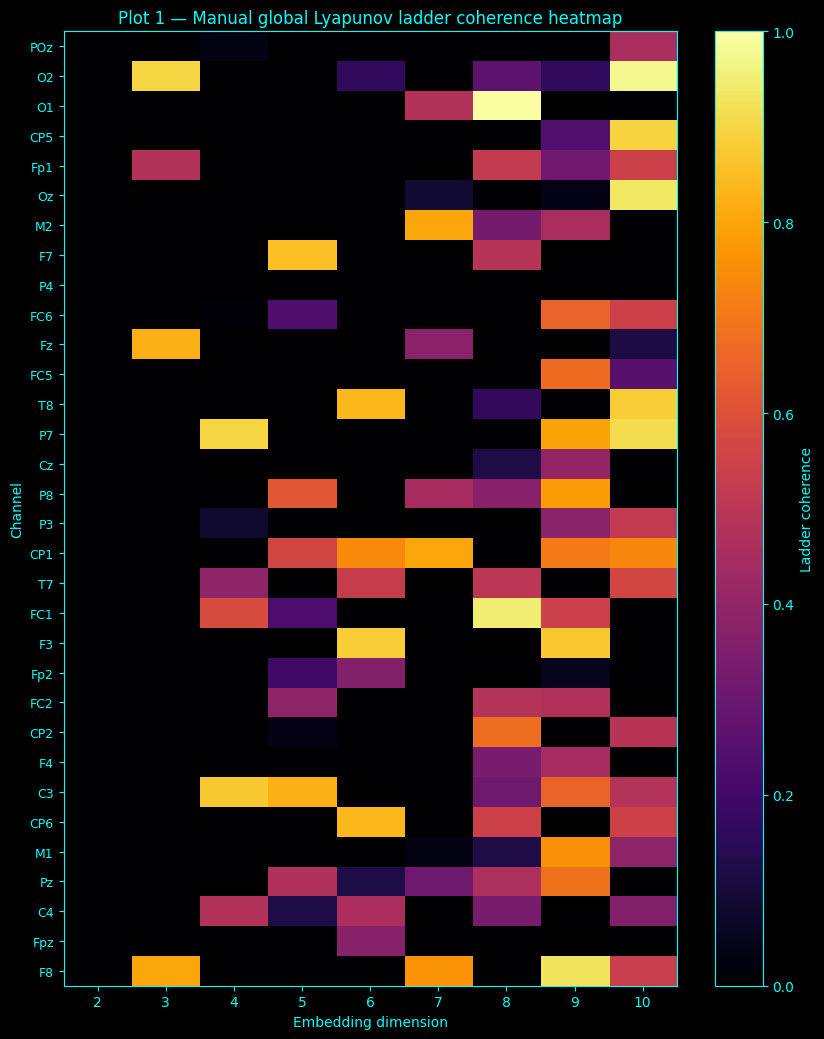

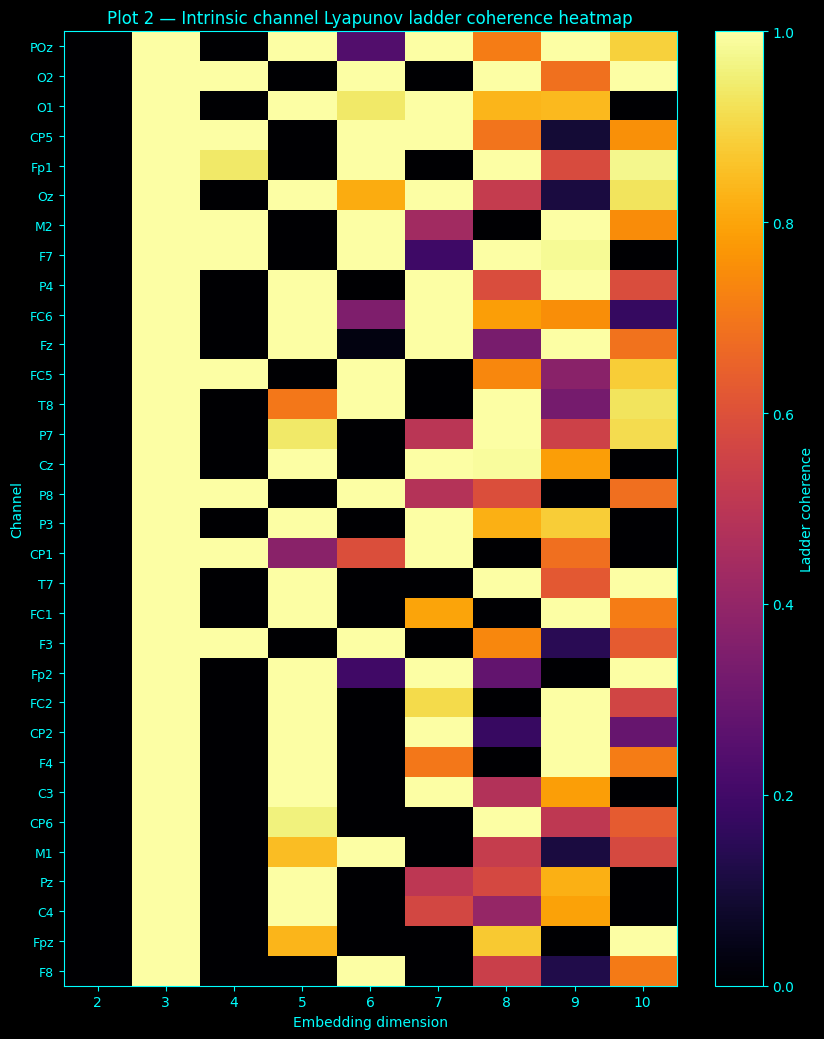

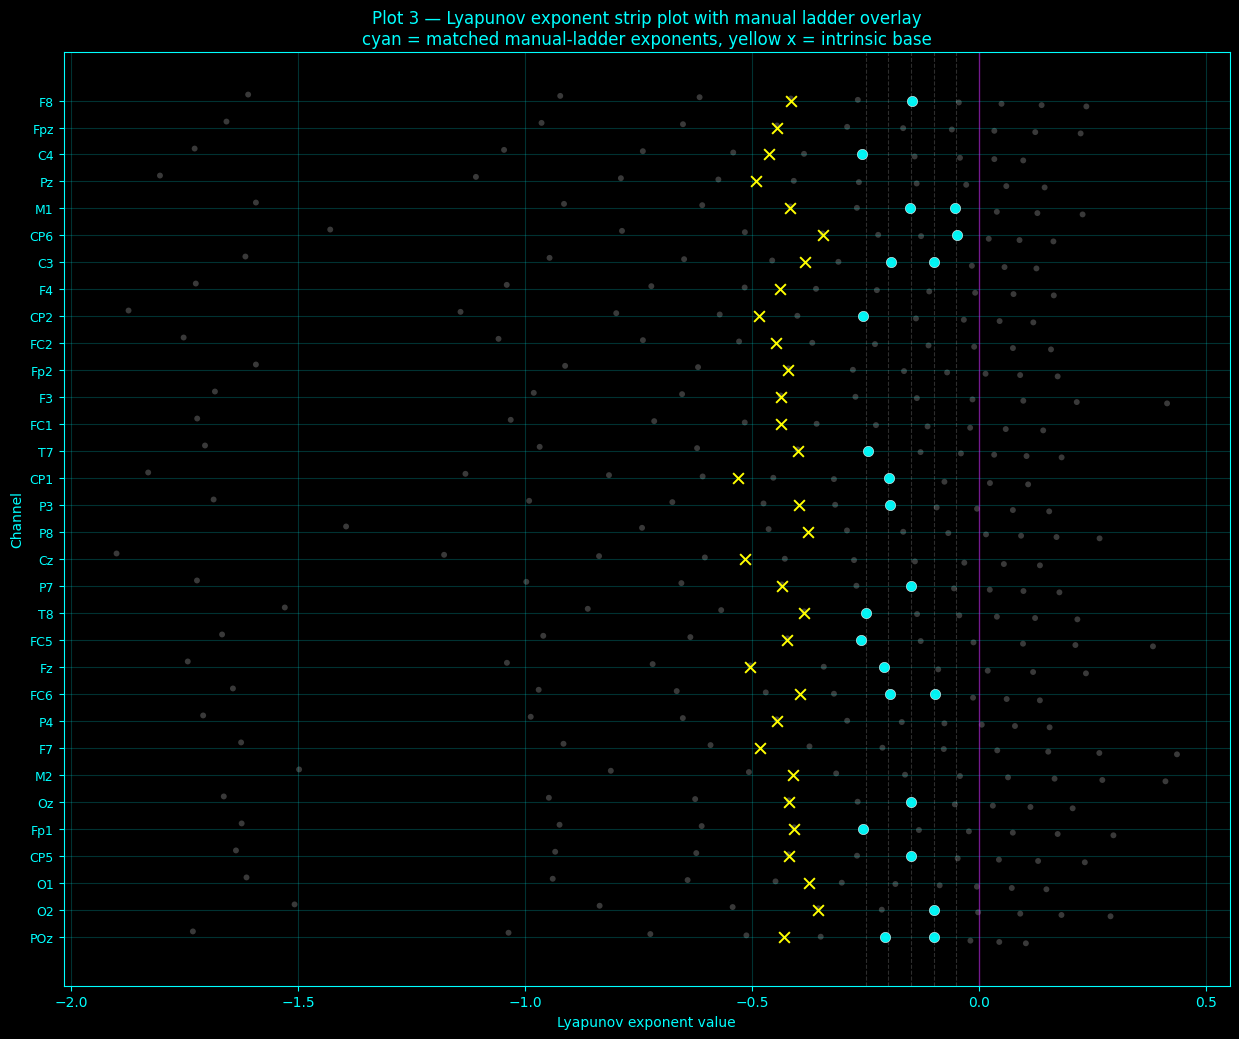

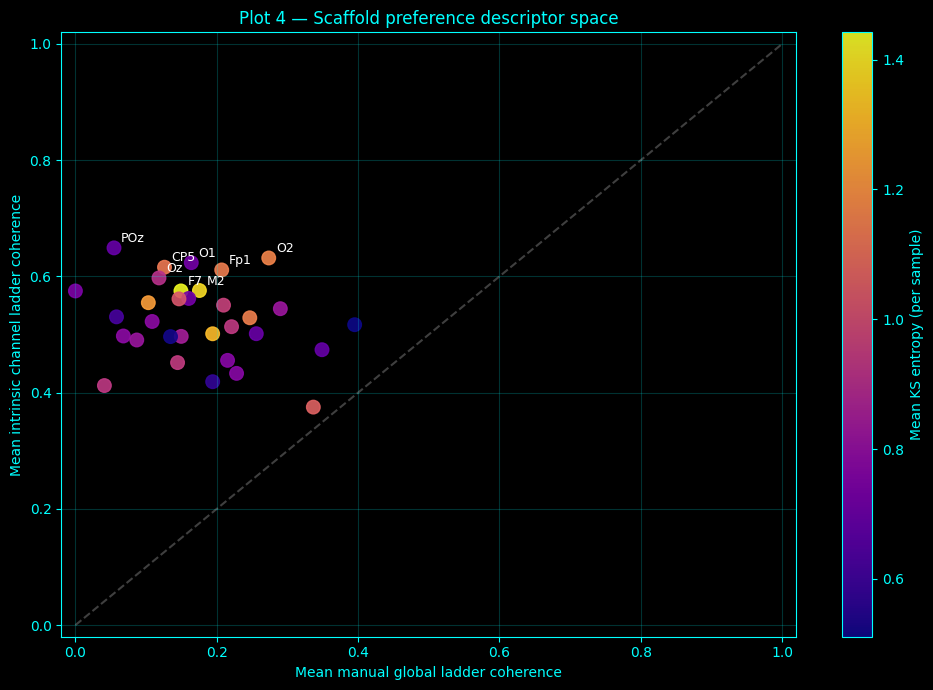

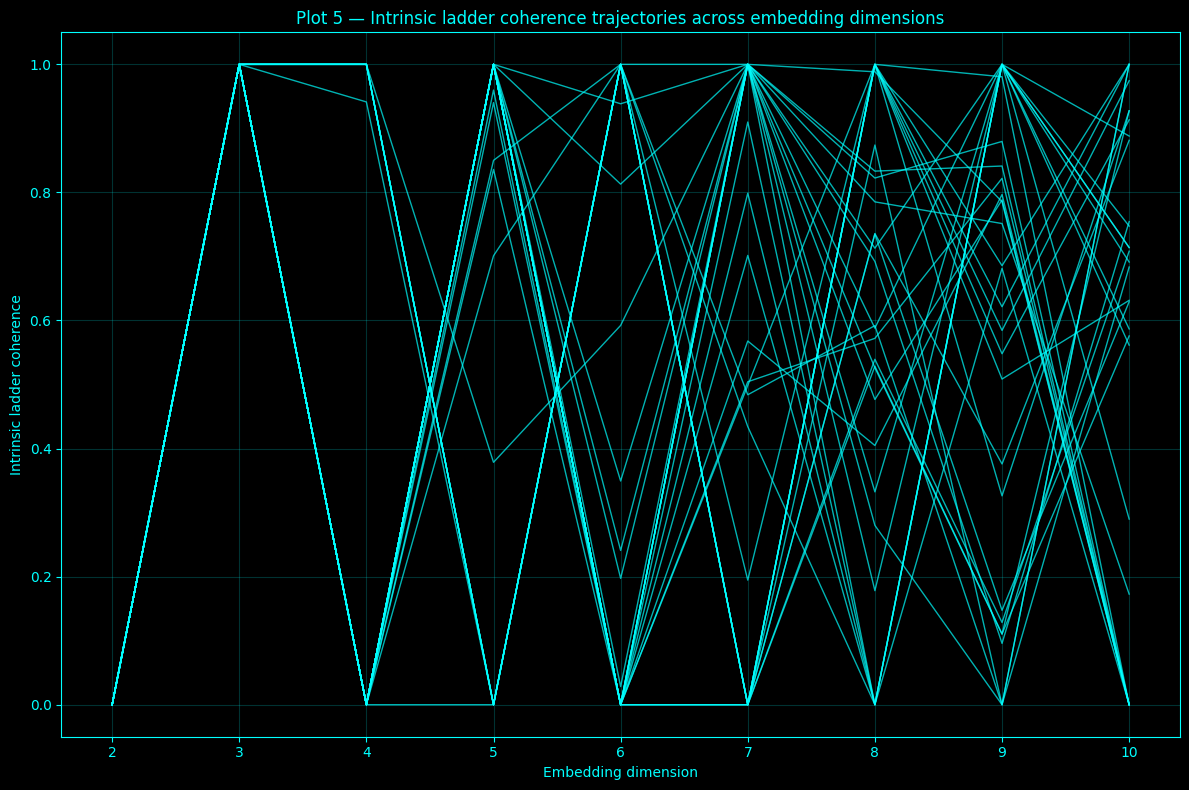


Top channels by manual global ladder coherence:
Channel: CP1, manual_coherence=0.395, intrinsic_coherence=0.517
Channel: C3, manual_coherence=0.349, intrinsic_coherence=0.474
Channel: F8, manual_coherence=0.337, intrinsic_coherence=0.375
Channel: P7, manual_coherence=0.290, intrinsic_coherence=0.544
Channel: O2, manual_coherence=0.274, intrinsic_coherence=0.632
Channel: FC1, manual_coherence=0.256, intrinsic_coherence=0.501
Channel: P8, manual_coherence=0.247, intrinsic_coherence=0.529
Channel: Pz, manual_coherence=0.228, intrinsic_coherence=0.433

Top channels by intrinsic channel ladder coherence:
Channel: POz, intrinsic_base=-0.48463415467831333, intrinsic_coherence=0.649
Channel: O2, intrinsic_base=-0.45567226531768035, intrinsic_coherence=0.632
Channel: O1, intrinsic_base=-0.42524907378324767, intrinsic_coherence=0.624
Channel: CP5, intrinsic_base=-0.4840703527839829, intrinsic_coherence=0.616
Channel: Fp1, intrinsic_base=-0.4477607554125836, intrinsic_coherence=0.611
Channel: Oz

In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG — FILE PATHS ONLY, NO NOTEBOOK MEMORY
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
lyap_dir = os.path.join(base_dir, "results", "lyapunov_custom")

out_dir = os.path.join(base_dir, "results", "exploratory_lyapunov_ladder_atlas")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# Exploratory ladder settings
manual_base_measure = -0.05
harmonics_count = 5
harmonic_orders = np.arange(1, harmonics_count + 1)

relative_tolerance = 0.05      # 5% relative mismatch tolerance
near_zero_threshold = 1e-3     # descriptive threshold for neutral/near-zero exponents
min_abs_base = 1e-4            # do not use essentially zero bases

# If your Lyapunov code used DT = 1.0, KS is per sample.
# If DT = 1/fs, KS is per second.
KS_UNITS = "per sample"

ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

canonical_channel_order = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.20, color=ACCENT)

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

# -------------------------------------------------------
# IO HELPERS
# -------------------------------------------------------
def find_latest_lyapunov_csv(results_dir):
    csvs = sorted(glob.glob(os.path.join(results_dir, "lyap_spectrum_*.csv")))
    if not csvs:
        raise FileNotFoundError(f"No lyap_spectrum_*.csv files found in: {results_dir}")
    return max(csvs, key=os.path.getmtime)

def get_exp_cols(df):
    exp_cols = [c for c in df.columns if str(c).startswith("Exp")]
    exp_cols = sorted(exp_cols, key=lambda c: int(str(c).replace("Exp", "")))
    return exp_cols

def infer_channel_from_stem(stem):
    stem = str(stem)
    if "dembedded_" in stem:
        return stem.split("dembedded_", 1)[1]
    return stem

def infer_embedding_dimension(row):
    if "embedding_dimension" in row.index and pd.notna(row["embedding_dimension"]):
        try:
            return int(row["embedding_dimension"])
        except Exception:
            pass

    stem = str(row["stem"]) if "stem" in row.index else ""
    if "dembedded_" in stem:
        left = stem.split("dembedded_", 1)[0]
        try:
            return int(left)
        except Exception:
            pass

    if "state_dim" in row.index and pd.notna(row["state_dim"]):
        try:
            return int(row["state_dim"])
        except Exception:
            pass

    return np.nan

def row_exponents(row, exp_cols):
    vals = []
    for c in exp_cols:
        if c in row.index and pd.notna(row[c]):
            vals.append(float(row[c]))
    return np.asarray(vals, dtype=float)

def channel_sort_key(channel_name):
    try:
        return (0, canonical_channel_order.index(channel_name))
    except ValueError:
        return (1, str(channel_name))

# -------------------------------------------------------
# DYNAMICAL-SYSTEMS HELPERS
# -------------------------------------------------------
def ks_entropy_estimate(lyapunov_exponents):
    """
    Pesin-type estimate:
        h_KS ≈ sum of positive Lyapunov exponents
    """
    exps = np.asarray(lyapunov_exponents, dtype=float)
    exps = exps[np.isfinite(exps)]
    if exps.size == 0:
        return np.nan
    return float(np.sum(exps[exps > 0]))

def positive_lyapunov_count(lyapunov_exponents):
    exps = np.asarray(lyapunov_exponents, dtype=float)
    exps = exps[np.isfinite(exps)]
    return int(np.sum(exps > 0))

def largest_lyapunov(lyapunov_exponents):
    exps = np.asarray(lyapunov_exponents, dtype=float)
    exps = exps[np.isfinite(exps)]
    if exps.size == 0:
        return np.nan
    return float(np.max(exps))

def exponent_descriptor_summary(exponents, near_zero_thr=1e-3):
    exponents = np.asarray(exponents, dtype=float)
    exponents = exponents[np.isfinite(exponents)]

    pos = exponents[exponents > near_zero_thr]
    neg = exponents[exponents < -near_zero_thr]
    zeroish = exponents[np.abs(exponents) <= near_zero_thr]

    n = len(exponents)
    return {
        "n_exponents": int(n),
        "n_positive": int(len(pos)),
        "n_negative": int(len(neg)),
        "n_near_zero": int(len(zeroish)),
        "positive_fraction": float(len(pos) / n) if n > 0 else np.nan,
        "negative_fraction": float(len(neg) / n) if n > 0 else np.nan,
        "near_zero_fraction": float(len(zeroish) / n) if n > 0 else np.nan,
        "max_exponent": float(np.max(exponents)) if n > 0 else np.nan,
        "min_exponent": float(np.min(exponents)) if n > 0 else np.nan,
        "mean_exponent": float(np.mean(exponents)) if n > 0 else np.nan,
        "std_exponent": float(np.std(exponents)) if n > 0 else np.nan,
        "median_exponent": float(np.median(exponents)) if n > 0 else np.nan,
    }

def choose_intrinsic_negative_core_base(exponents, min_abs=1e-4):
    """
    Exploratory intrinsic base:
    choose the median magnitude of the negative-core exponents
    and restore the negative sign.

    This is not a theorem; it is a robust stability-scale heuristic.
    """
    exponents = np.asarray(exponents, dtype=float)
    exponents = exponents[np.isfinite(exponents)]
    neg = exponents[exponents < -min_abs]
    if len(neg) == 0:
        return np.nan

    base = -float(np.median(np.abs(neg)))
    if abs(base) < min_abs:
        return np.nan
    return base

def ladder_targets(base_value, orders):
    if not np.isfinite(base_value) or abs(base_value) < min_abs_base:
        return np.full(len(orders), np.nan, dtype=float)
    return base_value * np.asarray(orders, dtype=float)

def find_lyapunov_ladder_matches(exponents, base_value, orders, rel_tol=0.05):
    """
    Expert reframe of the user's original idea:

    Instead of literal 'harmonics', define a multiplicative ladder:
        lambda_n ~= n * lambda_base

    This treats the exponent set as potentially organized around a stability scale.
    """
    exponents = np.asarray(exponents, dtype=float)
    exponents = exponents[np.isfinite(exponents)]

    rows = []
    if len(exponents) == 0 or (not np.isfinite(base_value)) or abs(base_value) < min_abs_base:
        for order in orders:
            rows.append({
                "order": int(order),
                "target_value": np.nan,
                "matched_exponent": np.nan,
                "abs_error": np.nan,
                "rel_error": np.nan,
                "is_match": False,
                "match_strength": np.nan,
            })
        return rows

    for order in orders:
        target_value = base_value * order
        nearest = exponents[np.argmin(np.abs(exponents - target_value))]
        abs_error = float(abs(nearest - target_value))
        rel_error = float(abs_error / (abs(target_value) + eps))
        is_match = bool(rel_error <= rel_tol)

        # 1 at perfect match, 0 at tolerance edge, negative beyond
        match_strength = 1.0 - (rel_error / (rel_tol + eps))

        rows.append({
            "order": int(order),
            "target_value": float(target_value),
            "matched_exponent": float(nearest),
            "abs_error": abs_error,
            "rel_error": rel_error,
            "is_match": is_match,
            "match_strength": float(match_strength),
        })

    return rows

def ladder_summary(rows):
    df = pd.DataFrame(rows)
    if len(df) == 0:
        return np.nan, np.nan, np.nan, np.nan

    matched = df["is_match"].fillna(False).astype(bool)
    n_matched = int(matched.sum())
    occupancy = float(n_matched / max(len(df), 1))

    if n_matched > 0:
        mean_rel_error = float(df.loc[matched, "rel_error"].mean())
        mean_abs_error = float(df.loc[matched, "abs_error"].mean())
        coherence = float(df.loc[matched, "match_strength"].clip(lower=0).mean())
    else:
        mean_rel_error = np.nan
        mean_abs_error = np.nan
        coherence = 0.0

    return occupancy, coherence, mean_rel_error, mean_abs_error

# -------------------------------------------------------
# LOAD LATEST LYAPUNOV CSV
# -------------------------------------------------------
lyap_csv = find_latest_lyapunov_csv(lyap_dir)
df = pd.read_csv(lyap_csv)

print("Using Lyapunov CSV:")
print(lyap_csv)

if "status" in df.columns:
    df = df[df["status"] == "ok"].copy()

if df.empty:
    raise ValueError("No successful rows found in the Lyapunov CSV.")

exp_cols = get_exp_cols(df)
if not exp_cols:
    raise ValueError("No Exp columns found in the Lyapunov CSV.")

print("\nDetected exponent columns:")
print(exp_cols)

# -------------------------------------------------------
# BUILD RECORD-LEVEL LYAPUNOV LADDER TABLES
# -------------------------------------------------------
record_rows = []
long_rows = []
output_dict = {}

for _, row in df.iterrows():
    stem = row["stem"] if "stem" in row.index else ""
    channel = infer_channel_from_stem(stem)
    emb_dim = infer_embedding_dimension(row)
    exps = row_exponents(row, exp_cols)

    if exps.size == 0:
        continue

    exps_sorted = np.sort(exps)[::-1]

    ks_est = ks_entropy_estimate(exps_sorted)
    n_pos = positive_lyapunov_count(exps_sorted)
    lmax = largest_lyapunov(exps_sorted)
    intrinsic_base = choose_intrinsic_negative_core_base(exps_sorted, min_abs=min_abs_base)

    manual_rows = find_lyapunov_ladder_matches(
        exponents=exps_sorted,
        base_value=manual_base_measure,
        orders=harmonic_orders,
        rel_tol=relative_tolerance,
    )
    intrinsic_rows = find_lyapunov_ladder_matches(
        exponents=exps_sorted,
        base_value=intrinsic_base,
        orders=harmonic_orders,
        rel_tol=relative_tolerance,
    )

    manual_occ, manual_coh, manual_rel, manual_abs = ladder_summary(manual_rows)
    intrinsic_occ, intrinsic_coh, intrinsic_rel, intrinsic_abs = ladder_summary(intrinsic_rows)
    desc = exponent_descriptor_summary(exps_sorted, near_zero_thr=near_zero_threshold)

    scaffold_preference = (
        intrinsic_coh - manual_coh
        if np.isfinite(intrinsic_coh) and np.isfinite(manual_coh)
        else np.nan
    )

    rec = {
        "file": row["file"] if "file" in row.index else "",
        "stem": stem,
        "channel": channel,
        "embedding_dimension": emb_dim,
        "state_dim": int(row["state_dim"]) if "state_dim" in row.index and pd.notna(row["state_dim"]) else np.nan,
        "n_samples": int(row["n_samples"]) if "n_samples" in row.index and pd.notna(row["n_samples"]) else np.nan,
        "steps_used": int(row["steps_used"]) if "steps_used" in row.index and pd.notna(row["steps_used"]) else np.nan,
        "n_exponents_used": int(exps_sorted.size),
        "largest_lyapunov_exponent": float(lmax),
        "n_positive_exponents": int(n_pos),
        "sum_positive_exponents": float(ks_est),
        "ks_entropy_estimate": float(ks_est),
        "sum_all_exponents": float(np.sum(exps_sorted)),
        "manual_base_measure": float(manual_base_measure),
        "intrinsic_negative_core_base": float(intrinsic_base) if np.isfinite(intrinsic_base) else np.nan,
        "manual_ladder_occupancy": manual_occ,
        "manual_ladder_coherence": manual_coh,
        "manual_mean_rel_error": manual_rel,
        "manual_mean_abs_error": manual_abs,
        "intrinsic_ladder_occupancy": intrinsic_occ,
        "intrinsic_ladder_coherence": intrinsic_coh,
        "intrinsic_mean_rel_error": intrinsic_rel,
        "intrinsic_mean_abs_error": intrinsic_abs,
        "scaffold_preference_intrinsic_minus_manual": scaffold_preference,
        **desc,
    }

    for i, val in enumerate(exps_sorted, start=1):
        rec[f"sorted_Exp{i}"] = float(val)

    record_rows.append(rec)

    record_key = f"{channel}__d{emb_dim}__{stem}"
    output_dict[record_key] = {
        "channel": channel,
        "embedding_dimension": emb_dim,
        "exponents": exps_sorted,
        "manual_base_measure": manual_base_measure,
        "intrinsic_negative_core_base": intrinsic_base,
        "manual_ladder_matches": manual_rows,
        "intrinsic_ladder_matches": intrinsic_rows,
    }

    for scheme_name, base_value, rows in [
        ("manual_global", manual_base_measure, manual_rows),
        ("intrinsic_channel", intrinsic_base, intrinsic_rows),
    ]:
        for rr in rows:
            out = rr.copy()
            out["file"] = row["file"] if "file" in row.index else ""
            out["stem"] = stem
            out["channel"] = channel
            out["embedding_dimension"] = emb_dim
            out["scheme"] = scheme_name
            out["base_value"] = float(base_value) if np.isfinite(base_value) else np.nan
            long_rows.append(out)

record_df = pd.DataFrame(record_rows)
long_df = pd.DataFrame(long_rows)

if record_df.empty:
    raise ValueError("No Lyapunov ladder records were produced.")

for col in record_df.columns:
    if col not in ["file", "stem", "channel"]:
        record_df[col] = pd.to_numeric(record_df[col], errors="coerce")

for col in long_df.columns:
    if col not in ["file", "stem", "channel", "scheme", "is_match"]:
        long_df[col] = pd.to_numeric(long_df[col], errors="coerce")

# -------------------------------------------------------
# CHANNEL-LEVEL SUMMARIES
# -------------------------------------------------------
channel_mean_df = (
    record_df.groupby("channel", as_index=False)
    .agg(
        n_records=("channel", "count"),
        min_embedding_dimension=("embedding_dimension", "min"),
        max_embedding_dimension=("embedding_dimension", "max"),
        mean_ks_entropy=("ks_entropy_estimate", "mean"),
        std_ks_entropy=("ks_entropy_estimate", "std"),
        mean_largest_lyapunov=("largest_lyapunov_exponent", "mean"),
        mean_positive_count=("n_positive_exponents", "mean"),
        mean_manual_ladder_coherence=("manual_ladder_coherence", "mean"),
        mean_intrinsic_ladder_coherence=("intrinsic_ladder_coherence", "mean"),
        max_manual_ladder_coherence=("manual_ladder_coherence", "max"),
        max_intrinsic_ladder_coherence=("intrinsic_ladder_coherence", "max"),
        mean_scaffold_preference=("scaffold_preference_intrinsic_minus_manual", "mean"),
        mean_negative_fraction=("negative_fraction", "mean"),
        mean_near_zero_fraction=("near_zero_fraction", "mean"),
        mean_intrinsic_base=("intrinsic_negative_core_base", "mean"),
    )
)

highest_dim_df = (
    record_df.sort_values(["channel", "embedding_dimension"])
    .groupby("channel", as_index=False)
    .tail(1)
    .reset_index(drop=True)
)

highest_dim_df = highest_dim_df[[
    "channel",
    "embedding_dimension",
    "ks_entropy_estimate",
    "largest_lyapunov_exponent",
    "manual_ladder_coherence",
    "intrinsic_ladder_coherence",
    "intrinsic_negative_core_base",
]]

highest_dim_df = highest_dim_df.rename(columns={
    "embedding_dimension": "highest_available_embedding_dimension",
    "ks_entropy_estimate": "highest_dim_ks_entropy_estimate",
    "largest_lyapunov_exponent": "highest_dim_largest_lyapunov_exponent",
    "manual_ladder_coherence": "highest_dim_manual_ladder_coherence",
    "intrinsic_ladder_coherence": "highest_dim_intrinsic_ladder_coherence",
    "intrinsic_negative_core_base": "highest_dim_intrinsic_negative_core_base",
})

channel_summary_df = channel_mean_df.merge(highest_dim_df, on="channel", how="left")

channel_summary_df = channel_summary_df.sort_values(
    by=["mean_intrinsic_ladder_coherence", "mean_manual_ladder_coherence", "mean_negative_fraction"],
    ascending=[False, False, False],
    na_position="last",
).reset_index(drop=True)

channel_order = list(channel_summary_df["channel"].values)

# -------------------------------------------------------
# DIMENSION MATRICES
# -------------------------------------------------------
all_dims = sorted([int(d) for d in record_df["embedding_dimension"].dropna().unique()])

manual_matrix = record_df.pivot_table(
    index="channel",
    columns="embedding_dimension",
    values="manual_ladder_coherence",
    aggfunc="mean"
).reindex(index=channel_order, columns=all_dims)

intrinsic_matrix = record_df.pivot_table(
    index="channel",
    columns="embedding_dimension",
    values="intrinsic_ladder_coherence",
    aggfunc="mean"
).reindex(index=channel_order, columns=all_dims)

ks_matrix = record_df.pivot_table(
    index="channel",
    columns="embedding_dimension",
    values="ks_entropy_estimate",
    aggfunc="mean"
).reindex(index=channel_order, columns=all_dims)

# -------------------------------------------------------
# SAVE TABLES / ARRAYS
# -------------------------------------------------------
dict_npy_path = os.path.join(out_dir, "lyapunov_ladder_atlas_dict.npy")
record_csv_path = os.path.join(out_dir, "lyapunov_ladder_per_record.csv")
summary_csv_path = os.path.join(out_dir, "lyapunov_ladder_channel_summary.csv")
long_csv_path = os.path.join(out_dir, "lyapunov_ladder_long_matches.csv")
manual_matrix_csv = os.path.join(out_dir, "manual_ladder_coherence_channel_by_dimension.csv")
intrinsic_matrix_csv = os.path.join(out_dir, "intrinsic_ladder_coherence_channel_by_dimension.csv")
ks_matrix_csv = os.path.join(out_dir, "ks_entropy_channel_by_dimension.csv")
highest_csv_path = os.path.join(out_dir, "lyapunov_ladder_highest_available_dimension_per_channel.csv")
npz_path = os.path.join(out_dir, "lyapunov_ladder_atlas_outputs.npz")
notes_txt_path = os.path.join(out_dir, "lyapunov_ladder_documentation.txt")

plot1_path = os.path.join(plots_dir, "plot1_manual_global_ladder_heatmap.png")
plot2_path = os.path.join(plots_dir, "plot2_intrinsic_channel_ladder_heatmap.png")
plot3_path = os.path.join(plots_dir, "plot3_exponent_strip_manual_overlay.png")
plot4_path = os.path.join(plots_dir, "plot4_scaffold_preference_descriptor_space.png")
plot5_path = os.path.join(plots_dir, "plot5_intrinsic_ladder_trajectories_across_dimensions.png")

np.save(dict_npy_path, output_dict, allow_pickle=True)
record_df.to_csv(record_csv_path, index=False)
channel_summary_df.to_csv(summary_csv_path, index=False)
long_df.to_csv(long_csv_path, index=False)
manual_matrix.to_csv(manual_matrix_csv)
intrinsic_matrix.to_csv(intrinsic_matrix_csv)
ks_matrix.to_csv(ks_matrix_csv)
highest_dim_df.to_csv(highest_csv_path, index=False)

np.savez_compressed(
    npz_path,
    channel_names=np.array(channel_order, dtype=object),
    embedding_dimensions=np.array(all_dims, dtype=int),
    harmonic_orders=harmonic_orders,
    manual_matrix=manual_matrix.values.astype(float),
    intrinsic_matrix=intrinsic_matrix.values.astype(float),
    ks_matrix=ks_matrix.values.astype(float),
    manual_base_measure=manual_base_measure,
)

top_manual = channel_summary_df.sort_values("mean_manual_ladder_coherence", ascending=False, na_position="last").head(8)
top_intrinsic = channel_summary_df.sort_values("mean_intrinsic_ladder_coherence", ascending=False, na_position="last").head(8)

with open(notes_txt_path, "w") as f:
    f.write("Exploratory Lyapunov ladder atlas documentation\n")
    f.write("===============================================\n\n")
    f.write("What this script is doing:\n")
    f.write("This script replaces the informal idea of 'Lyapunov harmonics' with a more careful exploratory construction.\n\n")
    f.write("Important conceptual note:\n")
    f.write("Lyapunov exponents are not Fourier frequencies, so literal harmonics are not a standard concept here.\n")
    f.write("Instead, we test whether exponent sets contain a multiplicative ladder relative to a reference exponent:\n")
    f.write("    lambda_n ~= n * lambda_base\n")
    f.write("This is treated as a stability-ladder or scale-ladder analysis, not a spectral claim.\n\n")
    f.write("Two scaffolds are compared:\n")
    f.write("1. Manual global scaffold:\n")
    f.write(f"   lambda_base = {manual_base_measure}\n")
    f.write("2. Intrinsic channel scaffold:\n")
    f.write("   lambda_base = median negative-core exponent magnitude with negative sign\n\n")
    f.write("Outputs:\n")
    f.write("- Per-record table of ladder coherence, KS estimate, and exponent descriptors\n")
    f.write("- Long-form table of all ladder targets and nearest matches\n")
    f.write("- Channel summary table of ladder coherence, detuning, and exponent-balance descriptors\n")
    f.write("- Heatmaps for manual vs intrinsic ladder coherence\n")
    f.write("- Exponent strip plot with manual ladder overlay\n")
    f.write("- Descriptor-space plot showing scaffold preference\n")
    f.write("- Trajectory plot of intrinsic ladder coherence across embedding dimensions\n\n")
    f.write("Interpretation guidelines:\n")
    f.write("- High manual coherence suggests the exponent set aligns with a shared global stability scale.\n")
    f.write("- High intrinsic coherence but lower manual coherence suggests a channel-specific local stability scale.\n")
    f.write("- High near-zero fraction may indicate crowding near neutral stability.\n")
    f.write("- Positive exponents indicate local divergence/instability, negative exponents indicate contraction/stability.\n")
    f.write("- This is exploratory hypothesis generation, not publishing, not scoring, and not proof of a mechanistic ladder.\n\n")
    f.write(f"Source CSV: {lyap_csv}\n")
    f.write(f"Rows analyzed: {len(record_df)}\n")
    f.write(f"Exponent columns used: {', '.join(exp_cols)}\n")
    f.write(f"KS entropy units: {KS_UNITS}\n\n")

    f.write("Top channels by manual global ladder coherence:\n")
    for _, row in top_manual.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"manual_coherence={row['mean_manual_ladder_coherence']:.3f}, "
            f"intrinsic_coherence={row['mean_intrinsic_ladder_coherence']:.3f}, "
            f"negative_fraction={row['mean_negative_fraction']:.3f}\n"
        )

    f.write("\nTop channels by intrinsic channel ladder coherence:\n")
    for _, row in top_intrinsic.iterrows():
        f.write(
            f"  {row['channel']}: "
            f"intrinsic_base={row['mean_intrinsic_base']}, "
            f"intrinsic_coherence={row['mean_intrinsic_ladder_coherence']:.3f}, "
            f"manual_coherence={row['mean_manual_ladder_coherence']:.3f}\n"
        )

# -------------------------------------------------------
# PLOT 1 — MANUAL GLOBAL LADDER HEATMAP
# -------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(8.5, 10.5), facecolor=BG)
style_ax(ax1, heatmap=True)

im1 = ax1.imshow(
    np.nan_to_num(manual_matrix.values.astype(float), nan=0.0),
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=0.0,
    vmax=1.0,
)

ax1.set_title("Plot 1 — Manual global Lyapunov ladder coherence heatmap")
ax1.set_xlabel("Embedding dimension")
ax1.set_ylabel("Channel")
ax1.set_xticks(np.arange(len(all_dims)))
ax1.set_xticklabels(all_dims)
ax1.set_yticks(np.arange(len(channel_order)))
ax1.set_yticklabels(channel_order, fontsize=9)

cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label("Ladder coherence", color=ACCENT)
cbar1.outline.set_edgecolor(ACCENT)
cbar1.ax.tick_params(color=ACCENT)
for label in cbar1.ax.get_yticklabels():
    label.set_color(ACCENT)

fig1.tight_layout()
fig1.savefig(plot1_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig1)

# -------------------------------------------------------
# PLOT 2 — INTRINSIC CHANNEL LADDER HEATMAP
# -------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(8.5, 10.5), facecolor=BG)
style_ax(ax2, heatmap=True)

im2 = ax2.imshow(
    np.nan_to_num(intrinsic_matrix.values.astype(float), nan=0.0),
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=0.0,
    vmax=1.0,
)

ax2.set_title("Plot 2 — Intrinsic channel Lyapunov ladder coherence heatmap")
ax2.set_xlabel("Embedding dimension")
ax2.set_ylabel("Channel")
ax2.set_xticks(np.arange(len(all_dims)))
ax2.set_xticklabels(all_dims)
ax2.set_yticks(np.arange(len(channel_order)))
ax2.set_yticklabels(channel_order, fontsize=9)

cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label("Ladder coherence", color=ACCENT)
cbar2.outline.set_edgecolor(ACCENT)
cbar2.ax.tick_params(color=ACCENT)
for label in cbar2.ax.get_yticklabels():
    label.set_color(ACCENT)

fig2.tight_layout()
fig2.savefig(plot2_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig2)

# -------------------------------------------------------
# PLOT 3 — EXPONENT STRIP WITH MANUAL LADDER OVERLAY
# -------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(12.5, 10.5), facecolor=BG)
style_ax(ax3)

y_map = {ch: i for i, ch in enumerate(channel_order)}

manual_targets = ladder_targets(manual_base_measure, harmonic_orders)
for t in manual_targets:
    if np.isfinite(t):
        ax3.axvline(t, color="white", linestyle="--", linewidth=0.8, alpha=0.18)

for ch in channel_order:
    y0 = y_map[ch]
    recs = record_df[record_df["channel"] == ch].sort_values("embedding_dimension")
    if len(recs) == 0:
        continue

    # use highest available embedding-dimension record for strip display
    rec = recs.iloc[-1]

    exp_cols_sorted = [c for c in rec.index if str(c).startswith("sorted_Exp")]
    exps = pd.to_numeric(rec[exp_cols_sorted], errors="coerce").dropna().values.astype(float)

    jitter = np.linspace(-0.22, 0.22, len(exps)) if len(exps) > 1 else np.array([0.0])

    ax3.scatter(
        exps,
        y0 + jitter,
        s=18,
        color="gray",
        alpha=0.45,
        edgecolors="none",
    )

    matched = long_df[
        (long_df["channel"] == ch) &
        (long_df["embedding_dimension"] == rec["embedding_dimension"]) &
        (long_df["scheme"] == "manual_global") &
        (long_df["is_match"] == True)
    ].copy()

    if len(matched) > 0:
        ax3.scatter(
            matched["matched_exponent"].values,
            np.full(len(matched), y0),
            s=55,
            color=ACCENT,
            alpha=0.95,
            edgecolors="white",
            linewidths=0.4,
            zorder=4,
        )

    intrinsic_base = rec["intrinsic_negative_core_base"]
    if np.isfinite(intrinsic_base):
        ax3.scatter(
            [intrinsic_base],
            [y0],
            s=60,
            color="yellow",
            marker="x",
            linewidths=1.4,
            zorder=5,
        )

ax3.axvline(0.0, color="magenta", linewidth=1.0, alpha=0.45)
ax3.set_title("Plot 3 — Lyapunov exponent strip plot with manual ladder overlay\ncyan = matched manual-ladder exponents, yellow x = intrinsic base")
ax3.set_xlabel("Lyapunov exponent value")
ax3.set_ylabel("Channel")
ax3.set_yticks(np.arange(len(channel_order)))
ax3.set_yticklabels(channel_order, fontsize=9)

fig3.tight_layout()
fig3.savefig(plot3_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig3)

# -------------------------------------------------------
# PLOT 4 — DESCRIPTOR SPACE
# -------------------------------------------------------
fig4, ax4 = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax4)

scatter = ax4.scatter(
    channel_summary_df["mean_manual_ladder_coherence"].values,
    channel_summary_df["mean_intrinsic_ladder_coherence"].values,
    c=channel_summary_df["mean_ks_entropy"].values,
    s=95,
    alpha=0.9,
    cmap="plasma",
)

ann_df = channel_summary_df.sort_values("mean_intrinsic_ladder_coherence", ascending=False, na_position="last").head(8)
for _, row in ann_df.iterrows():
    if np.isfinite(row["mean_manual_ladder_coherence"]) and np.isfinite(row["mean_intrinsic_ladder_coherence"]):
        ax4.text(
            row["mean_manual_ladder_coherence"] + 0.01,
            row["mean_intrinsic_ladder_coherence"] + 0.01,
            row["channel"],
            color="white",
            fontsize=9,
        )

ax4.plot([0, 1], [0, 1], linestyle="--", color="white", alpha=0.25)
ax4.set_xlim(-0.02, 1.02)
ax4.set_ylim(-0.02, 1.02)
ax4.set_title("Plot 4 — Scaffold preference descriptor space")
ax4.set_xlabel("Mean manual global ladder coherence")
ax4.set_ylabel("Mean intrinsic channel ladder coherence")

cbar4 = plt.colorbar(scatter, ax=ax4)
cbar4.set_label(f"Mean KS entropy ({KS_UNITS})", color=ACCENT)
cbar4.outline.set_edgecolor(ACCENT)
cbar4.ax.tick_params(color=ACCENT)
for label in cbar4.ax.get_yticklabels():
    label.set_color(ACCENT)

fig4.tight_layout()
fig4.savefig(plot4_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig4)

# -------------------------------------------------------
# PLOT 5 — INTRINSIC LADDER TRAJECTORIES ACROSS DIMENSIONS
# -------------------------------------------------------
fig5, ax5 = plt.subplots(figsize=(12, 8), facecolor=BG)
style_ax(ax5)

for ch in intrinsic_matrix.index:
    y = intrinsic_matrix.loc[ch].values.astype(float)
    x = np.array(all_dims, dtype=float)
    mask = np.isfinite(y)
    if np.sum(mask) >= 2:
        ax5.plot(x[mask], y[mask], linewidth=1.0, alpha=0.7, color=ACCENT)

ax5.set_title("Plot 5 — Intrinsic ladder coherence trajectories across embedding dimensions")
ax5.set_xlabel("Embedding dimension")
ax5.set_ylabel("Intrinsic ladder coherence")
ax5.set_xticks(all_dims)

fig5.tight_layout()
fig5.savefig(plot5_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig5)

# -------------------------------------------------------
# PRINT
# -------------------------------------------------------
print("\nTop channels by manual global ladder coherence:")
for _, row in top_manual.iterrows():
    print(
        f"Channel: {row['channel']}, "
        f"manual_coherence={row['mean_manual_ladder_coherence']:.3f}, "
        f"intrinsic_coherence={row['mean_intrinsic_ladder_coherence']:.3f}"
    )

print("\nTop channels by intrinsic channel ladder coherence:")
for _, row in top_intrinsic.iterrows():
    print(
        f"Channel: {row['channel']}, "
        f"intrinsic_base={row['mean_intrinsic_base']}, "
        f"intrinsic_coherence={row['mean_intrinsic_ladder_coherence']:.3f}"
    )

print(f"\nUsing Lyapunov CSV: {lyap_csv}")
print(f"Saved dict NPY: {dict_npy_path}")
print(f"Saved per-record CSV: {record_csv_path}")
print(f"Saved channel summary CSV: {summary_csv_path}")
print(f"Saved long-match CSV: {long_csv_path}")
print(f"Saved manual matrix CSV: {manual_matrix_csv}")
print(f"Saved intrinsic matrix CSV: {intrinsic_matrix_csv}")
print(f"Saved KS matrix CSV: {ks_matrix_csv}")
print(f"Saved highest-dim CSV: {highest_csv_path}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved notes TXT: {notes_txt_path}")
print(f"Saved plot 1: {plot1_path}")
print(f"Saved plot 2: {plot2_path}")
print(f"Saved plot 3: {plot3_path}")
print(f"Saved plot 4: {plot4_path}")
print(f"Saved plot 5: {plot5_path}")
print("Done.")

### Resonance Frequency Analysis using CFC , dynamic wavelet analysis and adaptive STFT

Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Original segment shape: (106944, 32)
Downsampled segment shape: (26736, 32)
Analysis fs: 250.0 Hz
Common time points: 432
Processing Fp1 (1/32)


/tmp/ipykernel_20837/2244409747.py:594: RuntimeWarning: Mean of empty slice
  stft_alpha = np.nanmean(stft_power[alpha_mask_stft], axis=0)


Processing Fpz (2/32)
Processing Fp2 (3/32)
Processing F7 (4/32)
Processing F3 (5/32)
Processing Fz (6/32)
Processing F4 (7/32)
Processing F8 (8/32)
Processing FC5 (9/32)
Processing FC1 (10/32)
Processing FC2 (11/32)
Processing FC6 (12/32)
Processing M1 (13/32)
Processing T7 (14/32)
Processing C3 (15/32)
Processing Cz (16/32)
Processing C4 (17/32)
Processing T8 (18/32)
Processing M2 (19/32)
Processing CP5 (20/32)
Processing CP1 (21/32)
Processing CP2 (22/32)
Processing CP6 (23/32)
Processing P7 (24/32)
Processing P3 (25/32)
Processing Pz (26/32)
Processing P4 (27/32)
Processing P8 (28/32)
Processing POz (29/32)
Processing O1 (30/32)
Processing Oz (31/32)
Processing O2 (32/32)


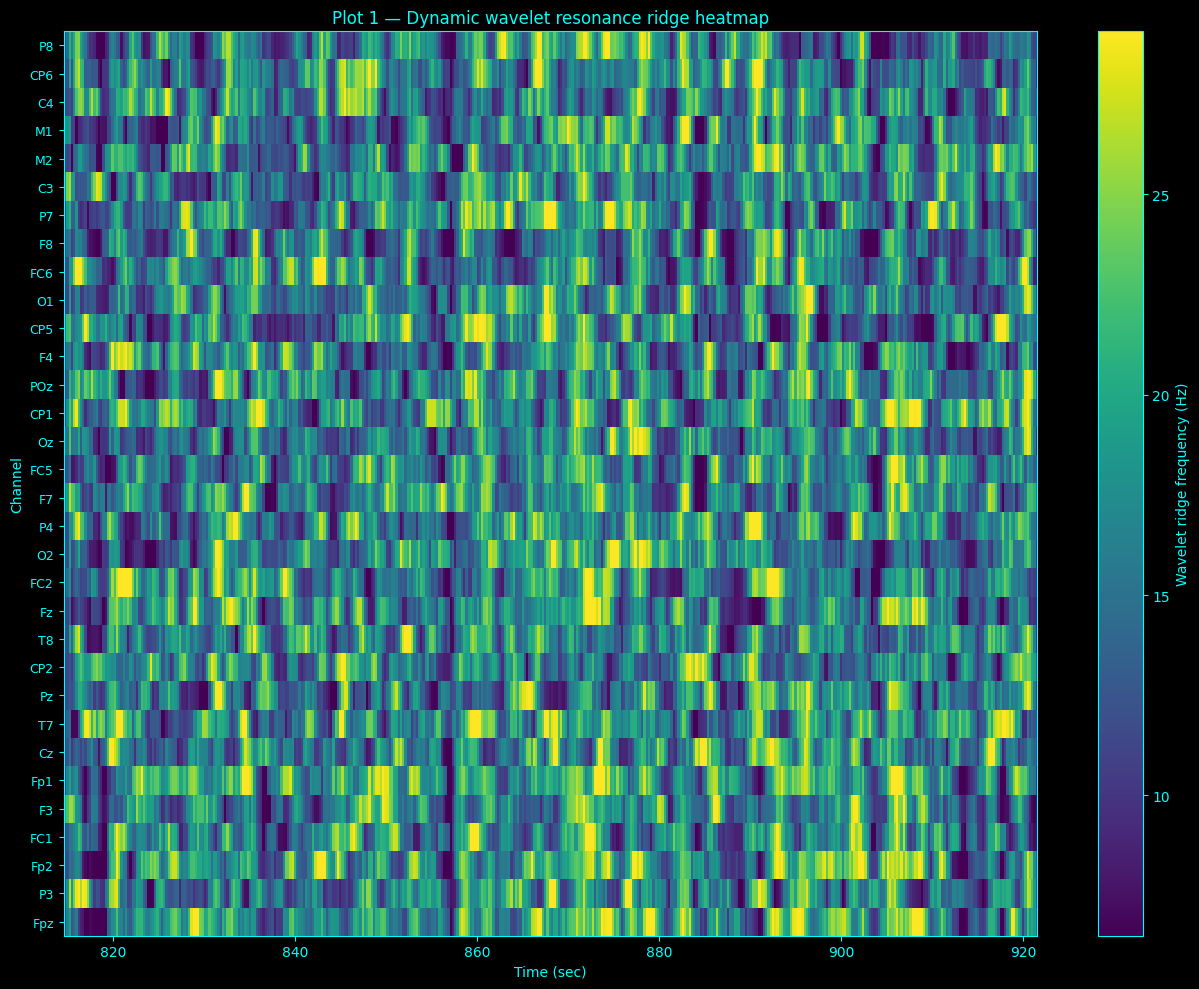

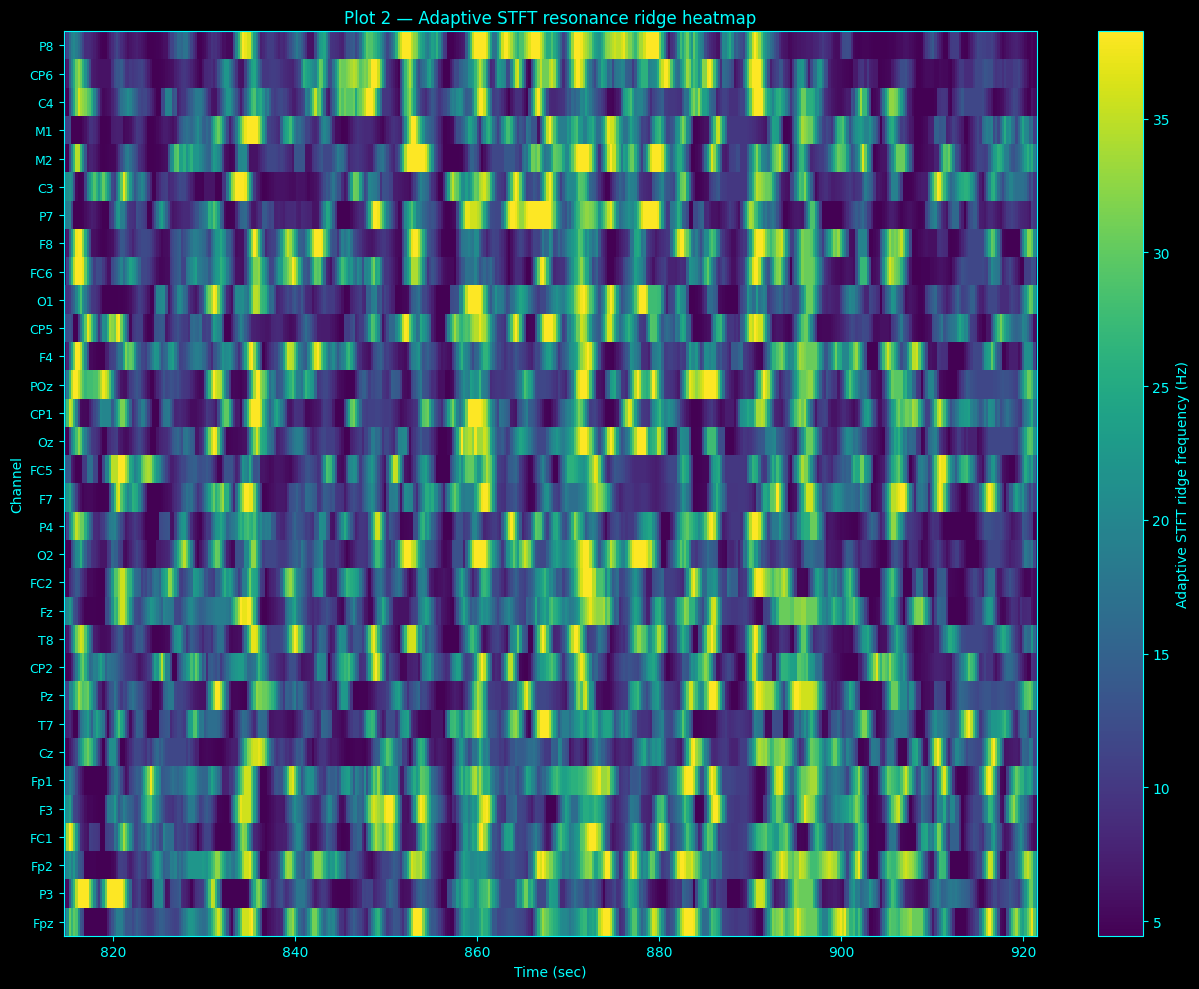

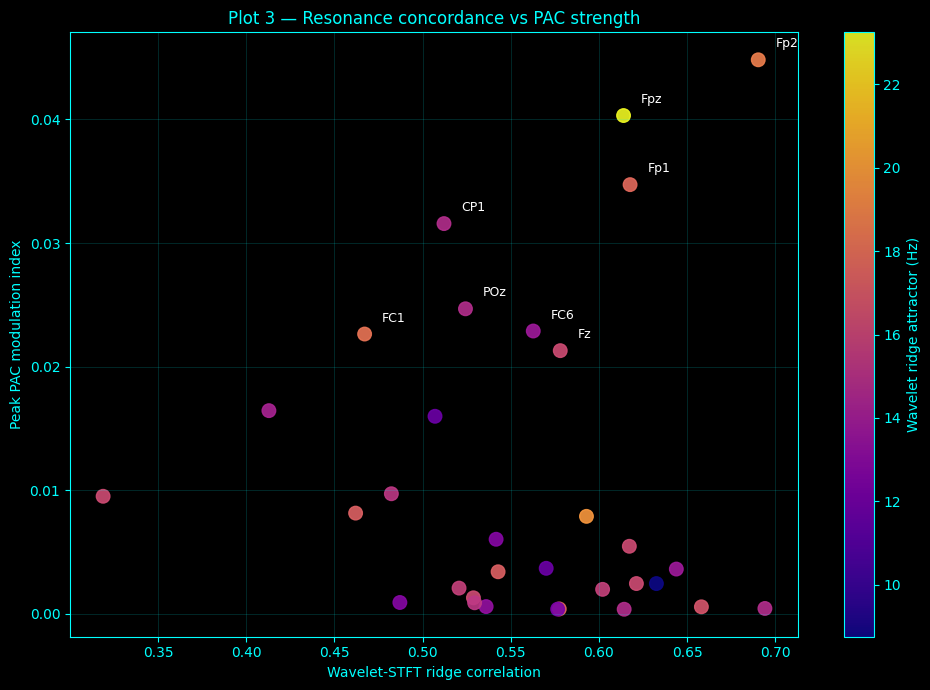

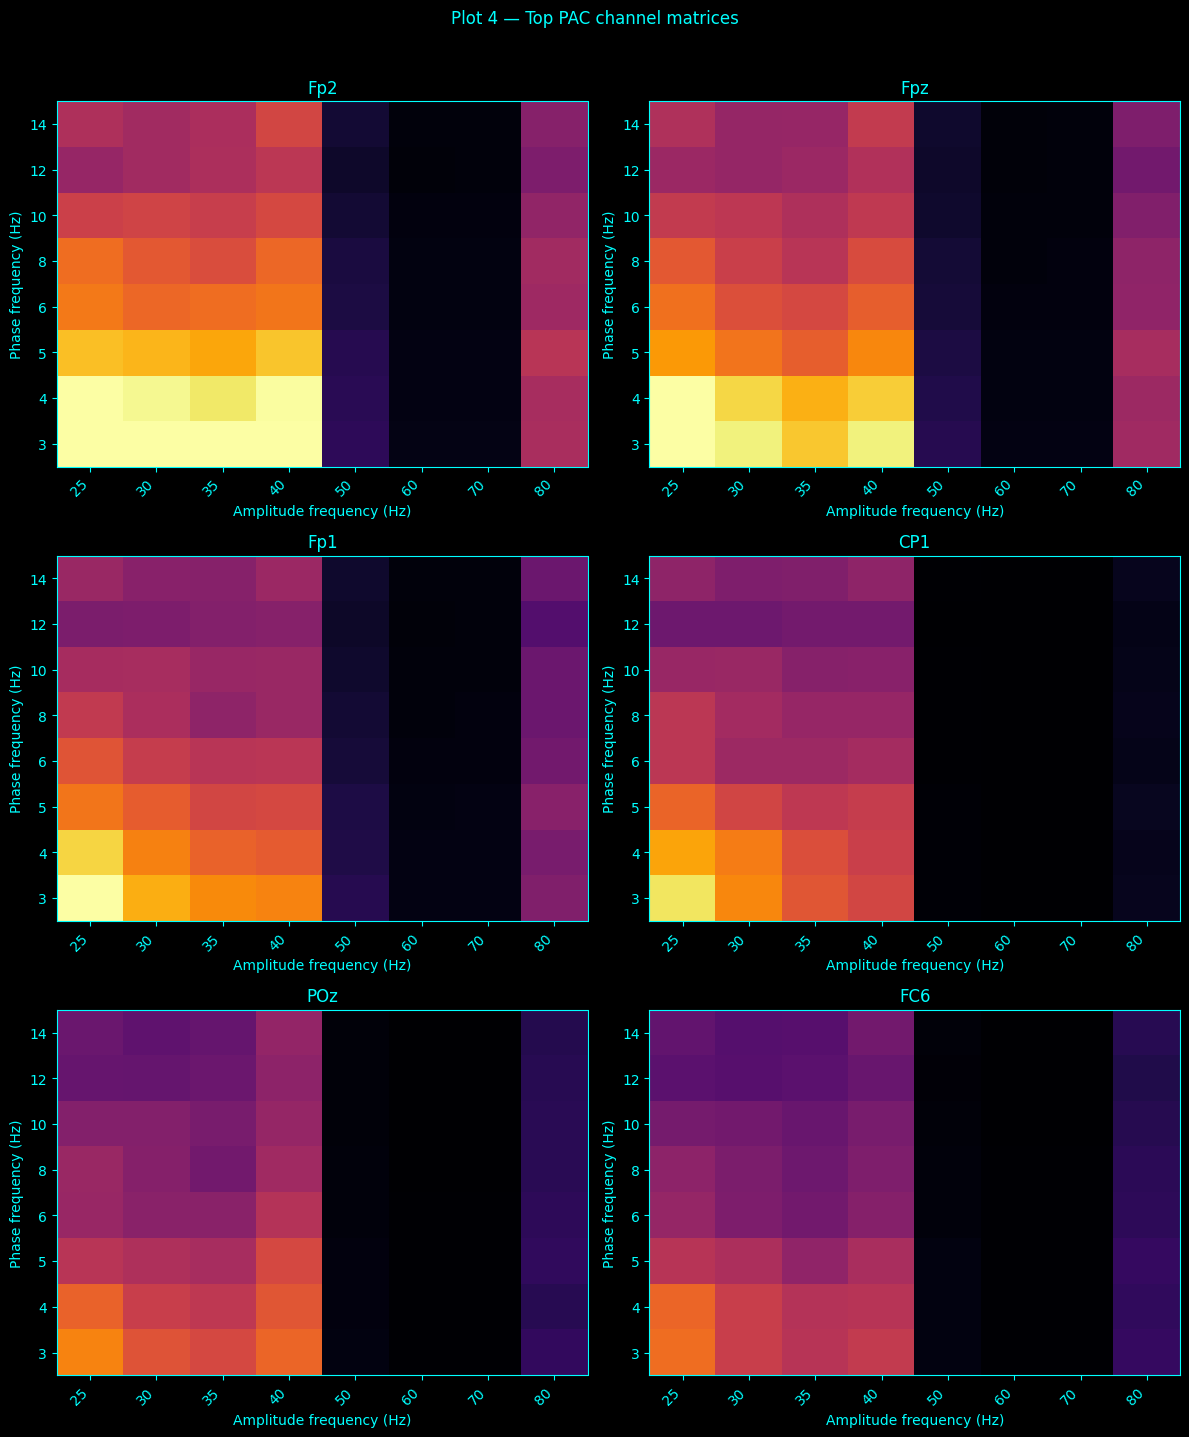

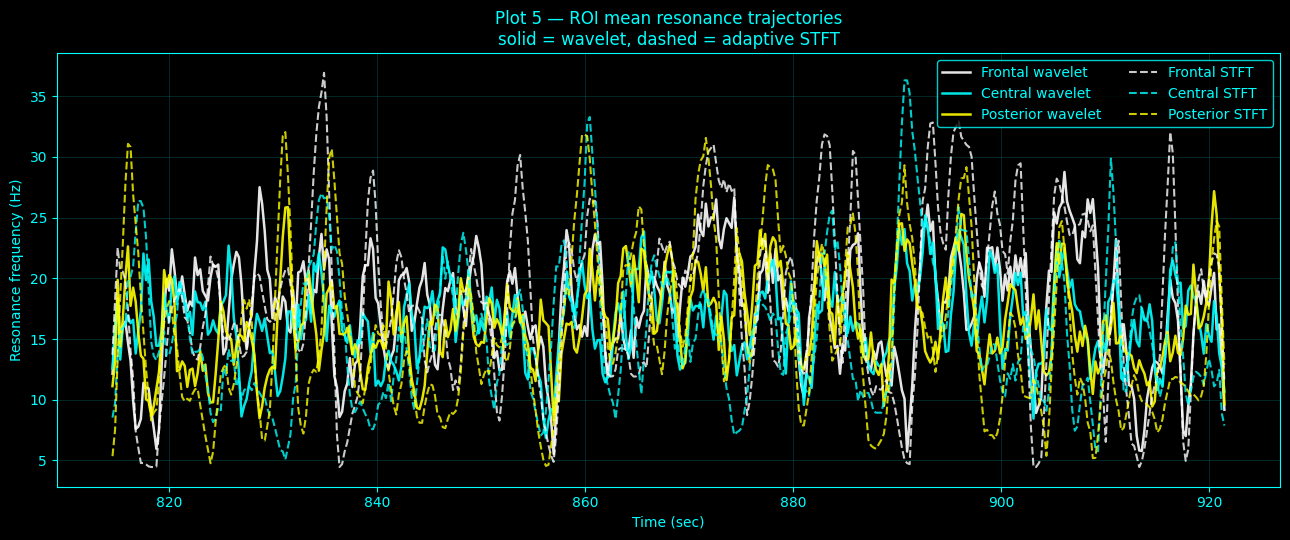


Saved dict NPY: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_resonance_cfc_wavelet_adaptive_stft_FIXED/resonance_cfc_wavelet_adaptive_stft_dict.npy
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_resonance_cfc_wavelet_adaptive_stft_FIXED/resonance_cfc_wavelet_adaptive_stft_summary.csv
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_resonance_cfc_wavelet_adaptive_stft_FIXED/resonance_cfc_wavelet_adaptive_stft_outputs.npz
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_resonance_cfc_wavelet_adaptive_stft_FIXED/resonance_cfc_wavelet_adaptive_stft_notes.txt
Saved plot 1: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_resonance_cfc_wavelet_adaptive_stft_FIXED/plots/plot1_wavelet_resonance_ridge_heatmap.png
Saved plot 2: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_resonance_cfc_wavelet_adaptive_stft_FIXED/plots/p

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, ndimage

# -------------------------------------------------------
# NUMPY 1.x / 2.x COMPATIBILITY
# -------------------------------------------------------
if hasattr(np, "trapezoid"):
    integrate_trapezoid = np.trapezoid
else:
    integrate_trapezoid = np.trapz

# -------------------------------------------------------
# CONFIG — FILE PATHS ONLY, NO NOTEBOOK MEMORY
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_resonance_cfc_wavelet_adaptive_stft_FIXED")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# -------------------------------------------------------
# ANALYSIS DESIGN
# -------------------------------------------------------
# Key fixes relative to the broken version:
#
# 1. NaN-aware smoothing:
#    adaptive STFT legitimately leaves unsupported edge regions as NaN.
#    Standard uniform filters propagate NaNs and can poison the whole map.
#    Here we smooth data and validity weights separately.
#
# 2. Band-limited ridge extraction:
#    extracting ridges over the entire 2–80 Hz map is too permissive and
#    chases transient maxima/noise. We constrain the resonance ridge to a
#    more interpretable exploratory band and smooth the resulting trajectory.
#
# 3. Ridge smoothing:
#    raw ridge picks are converted into continuous trajectories using
#    finite-value interpolation followed by temporal smoothing.
#
# 4. Safer descriptor plotting:
#    the descriptor-space plot now explicitly checks for finite points.

apply_common_average_reference = False
detrend_mode = "constant"
zscore_each_channel = False

analysis_downsample_factor = 4
fs_analysis = sampling_rate / analysis_downsample_factor  # 250 Hz

common_step_sec = 0.25

# Dynamic wavelet config
wavelet_freqs_hz = np.geomspace(2.0, 80.0, 36)
wavelet_n_cycles = 7.0
wavelet_support_sigma = 4.0
wavelet_freq_smooth_bins = 3
wavelet_time_smooth_bins = 7

# Adaptive STFT config
stft_freqs_hz = np.geomspace(2.0, 80.0, 24)
adaptive_stft_cycles = 6.0
adaptive_stft_min_window_sec = 0.50
adaptive_stft_max_window_sec = 6.00

# Resonance ridge band: deliberately narrower than the full map
resonance_ridge_band = (4.0, 45.0)
ridge_smooth_sec = 1.25

# CFC / PAC config
phase_freqs_hz = np.array([3.0, 4.0, 5.0, 6.0, 8.0, 10.0, 12.0, 14.0])
amp_freqs_hz = np.array([25.0, 30.0, 35.0, 40.0, 50.0, 60.0, 70.0, 80.0])
phase_bandwidth_hz = 2.0
amp_halfwidth_min_hz = 4.0
amp_halfwidth_fraction = 0.20
pac_phase_bins = 18

dynamic_pac_window_sec = 6.0

alpha_band = (8.0, 13.0)
theta_band = (4.0, 8.0)
beta_band = (13.0, 30.0)
low_gamma_band = (30.0, 80.0)

ridge_lock_tolerance_hz = 1.0

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

roi_definitions = {
    "frontal":   ['Fp1', 'Fpz', 'Fp2', 'F3', 'Fz', 'F4'],
    "central":   ['C3', 'Cz', 'C4'],
    "posterior": ['P3', 'Pz', 'P4', 'O1', 'Oz', 'O2'],
}

ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

# -------------------------------------------------------
# GENERAL HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def preprocess_channel(y, detrend_mode="constant", zscore=False):
    y = np.asarray(y, dtype=float)
    if detrend_mode is not None:
        y = signal.detrend(y, type=detrend_mode)
    if zscore:
        sd = np.std(y)
        y = (y - np.mean(y)) / (sd + eps)
    return y.astype(np.float32)

def band_mask(freqs_hz, band):
    lo, hi = band
    return (freqs_hz >= lo) & (freqs_hz <= hi)

def smooth_1d(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def roi_average_matrix(matrix_time_by_channel, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]
    if len(idx) == 0:
        return np.full(matrix_time_by_channel.shape[0], np.nan)
    return np.nanmean(matrix_time_by_channel[:, idx], axis=1)

def band_fraction_from_hist(freq_series_hz, band):
    x = np.asarray(freq_series_hz, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    return float(np.mean((x >= band[0]) & (x <= band[1])))

def hist_attractor_and_entropy(freq_series_hz, band=(2.0, 80.0), bin_width_hz=0.5):
    vals = np.asarray(freq_series_hz, dtype=float)
    vals = vals[np.isfinite(vals)]
    vals = vals[(vals >= band[0]) & (vals <= band[1])]
    bins = np.arange(band[0], band[1] + bin_width_hz, bin_width_hz)

    if len(vals) == 0:
        centers = 0.5 * (bins[:-1] + bins[1:])
        return np.nan, np.nan, centers, np.zeros(len(centers), dtype=float)

    hist, _ = np.histogram(vals, bins=bins)
    hist = hist.astype(float)
    hist = hist / (np.sum(hist) + eps)
    centers = 0.5 * (bins[:-1] + bins[1:])
    attractor = float(centers[np.argmax(hist)])

    positive = hist[hist > 0]
    H = -np.sum(positive * np.log(positive + eps))
    Hmax = np.log(len(hist) + eps)
    Hn = float(H / (Hmax + eps))
    return attractor, Hn, centers, hist

def safe_corr(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    if np.sum(mask) < 3:
        return np.nan
    a = a[mask]
    b = b[mask]
    if np.std(a) < eps or np.std(b) < eps:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

# -------------------------------------------------------
# NaN-AWARE SMOOTHING
# -------------------------------------------------------
def nan_uniform_filter1d(arr, size, axis):
    arr = np.asarray(arr, dtype=float)
    valid = np.isfinite(arr).astype(float)
    data = np.where(np.isfinite(arr), arr, 0.0)

    smooth_data = ndimage.uniform_filter1d(data, size=max(int(size), 1), axis=axis, mode="nearest")
    smooth_valid = ndimage.uniform_filter1d(valid, size=max(int(size), 1), axis=axis, mode="nearest")

    out = smooth_data / np.maximum(smooth_valid, eps)
    out[smooth_valid < 1e-6] = np.nan
    return out

def smooth_map_2d_nanaware(x, freq_bins=3, time_bins=7):
    y = nan_uniform_filter1d(np.asarray(x, dtype=float), size=max(int(time_bins), 1), axis=1)
    y = nan_uniform_filter1d(y, size=max(int(freq_bins), 1), axis=0)
    return y.astype(np.float32)

def fill_nan_linear(x):
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return x
    idx = np.arange(len(x))
    mask = np.isfinite(x)
    if np.sum(mask) == 0:
        return np.full_like(x, np.nan, dtype=float)
    if np.sum(mask) == 1:
        return np.full_like(x, x[mask][0], dtype=float)
    return np.interp(idx, idx[mask], x[mask])

def smooth_nan_series(x, win=5):
    x = np.asarray(x, dtype=float)
    if np.all(~np.isfinite(x)):
        return np.full_like(x, np.nan, dtype=float)
    y = fill_nan_linear(x)
    y = smooth_1d(y, win=win)
    return y

# -------------------------------------------------------
# MAP / RIDGE HELPERS
# -------------------------------------------------------
def frequencywise_zlog_power(power_2d):
    power_2d = np.asarray(power_2d, dtype=float)
    logp = np.where(np.isfinite(power_2d), np.log10(np.maximum(power_2d, eps)), np.nan)
    return (logp - np.nanmean(logp, axis=1, keepdims=True)) / (np.nanstd(logp, axis=1, keepdims=True) + eps)

def ridge_from_map(freqs_hz, map_2d, ridge_band=(4.0, 45.0), smooth_win=5):
    """
    Band-limited, NaN-safe ridge extraction.
    Returns both raw and smoothed ridge.
    """
    freqs_hz = np.asarray(freqs_hz, dtype=float)
    map_2d = np.asarray(map_2d, dtype=float)

    mask = band_mask(freqs_hz, ridge_band)
    f_sub = freqs_hz[mask]
    m_sub = map_2d[mask]

    raw = np.full(m_sub.shape[1], np.nan, dtype=float)
    valid_cols = np.any(np.isfinite(m_sub), axis=0)

    if np.any(valid_cols):
        idx = np.nanargmax(m_sub[:, valid_cols], axis=0)
        raw[valid_cols] = f_sub[idx]

    smoothed = smooth_nan_series(raw, win=max(int(smooth_win), 1))
    return raw, smoothed

# -------------------------------------------------------
# FILTER / HILBERT HELPERS
# -------------------------------------------------------
def butter_bandpass_sos(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = max(lowcut / nyq, 1e-6)
    high = min(highcut / nyq, 0.999)
    if not (low < high):
        raise ValueError(f"Invalid band: {lowcut}-{highcut} Hz for fs={fs}")
    return signal.butter(order, [low, high], btype="bandpass", output="sos")

def extract_phase_band(y, fs, center_hz, bandwidth_hz):
    half = 0.5 * bandwidth_hz
    low = max(0.2, center_hz - half)
    high = center_hz + half
    sos = butter_bandpass_sos(low, high, fs, order=4)
    y_f = signal.sosfiltfilt(sos, y)
    analytic = signal.hilbert(y_f)
    return np.angle(analytic)

def extract_amplitude_band(y, fs, center_hz, halfwidth_hz):
    low = max(1.0, center_hz - halfwidth_hz)
    high = center_hz + halfwidth_hz
    sos = butter_bandpass_sos(low, high, fs, order=4)
    y_f = signal.sosfiltfilt(sos, y)
    analytic = signal.hilbert(y_f)
    return np.abs(analytic)

# -------------------------------------------------------
# PAC HELPERS
# -------------------------------------------------------
def tort_modulation_index(phase_rad, amp_envelope, n_bins=18):
    phase_rad = np.asarray(phase_rad, dtype=float)
    amp_envelope = np.asarray(amp_envelope, dtype=float)
    mask = np.isfinite(phase_rad) & np.isfinite(amp_envelope)
    if np.sum(mask) < n_bins * 10:
        return np.nan

    phase_rad = phase_rad[mask]
    amp_envelope = amp_envelope[mask]

    bins = np.linspace(-np.pi, np.pi, n_bins + 1)
    amp_means = np.zeros(n_bins, dtype=float)

    for i in range(n_bins):
        m = (phase_rad >= bins[i]) & (phase_rad < bins[i + 1])
        if np.any(m):
            amp_means[i] = np.mean(amp_envelope[m])

    if np.sum(amp_means) <= 0:
        return np.nan

    p = amp_means / (np.sum(amp_means) + eps)
    H = -np.sum(p * np.log(p + eps))
    Hmax = np.log(n_bins + eps)
    mi = (Hmax - H) / (Hmax + eps)
    return float(mi)

def dynamic_pac_series(phase_rad, amp_envelope, fs, centers_sec, window_sec=6.0, n_bins=18):
    half = int(round(0.5 * window_sec * fs))
    pac_vals = np.full(len(centers_sec), np.nan, dtype=float)

    for i, c_sec in enumerate(centers_sec):
        c = int(round(c_sec * fs))
        start = max(0, c - half)
        stop = min(len(phase_rad), c + half)
        if stop - start < int(2.0 * fs):
            continue
        pac_vals[i] = tort_modulation_index(
            phase_rad[start:stop],
            amp_envelope[start:stop],
            n_bins=n_bins,
        )

    return pac_vals

# -------------------------------------------------------
# WAVELET HELPERS
# -------------------------------------------------------
def morlet_wavelet(f_hz, fs, n_cycles=7.0, support_sigma=4.0):
    sigma_t = n_cycles / (2.0 * np.pi * f_hz)
    half_width_sec = support_sigma * sigma_t
    t = np.arange(-half_width_sec, half_width_sec + 1.0 / fs, 1.0 / fs)
    w = np.exp(2j * np.pi * f_hz * t) * np.exp(-(t ** 2) / (2.0 * sigma_t ** 2))
    w = w / np.sqrt(np.sum(np.abs(w) ** 2) + eps)
    return w.astype(np.complex64)

def compute_morlet_coeffs(y, fs, freqs_hz, n_cycles=7.0, support_sigma=4.0):
    y = np.asarray(y, dtype=np.float32)
    rows = []
    for f_hz in freqs_hz:
        w = morlet_wavelet(f_hz, fs, n_cycles=n_cycles, support_sigma=support_sigma)
        coeff = signal.fftconvolve(y, np.conjugate(w[::-1]), mode="same")
        rows.append(coeff.astype(np.complex64))
    return np.vstack(rows)

# -------------------------------------------------------
# ADAPTIVE STFT HELPERS
# -------------------------------------------------------
def adaptive_stft_map(y, fs, target_freqs_hz, common_times_sec,
                      n_cycles=6.0, min_window_sec=0.5, max_window_sec=6.0):
    """
    Frequency-adaptive spectrogram.
    Edge NaNs are expected for long windows; those are handled downstream.
    """
    y = np.asarray(y, dtype=float)
    out = np.full((len(target_freqs_hz), len(common_times_sec)), np.nan, dtype=float)
    step_samples = max(int(round(common_step_sec * fs)), 1)

    for k, f0 in enumerate(target_freqs_hz):
        win_sec = np.clip(n_cycles / f0, min_window_sec, max_window_sec)
        nperseg = int(round(win_sec * fs))
        nperseg = max(nperseg, 32)
        nperseg = min(nperseg, len(y))
        noverlap = max(0, nperseg - step_samples)
        noverlap = min(noverlap, nperseg - 1)

        f, t, Sxx = signal.spectrogram(
            y,
            fs=fs,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            detrend="constant",
            scaling="density",
            mode="psd",
        )

        band_half = max(0.75, 0.15 * f0)
        mask = np.abs(f - f0) <= band_half
        if not np.any(mask):
            idx = int(np.argmin(np.abs(f - f0)))
            power_series = Sxx[idx]
        else:
            power_series = np.nanmean(Sxx[mask], axis=0)

        valid = np.isfinite(t) & np.isfinite(power_series)
        if np.sum(valid) < 2:
            continue

        out[k] = np.interp(
            common_times_sec,
            t[valid],
            power_series[valid],
            left=np.nan,
            right=np.nan,
        )

    return out

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

segment_ds = signal.resample_poly(segment, up=1, down=analysis_downsample_factor, axis=0)
segment_ds = np.asarray(segment_ds, dtype=np.float32)

n_time_ds = segment_ds.shape[0]
common_step_samples = max(int(round(common_step_sec * fs_analysis)), 1)
common_idx = np.arange(0, n_time_ds, common_step_samples, dtype=int)
common_time_sec_rel = common_idx / fs_analysis
common_time_sec_abs = start_time + common_time_sec_rel

ridge_smooth_bins = max(int(round(ridge_smooth_sec / common_step_sec)), 1)

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Original segment shape: {segment.shape}")
print(f"Downsampled segment shape: {segment_ds.shape}")
print(f"Analysis fs: {fs_analysis:.1f} Hz")
print(f"Common time points: {len(common_time_sec_abs)}")

# -------------------------------------------------------
# PREALLOCATE OUTPUT ARRAYS
# -------------------------------------------------------
n_channels = len(eeg_channel_names)
n_wavelet_freqs = len(wavelet_freqs_hz)
n_stft_freqs = len(stft_freqs_hz)
n_phase_freqs = len(phase_freqs_hz)
n_amp_freqs = len(amp_freqs_hz)
n_common_t = len(common_time_sec_rel)

wavelet_map_z = np.full((n_wavelet_freqs, n_common_t, n_channels), np.nan, dtype=np.float32)
stft_map_z = np.full((n_stft_freqs, n_common_t, n_channels), np.nan, dtype=np.float32)

wavelet_ridge_raw_hz = np.full((n_common_t, n_channels), np.nan, dtype=np.float32)
wavelet_ridge_hz = np.full((n_common_t, n_channels), np.nan, dtype=np.float32)

stft_ridge_raw_hz = np.full((n_common_t, n_channels), np.nan, dtype=np.float32)
stft_ridge_hz = np.full((n_common_t, n_channels), np.nan, dtype=np.float32)

wavelet_alpha_env = np.full((n_common_t, n_channels), np.nan, dtype=np.float32)
stft_alpha_env = np.full((n_common_t, n_channels), np.nan, dtype=np.float32)

pac_mi_cube = np.full((n_phase_freqs, n_amp_freqs, n_channels), np.nan, dtype=np.float32)
dynamic_pac_matrix = np.full((n_common_t, n_channels), np.nan, dtype=np.float32)

summary_rows = []
channel_output_dict = {}

# -------------------------------------------------------
# CORE PER-CHANNEL ANALYSIS
# -------------------------------------------------------
for ch_i, ch_name in enumerate(eeg_channel_names):
    print(f"Processing {ch_name} ({ch_i + 1}/{n_channels})")

    y = preprocess_channel(
        segment_ds[:, ch_i],
        detrend_mode=detrend_mode,
        zscore=zscore_each_channel,
    )

    # -----------------------------------------------
    # 1) Dynamic wavelet analysis
    # -----------------------------------------------
    coeffs = compute_morlet_coeffs(
        y,
        fs_analysis,
        wavelet_freqs_hz,
        n_cycles=wavelet_n_cycles,
        support_sigma=wavelet_support_sigma,
    )
    power = np.abs(coeffs) ** 2
    wavelet_z_full = frequencywise_zlog_power(power)
    wavelet_z_full = smooth_map_2d_nanaware(
        wavelet_z_full,
        freq_bins=wavelet_freq_smooth_bins,
        time_bins=wavelet_time_smooth_bins,
    )
    wavelet_z_common = wavelet_z_full[:, common_idx]
    wavelet_map_z[:, :, ch_i] = wavelet_z_common.astype(np.float32)

    wave_ridge_raw, wave_ridge = ridge_from_map(
        wavelet_freqs_hz,
        wavelet_z_common,
        ridge_band=resonance_ridge_band,
        smooth_win=ridge_smooth_bins,
    )
    wavelet_ridge_raw_hz[:, ch_i] = wave_ridge_raw.astype(np.float32)
    wavelet_ridge_hz[:, ch_i] = wave_ridge.astype(np.float32)

    alpha_mask_wave = band_mask(wavelet_freqs_hz, alpha_band)
    if np.any(alpha_mask_wave):
        wave_alpha = np.nanmean(power[alpha_mask_wave][:, common_idx], axis=0)
        wavelet_alpha_env[:, ch_i] = np.log10(wave_alpha + eps).astype(np.float32)

    wavelet_attractor, wavelet_hist_entropy, ridge_hist_centers, ridge_hist = hist_attractor_and_entropy(
        wave_ridge, band=resonance_ridge_band, bin_width_hz=0.5
    )
    wavelet_ridge_std = float(np.nanstd(wave_ridge))
    wavelet_persistence = float(np.nanmean(np.abs(wave_ridge - wavelet_attractor) <= ridge_lock_tolerance_hz)) if np.isfinite(wavelet_attractor) else np.nan
    wavelet_alpha_occupancy = band_fraction_from_hist(wave_ridge, alpha_band)
    wavelet_beta_occupancy = band_fraction_from_hist(wave_ridge, beta_band)

    # -----------------------------------------------
    # 2) Adaptive STFT analysis
    # -----------------------------------------------
    stft_power = adaptive_stft_map(
        y,
        fs_analysis,
        stft_freqs_hz,
        common_time_sec_rel,
        n_cycles=adaptive_stft_cycles,
        min_window_sec=adaptive_stft_min_window_sec,
        max_window_sec=adaptive_stft_max_window_sec,
    )
    stft_z = frequencywise_zlog_power(stft_power)
    stft_z = smooth_map_2d_nanaware(stft_z, freq_bins=3, time_bins=5)
    stft_map_z[:, :, ch_i] = stft_z.astype(np.float32)

    stft_ridge_raw, stft_ridge = ridge_from_map(
        stft_freqs_hz,
        stft_z,
        ridge_band=resonance_ridge_band,
        smooth_win=ridge_smooth_bins,
    )
    stft_ridge_raw_hz[:, ch_i] = stft_ridge_raw.astype(np.float32)
    stft_ridge_hz[:, ch_i] = stft_ridge.astype(np.float32)

    alpha_mask_stft = band_mask(stft_freqs_hz, alpha_band)
    if np.any(alpha_mask_stft):
        stft_alpha = np.nanmean(stft_power[alpha_mask_stft], axis=0)
        stft_alpha_env[:, ch_i] = np.log10(stft_alpha + eps).astype(np.float32)

    stft_attractor, stft_hist_entropy, _, _ = hist_attractor_and_entropy(
        stft_ridge, band=resonance_ridge_band, bin_width_hz=0.5
    )
    stft_ridge_std = float(np.nanstd(stft_ridge))
    stft_persistence = float(np.nanmean(np.abs(stft_ridge - stft_attractor) <= ridge_lock_tolerance_hz)) if np.isfinite(stft_attractor) else np.nan
    stft_alpha_occupancy = band_fraction_from_hist(stft_ridge, alpha_band)
    stft_beta_occupancy = band_fraction_from_hist(stft_ridge, beta_band)

    # -----------------------------------------------
    # 3) Cross-method resonance concordance
    # -----------------------------------------------
    ridge_corr = safe_corr(wave_ridge, stft_ridge)
    ridge_gap = float(np.nanmean(np.abs(wave_ridge - stft_ridge)))
    attractor_gap = float(abs(wavelet_attractor - stft_attractor)) if np.isfinite(wavelet_attractor) and np.isfinite(stft_attractor) else np.nan
    alpha_env_corr = safe_corr(wavelet_alpha_env[:, ch_i], stft_alpha_env[:, ch_i])

    # -----------------------------------------------
    # 4) Phase-amplitude coupling
    # -----------------------------------------------
    phase_series = {}
    amp_series = {}

    for pf in phase_freqs_hz:
        phase_series[pf] = extract_phase_band(y, fs_analysis, pf, phase_bandwidth_hz)

    for af in amp_freqs_hz:
        halfw = max(amp_halfwidth_min_hz, amp_halfwidth_fraction * af)
        amp_series[af] = extract_amplitude_band(y, fs_analysis, af, halfw)

    pac_matrix = np.full((n_phase_freqs, n_amp_freqs), np.nan, dtype=float)

    for p_i, pf in enumerate(phase_freqs_hz):
        phi = phase_series[pf]
        for a_i, af in enumerate(amp_freqs_hz):
            amp_env = amp_series[af]
            pac_matrix[p_i, a_i] = tort_modulation_index(phi, amp_env, n_bins=pac_phase_bins)

    pac_mi_cube[:, :, ch_i] = pac_matrix.astype(np.float32)

    if np.all(~np.isfinite(pac_matrix)):
        pac_peak_phase = np.nan
        pac_peak_amp = np.nan
        pac_peak_mi = np.nan
        dynamic_pac = np.full(n_common_t, np.nan, dtype=float)
    else:
        pac_peak_idx = np.unravel_index(np.nanargmax(pac_matrix), pac_matrix.shape)
        pac_peak_phase = float(phase_freqs_hz[pac_peak_idx[0]])
        pac_peak_amp = float(amp_freqs_hz[pac_peak_idx[1]])
        pac_peak_mi = float(pac_matrix[pac_peak_idx])

        dynamic_pac = dynamic_pac_series(
            phase_series[pac_peak_phase],
            amp_series[pac_peak_amp],
            fs_analysis,
            common_time_sec_rel,
            window_sec=dynamic_pac_window_sec,
            n_bins=pac_phase_bins,
        )

    dynamic_pac_matrix[:, ch_i] = dynamic_pac.astype(np.float32)
    dynamic_pac_mean = float(np.nanmean(dynamic_pac))
    dynamic_pac_std = float(np.nanstd(dynamic_pac))

    # -----------------------------------------------
    # 5) Cross-family exploratory descriptors
    # -----------------------------------------------
    cfc_alignment_wavelet = float(abs(pac_peak_phase - wavelet_attractor)) if np.isfinite(pac_peak_phase) and np.isfinite(wavelet_attractor) else np.nan
    cfc_alignment_stft = float(abs(pac_peak_phase - stft_attractor)) if np.isfinite(pac_peak_phase) and np.isfinite(stft_attractor) else np.nan
    phase_amp_ratio = float(pac_peak_amp / (pac_peak_phase + eps)) if np.isfinite(pac_peak_amp) and np.isfinite(pac_peak_phase) else np.nan

    dual_method_resonance_lock = (
        pac_peak_mi * max(ridge_corr, 0.0) / (1.0 + ridge_gap)
        if np.isfinite(pac_peak_mi) and np.isfinite(ridge_corr) and np.isfinite(ridge_gap)
        else np.nan
    )

    channel_output_dict[ch_name] = {
        "wavelet_ridge_raw_hz": wave_ridge_raw,
        "wavelet_ridge_hz": wave_ridge,
        "stft_ridge_raw_hz": stft_ridge_raw,
        "stft_ridge_hz": stft_ridge,
        "pac_matrix": pac_matrix,
        "dynamic_pac": dynamic_pac,
        "wavelet_attractor_hz": wavelet_attractor,
        "stft_attractor_hz": stft_attractor,
        "pac_peak_phase_hz": pac_peak_phase,
        "pac_peak_amp_hz": pac_peak_amp,
        "pac_peak_mi": pac_peak_mi,
    }

    summary_rows.append({
        "channel": ch_name,
        "wavelet_attractor_hz": wavelet_attractor,
        "wavelet_ridge_std_hz": wavelet_ridge_std,
        "wavelet_persistence_fraction": wavelet_persistence,
        "wavelet_alpha_occupancy": wavelet_alpha_occupancy,
        "wavelet_beta_occupancy": wavelet_beta_occupancy,
        "wavelet_ridge_hist_entropy": wavelet_hist_entropy,

        "stft_attractor_hz": stft_attractor,
        "stft_ridge_std_hz": stft_ridge_std,
        "stft_persistence_fraction": stft_persistence,
        "stft_alpha_occupancy": stft_alpha_occupancy,
        "stft_beta_occupancy": stft_beta_occupancy,
        "stft_ridge_hist_entropy": stft_hist_entropy,

        "ridge_correlation_wavelet_vs_stft": ridge_corr,
        "ridge_mean_abs_gap_hz": ridge_gap,
        "attractor_gap_hz": attractor_gap,
        "alpha_envelope_correlation_wavelet_vs_stft": alpha_env_corr,

        "pac_peak_phase_hz": pac_peak_phase,
        "pac_peak_amp_hz": pac_peak_amp,
        "pac_peak_mi": pac_peak_mi,
        "dynamic_pac_mean": dynamic_pac_mean,
        "dynamic_pac_std": dynamic_pac_std,

        "cfc_alignment_to_wavelet_hz": cfc_alignment_wavelet,
        "cfc_alignment_to_stft_hz": cfc_alignment_stft,
        "phase_amp_ratio": phase_amp_ratio,
        "dual_method_resonance_lock": dual_method_resonance_lock,
    })

summary_df = pd.DataFrame(summary_rows)
for col in summary_df.columns:
    if col != "channel":
        summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
dict_npy_path = os.path.join(out_dir, "resonance_cfc_wavelet_adaptive_stft_dict.npy")
summary_csv_path = os.path.join(out_dir, "resonance_cfc_wavelet_adaptive_stft_summary.csv")
npz_path = os.path.join(out_dir, "resonance_cfc_wavelet_adaptive_stft_outputs.npz")
notes_txt_path = os.path.join(out_dir, "resonance_cfc_wavelet_adaptive_stft_notes.txt")

plot1_path = os.path.join(plots_dir, "plot1_wavelet_resonance_ridge_heatmap.png")
plot2_path = os.path.join(plots_dir, "plot2_adaptive_stft_ridge_heatmap.png")
plot3_path = os.path.join(plots_dir, "plot3_descriptor_space_resonance_vs_cfc.png")
plot4_path = os.path.join(plots_dir, "plot4_top_pac_channel_matrices.png")
plot5_path = os.path.join(plots_dir, "plot5_roi_mean_resonance_trajectories.png")

np.save(dict_npy_path, channel_output_dict, allow_pickle=True)
summary_df.to_csv(summary_csv_path, index=False)

np.savez_compressed(
    npz_path,
    channel_names=np.array(eeg_channel_names, dtype=object),
    common_time_sec_abs=common_time_sec_abs,
    common_time_sec_rel=common_time_sec_rel,
    wavelet_freqs_hz=wavelet_freqs_hz,
    stft_freqs_hz=stft_freqs_hz,
    phase_freqs_hz=phase_freqs_hz,
    amp_freqs_hz=amp_freqs_hz,
    wavelet_map_z=wavelet_map_z,
    stft_map_z=stft_map_z,
    wavelet_ridge_raw_hz=wavelet_ridge_raw_hz,
    wavelet_ridge_hz=wavelet_ridge_hz,
    stft_ridge_raw_hz=stft_ridge_raw_hz,
    stft_ridge_hz=stft_ridge_hz,
    wavelet_alpha_env=wavelet_alpha_env,
    stft_alpha_env=stft_alpha_env,
    pac_mi_cube=pac_mi_cube,
    dynamic_pac_matrix=dynamic_pac_matrix,
    start_time=start_time,
    end_time=end_time,
    original_sampling_rate=sampling_rate,
    analysis_sampling_rate=fs_analysis,
    analysis_downsample_factor=analysis_downsample_factor,
)

top_lock = summary_df.sort_values("dual_method_resonance_lock", ascending=False, na_position="last").head(8)
top_pac = summary_df.sort_values("pac_peak_mi", ascending=False, na_position="last").head(8)

with open(notes_txt_path, "w") as f:
    f.write("Exploratory resonance analysis using CFC, dynamic wavelet analysis, and adaptive STFT\n")
    f.write("=====================================================================================\n\n")
    f.write("What was wrong in the broken version:\n")
    f.write("1. Adaptive STFT maps had expected edge NaNs.\n")
    f.write("2. Standard smoothing propagated those NaNs and effectively wiped out the STFT maps.\n")
    f.write("3. Ridge extraction then returned all-NaN STFT ridges.\n")
    f.write("4. Descriptor plots depending on STFT ridge correlation therefore appeared empty.\n")
    f.write("5. Wavelet ridges were also too noisy because the ridge was taken from an overly broad map without continuity control.\n\n")
    f.write("What this version fixes:\n")
    f.write("- NaN-aware smoothing\n")
    f.write("- band-limited ridge extraction\n")
    f.write("- smoothed ridge trajectories\n")
    f.write("- safer descriptor plotting\n\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Original fs: {sampling_rate} Hz\n")
    f.write(f"Analysis fs: {fs_analysis:.1f} Hz\n")
    f.write(f"Common step: {common_step_sec:.2f} sec\n")
    f.write(f"Resonance ridge band: [{resonance_ridge_band[0]:.1f}, {resonance_ridge_band[1]:.1f}] Hz\n")
    f.write(f"Ridge smoothing window: {ridge_smooth_sec:.2f} sec\n\n")

# -------------------------------------------------------
# PLOTTING PREP
# -------------------------------------------------------
ridge_sort_df = summary_df.sort_values(
    by=["wavelet_attractor_hz", "ridge_correlation_wavelet_vs_stft", "pac_peak_mi"],
    ascending=[True, False, False],
    na_position="last",
).reset_index(drop=True)

ridge_sorted_channels = list(ridge_sort_df["channel"].values)
ridge_sorted_idx = [eeg_channel_names.index(ch) for ch in ridge_sorted_channels]

# -------------------------------------------------------
# PLOT 1 — WAVELET RIDGE HEATMAP
# -------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(13, 10), facecolor=BG)
style_ax(ax1, heatmap=True)

heat1 = wavelet_ridge_hz[:, ridge_sorted_idx].T
vmin, vmax = percentile_limits(heat1, lo=2, hi=98)
if vmin is None or vmax is None:
    vmin, vmax = resonance_ridge_band

im1 = ax1.imshow(
    heat1,
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    extent=[common_time_sec_abs[0], common_time_sec_abs[-1], len(ridge_sorted_channels), 0],
)

ax1.set_title("Plot 1 — Dynamic wavelet resonance ridge heatmap")
ax1.set_xlabel("Time (sec)")
ax1.set_ylabel("Channel")
ax1.set_yticks(np.arange(len(ridge_sorted_channels)) + 0.5)
ax1.set_yticklabels(ridge_sorted_channels, fontsize=9)

cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label("Wavelet ridge frequency (Hz)", color=ACCENT)
cbar1.outline.set_edgecolor(ACCENT)
cbar1.ax.tick_params(color=ACCENT)
for label in cbar1.ax.get_yticklabels():
    label.set_color(ACCENT)

fig1.tight_layout()
fig1.savefig(plot1_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig1)

# -------------------------------------------------------
# PLOT 2 — ADAPTIVE STFT RIDGE HEATMAP
# -------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(13, 10), facecolor=BG)
style_ax(ax2, heatmap=True)

heat2 = stft_ridge_hz[:, ridge_sorted_idx].T
vmin, vmax = percentile_limits(heat2, lo=2, hi=98)
if vmin is None or vmax is None:
    vmin, vmax = resonance_ridge_band

im2 = ax2.imshow(
    heat2,
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    extent=[common_time_sec_abs[0], common_time_sec_abs[-1], len(ridge_sorted_channels), 0],
)

ax2.set_title("Plot 2 — Adaptive STFT resonance ridge heatmap")
ax2.set_xlabel("Time (sec)")
ax2.set_ylabel("Channel")
ax2.set_yticks(np.arange(len(ridge_sorted_channels)) + 0.5)
ax2.set_yticklabels(ridge_sorted_channels, fontsize=9)

cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label("Adaptive STFT ridge frequency (Hz)", color=ACCENT)
cbar2.outline.set_edgecolor(ACCENT)
cbar2.ax.tick_params(color=ACCENT)
for label in cbar2.ax.get_yticklabels():
    label.set_color(ACCENT)

fig2.tight_layout()
fig2.savefig(plot2_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig2)

# -------------------------------------------------------
# PLOT 3 — DESCRIPTOR SPACE
# -------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax3)

x = summary_df["ridge_correlation_wavelet_vs_stft"].values
y = summary_df["pac_peak_mi"].values
c = summary_df["wavelet_attractor_hz"].values
mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(c)

if np.sum(mask) == 0:
    ax3.text(0.5, 0.5, "No finite resonance–PAC descriptor points", ha="center", va="center", fontsize=12, color="white")
    ax3.set_xlim(0, 1)
    ax3.set_ylim(0, 1)
    scatter = None
else:
    scatter = ax3.scatter(
        x[mask],
        y[mask],
        c=c[mask],
        s=95,
        alpha=0.9,
        cmap="plasma",
    )

    ann_df = summary_df.loc[mask].sort_values("dual_method_resonance_lock", ascending=False, na_position="last").head(8)
    for _, row in ann_df.iterrows():
        ax3.text(
            row["ridge_correlation_wavelet_vs_stft"] + 0.01,
            row["pac_peak_mi"] + 0.001,
            row["channel"],
            color="white",
            fontsize=9,
        )

ax3.set_title("Plot 3 — Resonance concordance vs PAC strength")
ax3.set_xlabel("Wavelet-STFT ridge correlation")
ax3.set_ylabel("Peak PAC modulation index")

if scatter is not None:
    cbar3 = plt.colorbar(scatter, ax=ax3)
    cbar3.set_label("Wavelet ridge attractor (Hz)", color=ACCENT)
    cbar3.outline.set_edgecolor(ACCENT)
    cbar3.ax.tick_params(color=ACCENT)
    for label in cbar3.ax.get_yticklabels():
        label.set_color(ACCENT)

fig3.tight_layout()
fig3.savefig(plot3_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig3)

# -------------------------------------------------------
# PLOT 4 — TOP PAC CHANNEL MATRICES
# -------------------------------------------------------
top_pac_channels = list(summary_df.sort_values("pac_peak_mi", ascending=False, na_position="last").head(6)["channel"].values)
n_show = len(top_pac_channels)
n_cols = 2
n_rows = int(np.ceil(n_show / n_cols))

fig4, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4.8 * n_rows), facecolor=BG)
axes = np.atleast_1d(axes).ravel()

if n_show > 0:
    stack_list = [pac_mi_cube[:, :, eeg_channel_names.index(ch)] for ch in top_pac_channels]
    global_vmin, global_vmax = percentile_limits(np.stack(stack_list, axis=2), lo=2, hi=98)
    if global_vmin is None or global_vmax is None:
        global_vmin, global_vmax = 0.0, 1.0

    for ax, ch_name in zip(axes, top_pac_channels):
        style_ax(ax, heatmap=True)
        ch_idx = eeg_channel_names.index(ch_name)
        mat = pac_mi_cube[:, :, ch_idx]
        im = ax.imshow(
            mat,
            aspect="auto",
            interpolation="nearest",
            cmap="inferno",
            vmin=global_vmin,
            vmax=global_vmax,
            origin="lower",
        )
        ax.set_title(ch_name)
        ax.set_xlabel("Amplitude frequency (Hz)")
        ax.set_ylabel("Phase frequency (Hz)")
        ax.set_xticks(np.arange(len(amp_freqs_hz)))
        ax.set_xticklabels([f"{x:.0f}" for x in amp_freqs_hz], rotation=45, ha="right")
        ax.set_yticks(np.arange(len(phase_freqs_hz)))
        ax.set_yticklabels([f"{x:.0f}" for x in phase_freqs_hz])

for ax in axes[n_show:]:
    ax.axis("off")

fig4.suptitle("Plot 4 — Top PAC channel matrices", color=ACCENT, y=0.995)
fig4.tight_layout(rect=[0, 0, 1, 0.98])
fig4.savefig(plot4_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig4)

# -------------------------------------------------------
# PLOT 5 — ROI MEAN RESONANCE TRAJECTORIES
# -------------------------------------------------------
frontal_wave = roi_average_matrix(wavelet_ridge_hz, eeg_channel_names, roi_definitions["frontal"])
central_wave = roi_average_matrix(wavelet_ridge_hz, eeg_channel_names, roi_definitions["central"])
posterior_wave = roi_average_matrix(wavelet_ridge_hz, eeg_channel_names, roi_definitions["posterior"])

frontal_stft = roi_average_matrix(stft_ridge_hz, eeg_channel_names, roi_definitions["frontal"])
central_stft = roi_average_matrix(stft_ridge_hz, eeg_channel_names, roi_definitions["central"])
posterior_stft = roi_average_matrix(stft_ridge_hz, eeg_channel_names, roi_definitions["posterior"])

fig5, ax5 = plt.subplots(figsize=(13, 5.5), facecolor=BG)
style_ax(ax5)

ax5.plot(common_time_sec_abs, frontal_wave, color="white", linewidth=1.8, alpha=0.9, label="Frontal wavelet")
ax5.plot(common_time_sec_abs, central_wave, color=ACCENT, linewidth=1.8, alpha=0.9, label="Central wavelet")
ax5.plot(common_time_sec_abs, posterior_wave, color="yellow", linewidth=1.8, alpha=0.9, label="Posterior wavelet")

ax5.plot(common_time_sec_abs, frontal_stft, color="white", linestyle="--", linewidth=1.5, alpha=0.8, label="Frontal STFT")
ax5.plot(common_time_sec_abs, central_stft, color=ACCENT, linestyle="--", linewidth=1.5, alpha=0.8, label="Central STFT")
ax5.plot(common_time_sec_abs, posterior_stft, color="yellow", linestyle="--", linewidth=1.5, alpha=0.8, label="Posterior STFT")

ax5.set_title("Plot 5 — ROI mean resonance trajectories\nsolid = wavelet, dashed = adaptive STFT")
ax5.set_xlabel("Time (sec)")
ax5.set_ylabel("Resonance frequency (Hz)")
ax5.legend(loc="upper right", ncol=2)

fig5.tight_layout()
fig5.savefig(plot5_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig5)

print(f"\nSaved dict NPY: {dict_npy_path}")
print(f"Saved summary CSV: {summary_csv_path}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved notes TXT: {notes_txt_path}")
print(f"Saved plot 1: {plot1_path}")
print(f"Saved plot 2: {plot2_path}")
print(f"Saved plot 3: {plot3_path}")
print(f"Saved plot 4: {plot4_path}")
print(f"Saved plot 5: {plot5_path}")
print("Done.")

### Amplitude envelope synchronization

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis involves the computation and visualization of Amplitude Envelope Synchronization (AES) across different EEG frequency bands. AES quantifies the correlation of amplitude envelopes between EEG channels, offering insights into brain connectivity.</p>
        <h2>Data Preparation</h2>
        <p>The EEG data is segmented to exclude stimulation periods, ensuring the analysis focuses on natural brain activity.</p>
        <p><strong>Formula:</strong></p>
        \[
        \text{Segment indices} = \left[ \text{start\_index}, \text{end\_index} \right]
        \]
        where \(\text{start\_index} = \text{start\_time} \times \text{sampling\_rate}\) and \(\text{end\_index} = \text{end\_time} \times \text{sampling\_rate}\).</p>
        <h2>Frequency Bands</h2>
        <p>The analysis focuses on specific EEG frequency bands: delta, theta, alpha, beta, and gamma.</p>
        <p><strong>Frequency Bands:</strong></p>
        \[
        \begin{align*}
        \text{Delta:} & \ 1-4 \ \text{Hz} \\
        \text{Theta:} & \ 4-8 \ \text{Hz} \\
        \text{Alpha:} & \ 8-13 \ \text{Hz} \\
        \text{Beta:} & \ 13-30 \ \text{Hz} \\
        \text{Gamma:} & \ 30-100 \ \text{Hz} \\
        \end{align*}
        \]
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Bandpass Filtering and Amplitude Envelope</h2>
        <p>Bandpass filtering isolates the desired frequency range, and the Hilbert transform computes the amplitude envelope.</p>
        <p><strong>Formulas:</strong></p>
        \[
        y(t) = \text{BandpassFilter}(x(t), \text{lowcut}, \text{highcut})
        \]
        \[
        \text{Amplitude Envelope} = |\mathcal{H}(y(t))|
        \]
        where \(\mathcal{H}\) denotes the Hilbert transform.</p>
        <h2>Amplitude Envelope Synchronization (AES)</h2>
        <p>AES is computed by correlating the amplitude envelopes between each pair of EEG channels for each frequency band.</p>
        <p><strong>Formula:</strong></p>
        \[
        \text{AES}_{ij}^{(k)} = \text{corr}(\text{Envelope}_i^{(k)}, \text{Envelope}_j^{(k)})
        \]
        where \(\text{AES}_{ij}^{(k)}\) is the AES value for channels \(i\) and \(j\) in frequency band \(k\).</p>
        <h2>Visualization</h2>
        <p>The AES matrices for each frequency band are visualized using heatmaps with a custom colormap ranging from yellow to red.</p>
        <h2>Custom Colormap</h2>
        <p>A custom colormap is defined to enhance visual representation of the AES values.</p>
        <p><strong>Colors:</strong></p>
        \[
        \text{Colors} = \{(1, 1, 0), (1, 0.5, 0), (1, 0, 0)\}
        \]
        <h2>Plot Customization</h2>
        <p>Each heatmap is customized with a black background and red labels for enhanced visual appeal.</p>
        <h2>Conclusion</h2>
        <p>This methodology provides a detailed analysis of EEG data by examining AES across multiple frequency bands, offering insights into brain connectivity patterns and their variations across different frequencies.</p>
    </div>
</div>


Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Original segment shape: (106944, 32)
Downsampled segment shape: (26736, 32)
Analysis fs: 250.0 Hz
Processing band: delta (1.0, 4.0)


/tmp/ipykernel_21390/2896237548.py:194: RuntimeWarning: invalid value encountered in log10
  env = np.log10(env + eps)


Processing band: theta (4.0, 8.0)
Processing band: alpha (8.0, 13.0)
Processing band: beta (13.0, 30.0)
Processing band: gamma (30.0, 80.0)


/tmp/ipykernel_21390/2896237548.py:557: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig1.tight_layout(rect=[0, 0, 1, 0.96])


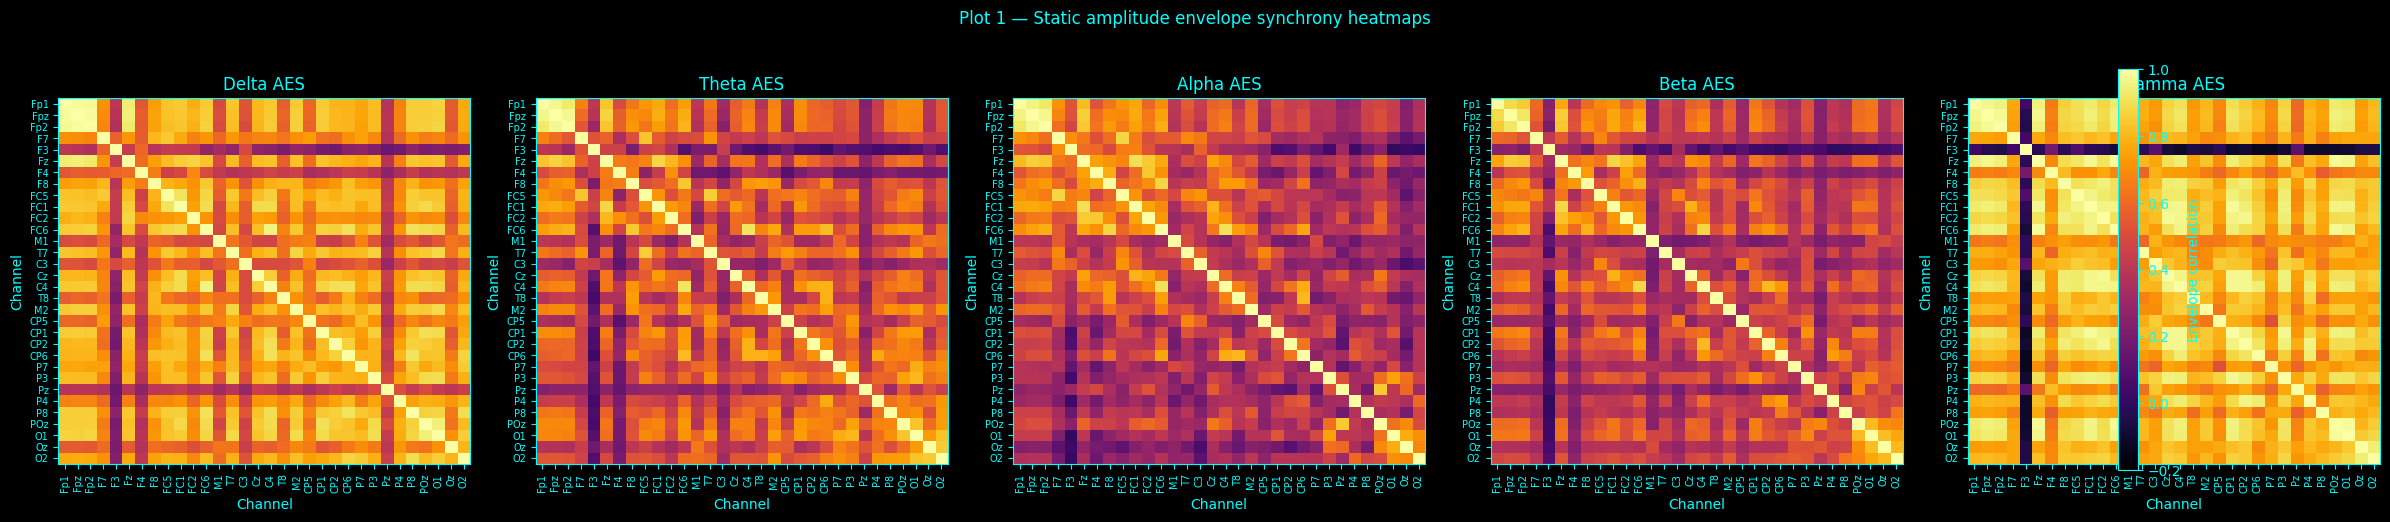

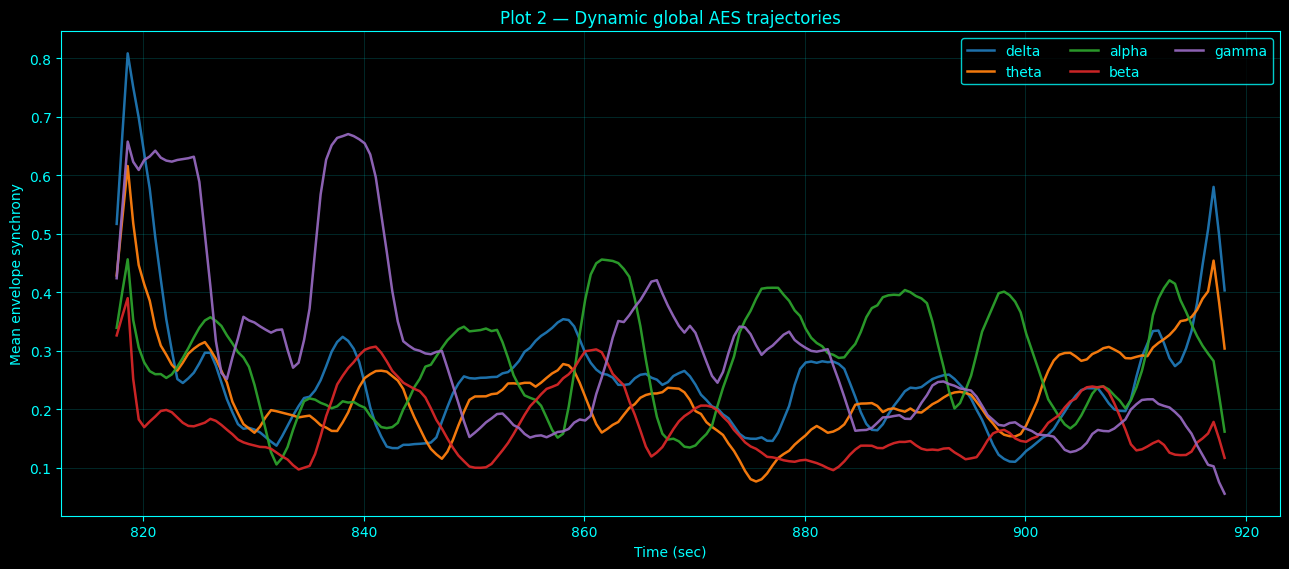

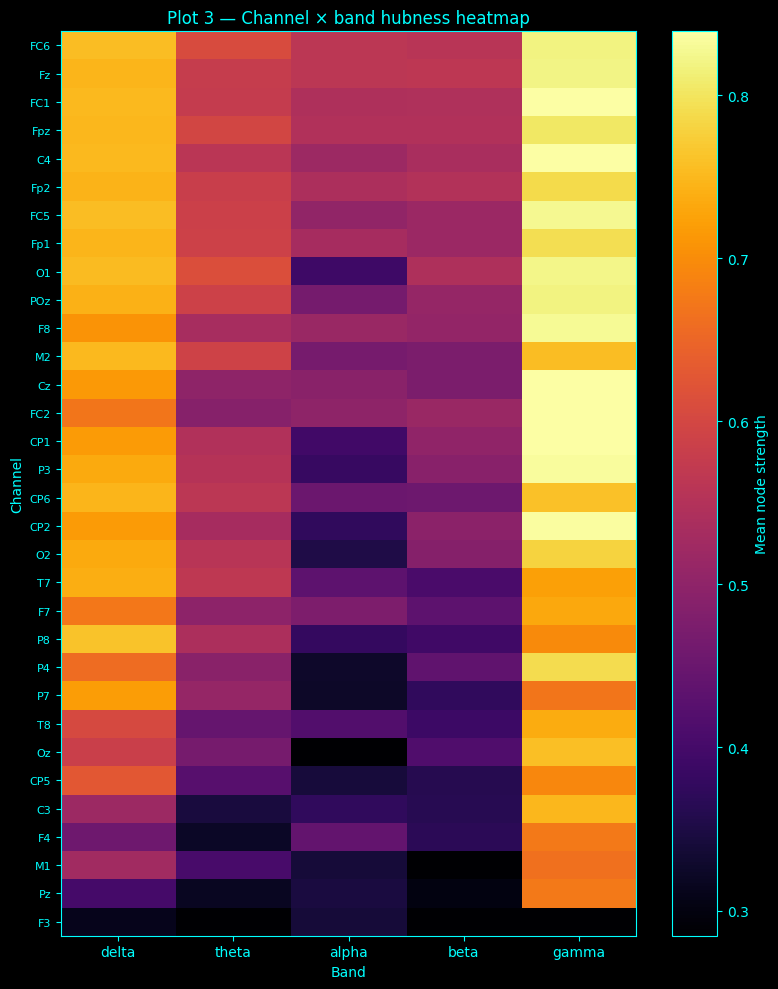

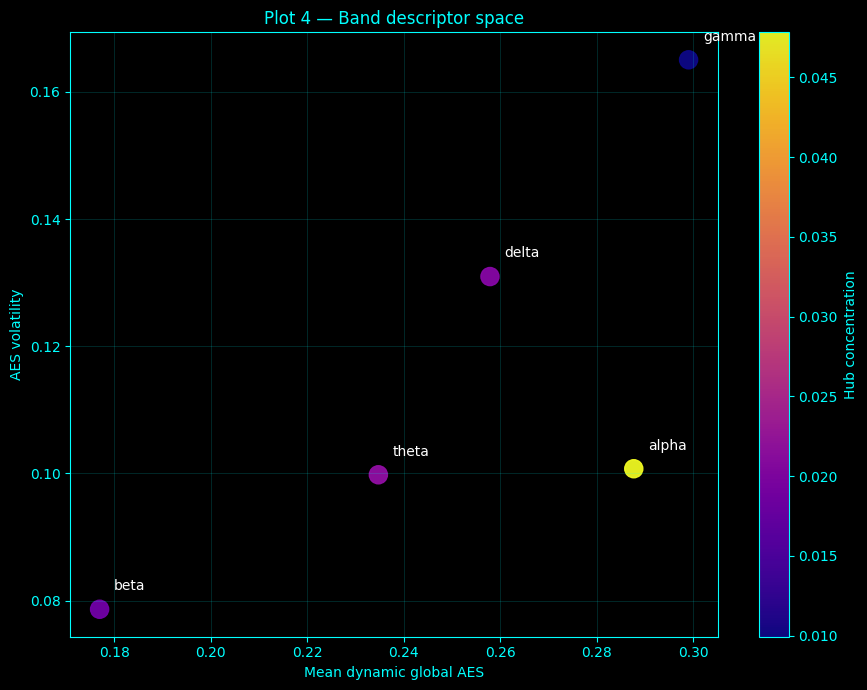

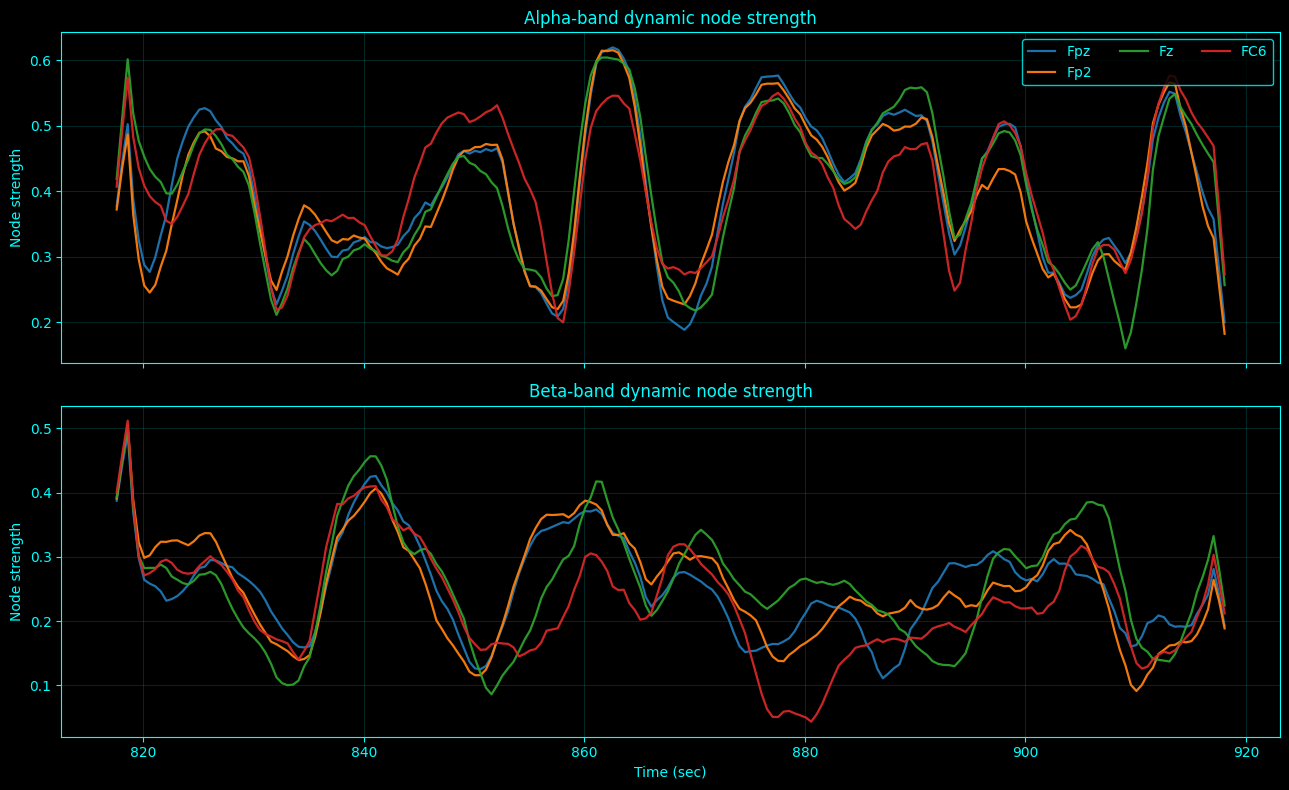


Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_amplitude_envelope_synchrony/aes_band_summary.csv
Saved band coordination CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_amplitude_envelope_synchrony/aes_band_coordination.csv
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_amplitude_envelope_synchrony/aes_outputs.npz
Saved dict NPY: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_amplitude_envelope_synchrony/aes_output_dict.npy
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_amplitude_envelope_synchrony/aes_notes.txt
Saved plot 1: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_amplitude_envelope_synchrony/plots/plot1_static_aes_heatmaps.png
Saved plot 2: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_amplitude_envelope_synchrony/plots/plot2_dynamic_global_aes_trajectories.png
Saved plot 3

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# -------------------------------------------------------
# NUMPY 1.x / 2.x COMPATIBILITY
# -------------------------------------------------------
if hasattr(np, "trapezoid"):
    integrate_trapezoid = np.trapezoid
else:
    integrate_trapezoid = np.trapz

# -------------------------------------------------------
# CONFIG — FILE PATHS ONLY, NO NOTEBOOK MEMORY
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_amplitude_envelope_synchrony")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# -------------------------------------------------------
# THEORY / DESIGN
# -------------------------------------------------------
# 1. Zero-phase bandpass + Hilbert envelopes
# 2. Static AES matrix for each band
# 3. Dynamic AES over sliding windows
# 4. Channel hubness / node strength by band
# 5. Regional synchrony summaries
# 6. Novel exploratory descriptors:
#    - synchrony attractor: typical global AES level in a band
#    - synchrony volatility: temporal variability of global AES
#    - hub concentration: whether coupling is diffuse or dominated by a few channels
#    - anterior-posterior envelope bias

apply_common_average_reference = False
detrend_mode = "constant"
zscore_each_channel = False

analysis_downsample_factor = 4
fs_analysis = sampling_rate / analysis_downsample_factor  # 250 Hz

frequency_bands = {
    "delta": (1.0, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta": (13.0, 30.0),
    "gamma": (30.0, 80.0),
}

# Envelope smoothing / network dynamics
envelope_lowpass_hz = 2.0

dynamic_window_sec = 6.0
dynamic_step_sec = 0.50

# Channel names
eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

roi_definitions = {
    "frontal":   ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8'],
    "central":   ['FC5', 'FC1', 'FC2', 'FC6', 'C3', 'Cz', 'C4'],
    "posterior": ['CP5', 'CP1', 'CP2', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'],
}

ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def preprocess_channel(y, detrend_mode="constant", zscore=False):
    y = np.asarray(y, dtype=float)
    if detrend_mode is not None:
        y = signal.detrend(y, type=detrend_mode)
    if zscore:
        sd = np.std(y)
        y = (y - np.mean(y)) / (sd + eps)
    return y

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def smooth_1d(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def upper_triangle_values(mat):
    iu = np.triu_indices_from(mat, k=1)
    vals = mat[iu]
    return vals[np.isfinite(vals)]

def bandpass_sos(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = max(lowcut / nyq, 1e-6)
    high = min(highcut / nyq, 0.999)
    if not (low < high):
        raise ValueError(f"Invalid band {lowcut}-{highcut} Hz for fs={fs}")
    return signal.butter(order, [low, high], btype="bandpass", output="sos")

def lowpass_sos(cutoff, fs, order=4):
    nyq = 0.5 * fs
    cut = min(cutoff / nyq, 0.999)
    return signal.butter(order, cut, btype="lowpass", output="sos")

def compute_band_envelopes(segment, fs, band, envelope_lp_hz=2.0):
    lowcut, highcut = band
    sos_bp = bandpass_sos(lowcut, highcut, fs, order=4)
    sos_lp = lowpass_sos(envelope_lp_hz, fs, order=4)

    n_samples, n_channels = segment.shape
    envelopes = np.full((n_samples, n_channels), np.nan, dtype=float)

    for ch in range(n_channels):
        y = segment[:, ch]
        y_f = signal.sosfiltfilt(sos_bp, y)
        analytic = signal.hilbert(y_f)
        env = np.abs(analytic)
        env = signal.sosfiltfilt(sos_lp, env)
        env = np.log10(env + eps)
        envelopes[:, ch] = env

    return envelopes

def corrcoef_nan_safe(x):
    x = np.asarray(x, dtype=float)
    n_channels = x.shape[1]
    out = np.full((n_channels, n_channels), np.nan, dtype=float)

    for i in range(n_channels):
        out[i, i] = 1.0
        for j in range(i + 1, n_channels):
            xi = x[:, i]
            xj = x[:, j]
            mask = np.isfinite(xi) & np.isfinite(xj)
            if np.sum(mask) < 3:
                continue
            xi_m = xi[mask]
            xj_m = xj[mask]
            if np.std(xi_m) < eps or np.std(xj_m) < eps:
                continue
            r = np.corrcoef(xi_m, xj_m)[0, 1]
            out[i, j] = r
            out[j, i] = r
    return out

def dynamic_aes(envelopes, fs, window_sec=6.0, step_sec=0.5):
    n_samples, n_channels = envelopes.shape
    win = int(round(window_sec * fs))
    step = int(round(step_sec * fs))
    half = win // 2

    centers = np.arange(half, n_samples - half + 1, step, dtype=int)
    n_t = len(centers)

    dyn_global = np.full(n_t, np.nan, dtype=float)
    dyn_matrix = np.full((n_channels, n_channels, n_t), np.nan, dtype=float)

    for t_i, c in enumerate(centers):
        start = c - half
        stop = c + half
        chunk = envelopes[start:stop, :]
        mat = corrcoef_nan_safe(chunk)
        dyn_matrix[:, :, t_i] = mat

        vals = upper_triangle_values(mat)
        if len(vals) > 0:
            dyn_global[t_i] = np.nanmean(vals)

    times_sec_rel = centers / fs
    return times_sec_rel, dyn_global, dyn_matrix

def node_strength_from_matrix(mat):
    mat = np.asarray(mat, dtype=float)
    n = mat.shape[0]
    out = np.full(n, np.nan, dtype=float)
    for i in range(n):
        row = np.delete(mat[i, :], i)
        row = row[np.isfinite(row)]
        if len(row) == 0:
            continue
        out[i] = np.mean(row)
    return out

def roi_mean_strength(strength_vec, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]
    if len(idx) == 0:
        return np.nan
    vals = np.asarray(strength_vec, dtype=float)[idx]
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan
    return float(np.mean(vals))

def hub_concentration(strength_vec):
    x = np.asarray(strength_vec, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    x = x - np.min(x)
    if np.sum(x) <= eps:
        return 0.0
    p = x / np.sum(x)
    H = -np.sum(p * np.log(p + eps))
    Hmax = np.log(len(p) + eps)
    return float(1.0 - H / (Hmax + eps))

def synchrony_attractor_and_entropy(series, bins=40):
    x = np.asarray(series, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.array([]), np.array([])
    hist, edges = np.histogram(x, bins=bins)
    hist = hist.astype(float)
    hist = hist / (np.sum(hist) + eps)
    centers = 0.5 * (edges[:-1] + edges[1:])
    attractor = float(centers[np.argmax(hist)])
    positive = hist[hist > 0]
    H = -np.sum(positive * np.log(positive + eps))
    Hmax = np.log(len(hist) + eps)
    Hn = float(H / (Hmax + eps))
    return attractor, Hn, centers, hist

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

# downsample before band-envelope processing for efficiency
segment_ds = signal.resample_poly(segment, up=1, down=analysis_downsample_factor, axis=0)
segment_ds = np.asarray(segment_ds, dtype=float)

for ch in range(segment_ds.shape[1]):
    segment_ds[:, ch] = preprocess_channel(
        segment_ds[:, ch],
        detrend_mode=detrend_mode,
        zscore=zscore_each_channel,
    )

n_samples, n_channels = segment_ds.shape
time_sec_rel = np.arange(n_samples) / fs_analysis
time_sec_abs = start_time + time_sec_rel

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Original segment shape: {segment.shape}")
print(f"Downsampled segment shape: {segment_ds.shape}")
print(f"Analysis fs: {fs_analysis:.1f} Hz")

# -------------------------------------------------------
# CORE AES ANALYSIS
# -------------------------------------------------------
band_names = list(frequency_bands.keys())
n_bands = len(band_names)

aes_static = np.full((n_channels, n_channels, n_bands), np.nan, dtype=float)
node_strengths = np.full((n_channels, n_bands), np.nan, dtype=float)

dynamic_global_dict = {}
dynamic_time_sec_abs = None
envelope_dict = {}
dynamic_matrix_dict = {}
summary_rows = []

for b_i, band_name in enumerate(band_names):
    band = frequency_bands[band_name]
    print(f"Processing band: {band_name} {band}")

    envelopes = compute_band_envelopes(
        segment_ds,
        fs_analysis,
        band=band,
        envelope_lp_hz=envelope_lowpass_hz,
    )
    envelope_dict[band_name] = envelopes

    static_mat = corrcoef_nan_safe(envelopes)
    aes_static[:, :, b_i] = static_mat

    strength = node_strength_from_matrix(static_mat)
    node_strengths[:, b_i] = strength

    dyn_time_sec_rel, dyn_global, dyn_matrix = dynamic_aes(
        envelopes,
        fs_analysis,
        window_sec=dynamic_window_sec,
        step_sec=dynamic_step_sec,
    )
    dynamic_time_sec_abs = start_time + dyn_time_sec_rel
    dynamic_global_dict[band_name] = dyn_global
    dynamic_matrix_dict[band_name] = dyn_matrix

    attractor, dyn_entropy, hist_centers, hist_vals = synchrony_attractor_and_entropy(dyn_global, bins=40)

    frontal_mean = roi_mean_strength(strength, eeg_channel_names, roi_definitions["frontal"])
    central_mean = roi_mean_strength(strength, eeg_channel_names, roi_definitions["central"])
    posterior_mean = roi_mean_strength(strength, eeg_channel_names, roi_definitions["posterior"])

    anterior_posterior_bias = (
        frontal_mean - posterior_mean
        if np.isfinite(frontal_mean) and np.isfinite(posterior_mean)
        else np.nan
    )

    vals = upper_triangle_values(static_mat)
    static_mean = float(np.nanmean(vals)) if len(vals) > 0 else np.nan
    static_std = float(np.nanstd(vals)) if len(vals) > 0 else np.nan

    summary_rows.append({
        "band": band_name,
        "low_hz": band[0],
        "high_hz": band[1],
        "static_global_aes_mean": static_mean,
        "static_global_aes_std": static_std,
        "dynamic_global_aes_mean": float(np.nanmean(dyn_global)),
        "dynamic_global_aes_std": float(np.nanstd(dyn_global)),
        "synchrony_attractor": attractor,
        "synchrony_entropy": dyn_entropy,
        "frontal_mean_node_strength": frontal_mean,
        "central_mean_node_strength": central_mean,
        "posterior_mean_node_strength": posterior_mean,
        "anterior_posterior_bias": anterior_posterior_bias,
        "hub_concentration": hub_concentration(strength),
    })

summary_df = pd.DataFrame(summary_rows)

# -------------------------------------------------------
# SECOND-ORDER EXPLORATORY DESCRIPTORS
# -------------------------------------------------------
# Band-to-band synchrony coordination:
# do global envelope networks co-fluctuate across bands?
band_coord_rows = []
for i, b1 in enumerate(band_names):
    for j, b2 in enumerate(band_names):
        if j <= i:
            continue
        s1 = dynamic_global_dict[b1]
        s2 = dynamic_global_dict[b2]
        mask = np.isfinite(s1) & np.isfinite(s2)
        if np.sum(mask) < 3:
            r = np.nan
        else:
            r = np.corrcoef(s1[mask], s2[mask])[0, 1]
        band_coord_rows.append({
            "band_1": b1,
            "band_2": b2,
            "dynamic_global_aes_correlation": r,
        })

band_coord_df = pd.DataFrame(band_coord_rows)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
summary_csv_path = os.path.join(out_dir, "aes_band_summary.csv")
band_coord_csv_path = os.path.join(out_dir, "aes_band_coordination.csv")
npz_path = os.path.join(out_dir, "aes_outputs.npz")
dict_npy_path = os.path.join(out_dir, "aes_output_dict.npy")
notes_txt_path = os.path.join(out_dir, "aes_notes.txt")

plot1_path = os.path.join(plots_dir, "plot1_static_aes_heatmaps.png")
plot2_path = os.path.join(plots_dir, "plot2_dynamic_global_aes_trajectories.png")
plot3_path = os.path.join(plots_dir, "plot3_channel_band_hubness_heatmap.png")
plot4_path = os.path.join(plots_dir, "plot4_band_descriptor_space.png")
plot5_path = os.path.join(plots_dir, "plot5_alpha_beta_top_channels_dynamic_strength.png")

summary_df.to_csv(summary_csv_path, index=False)
band_coord_df.to_csv(band_coord_csv_path, index=False)

np.savez_compressed(
    npz_path,
    aes_static=aes_static,
    node_strengths=node_strengths,
    dynamic_time_sec_abs=dynamic_time_sec_abs,
    dynamic_time_sec_rel=dynamic_time_sec_abs - start_time,
    channel_names=np.array(eeg_channel_names, dtype=object),
    band_names=np.array(band_names, dtype=object),
    start_time=start_time,
    end_time=end_time,
    original_sampling_rate=sampling_rate,
    analysis_sampling_rate=fs_analysis,
    analysis_downsample_factor=analysis_downsample_factor,
)

output_dict = {
    "aes_static": aes_static,
    "node_strengths": node_strengths,
    "dynamic_time_sec_abs": dynamic_time_sec_abs,
    "dynamic_global_dict": dynamic_global_dict,
    "summary_df": summary_df,
    "band_coord_df": band_coord_df,
}
np.save(dict_npy_path, output_dict, allow_pickle=True)

top_alpha_idx = np.argsort(node_strengths[:, band_names.index("alpha")])[::-1][:5]
top_beta_idx = np.argsort(node_strengths[:, band_names.index("beta")])[::-1][:5]

with open(notes_txt_path, "w") as f:
    f.write("Exploratory amplitude envelope synchrony (AES) atlas\n")
    f.write("===================================================\n\n")
    f.write("Intent:\n")
    f.write("This pass upgrades a simple static AES matrix into a multiscale envelope-network exploration.\n")
    f.write("It is for exploratory expert research, not publishing, not benchmarking, and not scoring.\n\n")
    f.write("Major upgrades relative to the original script:\n")
    f.write("1. Uses file paths only and the selected segment of interest.\n")
    f.write("2. Uses zero-phase filtering (sosfiltfilt) instead of causal lfilter.\n")
    f.write("3. Uses smoothed log-envelopes rather than raw amplitude only.\n")
    f.write("4. Adds dynamic AES over sliding windows.\n")
    f.write("5. Adds node-strength hubness by band.\n")
    f.write("6. Adds regional envelope-network summaries.\n")
    f.write("7. Adds synchrony attractor and volatility descriptors.\n")
    f.write("8. Adds cross-band coordination of dynamic global AES.\n\n")
    f.write("Conceptual note:\n")
    f.write("AES here means correlation of band-limited amplitude envelopes across channels.\n")
    f.write("It should be treated as an exploratory functional synchrony descriptor, not a definitive connectivity metric.\n\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Original fs: {sampling_rate} Hz\n")
    f.write(f"Analysis fs: {fs_analysis:.1f} Hz\n")
    f.write(f"Envelope lowpass: {envelope_lowpass_hz:.2f} Hz\n")
    f.write(f"Dynamic window: {dynamic_window_sec:.2f} sec\n")
    f.write(f"Dynamic step: {dynamic_step_sec:.2f} sec\n\n")

    f.write("Top alpha-hub channels:\n")
    for idx in top_alpha_idx:
        f.write(
            f"  {eeg_channel_names[idx]}: alpha_strength={node_strengths[idx, band_names.index('alpha')]:.4f}\n"
        )

    f.write("\nTop beta-hub channels:\n")
    for idx in top_beta_idx:
        f.write(
            f"  {eeg_channel_names[idx]}: beta_strength={node_strengths[idx, band_names.index('beta')]:.4f}\n"
        )

# -------------------------------------------------------
# PLOT 1 — STATIC AES HEATMAPS
# -------------------------------------------------------
fig1, axes = plt.subplots(1, n_bands, figsize=(4.8 * n_bands, 5.2), facecolor=BG)
axes = np.atleast_1d(axes)

vmin = -0.2
vmax = 1.0

for b_i, band_name in enumerate(band_names):
    ax = axes[b_i]
    style_ax(ax, heatmap=True)

    im = ax.imshow(
        aes_static[:, :, b_i],
        cmap="inferno",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        aspect="auto",
    )
    ax.set_title(f"{band_name.capitalize()} AES")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Channel")
    ax.set_xticks(np.arange(n_channels))
    ax.set_xticklabels(eeg_channel_names, rotation=90, fontsize=7)
    ax.set_yticks(np.arange(n_channels))
    ax.set_yticklabels(eeg_channel_names, fontsize=7)

cbar1 = fig1.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.01)
cbar1.set_label("Envelope correlation", color=ACCENT)
cbar1.outline.set_edgecolor(ACCENT)
cbar1.ax.tick_params(color=ACCENT)
for label in cbar1.ax.get_yticklabels():
    label.set_color(ACCENT)

fig1.suptitle("Plot 1 — Static amplitude envelope synchrony heatmaps", color=ACCENT, y=0.995)
fig1.tight_layout(rect=[0, 0, 1, 0.96])
fig1.savefig(plot1_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig1)

# -------------------------------------------------------
# PLOT 2 — DYNAMIC GLOBAL AES TRAJECTORIES
# -------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(13, 5.8), facecolor=BG)
style_ax(ax2)

for band_name in band_names:
    ax2.plot(
        dynamic_time_sec_abs,
        smooth_1d(dynamic_global_dict[band_name], win=5),
        linewidth=1.8,
        alpha=0.95,
        label=band_name,
    )

ax2.set_title("Plot 2 — Dynamic global AES trajectories")
ax2.set_xlabel("Time (sec)")
ax2.set_ylabel("Mean envelope synchrony")
ax2.legend(loc="upper right", ncol=3)

fig2.tight_layout()
fig2.savefig(plot2_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig2)

# -------------------------------------------------------
# PLOT 3 — CHANNEL × BAND HUBNESS HEATMAP
# -------------------------------------------------------
channel_order = np.argsort(np.nanmean(node_strengths, axis=1))[::-1]
ordered_channels = [eeg_channel_names[i] for i in channel_order]
hub_heat = node_strengths[channel_order, :]

fig3, ax3 = plt.subplots(figsize=(8, 10), facecolor=BG)
style_ax(ax3, heatmap=True)

vmin3, vmax3 = percentile_limits(hub_heat, lo=2, hi=98)
if vmin3 is None or vmax3 is None:
    vmin3, vmax3 = -0.2, 1.0

im3 = ax3.imshow(
    hub_heat,
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=vmin3,
    vmax=vmax3,
)

ax3.set_title("Plot 3 — Channel × band hubness heatmap")
ax3.set_xlabel("Band")
ax3.set_ylabel("Channel")
ax3.set_xticks(np.arange(n_bands))
ax3.set_xticklabels(band_names)
ax3.set_yticks(np.arange(n_channels))
ax3.set_yticklabels(ordered_channels, fontsize=8)

cbar3 = plt.colorbar(im3, ax=ax3)
cbar3.set_label("Mean node strength", color=ACCENT)
cbar3.outline.set_edgecolor(ACCENT)
cbar3.ax.tick_params(color=ACCENT)
for label in cbar3.ax.get_yticklabels():
    label.set_color(ACCENT)

fig3.tight_layout()
fig3.savefig(plot3_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig3)

# -------------------------------------------------------
# PLOT 4 — BAND DESCRIPTOR SPACE
# -------------------------------------------------------
fig4, ax4 = plt.subplots(figsize=(9, 7), facecolor=BG)
style_ax(ax4)

x = summary_df["dynamic_global_aes_mean"].values
y = summary_df["dynamic_global_aes_std"].values
c = summary_df["hub_concentration"].values

scatter = ax4.scatter(
    x,
    y,
    c=c,
    s=170,
    cmap="plasma",
    alpha=0.95,
)

for _, row in summary_df.iterrows():
    ax4.text(
        row["dynamic_global_aes_mean"] + 0.003,
        row["dynamic_global_aes_std"] + 0.003,
        row["band"],
        color="white",
        fontsize=10,
    )

ax4.set_title("Plot 4 — Band descriptor space")
ax4.set_xlabel("Mean dynamic global AES")
ax4.set_ylabel("AES volatility")

cbar4 = plt.colorbar(scatter, ax=ax4)
cbar4.set_label("Hub concentration", color=ACCENT)
cbar4.outline.set_edgecolor(ACCENT)
cbar4.ax.tick_params(color=ACCENT)
for label in cbar4.ax.get_yticklabels():
    label.set_color(ACCENT)

fig4.tight_layout()
fig4.savefig(plot4_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig4)

# -------------------------------------------------------
# PLOT 5 — ALPHA / BETA TOP-CHANNEL DYNAMIC STRENGTH
# -------------------------------------------------------
alpha_idx = band_names.index("alpha")
beta_idx = band_names.index("beta")

top_channels = sorted(set(
    list(np.argsort(node_strengths[:, alpha_idx])[::-1][:3]) +
    list(np.argsort(node_strengths[:, beta_idx])[::-1][:3])
))

fig5, axes5 = plt.subplots(2, 1, figsize=(13, 8), facecolor=BG, sharex=True)
axes5 = np.atleast_1d(axes5)

for ax in axes5:
    style_ax(ax)

# dynamic node strength time series for alpha
alpha_dyn = dynamic_matrix_dict["alpha"]
for idx in top_channels:
    series = np.full(alpha_dyn.shape[2], np.nan, dtype=float)
    for t_i in range(alpha_dyn.shape[2]):
        series[t_i] = node_strength_from_matrix(alpha_dyn[:, :, t_i])[idx]
    axes5[0].plot(
        dynamic_time_sec_abs,
        smooth_1d(series, win=5),
        linewidth=1.6,
        alpha=0.95,
        label=eeg_channel_names[idx],
    )

axes5[0].set_title("Alpha-band dynamic node strength")
axes5[0].set_ylabel("Node strength")
axes5[0].legend(loc="upper right", ncol=3)

# dynamic node strength time series for beta
beta_dyn = dynamic_matrix_dict["beta"]
for idx in top_channels:
    series = np.full(beta_dyn.shape[2], np.nan, dtype=float)
    for t_i in range(beta_dyn.shape[2]):
        series[t_i] = node_strength_from_matrix(beta_dyn[:, :, t_i])[idx]
    axes5[1].plot(
        dynamic_time_sec_abs,
        smooth_1d(series, win=5),
        linewidth=1.6,
        alpha=0.95,
        label=eeg_channel_names[idx],
    )

axes5[1].set_title("Beta-band dynamic node strength")
axes5[1].set_xlabel("Time (sec)")
axes5[1].set_ylabel("Node strength")

fig5.tight_layout()
fig5.savefig(plot5_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig5)

print(f"\nSaved summary CSV: {summary_csv_path}")
print(f"Saved band coordination CSV: {band_coord_csv_path}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved dict NPY: {dict_npy_path}")
print(f"Saved notes TXT: {notes_txt_path}")
print(f"Saved plot 1: {plot1_path}")
print(f"Saved plot 2: {plot2_path}")
print(f"Saved plot 3: {plot3_path}")
print(f"Saved plot 4: {plot4_path}")
print(f"Saved plot 5: {plot5_path}")
print("Done.")

# Phase Synchonization Analysis

Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Original segment shape: (106944, 32)
Downsampled segment shape: (26736, 32)
Analysis fs: 250.0 Hz
Processing band: delta (1.0, 4.0)
Processing band: theta (4.0, 8.0)
Processing band: alpha (8.0, 13.0)
Processing band: beta (13.0, 30.0)
Processing band: gamma (30.0, 80.0)


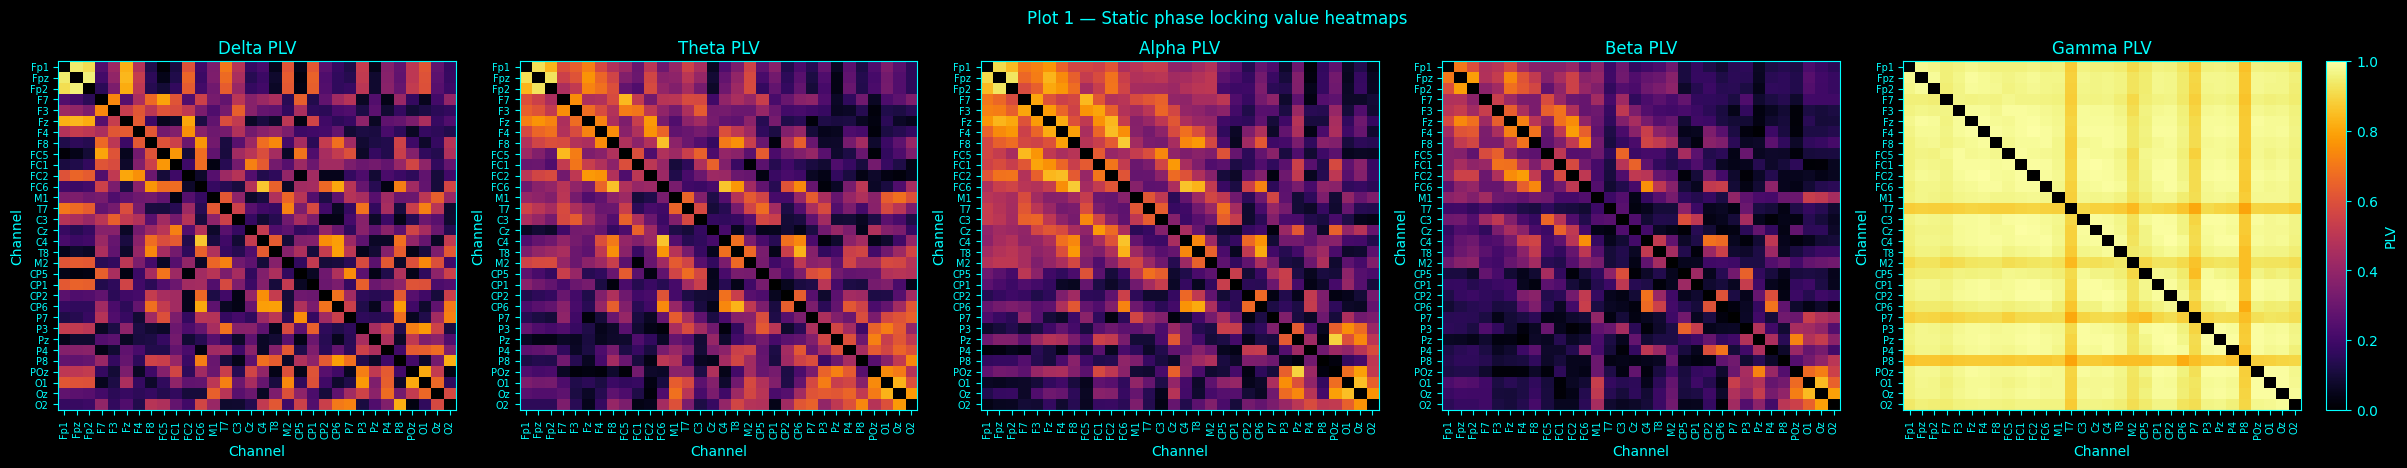

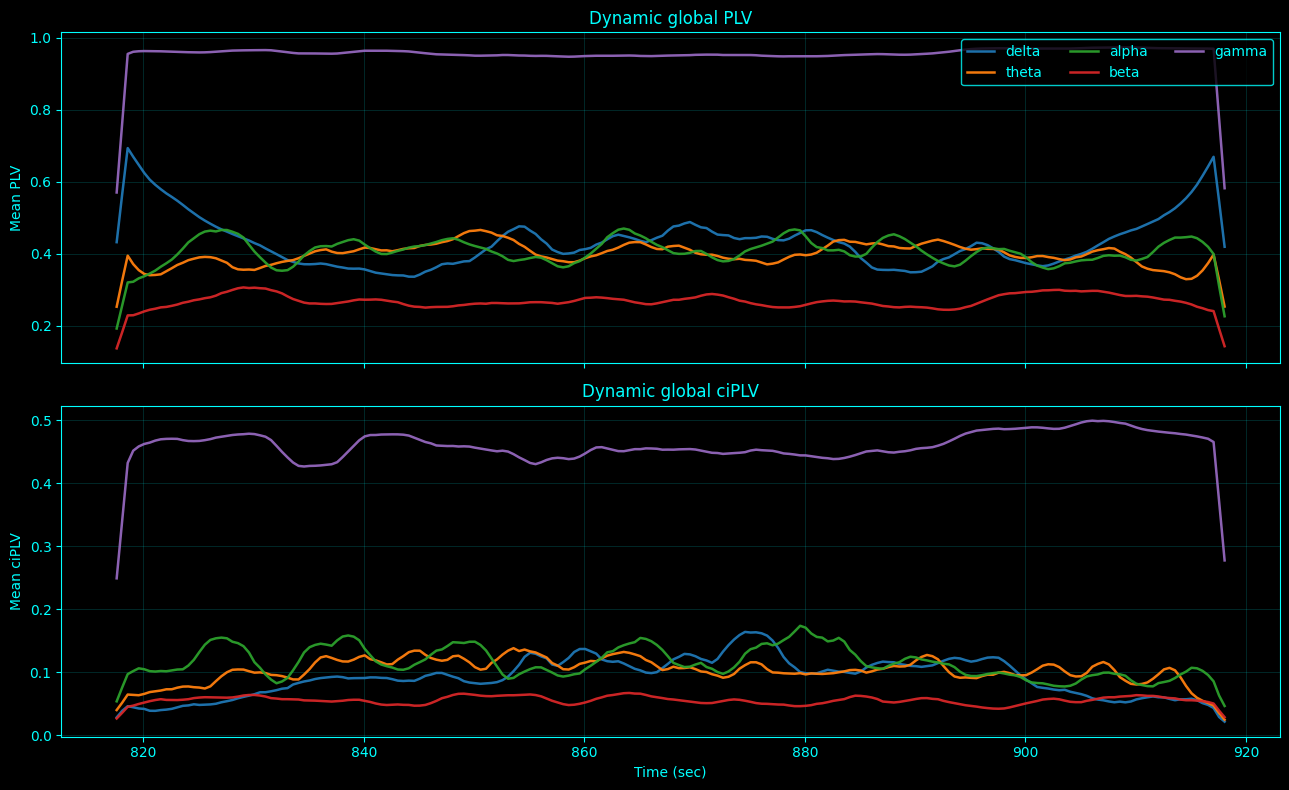

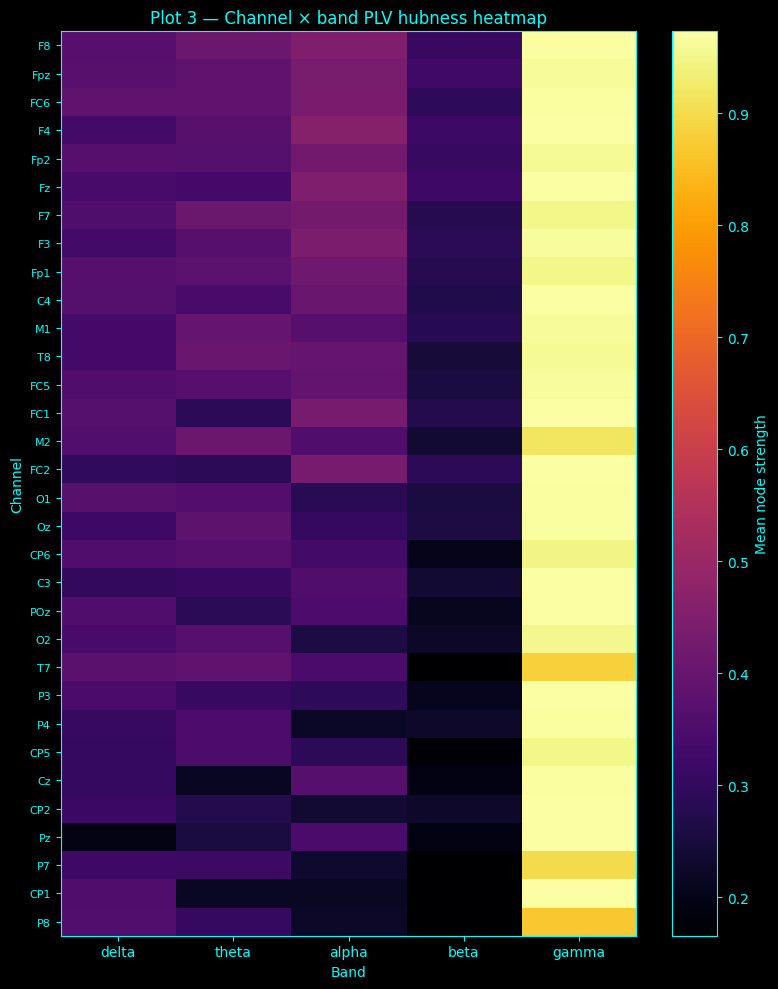

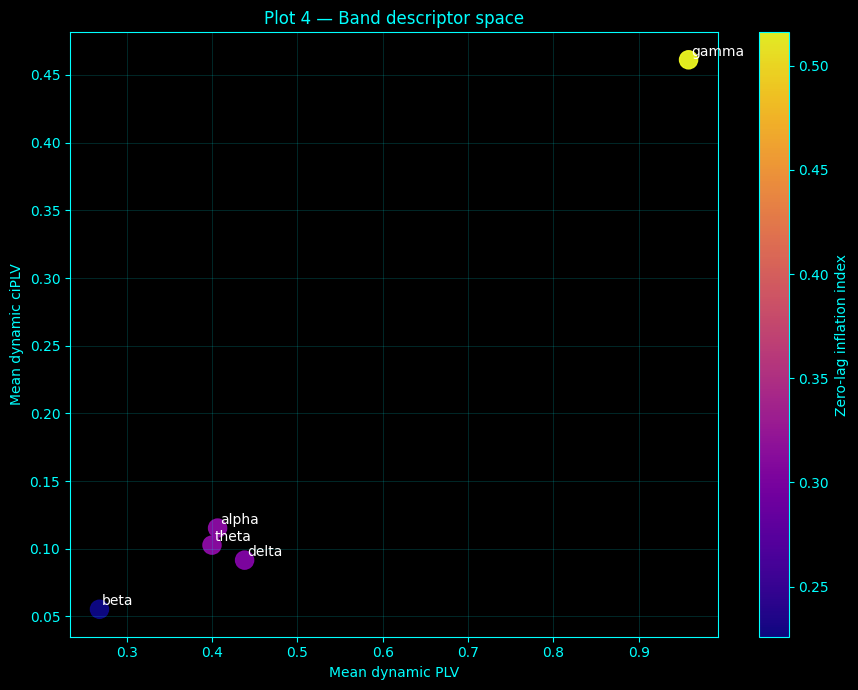

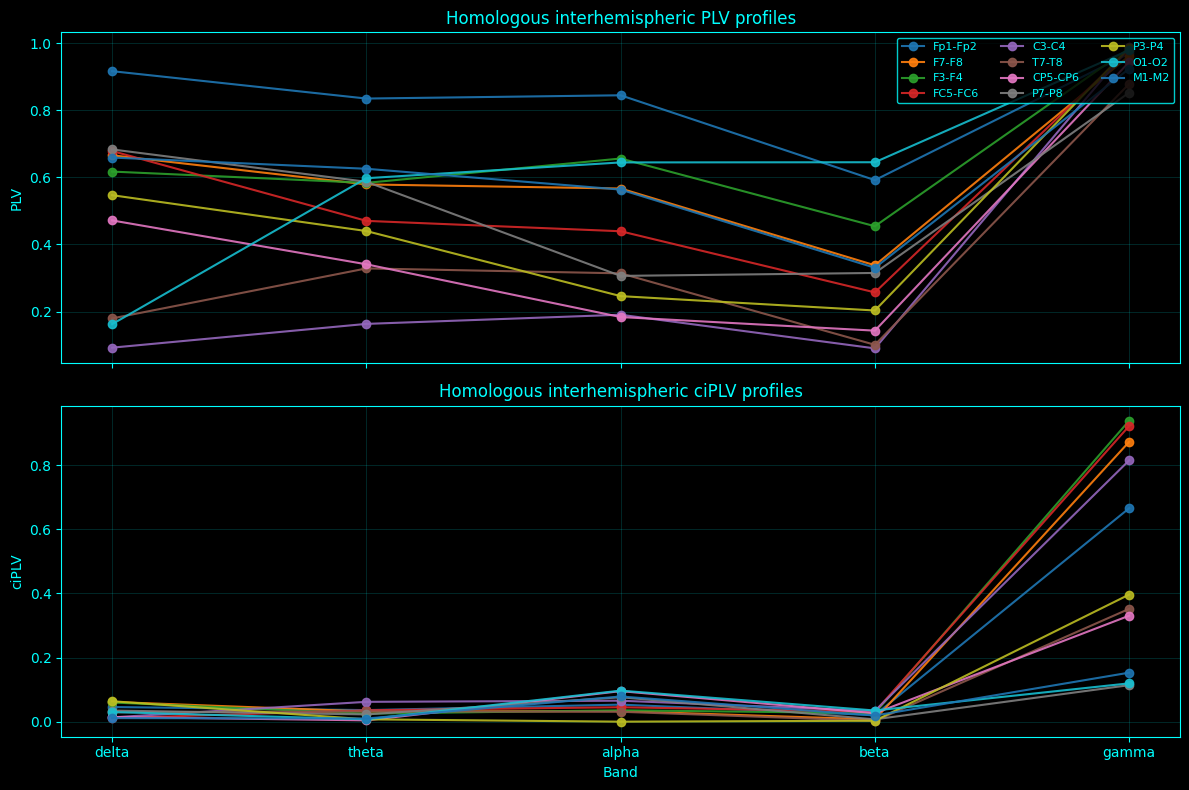


Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_phase_locking_value_atlas/plv_band_summary.csv
Saved homologous-pair CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_phase_locking_value_atlas/plv_homologous_pairs.csv
Saved band coordination CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_phase_locking_value_atlas/plv_band_coordination.csv
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_phase_locking_value_atlas/plv_outputs.npz
Saved dict NPY: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_phase_locking_value_atlas/plv_output_dict.npy
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_phase_locking_value_atlas/plv_notes.txt
Saved plot 1: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_phase_locking_value_atlas/plots/plot1_static_plv_heatmaps.png
Saved plot 2: /home/a/projects/Complete-Neu

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# -------------------------------------------------------
# CONFIG — FILE PATHS ONLY, NO NOTEBOOK MEMORY
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_phase_locking_value_atlas")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# -------------------------------------------------------
# THEORY / DESIGN
# -------------------------------------------------------
# Original script issue:
# broadband Hilbert phase on raw EEG is not a strong phase-synchrony definition.
# Phase is more interpretable after narrowband filtering.
#
# This rewrite upgrades the analysis into an exploratory phase-synchrony atlas:
#
# 1. Zero-phase bandpass filtering + Hilbert phase
# 2. Static PLV matrices by canonical band
# 3. Dynamic PLV over sliding windows
# 4. Static ciPLV sidecar (corrected imaginary PLV) as a lag-sensitive robustness view
# 5. Channel hubness / node strength by band
# 6. Homologous interhemispheric pair summaries
# 7. Novel exploratory descriptors:
#    - phase-lock attractor
#    - phase-lock volatility
#    - hub concentration
#    - anterior-posterior phase-lock bias
#    - zero-lag inflation index = PLV - ciPLV
#
# This is for exploratory expert research, not publishing, not benchmarking,
# and not scoring. PLV is treated as a descriptive synchrony statistic, not
# as a final connectivity claim.

apply_common_average_reference = False
detrend_mode = "constant"
zscore_each_channel = False

analysis_downsample_factor = 4
fs_analysis = sampling_rate / analysis_downsample_factor  # 250 Hz

frequency_bands = {
    "delta": (1.0, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta":  (13.0, 30.0),
    "gamma": (30.0, 80.0),
}

dynamic_window_sec = 6.0
dynamic_step_sec = 0.50

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

roi_definitions = {
    "frontal":   ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8'],
    "central":   ['FC5', 'FC1', 'FC2', 'FC6', 'C3', 'Cz', 'C4'],
    "posterior": ['CP5', 'CP1', 'CP2', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'],
}

homologous_pairs = [
    ("Fp1", "Fp2"),
    ("F7", "F8"),
    ("F3", "F4"),
    ("FC5", "FC6"),
    ("C3", "C4"),
    ("T7", "T8"),
    ("CP5", "CP6"),
    ("P7", "P8"),
    ("P3", "P4"),
    ("O1", "O2"),
    ("M1", "M2"),
]

ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def preprocess_channel(y, detrend_mode="constant", zscore=False):
    y = np.asarray(y, dtype=float)
    if detrend_mode is not None:
        y = signal.detrend(y, type=detrend_mode)
    if zscore:
        sd = np.std(y)
        y = (y - np.mean(y)) / (sd + eps)
    return y

def smooth_1d(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def upper_triangle_values(mat):
    iu = np.triu_indices_from(mat, k=1)
    vals = mat[iu]
    return vals[np.isfinite(vals)]

def bandpass_sos(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = max(lowcut / nyq, 1e-6)
    high = min(highcut / nyq, 0.999)
    if not (low < high):
        raise ValueError(f"Invalid band {lowcut}-{highcut} Hz for fs={fs}")
    return signal.butter(order, [low, high], btype="bandpass", output="sos")

def compute_band_phase(segment, fs, band):
    lowcut, highcut = band
    sos = bandpass_sos(lowcut, highcut, fs, order=4)

    n_samples, n_channels = segment.shape
    phases = np.full((n_samples, n_channels), np.nan, dtype=float)

    for ch in range(n_channels):
        y = signal.sosfiltfilt(sos, segment[:, ch])
        analytic = signal.hilbert(y)
        phases[:, ch] = np.angle(analytic)

    return phases

def phase_coupling_matrices(phases_txc):
    """
    Returns:
      plv   = |E[e^{i dphi}]|
      ciplv = |Im(E[e^{i dphi}])| / sqrt(1 - Re(E[e^{i dphi}])^2)

    ciPLV is included as a lag-sensitive sidecar to reduce zero-lag inflation.
    """
    phases_txc = np.asarray(phases_txc, dtype=float)
    mask_rows = np.all(np.isfinite(phases_txc), axis=1)
    phases_txc = phases_txc[mask_rows]

    n_t, n_ch = phases_txc.shape
    if n_t < 3:
        plv = np.full((n_ch, n_ch), np.nan, dtype=float)
        ciplv = np.full((n_ch, n_ch), np.nan, dtype=float)
        return plv, ciplv

    U = np.exp(1j * phases_txc)  # time x channels
    Z = (np.conjugate(U).T @ U) / n_t  # channels x channels, complex phase locking operator

    plv = np.abs(Z)

    reZ = np.real(Z)
    imZ = np.imag(Z)
    denom = np.sqrt(np.maximum(1.0 - reZ ** 2, eps))
    ciplv = np.abs(imZ) / denom

    np.fill_diagonal(plv, np.nan)
    np.fill_diagonal(ciplv, np.nan)

    return plv, ciplv

def dynamic_phase_coupling(phases, fs, window_sec=6.0, step_sec=0.5):
    n_samples, n_channels = phases.shape
    win = int(round(window_sec * fs))
    step = int(round(step_sec * fs))
    half = win // 2

    centers = np.arange(half, n_samples - half + 1, step, dtype=int)
    n_t = len(centers)

    dyn_global_plv = np.full(n_t, np.nan, dtype=float)
    dyn_global_ciplv = np.full(n_t, np.nan, dtype=float)

    for t_i, c in enumerate(centers):
        start = c - half
        stop = c + half
        chunk = phases[start:stop, :]

        plv_mat, ciplv_mat = phase_coupling_matrices(chunk)

        plv_vals = upper_triangle_values(plv_mat)
        ciplv_vals = upper_triangle_values(ciplv_mat)

        if len(plv_vals) > 0:
            dyn_global_plv[t_i] = np.nanmean(plv_vals)
        if len(ciplv_vals) > 0:
            dyn_global_ciplv[t_i] = np.nanmean(ciplv_vals)

    times_sec_rel = centers / fs
    return times_sec_rel, dyn_global_plv, dyn_global_ciplv

def node_strength_from_matrix(mat):
    mat = np.asarray(mat, dtype=float)
    n = mat.shape[0]
    out = np.full(n, np.nan, dtype=float)
    for i in range(n):
        row = np.delete(mat[i, :], i)
        row = row[np.isfinite(row)]
        if len(row) == 0:
            continue
        out[i] = np.mean(row)
    return out

def roi_mean_strength(strength_vec, channel_names, roi_channels):
    idx = [channel_names.index(ch) for ch in roi_channels if ch in channel_names]
    if len(idx) == 0:
        return np.nan
    vals = np.asarray(strength_vec, dtype=float)[idx]
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan
    return float(np.mean(vals))

def hub_concentration(strength_vec):
    x = np.asarray(strength_vec, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    x = x - np.min(x)
    if np.sum(x) <= eps:
        return 0.0
    p = x / np.sum(x)
    H = -np.sum(p * np.log(p + eps))
    Hmax = np.log(len(p) + eps)
    return float(1.0 - H / (Hmax + eps))

def synchrony_attractor_and_entropy(series, bins=40):
    x = np.asarray(series, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.array([]), np.array([])
    hist, edges = np.histogram(x, bins=bins)
    hist = hist.astype(float)
    hist = hist / (np.sum(hist) + eps)
    centers = 0.5 * (edges[:-1] + edges[1:])
    attractor = float(centers[np.argmax(hist)])
    positive = hist[hist > 0]
    H = -np.sum(positive * np.log(positive + eps))
    Hmax = np.log(len(hist) + eps)
    Hn = float(H / (Hmax + eps))
    return attractor, Hn, centers, hist

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

segment_ds = signal.resample_poly(segment, up=1, down=analysis_downsample_factor, axis=0)
segment_ds = np.asarray(segment_ds, dtype=float)

for ch in range(segment_ds.shape[1]):
    segment_ds[:, ch] = preprocess_channel(
        segment_ds[:, ch],
        detrend_mode=detrend_mode,
        zscore=zscore_each_channel,
    )

n_samples, n_channels = segment_ds.shape
time_sec_rel = np.arange(n_samples) / fs_analysis
time_sec_abs = start_time + time_sec_rel

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Original segment shape: {segment.shape}")
print(f"Downsampled segment shape: {segment_ds.shape}")
print(f"Analysis fs: {fs_analysis:.1f} Hz")

# -------------------------------------------------------
# CORE PLV ANALYSIS
# -------------------------------------------------------
band_names = list(frequency_bands.keys())
n_bands = len(band_names)

plv_static = np.full((n_channels, n_channels, n_bands), np.nan, dtype=float)
ciplv_static = np.full((n_channels, n_channels, n_bands), np.nan, dtype=float)

plv_node_strengths = np.full((n_channels, n_bands), np.nan, dtype=float)
ciplv_node_strengths = np.full((n_channels, n_bands), np.nan, dtype=float)

dynamic_global_plv_dict = {}
dynamic_global_ciplv_dict = {}
phase_dict = {}
summary_rows = []
homologous_rows = []

dynamic_time_sec_abs = None

for b_i, band_name in enumerate(band_names):
    band = frequency_bands[band_name]
    print(f"Processing band: {band_name} {band}")

    phases = compute_band_phase(segment_ds, fs_analysis, band)
    phase_dict[band_name] = phases

    static_plv, static_ciplv = phase_coupling_matrices(phases)
    plv_static[:, :, b_i] = static_plv
    ciplv_static[:, :, b_i] = static_ciplv

    plv_strength = node_strength_from_matrix(static_plv)
    ciplv_strength = node_strength_from_matrix(static_ciplv)

    plv_node_strengths[:, b_i] = plv_strength
    ciplv_node_strengths[:, b_i] = ciplv_strength

    dyn_time_sec_rel, dyn_global_plv, dyn_global_ciplv = dynamic_phase_coupling(
        phases,
        fs_analysis,
        window_sec=dynamic_window_sec,
        step_sec=dynamic_step_sec,
    )
    dynamic_time_sec_abs = start_time + dyn_time_sec_rel
    dynamic_global_plv_dict[band_name] = dyn_global_plv
    dynamic_global_ciplv_dict[band_name] = dyn_global_ciplv

    attractor, dyn_entropy, _, _ = synchrony_attractor_and_entropy(dyn_global_plv, bins=40)

    frontal_mean = roi_mean_strength(plv_strength, eeg_channel_names, roi_definitions["frontal"])
    central_mean = roi_mean_strength(plv_strength, eeg_channel_names, roi_definitions["central"])
    posterior_mean = roi_mean_strength(plv_strength, eeg_channel_names, roi_definitions["posterior"])

    anterior_posterior_bias = (
        frontal_mean - posterior_mean
        if np.isfinite(frontal_mean) and np.isfinite(posterior_mean)
        else np.nan
    )

    plv_vals = upper_triangle_values(static_plv)
    ciplv_vals = upper_triangle_values(static_ciplv)

    static_plv_mean = float(np.nanmean(plv_vals)) if len(plv_vals) > 0 else np.nan
    static_plv_std = float(np.nanstd(plv_vals)) if len(plv_vals) > 0 else np.nan

    static_ciplv_mean = float(np.nanmean(ciplv_vals)) if len(ciplv_vals) > 0 else np.nan
    static_ciplv_std = float(np.nanstd(ciplv_vals)) if len(ciplv_vals) > 0 else np.nan

    zero_lag_inflation = static_plv_mean - static_ciplv_mean if np.isfinite(static_plv_mean) and np.isfinite(static_ciplv_mean) else np.nan

    summary_rows.append({
        "band": band_name,
        "low_hz": band[0],
        "high_hz": band[1],
        "static_global_plv_mean": static_plv_mean,
        "static_global_plv_std": static_plv_std,
        "static_global_ciplv_mean": static_ciplv_mean,
        "static_global_ciplv_std": static_ciplv_std,
        "dynamic_global_plv_mean": float(np.nanmean(dyn_global_plv)),
        "dynamic_global_plv_std": float(np.nanstd(dyn_global_plv)),
        "dynamic_global_ciplv_mean": float(np.nanmean(dyn_global_ciplv)),
        "dynamic_global_ciplv_std": float(np.nanstd(dyn_global_ciplv)),
        "phase_lock_attractor": attractor,
        "phase_lock_entropy": dyn_entropy,
        "frontal_mean_node_strength": frontal_mean,
        "central_mean_node_strength": central_mean,
        "posterior_mean_node_strength": posterior_mean,
        "anterior_posterior_bias": anterior_posterior_bias,
        "hub_concentration": hub_concentration(plv_strength),
        "zero_lag_inflation_index": zero_lag_inflation,
    })

    for ch_l, ch_r in homologous_pairs:
        if ch_l in eeg_channel_names and ch_r in eeg_channel_names:
            i = eeg_channel_names.index(ch_l)
            j = eeg_channel_names.index(ch_r)
            homologous_rows.append({
                "band": band_name,
                "channel_left": ch_l,
                "channel_right": ch_r,
                "plv": static_plv[i, j],
                "ciplv": static_ciplv[i, j],
            })

summary_df = pd.DataFrame(summary_rows)
homologous_df = pd.DataFrame(homologous_rows)

# -------------------------------------------------------
# SECOND-ORDER EXPLORATORY DESCRIPTORS
# -------------------------------------------------------
band_coord_rows = []
for i, b1 in enumerate(band_names):
    for j, b2 in enumerate(band_names):
        if j <= i:
            continue

        s1 = dynamic_global_plv_dict[b1]
        s2 = dynamic_global_plv_dict[b2]
        mask = np.isfinite(s1) & np.isfinite(s2)
        r_plv = np.corrcoef(s1[mask], s2[mask])[0, 1] if np.sum(mask) >= 3 else np.nan

        c1 = dynamic_global_ciplv_dict[b1]
        c2 = dynamic_global_ciplv_dict[b2]
        mask2 = np.isfinite(c1) & np.isfinite(c2)
        r_ciplv = np.corrcoef(c1[mask2], c2[mask2])[0, 1] if np.sum(mask2) >= 3 else np.nan

        band_coord_rows.append({
            "band_1": b1,
            "band_2": b2,
            "dynamic_global_plv_correlation": r_plv,
            "dynamic_global_ciplv_correlation": r_ciplv,
        })

band_coord_df = pd.DataFrame(band_coord_rows)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
summary_csv_path = os.path.join(out_dir, "plv_band_summary.csv")
homologous_csv_path = os.path.join(out_dir, "plv_homologous_pairs.csv")
band_coord_csv_path = os.path.join(out_dir, "plv_band_coordination.csv")
npz_path = os.path.join(out_dir, "plv_outputs.npz")
dict_npy_path = os.path.join(out_dir, "plv_output_dict.npy")
notes_txt_path = os.path.join(out_dir, "plv_notes.txt")

plot1_path = os.path.join(plots_dir, "plot1_static_plv_heatmaps.png")
plot2_path = os.path.join(plots_dir, "plot2_dynamic_global_plv_and_ciplv.png")
plot3_path = os.path.join(plots_dir, "plot3_channel_band_hubness_heatmap.png")
plot4_path = os.path.join(plots_dir, "plot4_band_descriptor_space.png")
plot5_path = os.path.join(plots_dir, "plot5_homologous_pair_profiles.png")

summary_df.to_csv(summary_csv_path, index=False)
homologous_df.to_csv(homologous_csv_path, index=False)
band_coord_df.to_csv(band_coord_csv_path, index=False)

np.savez_compressed(
    npz_path,
    plv_static=plv_static,
    ciplv_static=ciplv_static,
    plv_node_strengths=plv_node_strengths,
    ciplv_node_strengths=ciplv_node_strengths,
    dynamic_time_sec_abs=dynamic_time_sec_abs,
    dynamic_time_sec_rel=dynamic_time_sec_abs - start_time,
    channel_names=np.array(eeg_channel_names, dtype=object),
    band_names=np.array(band_names, dtype=object),
    start_time=start_time,
    end_time=end_time,
    original_sampling_rate=sampling_rate,
    analysis_sampling_rate=fs_analysis,
    analysis_downsample_factor=analysis_downsample_factor,
)

output_dict = {
    "plv_static": plv_static,
    "ciplv_static": ciplv_static,
    "plv_node_strengths": plv_node_strengths,
    "ciplv_node_strengths": ciplv_node_strengths,
    "dynamic_time_sec_abs": dynamic_time_sec_abs,
    "dynamic_global_plv_dict": dynamic_global_plv_dict,
    "dynamic_global_ciplv_dict": dynamic_global_ciplv_dict,
    "summary_df": summary_df,
    "homologous_df": homologous_df,
    "band_coord_df": band_coord_df,
}
np.save(dict_npy_path, output_dict, allow_pickle=True)

top_alpha_idx = np.argsort(plv_node_strengths[:, band_names.index("alpha")])[::-1][:5]
top_beta_idx = np.argsort(plv_node_strengths[:, band_names.index("beta")])[::-1][:5]

with open(notes_txt_path, "w") as f:
    f.write("Exploratory phase locking value (PLV) atlas\n")
    f.write("===========================================\n\n")
    f.write("Intent:\n")
    f.write("This pass upgrades a simple broadband PLV matrix into a multiband phase-synchrony exploration.\n")
    f.write("It is for exploratory expert research, not publishing, not benchmarking, and not scoring.\n\n")
    f.write("Major upgrades relative to the original script:\n")
    f.write("1. Uses file paths only and the selected segment of interest.\n")
    f.write("2. Uses narrowband zero-phase filtering before Hilbert phase extraction.\n")
    f.write("3. Computes static PLV by band instead of broadband Hilbert phase on raw EEG.\n")
    f.write("4. Adds dynamic PLV trajectories over sliding windows.\n")
    f.write("5. Adds ciPLV as a lag-sensitive robustness sidecar.\n")
    f.write("6. Adds node-strength hubness by band.\n")
    f.write("7. Adds homologous interhemispheric pair summaries.\n")
    f.write("8. Adds phase-lock attractor, volatility, and zero-lag inflation descriptors.\n\n")
    f.write("Conceptual note:\n")
    f.write("PLV is sensitive to zero-lag and common-source structure. ciPLV is included as an exploratory guardrail,\n")
    f.write("not as a final correction. The pair PLV minus ciPLV gap can be interpreted as a rough zero-lag inflation tendency.\n\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Original fs: {sampling_rate} Hz\n")
    f.write(f"Analysis fs: {fs_analysis:.1f} Hz\n")
    f.write(f"Dynamic window: {dynamic_window_sec:.2f} sec\n")
    f.write(f"Dynamic step: {dynamic_step_sec:.2f} sec\n\n")

    f.write("Top alpha-hub channels:\n")
    for idx in top_alpha_idx:
        f.write(f"  {eeg_channel_names[idx]}: alpha_strength={plv_node_strengths[idx, band_names.index('alpha')]:.4f}\n")

    f.write("\nTop beta-hub channels:\n")
    for idx in top_beta_idx:
        f.write(f"  {eeg_channel_names[idx]}: beta_strength={plv_node_strengths[idx, band_names.index('beta')]:.4f}\n")

# -------------------------------------------------------
# PLOT 1 — STATIC PLV HEATMAPS
# -------------------------------------------------------
fig1, axes = plt.subplots(1, n_bands, figsize=(4.8 * n_bands + 1.2, 5.2), facecolor=BG)
axes = np.atleast_1d(axes)

cmap1 = plt.cm.inferno.copy()
cmap1.set_bad(color=BG)

vmin = 0.0
vmax = 1.0
last_im = None

for b_i, band_name in enumerate(band_names):
    ax = axes[b_i]
    style_ax(ax, heatmap=True)

    mat = np.ma.masked_invalid(plv_static[:, :, b_i])
    last_im = ax.imshow(
        mat,
        cmap=cmap1,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        aspect="auto",
    )

    ax.set_title(f"{band_name.capitalize()} PLV")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Channel")
    ax.set_xticks(np.arange(n_channels))
    ax.set_xticklabels(eeg_channel_names, rotation=90, fontsize=7)
    ax.set_yticks(np.arange(n_channels))
    ax.set_yticklabels(eeg_channel_names, fontsize=7)

# leave room on the right for a dedicated colorbar axis
fig1.subplots_adjust(left=0.04, right=0.93, bottom=0.18, top=0.85, wspace=0.16)

# dedicated colorbar axis: [left, bottom, width, height] in figure coords
cax = fig1.add_axes([0.94, 0.18, 0.008, 0.67])
cbar1 = fig1.colorbar(last_im, cax=cax)
cbar1.set_label("PLV", color=ACCENT)
cbar1.outline.set_edgecolor(ACCENT)
cbar1.ax.tick_params(color=ACCENT)
for label in cbar1.ax.get_yticklabels():
    label.set_color(ACCENT)

fig1.suptitle("Plot 1 — Static phase locking value heatmaps", color=ACCENT, y=0.95)
fig1.savefig(plot1_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig1)

# -------------------------------------------------------
# PLOT 2 — DYNAMIC GLOBAL PLV / ciPLV
# -------------------------------------------------------
fig2, axes2 = plt.subplots(2, 1, figsize=(13, 8), facecolor=BG, sharex=True)
axes2 = np.atleast_1d(axes2)

for ax in axes2:
    style_ax(ax)

for band_name in band_names:
    axes2[0].plot(
        dynamic_time_sec_abs,
        smooth_1d(dynamic_global_plv_dict[band_name], win=5),
        linewidth=1.8,
        alpha=0.95,
        label=band_name,
    )

for band_name in band_names:
    axes2[1].plot(
        dynamic_time_sec_abs,
        smooth_1d(dynamic_global_ciplv_dict[band_name], win=5),
        linewidth=1.8,
        alpha=0.95,
        label=band_name,
    )

axes2[0].set_title("Dynamic global PLV")
axes2[0].set_ylabel("Mean PLV")
axes2[0].legend(loc="upper right", ncol=3)

axes2[1].set_title("Dynamic global ciPLV")
axes2[1].set_xlabel("Time (sec)")
axes2[1].set_ylabel("Mean ciPLV")

fig2.tight_layout()
fig2.savefig(plot2_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig2)

# -------------------------------------------------------
# PLOT 3 — CHANNEL × BAND HUBNESS HEATMAP
# -------------------------------------------------------
channel_order = np.argsort(np.nanmean(plv_node_strengths, axis=1))[::-1]
ordered_channels = [eeg_channel_names[i] for i in channel_order]
hub_heat = plv_node_strengths[channel_order, :]

fig3, ax3 = plt.subplots(figsize=(8, 10), facecolor=BG)
style_ax(ax3, heatmap=True)

vmin3, vmax3 = percentile_limits(hub_heat, lo=2, hi=98)
if vmin3 is None or vmax3 is None:
    vmin3, vmax3 = 0.0, 1.0

im3 = ax3.imshow(
    hub_heat,
    aspect="auto",
    interpolation="nearest",
    cmap="inferno",
    vmin=vmin3,
    vmax=vmax3,
)

ax3.set_title("Plot 3 — Channel × band PLV hubness heatmap")
ax3.set_xlabel("Band")
ax3.set_ylabel("Channel")
ax3.set_xticks(np.arange(n_bands))
ax3.set_xticklabels(band_names)
ax3.set_yticks(np.arange(n_channels))
ax3.set_yticklabels(ordered_channels, fontsize=8)

cbar3 = plt.colorbar(im3, ax=ax3)
cbar3.set_label("Mean node strength", color=ACCENT)
cbar3.outline.set_edgecolor(ACCENT)
cbar3.ax.tick_params(color=ACCENT)
for label in cbar3.ax.get_yticklabels():
    label.set_color(ACCENT)

fig3.tight_layout()
fig3.savefig(plot3_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig3)

# -------------------------------------------------------
# PLOT 4 — BAND DESCRIPTOR SPACE
# -------------------------------------------------------
fig4, ax4 = plt.subplots(figsize=(9, 7), facecolor=BG)
style_ax(ax4)

x = summary_df["dynamic_global_plv_mean"].values
y = summary_df["dynamic_global_ciplv_mean"].values
c = summary_df["zero_lag_inflation_index"].values

scatter = ax4.scatter(
    x,
    y,
    c=c,
    s=170,
    cmap="plasma",
    alpha=0.95,
)

for _, row in summary_df.iterrows():
    ax4.text(
        row["dynamic_global_plv_mean"] + 0.003,
        row["dynamic_global_ciplv_mean"] + 0.003,
        row["band"],
        color="white",
        fontsize=10,
    )

ax4.set_title("Plot 4 — Band descriptor space")
ax4.set_xlabel("Mean dynamic PLV")
ax4.set_ylabel("Mean dynamic ciPLV")

cbar4 = plt.colorbar(scatter, ax=ax4)
cbar4.set_label("Zero-lag inflation index", color=ACCENT)
cbar4.outline.set_edgecolor(ACCENT)
cbar4.ax.tick_params(color=ACCENT)
for label in cbar4.ax.get_yticklabels():
    label.set_color(ACCENT)

fig4.tight_layout()
fig4.savefig(plot4_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig4)

# -------------------------------------------------------
# PLOT 5 — HOMOLOGOUS PAIR PROFILES
# -------------------------------------------------------
fig5, axes5 = plt.subplots(2, 1, figsize=(12, 8), facecolor=BG, sharex=True)
axes5 = np.atleast_1d(axes5)

for ax in axes5:
    style_ax(ax)

pair_labels = []
for ch_l, ch_r in homologous_pairs:
    sub = homologous_df[(homologous_df["channel_left"] == ch_l) & (homologous_df["channel_right"] == ch_r)]
    if len(sub) == 0:
        continue
    pair_labels.append(f"{ch_l}-{ch_r}")

    y_plv = [sub[sub["band"] == b]["plv"].iloc[0] if np.any(sub["band"] == b) else np.nan for b in band_names]
    y_ciplv = [sub[sub["band"] == b]["ciplv"].iloc[0] if np.any(sub["band"] == b) else np.nan for b in band_names]

    axes5[0].plot(band_names, y_plv, marker="o", linewidth=1.5, alpha=0.9, label=f"{ch_l}-{ch_r}")
    axes5[1].plot(band_names, y_ciplv, marker="o", linewidth=1.5, alpha=0.9, label=f"{ch_l}-{ch_r}")

axes5[0].set_title("Homologous interhemispheric PLV profiles")
axes5[0].set_ylabel("PLV")
axes5[0].legend(loc="upper right", ncol=3, fontsize=8)

axes5[1].set_title("Homologous interhemispheric ciPLV profiles")
axes5[1].set_ylabel("ciPLV")
axes5[1].set_xlabel("Band")

fig5.tight_layout()
fig5.savefig(plot5_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig5)

print(f"\nSaved summary CSV: {summary_csv_path}")
print(f"Saved homologous-pair CSV: {homologous_csv_path}")
print(f"Saved band coordination CSV: {band_coord_csv_path}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved dict NPY: {dict_npy_path}")
print(f"Saved notes TXT: {notes_txt_path}")
print(f"Saved plot 1: {plot1_path}")
print(f"Saved plot 2: {plot2_path}")
print(f"Saved plot 3: {plot3_path}")
print(f"Saved plot 4: {plot4_path}")
print(f"Saved plot 5: {plot5_path}")
print("Done.")

Loaded EEG data: 4227788 samples x 32 channels
Segment of interest: 814.571 to 921.515 sec
Original segment shape: (106944, 32)
Downsampled segment shape: (26736, 32)
Analysis fs: 250.0 Hz
Posterior consensus alpha peak: 10.803 Hz
Individualized alpha band: [9.303, 12.303] Hz

Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/traveling_wave_summary.csv
Saved trajectory CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/traveling_wave_trajectory.csv
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/traveling_wave_outputs.npz
Saved dict NPY: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/traveling_wave_output_dict.npy
Saved notes TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/traveling_wave_notes.txt


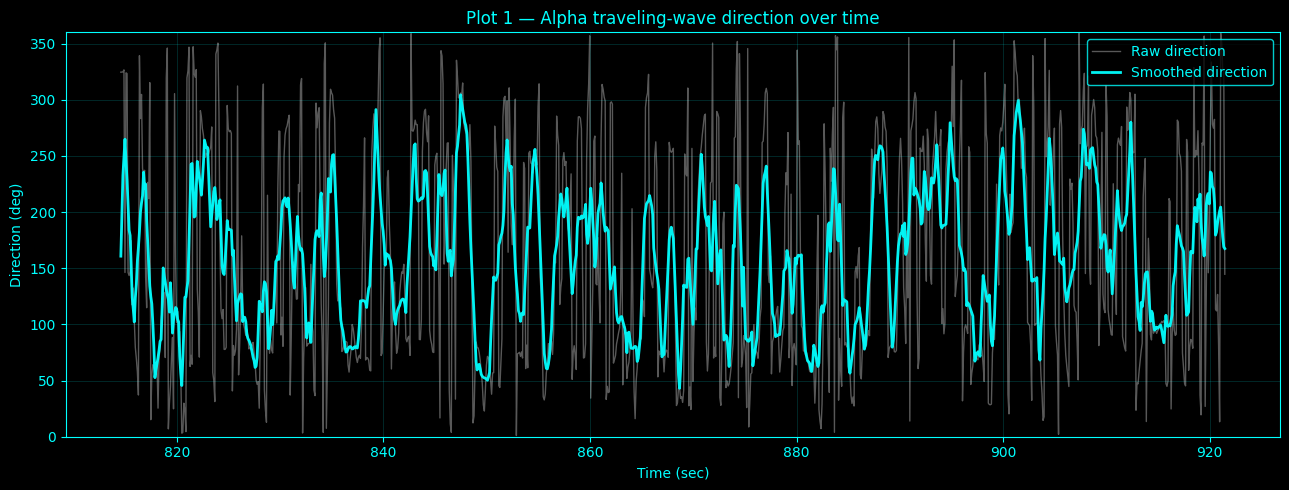

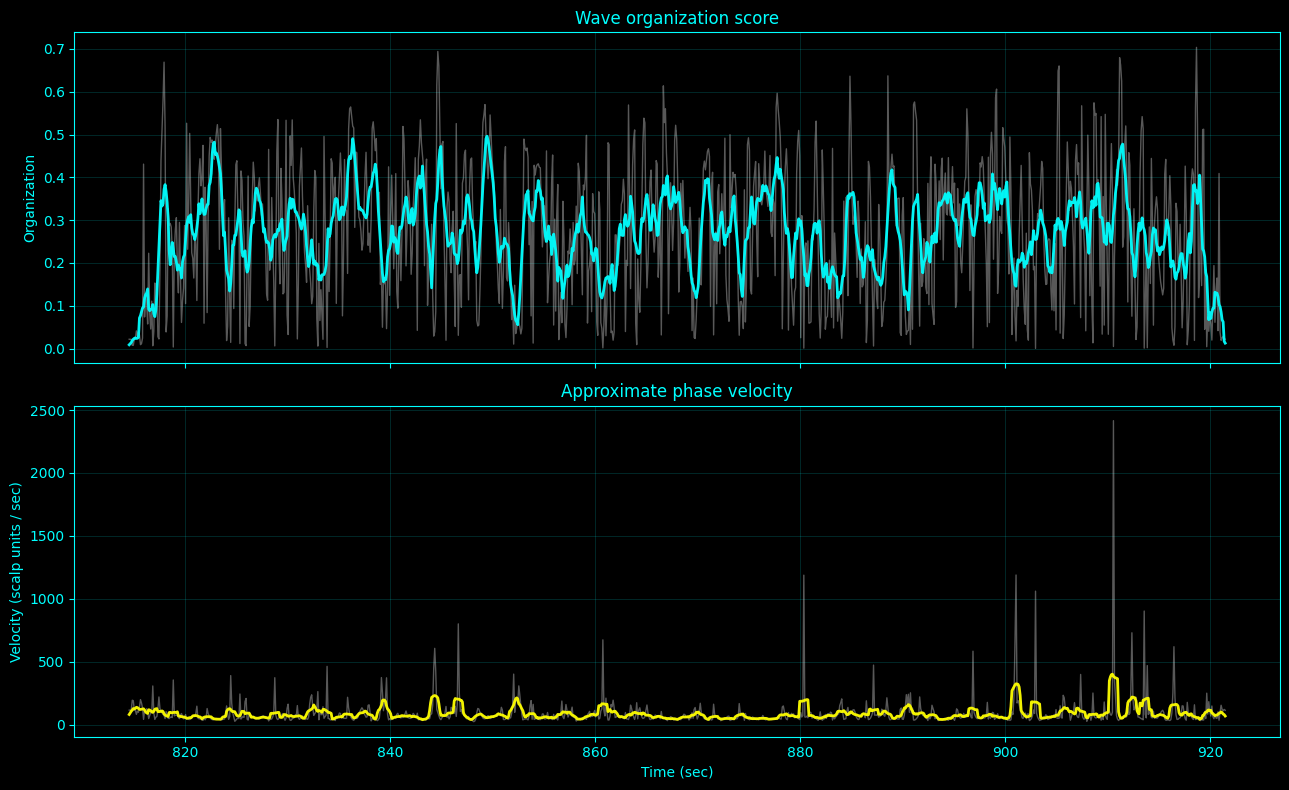

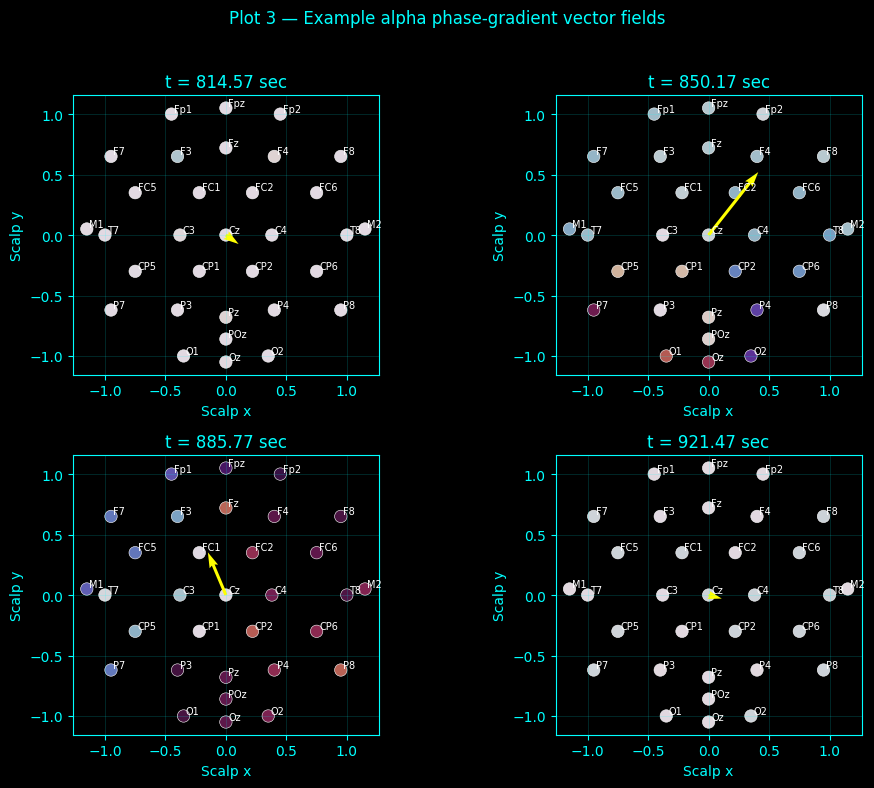

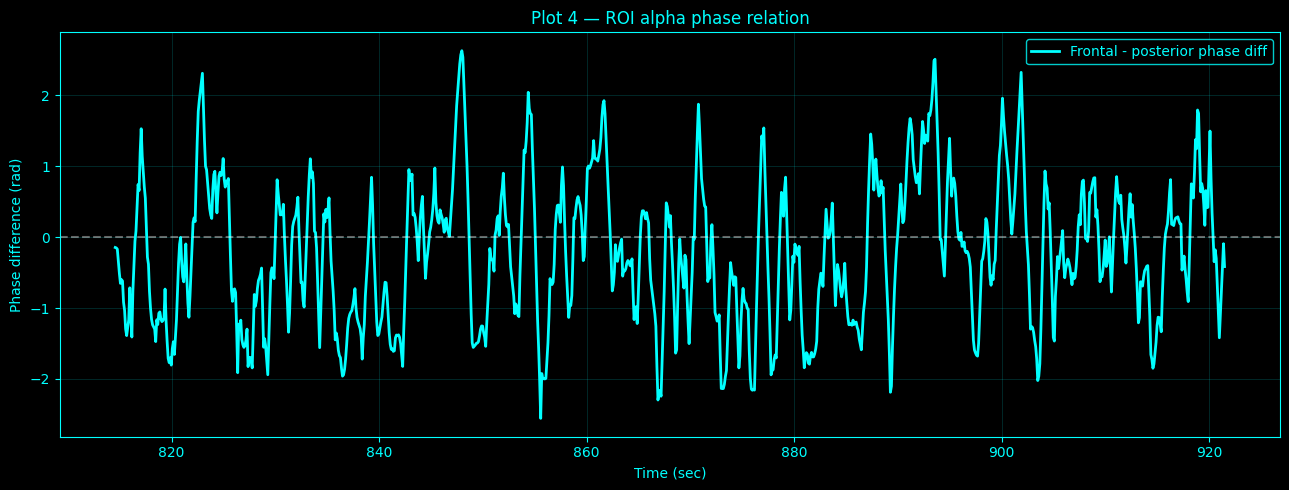

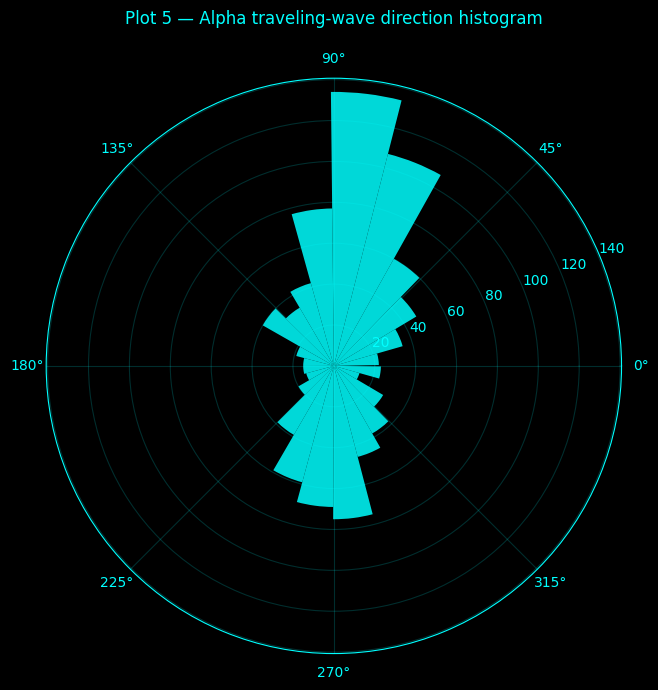

Saved plot 1: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/plots/plot1_alpha_phase_gradient_direction_over_time.png
Saved plot 2: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/plots/plot2_wave_organization_and_speed.png
Saved plot 3: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/plots/plot3_phase_gradient_vector_field_examples.png
Saved plot 4: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/plots/plot4_roi_phase_relations.png
Saved plot 5: /home/a/projects/Complete-Neural-Signal-Analysis/results/exploratory_alpha_traveling_wave_atlas/plots/plot5_directional_polar_histogram.png
Done.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# -------------------------------------------------------
# CONFIG — FILE PATHS ONLY, NO NOTEBOOK MEMORY
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "exploratory_alpha_traveling_wave_atlas")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

apply_common_average_reference = False
detrend_mode = "constant"
zscore_each_channel = False

analysis_downsample_factor = 4
fs_analysis = sampling_rate / analysis_downsample_factor  # 250 Hz

# Dynamic sampling for summaries / plots
summary_step_sec = 0.10

# Alpha estimation / wave tracking
alpha_search_band = (7.0, 13.0)
alpha_halfwidth_hz = 1.5
posterior_alpha_channels = ["P3", "Pz", "P4", "POz", "O1", "Oz", "O2"]
min_valid_channels_per_time = 16

# smoothing for wave metrics
metric_smooth_win = 9

# -------------------------------------------------------
# CHANNELS + APPROXIMATE 10-20 POSITIONS
# 2D scalp coordinates, exploratory only
# x: left(-) to right(+)
# y: posterior(-) to anterior(+)
# -------------------------------------------------------
eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

channel_xy = {
    "Fp1": (-0.45,  1.00), "Fpz": ( 0.00,  1.05), "Fp2": ( 0.45,  1.00),
    "F7":  (-0.95,  0.65), "F3":  (-0.40,  0.65), "Fz":  ( 0.00,  0.72), "F4":  ( 0.40,  0.65), "F8":  ( 0.95,  0.65),
    "FC5": (-0.75,  0.35), "FC1": (-0.22,  0.35), "FC2": ( 0.22,  0.35), "FC6": ( 0.75,  0.35),
    "M1":  (-1.15,  0.05), "T7":  (-1.00,  0.00), "C3":  (-0.38,  0.00), "Cz":  ( 0.00,  0.00), "C4":  ( 0.38,  0.00), "T8":  ( 1.00,  0.00), "M2":  ( 1.15,  0.05),
    "CP5": (-0.75, -0.30), "CP1": (-0.22, -0.30), "CP2": ( 0.22, -0.30), "CP6": ( 0.75, -0.30),
    "P7":  (-0.95, -0.62), "P3":  (-0.40, -0.62), "Pz":  ( 0.00, -0.68), "P4":  ( 0.40, -0.62), "P8":  ( 0.95, -0.62),
    "POz": ( 0.00, -0.86),
    "O1":  (-0.35, -1.00), "Oz":  ( 0.00, -1.05), "O2":  ( 0.35, -1.00),
}

roi_definitions = {
    "frontal":   ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8'],
    "central":   ['FC5', 'FC1', 'FC2', 'FC6', 'C3', 'Cz', 'C4'],
    "posterior": ['CP5', 'CP1', 'CP2', 'CP6', 'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'],
}

ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax, heatmap=False):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    if heatmap:
        ax.grid(False)
    else:
        ax.grid(True, alpha=0.18, color=ACCENT, linewidth=0.6)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape {x.shape}; cannot identify channel axis.")

def maybe_common_average_reference(x, enabled=False):
    if not enabled:
        return x
    return x - np.mean(x, axis=1, keepdims=True)

def preprocess_channel(y, detrend_mode="constant", zscore=False):
    y = np.asarray(y, dtype=float)
    if detrend_mode is not None:
        y = signal.detrend(y, type=detrend_mode)
    if zscore:
        sd = np.std(y)
        y = (y - np.mean(y)) / (sd + eps)
    return y

def smooth_1d(x, win=7):
    x = np.asarray(x, dtype=float)
    if win <= 1 or len(x) < win:
        return x
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(x, kernel, mode="same")

def percentile_limits(x, lo=2, hi=98):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return None, None
    return float(np.percentile(x, lo)), float(np.percentile(x, hi))

def bandpass_sos(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = max(lowcut / nyq, 1e-6)
    high = min(highcut / nyq, 0.999)
    if not (low < high):
        raise ValueError(f"Invalid band {lowcut}-{highcut} Hz for fs={fs}")
    return signal.butter(order, [low, high], btype="bandpass", output="sos")

def compute_welch_psd(y, fs, window_sec=4.0, overlap=0.5, nfft=8192):
    nperseg = min(int(round(window_sec * fs)), len(y))
    nperseg = max(nperseg, min(256, len(y)))
    noverlap = min(int(round(overlap * nperseg)), nperseg - 1)
    f, pxx = signal.welch(
        y, fs=fs, window="hann", nperseg=nperseg, noverlap=noverlap,
        detrend="constant", scaling="density", nfft=nfft
    )
    return f, pxx

def robust_alpha_peak(freqs_hz, psd_1d, band=(7.0, 13.0)):
    mask = (freqs_hz >= band[0]) & (freqs_hz <= band[1]) & np.isfinite(psd_1d)
    if np.sum(mask) < 5:
        return np.nan
    f = freqs_hz[mask]
    y = psd_1d[mask]
    idx = int(np.nanargmax(y))
    return float(f[idx])

def circular_mean(phases_rad):
    z = np.exp(1j * np.asarray(phases_rad, dtype=float))
    return np.angle(np.nanmean(z))

def wrap_to_pi(x):
    return (x + np.pi) % (2 * np.pi) - np.pi

def phase_gradient_fit(phases, xs, ys):
    """
    Fits phi(x,y) = a*x + b*y + c to unwrapped phases around circular mean.
    Returns gradient vector [a,b], fit R^2-like score, and residual std.
    """
    phases = np.asarray(phases, dtype=float)
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)

    mask = np.isfinite(phases) & np.isfinite(xs) & np.isfinite(ys)
    if np.sum(mask) < 6:
        return np.array([np.nan, np.nan]), np.nan, np.nan

    phases = phases[mask]
    xs = xs[mask]
    ys = ys[mask]

    phi0 = circular_mean(phases)
    dphi = wrap_to_pi(phases - phi0)

    X = np.column_stack([xs, ys, np.ones_like(xs)])
    beta, _, _, _ = np.linalg.lstsq(X, dphi, rcond=None)
    pred = X @ beta
    resid = dphi - pred

    ss_res = np.sum((dphi - pred) ** 2)
    ss_tot = np.sum((dphi - np.mean(dphi)) ** 2) + eps
    r2 = 1.0 - ss_res / ss_tot

    grad = beta[:2]
    resid_std = float(np.std(resid))
    return grad, float(r2), resid_std

def direction_deg_from_grad(grad_xy):
    gx, gy = grad_xy
    if not np.isfinite(gx) or not np.isfinite(gy):
        return np.nan
    # direction of increasing phase; propagation direction is opposite
    ang = np.degrees(np.arctan2(-gy, -gx))
    if ang < 0:
        ang += 360.0
    return float(ang)

def wave_metrics_from_grad(grad_xy, freq_hz):
    gx, gy = grad_xy
    if not np.isfinite(gx) or not np.isfinite(gy) or not np.isfinite(freq_hz):
        return np.nan, np.nan, np.nan

    k = float(np.sqrt(gx**2 + gy**2))   # rad / scalp-unit
    if k < 1e-8:
        return 0.0, np.inf, np.inf

    wavelength = float(2.0 * np.pi / k)        # scalp units / cycle
    speed = float((2.0 * np.pi * freq_hz) / k) # scalp units / sec
    return k, wavelength, speed

def roi_mean(values, names, roi_channels):
    idx = [names.index(ch) for ch in roi_channels if ch in names]
    if len(idx) == 0:
        return np.nan
    vals = np.asarray(values, dtype=float)[idx]
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return np.nan
    return float(np.mean(vals))

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
eeg_data = np.load(eeg_path, allow_pickle=True)
eeg_data = ensure_time_channel_layout(eeg_data, len(eeg_channel_names))

if end_index > eeg_data.shape[0]:
    raise ValueError(
        f"Requested end index {end_index} exceeds data length {eeg_data.shape[0]}. "
        "Check sampling rate or segment bounds."
    )

segment = eeg_data[start_index:end_index, :].copy()
segment = maybe_common_average_reference(segment, enabled=apply_common_average_reference)

segment_ds = signal.resample_poly(segment, up=1, down=analysis_downsample_factor, axis=0)
segment_ds = np.asarray(segment_ds, dtype=float)

for ch in range(segment_ds.shape[1]):
    segment_ds[:, ch] = preprocess_channel(
        segment_ds[:, ch],
        detrend_mode=detrend_mode,
        zscore=zscore_each_channel,
    )

n_samples, n_channels = segment_ds.shape
time_sec_rel = np.arange(n_samples) / fs_analysis
time_sec_abs = start_time + time_sec_rel

print(f"Loaded EEG data: {eeg_data.shape[0]} samples x {eeg_data.shape[1]} channels")
print(f"Segment of interest: {start_time:.3f} to {end_time:.3f} sec")
print(f"Original segment shape: {segment.shape}")
print(f"Downsampled segment shape: {segment_ds.shape}")
print(f"Analysis fs: {fs_analysis:.1f} Hz")

# -------------------------------------------------------
# INDIVIDUALIZED ALPHA BAND ESTIMATION
# -------------------------------------------------------
posterior_idx = [eeg_channel_names.index(ch) for ch in posterior_alpha_channels if ch in eeg_channel_names]
posterior_mean = np.nanmean(segment_ds[:, posterior_idx], axis=1)

freqs_hz, pxx = compute_welch_psd(posterior_mean, fs_analysis, window_sec=4.0, overlap=0.5, nfft=8192)
alpha_peak_hz = robust_alpha_peak(freqs_hz, pxx, band=alpha_search_band)

if not np.isfinite(alpha_peak_hz):
    alpha_peak_hz = 10.0

alpha_band = (
    max(alpha_search_band[0], alpha_peak_hz - alpha_halfwidth_hz),
    min(alpha_search_band[1], alpha_peak_hz + alpha_halfwidth_hz),
)

print(f"Posterior consensus alpha peak: {alpha_peak_hz:.3f} Hz")
print(f"Individualized alpha band: [{alpha_band[0]:.3f}, {alpha_band[1]:.3f}] Hz")

# -------------------------------------------------------
# NARROWBAND ALPHA ANALYTIC SIGNAL
# -------------------------------------------------------
sos_alpha = bandpass_sos(alpha_band[0], alpha_band[1], fs_analysis, order=4)

alpha_phase = np.full((n_samples, n_channels), np.nan, dtype=float)
alpha_amp = np.full((n_samples, n_channels), np.nan, dtype=float)

for ch_i in range(n_channels):
    y = signal.sosfiltfilt(sos_alpha, segment_ds[:, ch_i])
    analytic = signal.hilbert(y)
    alpha_phase[:, ch_i] = np.angle(analytic)
    alpha_amp[:, ch_i] = np.abs(analytic)

# -------------------------------------------------------
# PHASE-GRADIENT TRAVELING-WAVE ANALYSIS
# -------------------------------------------------------
xs = np.array([channel_xy[ch][0] for ch in eeg_channel_names], dtype=float)
ys = np.array([channel_xy[ch][1] for ch in eeg_channel_names], dtype=float)

step = max(int(round(summary_step_sec * fs_analysis)), 1)
summary_idx = np.arange(0, n_samples, step, dtype=int)
summary_time_sec_abs = start_time + summary_idx / fs_analysis

grad_x = np.full(len(summary_idx), np.nan, dtype=float)
grad_y = np.full(len(summary_idx), np.nan, dtype=float)
wave_dir_deg = np.full(len(summary_idx), np.nan, dtype=float)
wave_k = np.full(len(summary_idx), np.nan, dtype=float)
wave_lambda = np.full(len(summary_idx), np.nan, dtype=float)
wave_speed = np.full(len(summary_idx), np.nan, dtype=float)
fit_r2 = np.full(len(summary_idx), np.nan, dtype=float)
resid_std = np.full(len(summary_idx), np.nan, dtype=float)
organization_score = np.full(len(summary_idx), np.nan, dtype=float)

for t_i, s_idx in enumerate(summary_idx):
    phi_t = alpha_phase[s_idx, :]
    amp_t = alpha_amp[s_idx, :]

    valid = np.isfinite(phi_t) & np.isfinite(amp_t)
    if np.sum(valid) < min_valid_channels_per_time:
        continue

    # weighted selection: keep stronger-amplitude channels for more stable phase field
    amp_thr = np.nanpercentile(amp_t[valid], 25.0)
    keep = valid & (amp_t >= amp_thr)

    if np.sum(keep) < min_valid_channels_per_time:
        keep = valid

    grad, r2, rs = phase_gradient_fit(phi_t[keep], xs[keep], ys[keep])

    grad_x[t_i] = grad[0]
    grad_y[t_i] = grad[1]
    fit_r2[t_i] = r2
    resid_std[t_i] = rs

    direction = direction_deg_from_grad(grad)
    k, wavelength, speed = wave_metrics_from_grad(grad, alpha_peak_hz)

    wave_dir_deg[t_i] = direction
    wave_k[t_i] = k
    wave_lambda[t_i] = wavelength
    wave_speed[t_i] = speed

    # simple organization score favors strong planar fit and low residual
    organization_score[t_i] = float(max(r2, 0.0) / (1.0 + rs)) if np.isfinite(r2) and np.isfinite(rs) else np.nan

# smooth metric trajectories
grad_x_s = smooth_1d(grad_x, win=metric_smooth_win)
grad_y_s = smooth_1d(grad_y, win=metric_smooth_win)
wave_k_s = smooth_1d(wave_k, win=metric_smooth_win)
wave_lambda_s = smooth_1d(wave_lambda, win=metric_smooth_win)
wave_speed_s = smooth_1d(wave_speed, win=metric_smooth_win)
fit_r2_s = smooth_1d(fit_r2, win=metric_smooth_win)
organization_score_s = smooth_1d(organization_score, win=metric_smooth_win)

# -------------------------------------------------------
# ROI PHASE REFERENCE TRAJECTORIES
# -------------------------------------------------------
roi_phase_traces = {}
for roi_name, roi_channels in roi_definitions.items():
    idx = [eeg_channel_names.index(ch) for ch in roi_channels if ch in eeg_channel_names]
    z = np.exp(1j * alpha_phase[:, idx])
    roi_phase_traces[roi_name] = np.angle(np.nanmean(z, axis=1))

# anterior-posterior lag proxy
front_phase = roi_phase_traces["frontal"][summary_idx]
post_phase = roi_phase_traces["posterior"][summary_idx]
front_post_phase_diff = wrap_to_pi(front_phase - post_phase)

# -------------------------------------------------------
# DESCRIPTIVE SUMMARIES
# -------------------------------------------------------
valid_dir = np.isfinite(wave_dir_deg)
if np.sum(valid_dir) > 0:
    mean_wave_dir_deg = float(np.degrees(np.angle(np.nanmean(np.exp(1j * np.radians(wave_dir_deg[valid_dir]))))))
    if mean_wave_dir_deg < 0:
        mean_wave_dir_deg += 360.0
else:
    mean_wave_dir_deg = np.nan

summary_df = pd.DataFrame([{
    "alpha_peak_hz": alpha_peak_hz,
    "alpha_band_low_hz": alpha_band[0],
    "alpha_band_high_hz": alpha_band[1],
    "mean_wave_direction_deg": mean_wave_dir_deg,
    "mean_wavenumber_rad_per_unit": float(np.nanmean(wave_k_s)),
    "mean_wavelength_scalp_units": float(np.nanmean(wave_lambda_s)),
    "mean_phase_velocity_units_per_sec": float(np.nanmean(wave_speed_s)),
    "mean_planar_fit_r2": float(np.nanmean(fit_r2_s)),
    "mean_residual_std_rad": float(np.nanmean(resid_std)),
    "mean_organization_score": float(np.nanmean(organization_score_s)),
    "wave_organization_volatility": float(np.nanstd(organization_score_s)),
    "frontal_minus_posterior_phase_bias_rad": float(np.nanmean(front_post_phase_diff)),
}])

trajectory_df = pd.DataFrame({
    "time_sec": summary_time_sec_abs,
    "grad_x": grad_x,
    "grad_y": grad_y,
    "grad_x_s": grad_x_s,
    "grad_y_s": grad_y_s,
    "wave_direction_deg": wave_dir_deg,
    "wavenumber_rad_per_unit": wave_k,
    "wavenumber_rad_per_unit_s": wave_k_s,
    "wavelength_scalp_units": wave_lambda,
    "wavelength_scalp_units_s": wave_lambda_s,
    "phase_velocity_units_per_sec": wave_speed,
    "phase_velocity_units_per_sec_s": wave_speed_s,
    "fit_r2": fit_r2,
    "fit_r2_s": fit_r2_s,
    "residual_std_rad": resid_std,
    "organization_score": organization_score,
    "organization_score_s": organization_score_s,
    "front_minus_post_phase_diff_rad": front_post_phase_diff,
})

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
summary_csv_path = os.path.join(out_dir, "traveling_wave_summary.csv")
trajectory_csv_path = os.path.join(out_dir, "traveling_wave_trajectory.csv")
npz_path = os.path.join(out_dir, "traveling_wave_outputs.npz")
dict_npy_path = os.path.join(out_dir, "traveling_wave_output_dict.npy")
notes_txt_path = os.path.join(out_dir, "traveling_wave_notes.txt")

plot1_path = os.path.join(plots_dir, "plot1_alpha_phase_gradient_direction_over_time.png")
plot2_path = os.path.join(plots_dir, "plot2_wave_organization_and_speed.png")
plot3_path = os.path.join(plots_dir, "plot3_phase_gradient_vector_field_examples.png")
plot4_path = os.path.join(plots_dir, "plot4_roi_phase_relations.png")
plot5_path = os.path.join(plots_dir, "plot5_directional_polar_histogram.png")

summary_df.to_csv(summary_csv_path, index=False)
trajectory_df.to_csv(trajectory_csv_path, index=False)

np.savez_compressed(
    npz_path,
    channel_names=np.array(eeg_channel_names, dtype=object),
    summary_time_sec_abs=summary_time_sec_abs,
    alpha_peak_hz=alpha_peak_hz,
    alpha_band=np.array(alpha_band, dtype=float),
    alpha_phase=alpha_phase[:, :],
    alpha_amp=alpha_amp[:, :],
    grad_x=grad_x,
    grad_y=grad_y,
    grad_x_s=grad_x_s,
    grad_y_s=grad_y_s,
    wave_direction_deg=wave_dir_deg,
    wavenumber_rad_per_unit=wave_k,
    wavelength_scalp_units=wave_lambda,
    phase_velocity_units_per_sec=wave_speed,
    fit_r2=fit_r2,
    residual_std_rad=resid_std,
    organization_score=organization_score,
    front_minus_post_phase_diff_rad=front_post_phase_diff,
)

output_dict = {
    "summary_df": summary_df,
    "trajectory_df": trajectory_df,
    "alpha_peak_hz": alpha_peak_hz,
    "alpha_band": alpha_band,
    "summary_time_sec_abs": summary_time_sec_abs,
}
np.save(dict_npy_path, output_dict, allow_pickle=True)

with open(notes_txt_path, "w") as f:
    f.write("Exploratory individualized-alpha traveling-wave atlas\n")
    f.write("===================================================\n\n")
    f.write("Why this block is new relative to the retrieved notebook snippets:\n")
    f.write("The notebook already contains spectral work, PLV/AES/PAC network work, Lyapunov/KS work,\n")
    f.write("and intrinsic Hermitian/Ricci geometry. This block adds scalp phase-gradient traveling-wave analysis.\n\n")
    f.write("Interpretation:\n")
    f.write("A planar phase gradient across the scalp is treated as an exploratory traveling-wave signature.\n")
    f.write("This is not a final biophysical source-localized model. It is a mesoscale descriptive proxy.\n\n")
    f.write(f"Segment: [{start_time:.3f}, {end_time:.3f}] sec\n")
    f.write(f"Original fs: {sampling_rate} Hz\n")
    f.write(f"Analysis fs: {fs_analysis:.1f} Hz\n")
    f.write(f"Posterior consensus alpha peak: {alpha_peak_hz:.3f} Hz\n")
    f.write(f"Individualized alpha band: [{alpha_band[0]:.3f}, {alpha_band[1]:.3f}] Hz\n")
    f.write(f"Mean wave direction (deg): {mean_wave_dir_deg}\n")
    f.write(f"Mean organization score: {float(np.nanmean(organization_score_s)):.6f}\n")
    f.write(f"Mean planar fit R2: {float(np.nanmean(fit_r2_s)):.6f}\n")

print(f"\nSaved summary CSV: {summary_csv_path}")
print(f"Saved trajectory CSV: {trajectory_csv_path}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved dict NPY: {dict_npy_path}")
print(f"Saved notes TXT: {notes_txt_path}")

# -------------------------------------------------------
# PLOT 1 — DIRECTION OVER TIME
# -------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(13, 5), facecolor=BG)
style_ax(ax1)

ax1.plot(summary_time_sec_abs, wave_dir_deg, linewidth=1.0, alpha=0.35, color="white", label="Raw direction")
ax1.plot(summary_time_sec_abs, smooth_1d(wave_dir_deg, win=metric_smooth_win), linewidth=2.0, alpha=0.95, color=ACCENT, label="Smoothed direction")
ax1.set_title("Plot 1 — Alpha traveling-wave direction over time")
ax1.set_xlabel("Time (sec)")
ax1.set_ylabel("Direction (deg)")
ax1.set_ylim(0, 360)
ax1.legend(loc="upper right")

fig1.tight_layout()
fig1.savefig(plot1_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig1)

# -------------------------------------------------------
# PLOT 2 — ORGANIZATION AND SPEED
# -------------------------------------------------------
fig2, axes2 = plt.subplots(2, 1, figsize=(13, 8), facecolor=BG, sharex=True)
axes2 = np.atleast_1d(axes2)

for ax in axes2:
    style_ax(ax)

axes2[0].plot(summary_time_sec_abs, organization_score, linewidth=1.0, alpha=0.35, color="white")
axes2[0].plot(summary_time_sec_abs, organization_score_s, linewidth=2.0, alpha=0.95, color=ACCENT)
axes2[0].set_title("Wave organization score")
axes2[0].set_ylabel("Organization")

axes2[1].plot(summary_time_sec_abs, wave_speed, linewidth=1.0, alpha=0.35, color="white")
axes2[1].plot(summary_time_sec_abs, wave_speed_s, linewidth=2.0, alpha=0.95, color="yellow")
axes2[1].set_title("Approximate phase velocity")
axes2[1].set_xlabel("Time (sec)")
axes2[1].set_ylabel("Velocity (scalp units / sec)")

fig2.tight_layout()
fig2.savefig(plot2_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig2)

# -------------------------------------------------------
# PLOT 3 — VECTOR FIELD EXAMPLES
# -------------------------------------------------------
example_idx = np.linspace(0, len(summary_idx) - 1, 4, dtype=int)

fig3, axes3 = plt.subplots(2, 2, figsize=(10, 8), facecolor=BG)
axes3 = np.atleast_1d(axes3).ravel()

for ax, ex_i in zip(axes3, example_idx):
    style_ax(ax)
    t0 = summary_idx[ex_i]
    phi_t = alpha_phase[t0, :]
    amp_t = alpha_amp[t0, :]
    valid = np.isfinite(phi_t) & np.isfinite(amp_t)

    ax.scatter(xs[valid], ys[valid], c=phi_t[valid], s=80, cmap="twilight", edgecolors="white", linewidths=0.4)

    gx = grad_x_s[ex_i]
    gy = grad_y_s[ex_i]
    if np.isfinite(gx) and np.isfinite(gy):
        ax.quiver(
            [0.0], [0.0], [-gx], [-gy],
            angles="xy", scale_units="xy", scale=1.5,
            color="yellow", width=0.01
        )

    for ch_i, ch_name in enumerate(eeg_channel_names):
        ax.text(xs[ch_i] + 0.02, ys[ch_i] + 0.02, ch_name, fontsize=7, color="white")

    ax.set_title(f"t = {summary_time_sec_abs[ex_i]:.2f} sec")
    ax.set_xlabel("Scalp x")
    ax.set_ylabel("Scalp y")
    ax.set_aspect("equal")

fig3.suptitle("Plot 3 — Example alpha phase-gradient vector fields", color=ACCENT, y=0.98)
fig3.tight_layout(rect=[0, 0, 1, 0.96])
fig3.savefig(plot3_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig3)

# -------------------------------------------------------
# PLOT 4 — ROI PHASE RELATIONS
# -------------------------------------------------------
fig4, ax4 = plt.subplots(figsize=(13, 5), facecolor=BG)
style_ax(ax4)

ax4.plot(summary_time_sec_abs, smooth_1d(front_post_phase_diff, win=metric_smooth_win), linewidth=2.0, color=ACCENT, label="Frontal - posterior phase diff")
ax4.axhline(0.0, color="white", linestyle="--", alpha=0.4)
ax4.set_title("Plot 4 — ROI alpha phase relation")
ax4.set_xlabel("Time (sec)")
ax4.set_ylabel("Phase difference (rad)")
ax4.legend(loc="upper right")

fig4.tight_layout()
fig4.savefig(plot4_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig4)

# -------------------------------------------------------
# PLOT 5 — DIRECTIONAL POLAR HISTOGRAM
# -------------------------------------------------------
fig5 = plt.figure(figsize=(7, 7), facecolor=BG)
ax5 = plt.subplot(111, projection="polar")
ax5.set_facecolor(BG)

valid = np.isfinite(wave_dir_deg)
theta = np.radians(wave_dir_deg[valid])

if len(theta) > 0:
    ax5.hist(theta, bins=24, color=ACCENT, alpha=0.85)

ax5.set_title("Plot 5 — Alpha traveling-wave direction histogram", color=ACCENT, pad=20)
ax5.tick_params(colors=ACCENT)
ax5.grid(True, alpha=0.18, color=ACCENT)

fig5.tight_layout()
fig5.savefig(plot5_path, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig5)

print(f"Saved plot 1: {plot1_path}")
print(f"Saved plot 2: {plot2_path}")
print(f"Saved plot 3: {plot3_path}")
print(f"Saved plot 4: {plot4_path}")
print(f"Saved plot 5: {plot5_path}")
print("Done.")